# 04 — Business Analytics
## Ride-Hailing Demand & Operational Analytics

**Sumber:** `mart_business_metrics`, `mart_destination_metrics`, `mart_hourly_demand`
**Prasyarat:** Phase 3 selesai

---

### Catatan metodologi

Latar belakang dan permasalahan pada notebook ini dirumuskan dari **struktur keputusan dan struktur data**, bukan dari temuan. Seluruhnya dapat dinyatakan tanpa menjalankan satu query pun.

Analisis deskriptif dasar dijalankan lebih dulu sebagai baseline eksploratori. Hal ini disebutkan terbuka agar pembaca mengetahui urutan pengerjaan sebenarnya.

Hipotesis pada bagian 0.5 ditulis beserta kriteria gugurnya **sebelum** pengujian, agar hasil tidak dapat ditafsirkan menyesuaikan harapan.

## 0.1 Latar Belakang

Perencanaan operasional ride-hailing pada dasarnya adalah keputusan tentang **penempatan**: berapa banyak kendaraan yang perlu tersedia, pada jam berapa, di zona mana.

Supply ride-hailing tidak dapat disesuaikan setelah permintaan datang. Pengemudi yang berjarak 20 menit bukanlah supply bagi penumpang yang memesan sekarang. Kendaraan harus sudah berada di dekat lokasi sebelum permintaan muncul.

Karena itu seluruh operasi berjalan di atas **antisipasi**, dan antisipasi membutuhkan angka untuk dituju.

### Rumusan permasalahan

Terdapat perbedaan tingkat antara tingkat pengambilan keputusan dan tingkat pelaporan:

```
Keputusan diambil di   : zona x jam
Pelaporan dilakukan di : kota x bulan
```

Rata-rata hanya sahih mewakili kelompoknya bila variasi di dalam kelompok itu kecil. Bila variasinya besar, rata-rata tetap terlihat wajar sementara kondisi sebenarnya jauh berbeda.

**Yang belum diketahui: apakah variasi di dalam agregat itu kecil atau besar.**

Pertanyaan ini terbuka. Bila variasinya kecil, perencanaan berbasis rata-rata memang memadai dan project berhenti pada Business Analytics. Bila besar, dibutuhkan metode yang mempertahankan kerincian.

### Kenapa masalah ini tidak terlihat sendiri

| Arah kesalahan | Yang terjadi | Kenapa tidak terlihat |
|---|---|---|
| Armada kurang | Permintaan tidak terlayani | Permintaan gagal tidak tercatat di dataset |
| Armada berlebih | Pengemudi menganggur | Tidak ada data waktu idle |

Laporan agregat tetap terlihat sehat pada kedua kondisi. Masalahnya bukan tidak terjadi, melainkan **tidak terukur**.

### Rantai berpikir menuju forecasting

```
1. Supply tidak bisa disesuaikan setelah permintaan datang
2. Karena itu operasi berjalan di atas antisipasi
3. Antisipasi butuh angka untuk dituju
4. Hanya ada dua sumber angka: riwayat (rata-rata) atau prediksi (model)
5. Riwayat gratis, prediksi butuh usaha -> beban pembuktian ada di prediksi
6. Rata-rata gagal hanya bila variasi dalam kelompok besar -> bisa diukur
7. Rata-rata gagal saja tidak cukup: variasi juga harus terstruktur
```

**Dua gerbang yang harus lolos:**

| Gerbang | Pertanyaan | Bila tidak lolos |
|---|---|---|
| 1 | Apakah rata-rata gagal pada grain keputusan? | Pakai rata-rata, project selesai di Phase 4 |
| 2 | Apakah variasi terstruktur, bukan acak? | Siapkan kapasitas cadangan, bukan forecasting |

Kedua gerbang hanya bisa diuji dengan analisis deskriptif. Menguji kebutuhan model dengan membangun model adalah penalaran melingkar.

## 0.2 Business Question

**Pertanyaan utama**

> Pada tingkat agregasi mana rata-rata historis berhenti dapat dipercaya sebagai dasar perencanaan permintaan?

**Pertanyaan pendukung**

| # | Pertanyaan | Kategori | Step |
|---|---|---|---|
| 1 | Apakah pertumbuhan permintaan nyata setelah efek kalender dibersihkan? | A, B | 3, 4 |
| 2 | Apakah perubahan metrik rata-rata mencerminkan perubahan komponen penyusunnya? | A | 5, 6 |
| 3 | Apakah pola jam berlaku sama di seluruh zona? | B, C | 10 |
| 4 | Apakah kedua provider bergerak searah pada tingkat zona? | A, C | 2, 9 |
| 5 | Seberapa besar rata-rata meleset pada tingkat zona-jam? | B, C | 13, 14 |

**Kategori analisis yang disepakati:** A Overall performance · B Temporal pattern · C Pickup-location activity · D Destination pattern · E Service behavior

## 0.3 Goals

### Business Goal

> Menyediakan ketersediaan armada pada waktu dan lokasi yang tepat, sehingga permintaan terlayani tanpa membuat pengemudi menganggur.

Project ini **tidak mencapai** tujuan tersebut. Perencanaan armada membutuhkan data ketersediaan pengemudi yang tidak tersedia.

### Analytics Goal — Phase 4

| Kode | Tujuan | Ukuran keberhasilan | Step |
|---|---|---|---|
| G1 | Menetapkan KPI relevan dan memetakan mana yang dapat dihitung | Daftar KPI beserta status ketersediaan | 0.4 |
| G2 | Menguji apakah rata-rata mewakili kondisi pada tingkat keputusan | Deviasi terukur | 13 |
| G3 | Menguji apakah variasi punya struktur yang dapat dipelajari | Perbandingan error antar aturan | 14 |
| G4 | Menetapkan baseline pembanding untuk modeling | Nilai baseline tersedia | 14 |
| G5 | Menentukan di mana forecasting paling bernilai | Peringkat zona berdasarkan volume dan volatilitas | 15 |

**G3 adalah gerbang.** Bila variasi terbukti acak, forecasting tidak memberi manfaat dan project dihentikan pada Phase 4.

### Modeling Goal — Phase 6

> Memprediksi `demand` pada grain `request_hour x provider x pickup_location_id` dengan kesalahan lebih kecil daripada baseline pada G4.

Ukuran keberhasilan bukan nilai WMAPE absolut, melainkan **rasio terhadap baseline**.

### Yang bukan tujuan

| Bukan tujuan | Alasan |
|---|---|
| Optimasi alokasi pengemudi | Tidak ada data supply dan utilisasi |
| Memprediksi permintaan sebenarnya | Data hanya memuat permintaan terlayani |
| Rekomendasi penetapan harga | Tidak ada data biaya maupun elastisitas |
| Analisis profitabilitas | Selisih fare dan driver pay bukan margin |
| Dispatching real-time | Arsitektur batch, bukan streaming |

## 0.4 KPI — Kerangka dan Ketersediaan

```
Metrik = apa saja yang bisa dihitung
KPI    = metrik yang perubahannya memicu keputusan
```

### Kerangka KPI ideal operasi ride-hailing

Disusun dari sifat bisnisnya, **sebelum** melihat data.

| Sisi | KPI | Pertanyaan yang dijawab |
|---|---|---|
| Permintaan | Volume permintaan | Seberapa besar pasarnya |
| Permintaan | Sebaran permintaan | Di mana permintaan berada |
| Permintaan | Volatilitas permintaan | Seberapa sulit diantisipasi |
| Pemenuhan | Fulfillment rate | Berapa persen permintaan terlayani |
| Pemenuhan | Cancellation rate | Seberapa sering layanan gagal |
| Pemenuhan | Waktu tunggu | Seberapa baik kualitas layanan |
| Ekonomi | Revenue perusahaan | Berapa pendapatan yang dihasilkan |
| Ekonomi | Harga per satuan jarak | Berapa harga sebenarnya |
| Ekonomi | Pendapatan driver per waktu | Apakah driver bertahan |
| Efisiensi | Utilisasi driver | Berapa porsi waktu produktif |
| Efisiensi | Kecepatan perjalanan | Seberapa efisien jaringan jalan |

### Konfrontasi dengan ketersediaan data

| KPI | Ketersediaan | Keterangan |
|---|---|---|
| Volume permintaan | Tersedia | Hanya perjalanan terlayani |
| Sebaran permintaan | Tersedia | Tingkat zona pickup |
| Volatilitas permintaan | Tersedia | Grain zona-jam |
| Fulfillment rate | **Tidak tersedia** | Dataset hanya memuat perjalanan selesai |
| Cancellation rate | **Tidak tersedia** | Tidak ada field pembatalan |
| Waktu tunggu | Sebagian | `on_scene_datetime` hilang 26,54% |
| Revenue perusahaan | **Tidak tersedia** | `base_passenger_fare` adalah bayaran penumpang |
| Harga per satuan jarak | Tersedia | Metrik turunan |
| Pendapatan driver per waktu | Tersedia | Metrik turunan |
| Utilisasi driver | **Tidak tersedia** | Tidak ada jam online driver |
| Kecepatan perjalanan | Tersedia | Metrik turunan |

### Temuan pertama laporan

Dari sebelas KPI ideal, enam dapat dihitung, satu hanya sebagian (waktu tunggu), dan empat tidak tersedia sama sekali: fulfillment rate, cancellation rate, revenue perusahaan, dan utilisasi driver. Yang hilang tersebar di sisi pemenuhan, ekonomi, dan efisiensi.

Konsekuensi:
1. Permintaan yang dianalisis adalah *served demand*, bukan permintaan sebenarnya
2. Kualitas layanan tidak dapat diukur
3. Ketersediaan pengemudi tidak dapat diukur
4. Profitabilitas tidak dapat dihitung

Dari empat sisi KPI, hanya **sisi permintaan** yang datanya utuh. Inilah yang menjelaskan kenapa fokus project diarahkan ke demand forecasting — bukan pilihan sembarangan, melainkan konsekuensi dari data yang tersedia.

### KPI yang dipakai

**KPI utama:** demand per `request_hour x pickup_location_id x provider`

**Definisi metrik turunan** — perhatikan pola SUM/SUM, bukan AVG of AVG:

```sql
avg_trip_miles    = SUM(total_trip_miles)   / SUM(valid_distance_trips)
avg_trip_minutes  = SUM(total_trip_seconds) / SUM(valid_duration_trips) / 60
avg_base_fare     = SUM(total_base_fare)    / SUM(valid_fare_trips)
avg_driver_pay    = SUM(total_driver_pay)   / SUM(valid_driver_pay_trips)

fare_per_mile     = SUM(total_base_fare)    / SUM(total_trip_miles)
pay_per_minute    = SUM(total_driver_pay)   / (SUM(total_trip_seconds)/60)
avg_speed_mph     = SUM(total_trip_miles)   / (SUM(total_trip_seconds)/3600)
pay_to_fare_ratio = SUM(total_driver_pay)   / SUM(total_base_fare)
```

### Definisi metrik layanan — DIPERBAIKI

`wav_request_flag` berarti penumpang meminta kendaraan WAV. `wav_match_flag` berarti perjalanan dilayani kendaraan WAV, **termasuk untuk penumpang yang tidak memintanya**. Karena itu keduanya tidak boleh dibagi satu sama lain.

```sql
-- BENAR
wav_request_rate = SUM(wav_request_count) / SUM(total_trips)
wav_fleet_share  = SUM(wav_match_count)   / SUM(total_trips)

-- SALAH: menghasilkan angka di atas 100%
-- wav_match_rate = wav_match_count / wav_request_count
```

Untuk shared ride, `shared_match_rate` hanya dilaporkan pada provider yang benar-benar mencatat shared request. Lihat Step 12.

## 0.5 Hipotesis yang Diuji

Kriteria gugur ditulis sebelum pengujian dilakukan.

| # | Asumsi perencanaan | Bertahan bila | Gugur bila | Step |
|---|---|---|---|---|
| H1 | Permintaan cukup terkonsentrasi sehingga fokus pada zona utama memadai | Sebagian kecil zona menyumbang mayoritas | Permintaan tersebar merata | 9 |
| H2 | Terdapat satu pola jam sibuk untuk seluruh kota | Kurva harian serupa antar zona | Kurva berbeda menurut karakter zona | 10 |
| H3 | Kedua provider bergerak searah sehingga cukup direncanakan bersama | Pangsa stabil antar zona dan waktu | Pangsa bergeser di tingkat zona | 9 |
| H4 | Rata-rata historis memadai sebagai dasar perencanaan | Deviasi kecil | Deviasi besar di zona-jam | 13, 14 |
| H5 | Pendapatan driver tergerus selama periode | Pay per minute turun | Pay per minute stabil atau naik | 5 |
| H6 | Kenaikan tarif bersifat moderat | Fare per mile naik sebanding fare per trip | Fare per mile naik jauh lebih besar | 5 |
| H7 | Kemacetan menjelaskan perubahan durasi perjalanan | Kecepatan turun signifikan | Kecepatan relatif stabil | 5 |

---

# SETUP

In [62]:
# ============================================================
# SETUP
# ============================================================
import warnings
import logging

# Saat debugging, ubah menjadi True untuk melihat kembali
# seluruh peringatan yang disembunyikan.
TAMPILKAN_WARNING = False

if not TAMPILKAN_WARNING:
    # Peringatan Python umum: FutureWarning, DeprecationWarning, dll.
    # Ini hanya menyembunyikan peringatan, bukan error.
    # Error tetap muncul seperti biasa.
    warnings.filterwarnings("ignore")

    # Pesan dari library Google Cloud, misalnya saran memasang
    # bigquery-storage atau catatan mengenai kredensial.
    for nama in ["google", "google.auth", "google.cloud",
                 "google.api_core", "urllib3"]:
        logging.getLogger(nama).setLevel(logging.ERROR)

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ID = "ride-hailing-forecasting"
DATASET_ID = "ride_hailing"

MART_BUSINESS    = f"`{PROJECT_ID}.{DATASET_ID}.mart_business_metrics`"
MART_DESTINATION = f"`{PROJECT_ID}.{DATASET_ID}.mart_destination_metrics`"
MART_DEMAND      = f"`{PROJECT_ID}.{DATASET_ID}.mart_hourly_demand`"

# Tampilan angka: 4 desimal dengan pemisah ribuan
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Project :", PROJECT_ID)
print("Dataset :", DATASET_ID)
print("Warning :", "ditampilkan" if TAMPILKAN_WARNING else "disembunyikan")

Project : ride-hailing-forecasting
Dataset : ride_hailing


In [63]:
# ============================================================
# STYLE GRAFIK — dijalankan sekali, dipakai seluruh notebook
# ============================================================

# Render grafik dalam resolusi tinggi. Tanpa baris ini grafik
# terlihat buram di banyak tampilan notebook.
%config InlineBackend.figure_format = "retina"

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Palet warna dengan makna tetap di seluruh notebook
C = {
    "primary":   "#1F4E79",   # metrik utama
    "secondary": "#E07B39",   # metrik pembanding
    "accent":    "#2E8B74",   # metrik ketiga
    "muted":     "#9AA5B1",   # konteks, garis bantu
    "alert":     "#C0392B",   # penanda penting
    "grid":      "#E4E7EB",
    "text":      "#2C3A47",
    "bg":        "#FFFFFF",
}

mpl.rcParams.update({
    "figure.facecolor":   C["bg"],
    "axes.facecolor":     C["bg"],
    "axes.edgecolor":     C["muted"],
    "axes.linewidth":     0.8,
    "axes.labelcolor":    C["text"],
    "axes.titlesize":     13,
    "axes.titleweight":   "semibold",
    "axes.titlecolor":    C["text"],
    "axes.titlelocation": "left",
    "axes.titlepad":      14,
    "axes.labelsize":     10,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         C["grid"],
    "grid.linewidth":     0.8,
    "xtick.color":        C["text"],
    "ytick.color":        C["text"],
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "legend.frameon":     False,
    "legend.fontsize":    9,
    "lines.linewidth":    2.0,
    "lines.markersize":   4,
    "font.size":          10,
    "figure.dpi":         110,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
})


def clean_axes(ax, x_grid=False):
    """Hilangkan bingkai atas dan kanan, sisakan grid horizontal saja."""
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color(C["muted"])
    ax.spines["bottom"].set_color(C["muted"])
    ax.grid(axis="y", visible=True)
    ax.grid(axis="x", visible=x_grid)
    return ax


def titled(ax, title, sub=None):
    """
    Judul utama plus kalimat penjelas di bawahnya.

    Judul menyatakan temuan, subjudul memberi tahu apa yang harus dilihat.
    Gunakan fungsi ini, bukan ax.set_title(), agar keduanya tidak saling timpa.
    """
    ax.set_title(title, loc="left", pad=30 if sub else 14)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes,
                fontsize=9.5, color=C["muted"], va="bottom")
    return ax


def subtitle(ax, text):
    """Dipertahankan agar kode lama tetap jalan. Gunakan titled() untuk kode baru."""
    return titled(ax, ax.get_title(), text)


def thousands(x, pos):
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:,.1f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:,.0f}k"
    return f"{x:,.0f}"

FMT_K = FuncFormatter(thousands)


def label_last(ax, x, y, text, color, dx=6):
    """Label langsung di ujung garis, menggantikan legend."""
    ax.annotate(text, xy=(x, y), xytext=(dx, 0),
                textcoords="offset points",
                va="center", ha="left",
                fontsize=9.5, color=color, fontweight="semibold")


def sparse_ticks(ax, labels, every=3):
    """Tampilkan sebagian label sumbu x agar tidak berdesakan."""
    ax.set_xticks(range(0, len(labels), every))
    ax.set_xticklabels([labels[i] for i in range(0, len(labels), every)],
                       rotation=0, ha="center")

print("Style grafik siap.")

Style grafik siap.


In [64]:
client = bigquery.Client(project=PROJECT_ID)

print("Connected project:", client.project)

Connected project: ride-hailing-forecasting


In [65]:
def run_query(sql: str, timeout: int = 300) -> pd.DataFrame:
    """
    Menjalankan GoogleSQL di BigQuery dan mengembalikan pandas DataFrame.

    - Agregasi berat dilakukan di BigQuery, hanya hasil kecil yang ditarik
    - timeout dalam detik: bila hasil belum kembali, proses berhenti dengan
      pesan dan Job ID, bukan menunggu tanpa batas
    - bytes_billed dicetak karena kuota BigQuery Sandbox terbatas
    """
    job = client.query(sql)
    try:
        df = job.result(timeout=timeout).to_dataframe()
    except Exception:
        print(f"Query berhenti setelah {timeout} detik atau gagal.")
        print(f"Job ID untuk dicek di BigQuery Console: {job.job_id}")
        raise

    print(f"Rows returned : {len(df):,}")
    print(f"Bytes billed  : {job.total_bytes_billed / (1024**3):,.4f} GB")
    return df

### Cek schema

Beberapa query di notebook ini menggunakan operasi tanggal pada `request_hour`. Tipe kolom perlu dipastikan lebih dulu, karena `TIMESTAMP` dan `DATETIME` memakai fungsi yang berbeda (`TIMESTAMP_ADD` vs `DATETIME_ADD`).

Jalankan cell berikut dan sesuaikan konstanta `TS_ADD` bila perlu.

In [66]:
sql = f"""
SELECT table_name, column_name, data_type
FROM `{PROJECT_ID}.{DATASET_ID}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name IN (
    'mart_business_metrics',
    'mart_destination_metrics',
    'mart_hourly_demand'
)
ORDER BY table_name, ordinal_position
"""

df_schema = run_query(sql)
df_schema

Rows returned : 53
Bytes billed  : 0.0098 GB


,table_name,column_name,data_type
0,mart_business_metrics,request_hour,TIMESTAMP
1,mart_business_metrics,request_date,DATE
2,mart_business_metrics,year,INT64
3,mart_business_metrics,month,INT64
4,mart_business_metrics,year_month,STRING
5,mart_business_metrics,day_name,STRING
6,mart_business_metrics,hour,INT64
7,mart_business_metrics,is_weekend,BOOL
8,mart_business_metrics,provider_code,STRING
9,mart_business_metrics,provider,STRING


> **Hasil pemeriksaan struktur tabel**

Query ini membaca metadata, bukan isi tabel, sehingga tidak memakan kuota.

| Mart | Grain | Kolom |
|---|---|---|
| `mart_business_metrics` | jam × provider × zona pickup | 29 |
| `mart_hourly_demand` | jam × provider × zona pickup | 14 |
| `mart_destination_metrics` | **hari** × provider × zona dropoff | 11 |

**Empat hal yang perlu dicatat:**

`request_hour` bertipe **TIMESTAMP** di kedua mart berdimensi jam. Karena itu `TS_TYPE = "TIMESTAMP"`, dan Step 14 memakai `TIMESTAMP_ADD`. Walaupun tertulis `+00:00`, isinya adalah waktu lokal New York. Hal ini dibuktikan pada pemeriksaan tanggal pergantian jam musim panas di Step 15.

`mart_destination_metrics` **tidak punya kolom jam**, hanya `request_date`. Analisis tujuan perjalanan karena itu hanya bisa harian. Ini sesuai rancangan pipeline, bukan kekurangan.

Tersedia `provider_code` (HV0003/HV0005) selain `provider`. Untuk Phase 6 pakai `provider_code` sebagai fitur, karena kode lisensi tidak berubah walau nama dagang berubah.

Kolom `avg_trip_miles`, `avg_trip_minutes`, `avg_base_fare`, dan `avg_driver_pay` adalah rata-rata **per sel**, bukan rata-rata keseluruhan. Jangan diagregasi ulang dengan `AVG()` karena menghasilkan rata-rata dari rata-rata. Seluruh notebook ini menghitung ulang dari metrik additive:

In [67]:
# Sesuaikan berdasarkan hasil cell sebelumnya.
# Jika request_hour bertipe TIMESTAMP  -> "TIMESTAMP"
# Jika request_hour bertipe DATETIME   -> "DATETIME"

TS_TYPE = "TIMESTAMP"

TS_ADD  = f"{TS_TYPE}_ADD"
TS_LIT  = lambda s: f"{TS_TYPE} '{s}'"

TRAIN_END  = "2026-01-01 00:00:00"   # batas akhir data historis untuk aturan A dan B
EVAL_START = "2026-01-01 00:00:00"   # awal periode evaluasi

print("TS_TYPE    :", TS_TYPE)
print("TRAIN_END  :", TRAIN_END)
print("EVAL_START :", EVAL_START)

TS_TYPE    : TIMESTAMP
TRAIN_END  : 2026-01-01 00:00:00
EVAL_START : 2026-01-01 00:00:00


---

# STEP 1 — Gambaran Keseluruhan

**Tujuan:** menetapkan angka-angka yang biasa muncul di laporan bulanan, sebagai titik awal seluruh analisis.

**Kenapa diperlukan:** seluruh notebook ini membandingkan apa yang terlihat di angka keseluruhan dengan apa yang terjadi di tingkat yang lebih rinci. Angka keseluruhan adalah sisi pertama perbandingan itu.

**Kaitan dengan pertanyaan bisnis:**

| Pertanyaan | Peran step ini |
|---|---|
| Pertanyaan utama — pada tingkat mana rata-rata berhenti dapat dipercaya? | Menyediakan angka rata-rata yang akan diuji |
| H4 — rata-rata memadai untuk perencanaan | Indikasi awal dari sebaran permintaan per sel |

**Input:** `mart_business_metrics` dan `mart_hourly_demand`.

**Expected output:**
1. Satu baris KPI keseluruhan periode
2. Sebaran permintaan per sel jam × provider × zona

**Cara interpretasi:** bandingkan rata-rata dengan nilai tengah dan nilai tertinggi. Bila jaraknya jauh, satu angka rata-rata tidak mewakili sebagian besar sel.

In [68]:
sql = f"""
SELECT
    SUM(total_trips)                                          AS total_trips,
    COUNT(*)                                                  AS total_cells,
    COUNT(DISTINCT pickup_location_id)                        AS active_zones,
    COUNT(DISTINCT provider)                                  AS providers,

    SAFE_DIVIDE(SUM(total_trip_miles),   SUM(valid_distance_trips))       AS avg_trip_miles,
    SAFE_DIVIDE(SUM(total_trip_seconds), SUM(valid_duration_trips)) / 60  AS avg_trip_minutes,
    SAFE_DIVIDE(SUM(total_base_fare),    SUM(valid_fare_trips))           AS avg_base_fare,
    SAFE_DIVIDE(SUM(total_driver_pay),   SUM(valid_driver_pay_trips))     AS avg_driver_pay,

    -- metrik turunan baru
    SAFE_DIVIDE(SUM(total_base_fare),  SUM(total_trip_miles))             AS fare_per_mile,
    SAFE_DIVIDE(SUM(total_driver_pay), SUM(total_trip_seconds) / 60)      AS pay_per_minute,
    SAFE_DIVIDE(SUM(total_trip_miles), SUM(total_trip_seconds) / 3600)    AS avg_speed_mph,
    SAFE_DIVIDE(SUM(total_driver_pay), SUM(total_base_fare)) * 100        AS pay_to_fare_pct
FROM {MART_BUSINESS}
"""

df_overall = run_query(sql)
df_overall.T

Rows returned : 1
Bytes billed  : 0.0000 GB


,0
total_trips,"589,055,372.0000"
total_cells,10446585
active_zones,263
providers,2
avg_trip_miles,5.0090
avg_trip_minutes,19.9112
avg_base_fare,26.7226
avg_driver_pay,20.5749
fare_per_mile,5.3301
pay_per_minute,1.0330


> **Hasil Step 1A — metrik keseluruhan**

Inilah angka yang akan muncul di laporan bulanan. Seluruh analisis berikutnya membandingkan angka-angka ini dengan kondisi sebenarnya di tingkat yang lebih rinci.

| Metrik | Nilai |
|---|---|
| Total perjalanan | 589.055.372 |
| Sel jam × provider × zona | 10.446.585 |
| Zona aktif | 263 |
| Provider | 2 |
| Jarak per perjalanan | 5,01 mil |
| Lama per perjalanan | 19,91 menit |
| Bayar per perjalanan | $26,72 |
| Bayaran pengemudi per perjalanan | $20,57 |
| Bayar per mil | $5,33 |
| Bayaran pengemudi per menit | $1,03 |
| Kecepatan rata-rata | 15,09 mph |
| Porsi pengemudi dari tarif | 77,05% |

**Temuan 1 — Hanya 263 zona yang aktif**

Rentang ID zona adalah 1–265, tetapi dua zona tidak pernah menghasilkan satu pun permintaan pickup selama 29 bulan. Angka 263 yang dipakai sebagai pembanding sebaran pada step berikutnya.

**Temuan 2 — Kecepatan rendah, tetapi wajar untuk kota padat**

Kecepatan rata-rata 15,09 mph, setara 24 km/jam. Angka ini menjadi titik awal pengujian hipotesis kemacetan.

**Temuan 3 — Satu angka rata-rata meratakan rentang yang sangat lebar**

589 juta perjalanan dibagi 10,4 juta sel menghasilkan sekitar 56 perjalanan per sel. Angka ini terlihat kecil dan seragam, padahal sel paling ramai mencapai 2.200 perjalanan — selisih sekitar 40 kali lipat.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H5 — pendapatan pengemudi tergerus | Titik awal: bayaran $1,03 per menit |
| H6 — kenaikan tarif moderat | Titik awal: $26,72 per perjalanan, $5,33 per mil |
| H7 — kemacetan menjelaskan durasi | Titik awal: kecepatan 15,09 mph |

**Batas kesimpulan**

Porsi pengemudi 77,05% dari tarif penumpang **bukan** margin perusahaan. Sisanya 23% masih mengandung tol, pajak, surcharge, dan biaya operasional yang tidak tercatat dalam dataset.

**Pertanyaan yang dibawa ke step berikutnya**

Seluruh angka di atas adalah satu angka tunggal yang mewakili 589 juta perjalanan, 263 zona, 24 jam, dan 29 bulan sekaligus. Pertanyaannya bukan apakah angka ini benar, melainkan apakah angka ini **mewakili** kondisi yang sebenarnya dihadapi saat merencanakan armada.

> **Keputusan:** 263 zona dipakai sebagai pembanding sebaran · angka tarif, bayaran, dan kecepatan menjadi titik awal pengujian berikutnya · rasio 77% tidak boleh disebut margin

In [69]:
sql = f"""
SELECT
    COUNT(*)             AS total_cells,
    SUM(demand)          AS total_demand,
    AVG(demand)          AS mean_demand_per_cell,
    STDDEV(demand)       AS std_demand_per_cell,
    MIN(demand)          AS min_demand,
    MAX(demand)          AS max_demand,
    APPROX_QUANTILES(demand, 100)[OFFSET(50)]  AS p50,
    APPROX_QUANTILES(demand, 100)[OFFSET(90)]  AS p90,
    APPROX_QUANTILES(demand, 100)[OFFSET(99)]  AS p99
FROM {MART_DEMAND}
"""

df_demand_dist = run_query(sql)
df_demand_dist.T

Rows returned : 1
Bytes billed  : 0.0000 GB


,0
total_cells,10446585
total_demand,"589,055,372.0000"
mean_demand_per_cell,56.3874
std_demand_per_cell,70.7669
min_demand,1.0000
max_demand,"2,200.0000"
p50,33.0000
p90,137.0000
p99,331.0000


> **Hasil Step 1B — sebaran permintaan per sel**

Sel berarti satu kombinasi jam × provider × zona pickup. Inilah tingkat di mana keputusan penempatan armada sebenarnya diambil.

| Ukuran | Nilai |
|---|---|
| Jumlah sel | 10.446.585 |
| Rata-rata per sel | 56,4 |
| Nilai tengah | 33 |
| Simpangan baku | 70,8 |
| Terendah | 1 |
| p90 | 137 |
| p99 | 331 |
| Tertinggi | 2.200 |

**Temuan 1 — Rata-rata tidak mewakili sel pada umumnya**

Nilai tengah 33 jauh di bawah rata-rata 56. Lebih dari separuh sel berada di bawah angka rata-rata, sementara sedikit sel yang sangat ramai menarik rata-rata ke atas. Merencanakan semua zona dengan angka 56 berarti berlebihan di sebagian besar tempat dan kekurangan jauh di tempat paling ramai.

**Temuan 2 — Sebarannya sangat lebar**

Simpangan baku 70,8 lebih besar dari rata-ratanya sendiri. Dari p90 ke nilai tertinggi lompatannya 137 → 2.200, sekitar 16 kali lipat.

**Temuan tambahan — Sel tanpa permintaan tidak tercatat**

Nilai terendah 1, bukan 0. Kombinasi tanpa permintaan tidak muncul sebagai baris. Pengujian berikutnya karena itu hanya berjalan pada sel yang ada permintaannya, sehingga angka kesalahannya merupakan batas bawah.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Mengarah **tidak memadai**: nilai tengah 33 jauh di bawah rata-rata 56 |

**Kaitan dengan argumen utama**

Angka ini menjelaskan mengapa grafik bulanan terlihat halus. Menjumlahkan 10,4 juta sel yang sebarannya selebar ini membuat variasi antar sel saling meniadakan. Kehalusan grafik agregat bukan cerminan kestabilan, melainkan akibat penjumlahan.

> **Keputusan:** rata-rata 56 tidak mewakili mayoritas sel · sebaran miring, nilai tengah 33 · sel nol tidak tercatat, wajib disebut sebagai batas pada pengujian berikutnya

---

# STEP 2 — Perbandingan Provider

**Tujuan:** melihat porsi dan karakter perjalanan Uber dan Lyft secara keseluruhan.

**Kenapa diperlukan:** menjadi titik awal pengujian apakah kedua provider cukup direncanakan bersama. Perbandingan di step ini masih kasar, karena komposisi zona dan jam operasi keduanya belum disamakan.

**Kaitan dengan pertanyaan bisnis:**

| Pertanyaan | Peran step ini |
|---|---|
| Pertanyaan pendukung 4 — apakah kedua provider bergerak searah? | Angka dasar sebelum pengujian per zona |
| H3 — provider bergerak searah | Indikasi awal |

**Input:** `mart_business_metrics`.

**Expected output:** dua baris, satu per provider.

**Cara interpretasi:** selisih di tabel ini belum boleh disebut perbedaan nyata, karena kedua provider beroperasi di campuran zona dan jam yang berbeda. Perbandingan yang sahih dilakukan pada pengujian per zona.

In [70]:
sql = f"""
SELECT
    provider,
    SUM(total_trips)                                              AS total_trips,
    SUM(total_trips) / SUM(SUM(total_trips)) OVER () * 100        AS share_pct,
    COUNT(DISTINCT pickup_location_id)                            AS active_zones,

    SAFE_DIVIDE(SUM(total_trip_miles),   SUM(valid_distance_trips))      AS avg_trip_miles,
    SAFE_DIVIDE(SUM(total_trip_seconds), SUM(valid_duration_trips)) / 60 AS avg_trip_minutes,
    SAFE_DIVIDE(SUM(total_base_fare),    SUM(valid_fare_trips))          AS avg_base_fare,
    SAFE_DIVIDE(SUM(total_base_fare),    SUM(total_trip_miles))          AS fare_per_mile,
    SAFE_DIVIDE(SUM(total_trip_miles),   SUM(total_trip_seconds)/3600)   AS avg_speed_mph
FROM {MART_BUSINESS}
GROUP BY provider
ORDER BY total_trips DESC
"""

df_provider = run_query(sql)
df_provider

Rows returned : 2
Bytes billed  : 0.0000 GB


,provider,total_trips,share_pct,active_zones,avg_trip_miles,avg_trip_minutes,avg_base_fare,fare_per_mile,avg_speed_mph
0,Uber,"431,217,282.0000",73.2049,263,5.0681,19.9775,27.2062,5.3671,15.2191
1,Lyft,"157,838,090.0000",26.7951,261,4.8475,19.7301,25.3979,5.2244,14.7407


> **Hasil Step 2 — perbandingan provider**

| | Uber | Lyft | Selisih |
|---|---|---|---|
| Total perjalanan | 431.217.282 | 157.838.090 | 2,7 kali lipat |
| Porsi | 73,2% | 26,8% | — |
| Zona aktif | 263 | 261 | 2 zona |
| Jarak per perjalanan | 5,07 mil | 4,85 mil | +4,6% |
| Lama per perjalanan | 19,98 menit | 19,73 menit | +1,3% |
| Bayar per perjalanan | $27,21 | $25,40 | +7,1% |
| Bayar per mil | $5,37 | $5,22 | +2,7% |
| Kecepatan | 15,22 mph | 14,74 mph | +3,2% |

**Temuan 1 — Perbedaannya soal kepadatan, bukan jangkauan**

Uber mengangkut **2,7 kali lebih banyak** perjalanan dibanding Lyft, tetapi keduanya beroperasi di hampir seluruh zona yang sama — 263 berbanding 261. Perbedaannya bukan soal jangkauan wilayah, melainkan kepadatan layanan di wilayah yang sama.

**Temuan 2 — Selisih tarif sebagian besar berasal dari jarak**

Tarif per perjalanan Uber **7,1% lebih tinggi**, tetapi tarif per mil hanya **2,7% lebih tinggi**. Perjalanan Uber rata-rata 4,6% lebih jauh, sehingga sebagian besar perbedaan tarif berasal dari perjalanan yang lebih panjang, bukan dari harga per satuan jarak yang lebih mahal.

**Temuan 3 — Selisih kecepatan kemungkinan soal lokasi**

Kecepatan Uber **3,2% lebih tinggi**. Selisih ini kemungkinan besar bukan soal cara mengemudi, melainkan soal di mana perjalanan berlangsung. Kecepatan di Manhattan berbeda jauh dengan kecepatan di zona pinggiran.

**Temuan tambahan — Satu angka tarif tersusun dari dua komponen**

Satu angka tarif rata-rata dapat berubah karena dua sebab berbeda — jarak dan harga per mil — dan keduanya perlu dipisahkan. Mekanisme ini perlu diuji lebih dalam.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi awal | 
|---|---|
| H3 — kedua provider bergerak searah | Belum dapat disimpulkan. Cakupan wilayah hampir sama, tetapi komposisi zona dan jam belum disamakan |

**Batas kesimpulan**

Seluruh selisih pada tabel di atas **belum dapat disebut perbedaan nyata antar provider**, karena komposisi zona dan jam operasi keduanya tidak sama.

Membandingkan Uber dan Lyft secara langsung sama saja dengan membandingkan campuran wilayah dan waktu yang berbeda. Bila Lyft kebetulan lebih banyak beroperasi di zona padat, kecepatannya akan terlihat lebih rendah tanpa ada perbedaan apa pun pada layanannya.

Perbandingan yang sahih dilakukan **di dalam zona dan jam yang sama**. Pengujian itu perlu dilakukan terpisah.

> **Keputusan:** angka di tabel ini titik awal, bukan kesimpulan · perbedaan provider soal kepadatan, bukan jangkauan · selisih tarif sebagian besar berasal dari jarak · perbandingan sahih dilakukan pada pengujian per zona

---

# STEP 3 — Membersihkan Efek Kalender

**Tujuan:** memisahkan perubahan permintaan yang nyata dari perubahan yang hanya disebabkan perbedaan jumlah hari per bulan.

**Kenapa diperlukan:** bulan punya 28, 29, 30, atau 31 hari. Membandingkan total bulanan berarti membandingkan dua hal sekaligus — seberapa ramai per hari, dan berapa hari dalam bulan itu.

**Rumus yang dipakai:**

```
total bulanan = jumlah hari × permintaan per hari
```

**Kaitan dengan pertanyaan bisnis:**

| Pertanyaan | Peran step ini |
|---|---|
| Pertanyaan pendukung 1 — apakah pertumbuhan nyata setelah efek kalender dibersihkan? | Dijawab langsung |
| H4 — rata-rata memadai | Indikasi awal: seberapa sering angka agregat menyesatkan |

**Input:** `mart_hourly_demand`.

**Expected output:**
1. Tabel 29 bulan: total, jumlah hari, dan permintaan per hari
2. Grafik tiga panel: total bulanan, per hari, dan perbandingan arah perubahannya

**Cara interpretasi:** bandingkan arah perubahan kedua versi. Bila total bulanan turun tetapi permintaan per hari naik, penurunan itu hanya efek jumlah hari.

In [71]:
sql = f"""
SELECT
    year_month,
    COUNT(DISTINCT request_date)                     AS n_days,
    SUM(demand)                                      AS total_demand,
    SUM(demand) / COUNT(DISTINCT request_date)       AS demand_per_day,
    COUNT(*)                                         AS n_cells,
    COUNT(DISTINCT pickup_location_id)               AS active_zones,
    SUM(demand) / COUNT(*)                           AS demand_per_cell
FROM {MART_DEMAND}
GROUP BY year_month
ORDER BY year_month
"""

df_monthly = run_query(sql)
df_monthly

Rows returned : 29
Bytes billed  : 0.0000 GB


,year_month,n_days,total_demand,demand_per_day,n_cells,active_zones,demand_per_cell
0,2024-01,31,"19,664,474.0000","634,337.8710",365219,262,53.8430
1,2024-02,29,"19,360,028.0000","667,587.1724",342121,262,56.5882
2,2024-03,31,"21,280,168.0000","686,457.0323",366066,261,58.1321
3,2024-04,30,"19,732,951.0000","657,765.0333",354989,262,55.5875
4,2024-05,31,"20,706,623.0000","667,955.5806",367518,262,56.3418
5,2024-06,30,"20,121,823.0000","670,727.4333",356836,261,56.3896
6,2024-07,31,"19,182,325.0000","618,784.6774",368247,262,52.0909
7,2024-08,31,"19,130,228.0000","617,104.1290",368219,261,51.9534
8,2024-09,30,"19,207,457.0000","640,248.5667",355030,262,54.1009
9,2024-10,31,"20,030,788.0000","646,154.4516",366383,262,54.6717


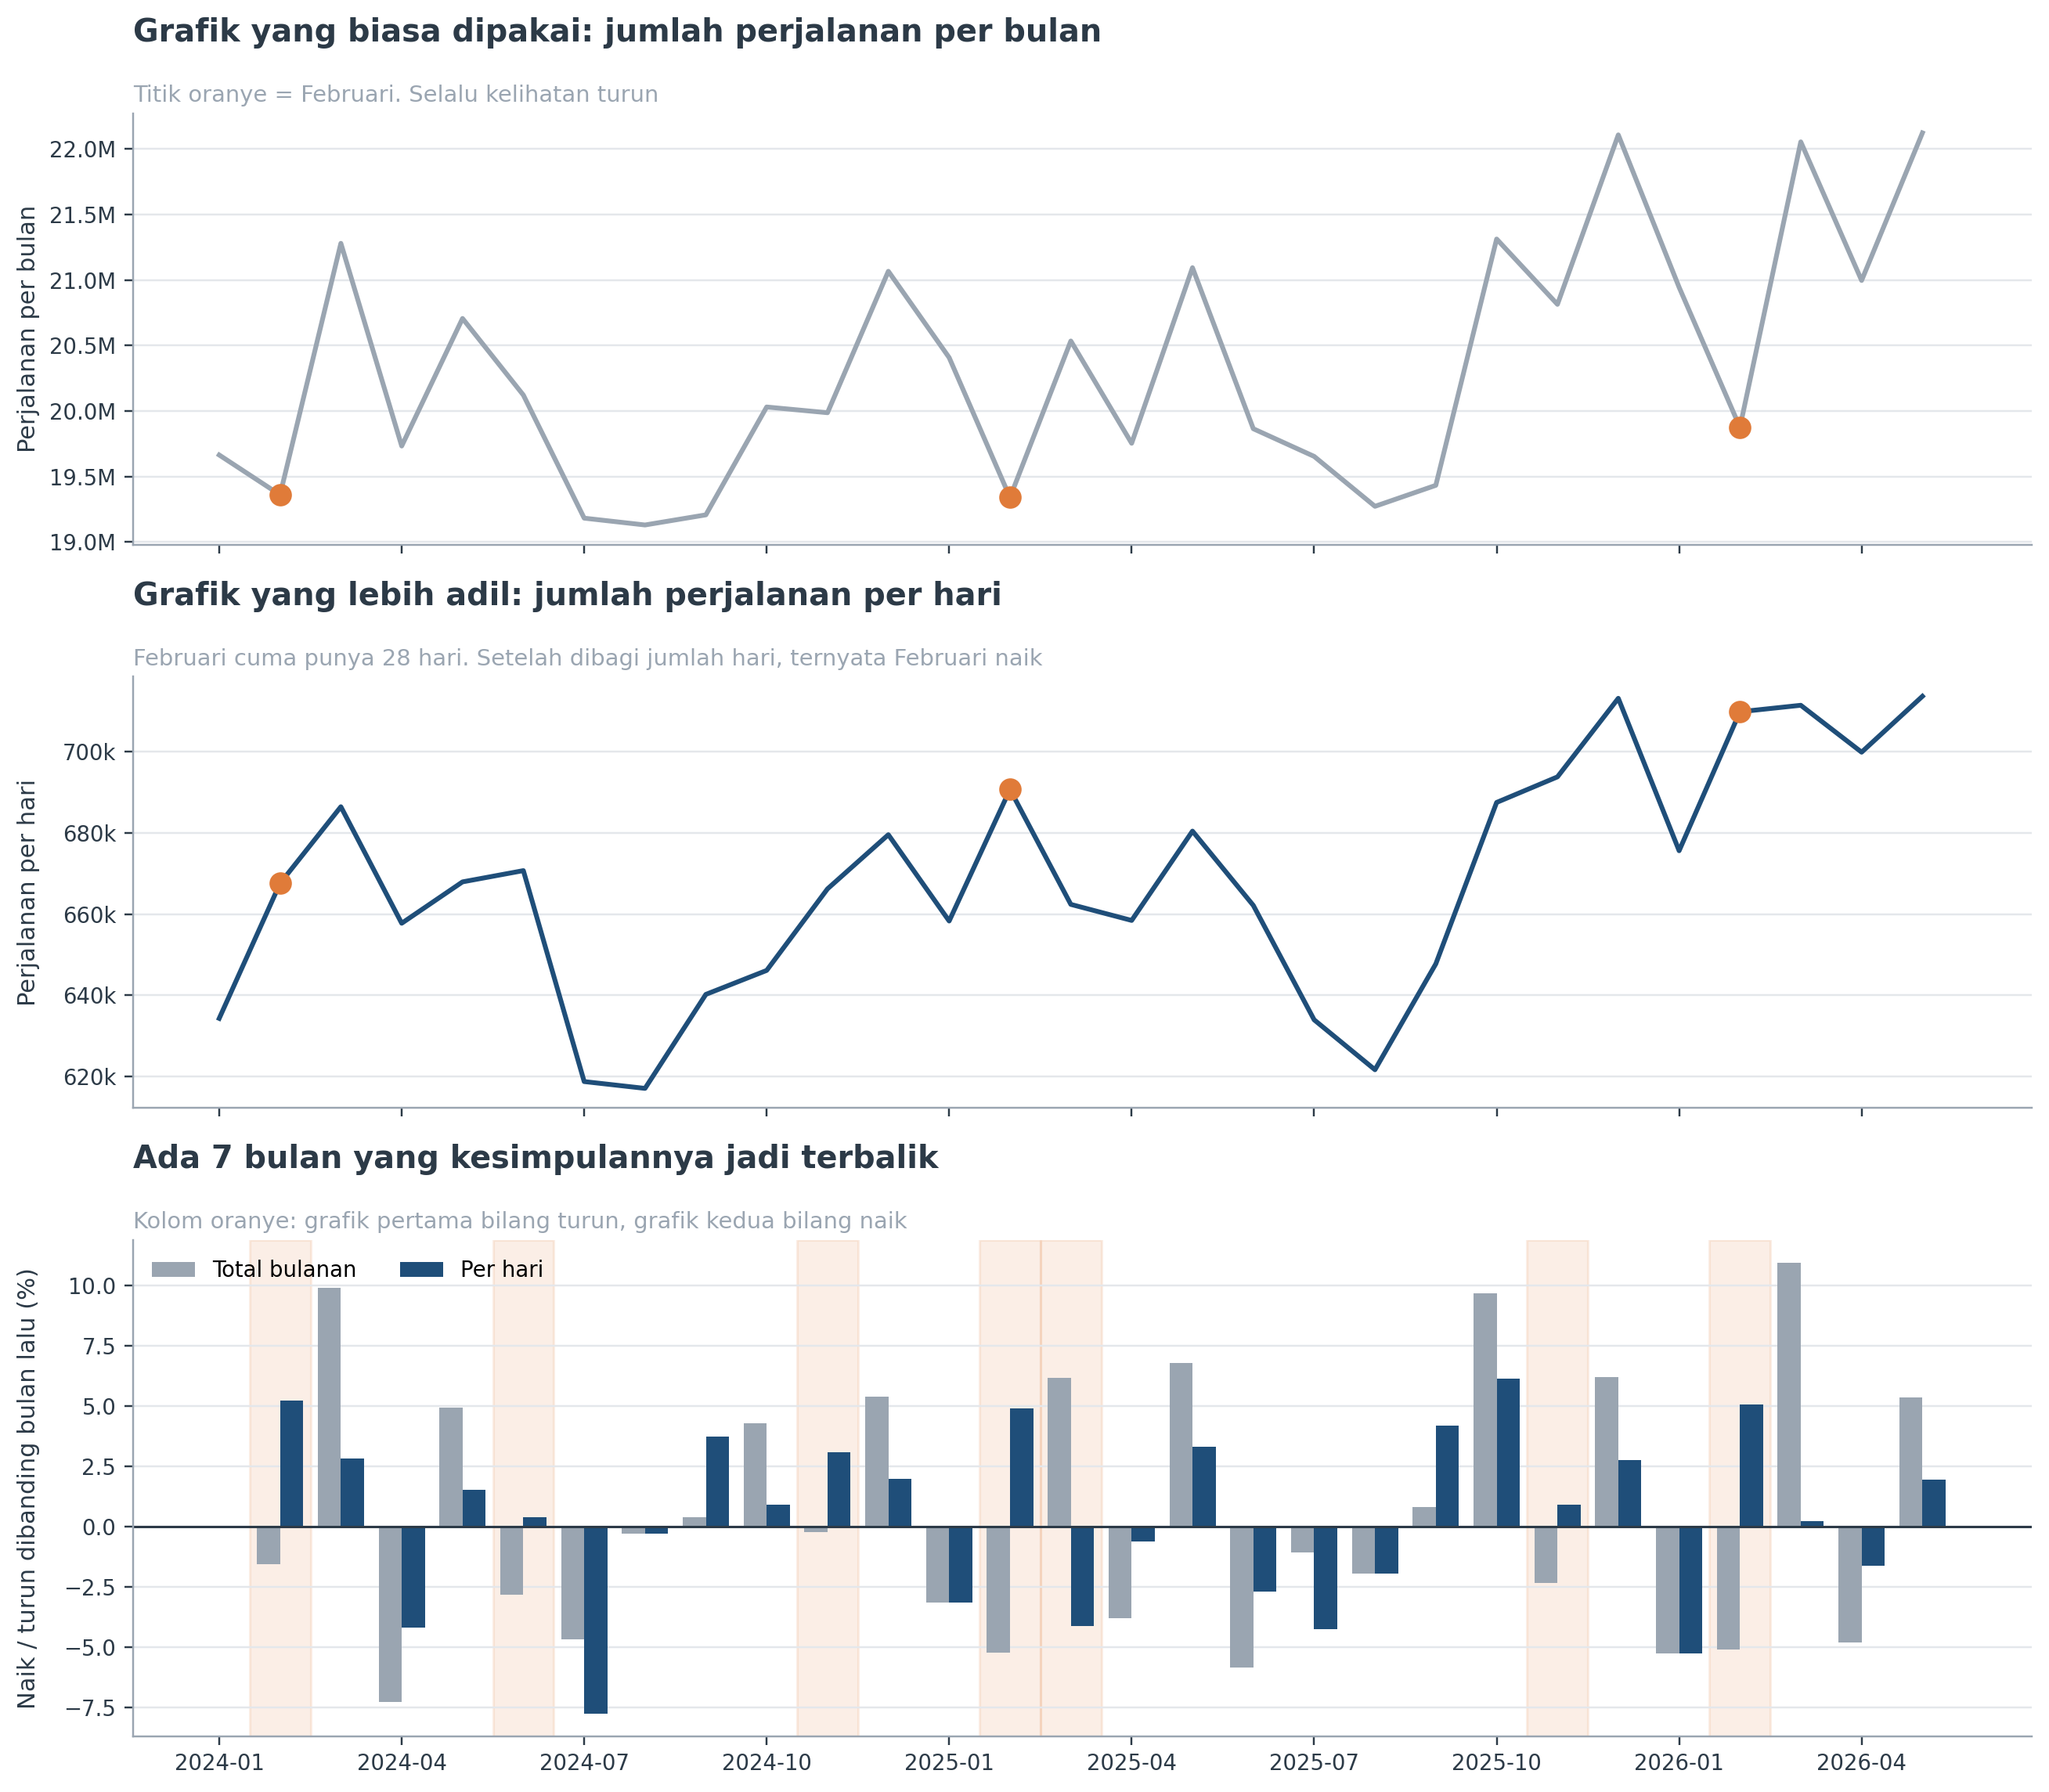

Bulan yang arah perubahannya berlawanan antara kedua versi:

  2024-02 : total  -1.55%   per hari  +5.24%
  2024-06 : total  -2.82%   per hari  +0.41%
  2024-11 : total  -0.22%   per hari  +3.11%
  2025-02 : total  -5.23%   per hari  +4.92%
  2025-03 : total  +6.18%   per hari  -4.10%
  2025-11 : total  -2.34%   per hari  +0.92%
  2026-02 : total  -5.10%   per hari  +5.06%

Seluruh bulan Februari:

  2024-02 : total  -1.55%   per hari  +5.24%
  2025-02 : total  -5.23%   per hari  +4.92%
  2026-02 : total  -5.10%   per hari  +5.06%


In [72]:
months = df_monthly["year_month"].tolist()
x = list(range(len(months)))

# Perubahan bulan ke bulan untuk kedua versi.
# Di sinilah artefak kalender terlihat: tandanya dapat berlawanan.
mom_total = df_monthly["total_demand"].pct_change() * 100
mom_daily = df_monthly["demand_per_day"].pct_change() * 100

feb_idx = [k for k, m in enumerate(months) if m.endswith("-02")]

fig, axes = plt.subplots(3, 1, figsize=(12, 10.5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 1.15]})

# ---------- Panel 1: apa yang terlihat di laporan ----------
ax = axes[0]
ax.plot(x, df_monthly["total_demand"], color=C["muted"], linewidth=2)
ax.scatter([x[k] for k in feb_idx],
           [df_monthly["total_demand"].iloc[k] for k in feb_idx],
           s=70, color=C["secondary"], zorder=5)
ax.yaxis.set_major_formatter(FMT_K)
ax.set_ylabel("Perjalanan per bulan")
titled(ax, "Grafik yang biasa dipakai: jumlah perjalanan per bulan",
       "Titik oranye = Februari. Selalu kelihatan turun")
clean_axes(ax)

# ---------- Panel 2: apa yang sebenarnya terjadi ----------
ax = axes[1]
ax.plot(x, df_monthly["demand_per_day"], color=C["primary"], linewidth=2)
ax.scatter([x[k] for k in feb_idx],
           [df_monthly["demand_per_day"].iloc[k] for k in feb_idx],
           s=70, color=C["secondary"], zorder=5)
ax.yaxis.set_major_formatter(FMT_K)
ax.set_ylabel("Perjalanan per hari")
titled(ax, "Grafik yang lebih adil: jumlah perjalanan per hari",
       "Februari cuma punya 28 hari. Setelah dibagi jumlah hari, ternyata Februari naik")
clean_axes(ax)

# ---------- Panel 3: perbandingan langsung ----------
# Panel ini yang membuat temuannya terbaca tanpa perlu membandingkan
# dua sumbu berskala berbeda.
ax = axes[2]
w = 0.38
ax.bar([i - w/2 for i in x], mom_total, width=w,
       color=C["muted"], label="Total bulanan")
ax.bar([i + w/2 for i in x], mom_daily, width=w,
       color=C["primary"], label="Per hari")
ax.axhline(0, color=C["text"], linewidth=1)

# Tandai bulan yang tandanya berlawanan — inilah artefak kalendernya
flip = [k for k in x
        if pd.notna(mom_total.iloc[k]) and pd.notna(mom_daily.iloc[k])
        and mom_total.iloc[k] * mom_daily.iloc[k] < 0]
for k in flip:
    ax.axvspan(k - 0.5, k + 0.5, color=C["secondary"], alpha=0.12, zorder=0)

ax.set_ylabel("Naik / turun dibanding bulan lalu (%)")
titled(ax, f"Ada {len(flip)} bulan yang kesimpulannya jadi terbalik",
       "Kolom oranye: grafik pertama bilang turun, grafik kedua bilang naik")
ax.legend(loc="upper left", ncol=2)
clean_axes(ax)

sparse_ticks(axes[2], months, every=3)
fig.align_ylabels(axes)
plt.tight_layout()
plt.show()

# ---------- Angka pendukung ----------
print("Bulan yang arah perubahannya berlawanan antara kedua versi:\n")
if flip:
    for k in flip:
        print(f"  {months[k]} : total {mom_total.iloc[k]:+6.2f}%   "
              f"per hari {mom_daily.iloc[k]:+6.2f}%")
else:
    print("  Tidak ada.")

print("\nSeluruh bulan Februari:\n")
for k in feb_idx:
    if k > 0:
        print(f"  {months[k]} : total {mom_total.iloc[k]:+6.2f}%   "
              f"per hari {mom_daily.iloc[k]:+6.2f}%")

In [73]:
# Seberapa besar variasi bulanan yang hanyalah efek jumlah hari
cv_total = df_monthly["total_demand"].std()   / df_monthly["total_demand"].mean()
cv_daily = df_monthly["demand_per_day"].std() / df_monthly["demand_per_day"].mean()

print(f"Koefisien variasi total bulanan    : {cv_total:.4f}")
print(f"Koefisien variasi permintaan/hari  : {cv_daily:.4f}")
print(f"Porsi variasi yang merupakan artefak kalender : "
      f"{(1 - cv_daily / cv_total) * 100:.1f}%")

Koefisien variasi total bulanan    : 0.0453
Koefisien variasi permintaan/hari  : 0.0424
Porsi variasi yang merupakan artefak kalender : 6.3%


> **Hasil Step 3 — membersihkan efek kalender**

Bulan punya jumlah hari berbeda: 28, 29, 30, atau 31. Membandingkan total bulanan berarti membandingkan dua hal sekaligus — seberapa ramai per hari, dan berapa hari dalam bulan itu. Keduanya dipisahkan dengan rumus berikut.

```
total bulanan = jumlah hari × permintaan per hari
```

**Temuan 1 — Februari terbalik, tiga tahun berturut-turut**

| Bulan | Total bulanan | Per hari |
|---|---|---|
| Feb 2024 | −1,55% | **+5,24%** |
| Feb 2025 | −5,23% | **+4,92%** |
| Feb 2026 | −5,10% | **+5,06%** |

Laporan bulanan menunjukkan Februari turun sekitar 5%. Kenyataannya permintaan harian **naik** sekitar 5%. Selisih sepuluh poin persentase ini sepenuhnya berasal dari jumlah hari, bukan dari perubahan pasar.

**Temuan 2 — Tujuh bulan berubah kesimpulan, dan yang paling tajam bukan Februari**

```
2025-03 : total +6,18%   per hari −4,10%
```

Maret 2025 terlihat naik 6% di laporan bulanan, padahal permintaan hariannya turun 4%. Kasus ini lebih berisiko daripada Februari karena tampil sebagai kabar baik. Penyebabnya Maret punya 31 hari sementara Februari 28.

Tujuh bulan yang arah kesimpulannya berbalik: 2024-02, 2024-06, 2024-11, 2025-02, 2025-03, 2025-11, 2026-02.

**Temuan 3 — Pertumbuhan nyata setelah dibersihkan, dibandingkan pada bulan yang sama**

| | Jan–Mei 2024 | Jan–Mei 2026 | Perubahan |
|---|---|---|---|
| Permintaan per hari | 662.821 | 702.091 | **+5,9%** |
| Permintaan per sel | 56,1 | 59,2 | **+5,4%** |
| Zona aktif | 261–263 | 261–263 | tetap |

Perbandingan memakai bulan yang sama agar tidak tercampur efek musim. Membandingkan Januari 2024 langsung dengan Mei 2026 akan menghasilkan +12,5%, tetapi angka itu mencampur pertumbuhan dengan perbedaan musim, karena Januari lebih sepi daripada Mei.

Dalam dua tahun, permintaan per hari naik 5,9%. Karena jumlah zona tidak bertambah sementara permintaan per sel naik, pertumbuhan berasal dari **wilayah yang sama menjadi lebih padat**, bukan dari perluasan jangkauan. Implikasinya untuk perencanaan armada adalah penebalan di lokasi yang sudah dilayani, bukan penyebaran ke lokasi baru.

**Temuan 4 — Musiman kuat dan berulang**

Titik terendah jatuh pada Juli–Agustus (617–634 ribu per hari) dan titik tertinggi pada Desember sampai awal tahun (sekitar 713 ribu per hari). Pola ini berulang pada 2024 dan 2025; data 2026 baru sampai Mei sehingga musim sepinya belum terlihat.

Keberulangan ini merupakan petunjuk awal bahwa variasi permintaan memiliki pola, bukan acak.

**Temuan tambahan — Efek kalender mengubah arah, tetapi besarnya kecil**

Efek jumlah hari hanya menjelaskan 6,3% naik-turunnya angka bulanan (koefisien variasi 0,045 untuk total bulanan dan 0,042 untuk permintaan per hari). Efek kalender cukup untuk membalik arah kesimpulan di bulan-bulan yang perubahannya kecil, tetapi tidak menjelaskan sebagian besar variasi bulanan.

**Temuan tambahan — Jumlah zona aktif berfluktuasi**

Jumlah zona aktif berubah antara 261 dan 263 antar bulan. Terdapat zona yang pada bulan tertentu tidak menghasilkan permintaan sama sekali. Hal ini relevan sebagai dasar penentuan zona mana yang layak dimodelkan.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Mengarah **tidak memadai**: 7 dari 28 perubahan bulanan menyesatkan arahnya |
| Variasi permintaan punya pola | Mengarah **ya**: musim berulang pada 2024 dan 2025 |

**Kaitan dengan argumen utama**

Step ini adalah contoh pertama dari mekanisme yang berulang di seluruh analisis: satu angka agregat dapat menyembunyikan dua hal yang bergerak berlawanan. Di sini yang tersembunyi hanya jumlah hari. Pola yang sama perlu diperiksa pada metrik lain.

> **Keputusan:** perbandingan bulanan berikutnya memakai permintaan per hari dan bulan yang sama · pertumbuhan dua tahun +5,9%, berasal dari kepadatan, bukan perluasan jangkauan · musiman berulang menjadi petunjuk awal bahwa variasi berpola

---

# STEP 4 — Perbandingan Year-over-Year

**Tujuan:** membandingkan bulan yang sama antar tahun untuk melihat apakah permintaan benar-benar tumbuh, dan apakah lajunya tetap atau berubah.

**Kenapa diperlukan:** Juli selalu sepi dan Desember selalu ramai, sehingga membandingkan bulan berurutan menyesatkan. Perbandingan yang sahih adalah Januari dengan Januari.

**Kaitan dengan pertanyaan bisnis:**

| Pertanyaan | Peran step ini |
|---|---|
| Pertanyaan pendukung 1 — apakah pertumbuhan nyata? | Dijawab dengan menghilangkan efek musim |
| Rancangan Phase 6 | Menunjukkan apakah model perlu menangkap tren |

**Input:** permintaan per hari dari Step 3.

**Expected output:**
1. Tabel permintaan per hari — bulan sebagai baris, tahun sebagai kolom
2. Tabel persen perubahan — 2024 → 2025 dan 2025 → 2026
3. Grafik dua panel — pola musim tiap tahun, dan deret pertumbuhan Jan 2025 sampai Mei 2026

**Cara interpretasi:**
- Tabel dibaca ke samping, bukan ke bawah
- Angka positif berarti lebih ramai dari bulan yang sama tahun lalu
- 2024 tidak memiliki angka pertumbuhan karena data 2023 tidak tersedia; 2024 berfungsi sebagai pembanding
- Kolom 2025 → 2026 kosong mulai Juni karena data berakhir Mei 2026

In [74]:
sql = f"""
SELECT
    year,
    month,
    COUNT(DISTINCT request_date)                AS n_days,
    SUM(demand)                                 AS total_demand,
    SUM(demand) / COUNT(DISTINCT request_date)  AS demand_per_day
FROM {MART_DEMAND}
GROUP BY year, month
ORDER BY month, year
"""

df_yoy = run_query(sql)

# Pemeriksaan kelengkapan bulan.
# Bulan di ujung periode data bisa saja terpotong, misalnya hanya
# berisi 10 hari. Bulan seperti itu tidak boleh dibandingkan
# dengan bulan yang sama di tahun lain karena angkanya tidak setara.
import calendar

df_yoy["n_days_kalender"] = df_yoy.apply(
    lambda r: calendar.monthrange(int(r["year"]), int(r["month"]))[1], axis=1
)
df_yoy["lengkap"] = df_yoy["n_days"] == df_yoy["n_days_kalender"]

tidak_lengkap = df_yoy[~df_yoy["lengkap"]]
if len(tidak_lengkap) > 0:
    print("PERINGATAN - bulan berikut tidak lengkap dan dikeluarkan:\n")
    print(tidak_lengkap[["year", "month", "n_days", "n_days_kalender"]]
          .to_string(index=False))
    print()
else:
    print(f"Seluruh {len(df_yoy)} bulan lengkap jumlah harinya.\n")

# Nama bulan agar tabel mudah dibaca
NAMA_BULAN = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",  5: "Mei",  6: "Jun",
    7: "Jul", 8: "Agu", 9: "Sep", 10: "Okt", 11: "Nov", 12: "Des",
}
df_yoy["bulan"] = df_yoy["month"].map(NAMA_BULAN)

# Hanya bulan lengkap yang masuk perbandingan
pivot_yoy = (
    df_yoy[df_yoy["lengkap"]]
    .pivot(index="month", columns="year", values="demand_per_day")
    .sort_index()
)
pivot_yoy.index = [NAMA_BULAN[m] for m in pivot_yoy.index]
pivot_yoy.index.name = "Bulan"
pivot_yoy.columns.name = "Tahun"

print("Rata-rata perjalanan per hari, bulan yang sama antar tahun:")
pivot_yoy.style.format("{:,.0f}", na_rep="—")

Rows returned : 29
Bytes billed  : 0.0000 GB
Seluruh 29 bulan lengkap jumlah harinya.

Rata-rata perjalanan per hari, bulan yang sama antar tahun:


Tahun,2024,2025,2026
Bulan,,,
Jan,"634,338","658,317","675,625"
Feb,"667,587","690,715","709,845"
Mar,"686,457","662,411","711,441"
Apr,"657,765","658,464","699,889"
Mei,"667,956","680,455","713,656"
Jun,"670,727","662,162",—
Jul,"618,785","633,992",—
Agu,"617,104","621,697",—
Sep,"640,249","647,762",—


In [75]:
# Perubahan year-over-year pada bulan yang sama.
# pct_change membandingkan tiap tahun dengan tahun sebelumnya,
# sehingga tahun pertama selalu kosong dan tidak ditampilkan.
yoy_change = pivot_yoy.pct_change(axis=1) * 100
yoy_change = yoy_change.where(pivot_yoy.notna())   # sel tanpa data tidak dianggap 0
yoy_change = yoy_change.iloc[:, 1:]
tahun = list(pivot_yoy.columns)
yoy_change.columns = [f"{tahun[i]} → {tahun[i+1]}" for i in range(len(tahun) - 1)]
yoy_change.columns.name = "Perubahan (%)"

yoy_change.style.format("{:+.1f}%", na_rep="—")

Perubahan (%),2024 → 2025,2025 → 2026
Bulan,,
Jan,+3.8%,+2.6%
Feb,+3.5%,+2.8%
Mar,-3.5%,+7.4%
Apr,+0.1%,+6.3%
Mei,+1.9%,+4.9%
Jun,-1.3%,—
Jul,+2.5%,—
Agu,+0.7%,—
Sep,+1.2%,—


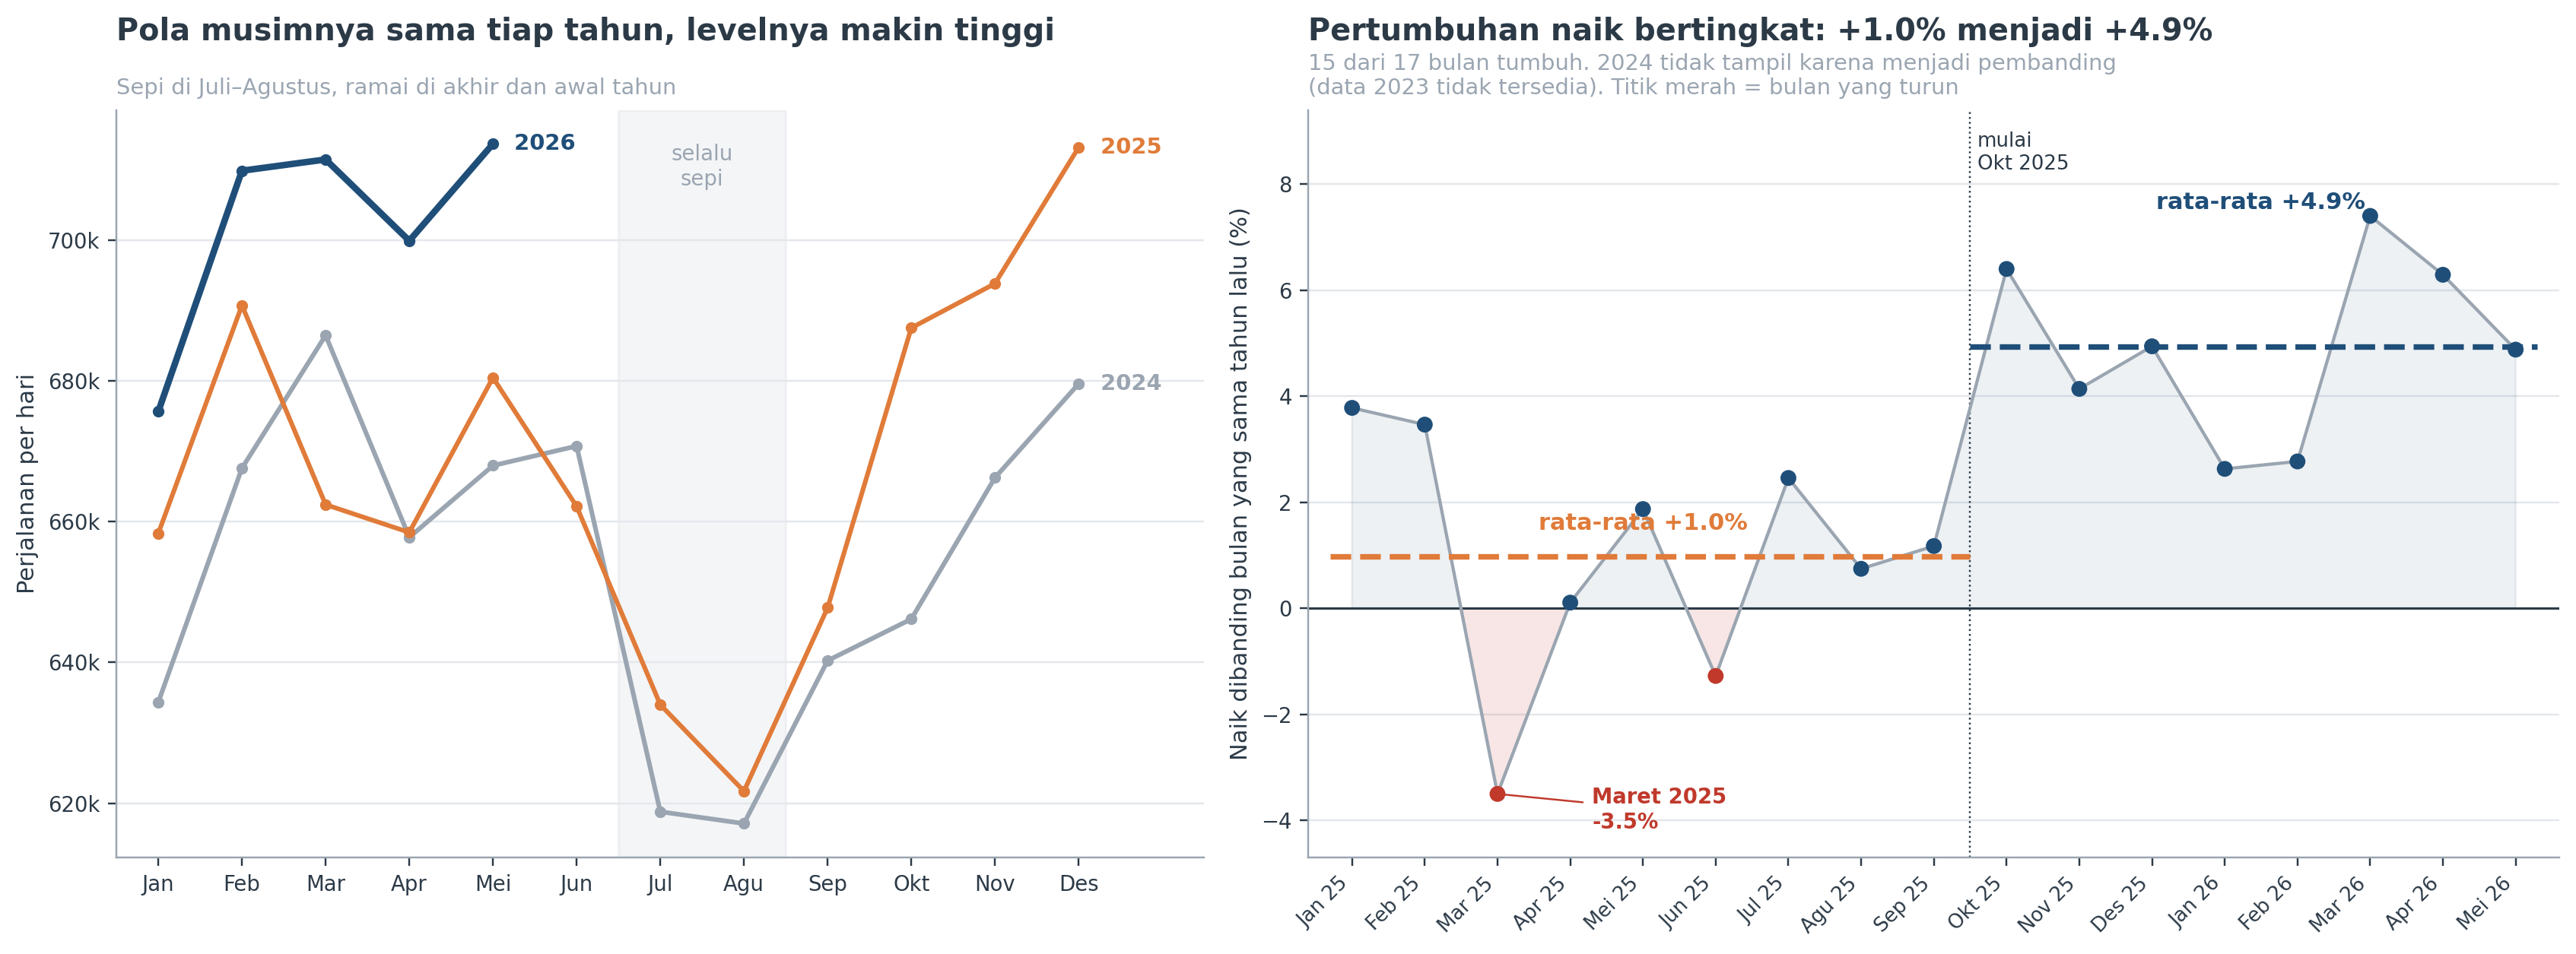

Bulan tumbuh           : 15 dari 17
Rata-rata sebelum Okt 25 : +0.98%  (9 bulan)
Rata-rata sejak Okt 25   : +4.93%  (8 bulan)
Maret 2025               : -3.50%


In [76]:
bulan = list(pivot_yoy.index)
x     = np.arange(len(bulan))
warna = {2024: C["muted"], 2025: C["secondary"], 2026: C["primary"]}
c0, c1 = yoy_change.columns[0], yoy_change.columns[1]

# Susun perubahan YoY menjadi satu deret waktu yang urut:
# Jan 2025 ... Des 2025 (dibanding 2024), lalu Jan 2026 ... Mei 2026 (dibanding 2025)
deret = []
for b in bulan:
    deret.append((f"{b} 25", yoy_change.loc[b, c0]))
for b in bulan:
    v = yoy_change.loc[b, c1]
    if pd.notna(v):
        deret.append((f"{b} 26", v))
label_t = [d[0] for d in deret]
nilai_t = np.array([d[1] for d in deret])
xt      = np.arange(len(deret))

# Titik perubahan laju: Oktober 2025
k_okt   = label_t.index("Okt 25")
avg_pra = nilai_t[:k_okt].mean()
avg_pas = nilai_t[k_okt:].mean()
n_pos   = int((nilai_t > 0).sum())
k_mar   = label_t.index("Mar 25")

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8),
                         gridspec_kw={"width_ratios": [1, 1.15]})

# ================= KIRI — Temuan 4: musiman berulang =================
ax = axes[0]
for th in pivot_yoy.columns:
    y = pivot_yoy[th]
    ax.plot(x, y, color=warna.get(th, C["accent"]),
            linewidth=2.8 if th == pivot_yoy.columns[-1] else 2,
            marker="o", markersize=4)
    last = y.last_valid_index()
    label_last(ax, bulan.index(last), y[last], f" {th}", warna.get(th, C["accent"]))

ks, ke = bulan.index("Jul"), bulan.index("Agu")
ax.axvspan(ks - 0.5, ke + 0.5, color=C["muted"], alpha=0.10, zorder=0)
ax.text((ks + ke) / 2, pivot_yoy.max().max(), "selalu\nsepi",
        ha="center", va="top", fontsize=9, color=C["muted"])

ax.set_xticks(x)
ax.set_xticklabels(bulan)
ax.set_xlim(-0.5, len(bulan) + 0.5)
ax.yaxis.set_major_formatter(FMT_K)
ax.set_ylabel("Perjalanan per hari")
titled(ax, "Pola musimnya sama tiap tahun, levelnya makin tinggi",
       "Sepi di Juli–Agustus, ramai di akhir dan awal tahun")
clean_axes(ax)

# ============ KANAN — Temuan 1, 2, 3 dalam satu deret waktu ============
ax = axes[1]

# Area positif dan negatif
ax.axhline(0, color=C["text"], linewidth=1)
ax.fill_between(xt, nilai_t, 0, where=nilai_t >= 0,
                color=C["primary"], alpha=0.08, interpolate=True)
ax.fill_between(xt, nilai_t, 0, where=nilai_t < 0,
                color=C["alert"], alpha=0.12, interpolate=True)

ax.plot(xt, nilai_t, color=C["muted"], linewidth=1.4, zorder=3)
ax.scatter(xt, nilai_t, s=34, zorder=4,
           color=[C["alert"] if v < 0 else C["primary"] for v in nilai_t])

# Temuan 2: rata-rata sebelum dan sesudah Oktober 2025
ax.hlines(avg_pra, -0.3, k_okt - 0.5, colors=C["secondary"],
          linestyles="--", linewidth=2.4, zorder=5)
ax.hlines(avg_pas, k_okt - 0.5, len(xt) - 0.7, colors=C["primary"],
          linestyles="--", linewidth=2.4, zorder=5)
ax.axvline(k_okt - 0.5, color=C["text"], linewidth=0.8, linestyle=":")

ax.text((k_okt - 1) / 2, avg_pra + 0.5, f"rata-rata {avg_pra:+.1f}%",
        ha="center", fontsize=10, fontweight="semibold", color=C["secondary"])
ax.text((k_okt + len(xt) - 1) / 2, avg_pas + 2.6, f"rata-rata {avg_pas:+.1f}%",
        ha="center", fontsize=10, fontweight="semibold", color=C["primary"])
ax.text(k_okt - 0.4, ax.get_ylim()[1] if False else nilai_t.max() + 1.6,
        "mulai\nOkt 2025", fontsize=8.5, color=C["text"], va="top")

# Temuan 3: Maret 2025
ax.annotate(f"Maret 2025\n{nilai_t[k_mar]:+.1f}%",
            xy=(k_mar, nilai_t[k_mar]), xytext=(k_mar + 1.3, nilai_t[k_mar] - 0.3),
            fontsize=9, color=C["alert"], fontweight="semibold", va="center",
            arrowprops=dict(arrowstyle="-", color=C["alert"], linewidth=0.8))

ax.set_xticks(xt)
ax.set_xticklabels(label_t, rotation=45, ha="right", fontsize=8.5)
ax.set_xlim(-0.6, len(xt) - 0.4)
ax.set_ylim(min(nilai_t.min(), 0) - 1.2, nilai_t.max() + 2)
ax.set_ylabel("Naik dibanding bulan yang sama tahun lalu (%)")
titled(ax, f"Pertumbuhan naik bertingkat: {avg_pra:+.1f}% menjadi {avg_pas:+.1f}%",
       f"{n_pos} dari {len(nilai_t)} bulan tumbuh. 2024 tidak tampil karena menjadi pembanding\n"
       "(data 2023 tidak tersedia). Titik merah = bulan yang turun")
clean_axes(ax)

plt.tight_layout()
plt.show()

print(f"Bulan tumbuh           : {n_pos} dari {len(nilai_t)}")
print(f"Rata-rata sebelum Okt 25 : {avg_pra:+.2f}%  ({k_okt} bulan)")
print(f"Rata-rata sejak Okt 25   : {avg_pas:+.2f}%  ({len(nilai_t) - k_okt} bulan)")
print(f"Maret 2025               : {nilai_t[k_mar]:+.2f}%")

> **Cara membaca grafik**

**Panel kiri — pola musim tiap tahun**

Sumbu bawah adalah bulan Januari sampai Desember. Sumbu kiri adalah rata-rata jumlah perjalanan per hari. Setiap garis mewakili satu tahun: abu-abu untuk 2024, oranye untuk 2025, biru untuk 2026.

Bandingkan garis-garis itu pada bulan yang sama. Bila garis biru berada di atas oranye, dan oranye di atas abu-abu, berarti bulan itu lebih ramai dari tahun sebelumnya.

Perhatikan juga bentuk garisnya. Ketiganya turun di area arsir Juli–Agustus dan naik menjelang akhir tahun. Bentuk yang sama inilah yang disebut pola musim berulang.

Garis biru berhenti di Mei karena data berakhir Mei 2026.

**Panel kanan — pertumbuhan dari waktu ke waktu**

Sumbu bawah adalah urutan waktu, dari Januari 2025 sampai Mei 2026. Sumbu kiri adalah persen kenaikan dibanding bulan yang sama tahun sebelumnya.

Setiap titik adalah satu bulan:
- Titik di atas garis nol berarti bulan itu lebih ramai dari tahun lalu
- Titik di bawah garis nol, berwarna merah, berarti lebih sepi dari tahun lalu

Dua garis putus-putus adalah rata-rata tiap fase:
- Garis oranye di kiri adalah rata-rata Januari–September 2025, sekitar +1,0%
- Garis biru di kanan adalah rata-rata Oktober 2025–Mei 2026, sekitar +4,9%

Garis titik-titik vertikal menandai Oktober 2025, bulan ketika laju pertumbuhan mulai naik. Semakin jauh jarak antara dua garis putus-putus, semakin besar percepatannya.

Tahun 2024 tidak muncul sebagai titik karena menjadi pembanding. Seluruh titik tahun 2025 adalah hasil perbandingan terhadap 2024.

> **Hasil Step 4 — perbandingan year-over-year**

Tabel dibaca ke samping: Januari dibanding Januari, Februari dibanding Februari. Cara ini menghilangkan efek musim, karena Juli memang selalu sepi dan Desember selalu ramai.

**Temuan 1 — Permintaan tumbuh hampir di setiap bulan**

Dari 17 perbandingan yang tersedia, 15 bernilai positif. Hanya Maret 2025 (−3,5%) dan Juni 2025 (−1,3%) yang lebih sepi dari tahun sebelumnya. Kenaikan 5,9% dalam dua tahun karena itu bukan kebetulan satu dua bulan, melainkan pertumbuhan yang berulang.

**Temuan 2 — Pertumbuhan naik bertingkat sejak Oktober 2025**

| Fase | Periode | Rata-rata pertumbuhan |
|---|---|---|
| Sebelum | Jan–Sep 2025 | +1,0% |
| Sesudah | Okt 2025–Mei 2026 | **+4,9%** |

Sampai September 2025 pertumbuhan hampir datar. Mulai Oktober 2025 lajunya naik hampir lima kali lipat dan bertahan delapan bulan berturut-turut. Permintaan tidak tumbuh dengan laju tetap.

**Temuan 3 — Maret 2025 adalah bulan yang janggal**

Maret turun 3,5% pada 2025, lalu naik paling tinggi pada 2026 (+7,4%). Sebagian kenaikan 2026 hanyalah pemulihan dari titik rendah tahun sebelumnya. Maret 2025 juga bulan yang arah kesimpulannya berbalik ketika efek kalender dibersihkan.

Penyebabnya belum dapat ditentukan dari data ini. Kandidat yang perlu diuji terpisah adalah perubahan kebijakan lalu lintas Manhattan pada awal 2025 dan faktor cuaca. Dicatat sebagai kejanggalan, bukan sebagai temuan sebab-akibat.

**Temuan 4 — Pola musim berulang, levelnya makin tinggi**

Pada 2024 dan 2025, titik terendah selalu Juli–Agustus dan titik tertinggi selalu akhir hingga awal tahun. Bentuknya sama, hanya posisinya naik setiap tahun.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Mengarah **tidak memadai**: laju pertumbuhan berubah dari +1,0% menjadi +4,9%, sehingga satu angka rata-rata tahunan tidak cukup |
| Variasi permintaan punya pola | Mengarah **ya**: bentuk musim sama pada 2024 dan 2025 |

**Keterbatasan**

Tahun 2024 tidak memiliki angka pertumbuhan karena data 2023 tidak tersedia; 2024 berfungsi sebagai pembanding. Perbandingan 2025 → 2026 hanya mencakup Januari–Mei, sehingga percepatan pertumbuhan belum dapat dipastikan berlaku untuk musim sepi Juli–Agustus 2026.

**Kaitannya dengan forecasting**

Periode validasi Phase 6 (Oktober–Desember 2025) dan periode test (Januari–Mei 2026) seluruhnya jatuh pada fase pertumbuhan +4,9%, sementara sebagian besar data latih berasal dari fase +1,0%. Model yang hanya meniru pola lama berisiko memprediksi terlalu rendah. Model perlu menangkap tren, bukan hanya musim.

> **Keputusan:** pertumbuhan nyata di 15 dari 17 bulan · laju naik dari +1,0% menjadi +4,9% sejak Oktober 2025 · Maret 2025 dicatat sebagai kejanggalan · model Phase 6 wajib menangkap tren

---

# STEP 5 — Dekomposisi Identitas 

**Tujuan:** mencari tahu kenapa tarif naik — karena perjalanan makin jauh, atau karena harga per mil yang naik.

**Kenapa diperlukan:** rata-rata yang bergerak sedikit dapat tersusun dari beberapa komponen yang bergerak berlawanan dan saling menutupi. Rumus di bawah benar secara definisi, sehingga hasil pemecahannya tidak dapat dibantah.

**Rumus yang dipakai:**

```
bayar sekali jalan     = jarak sekali jalan × bayar per mil
bayaran per perjalanan = lama sekali jalan  × bayaran per menit
lama sekali jalan      = jarak sekali jalan ÷ kecepatan × 60
```

Nama kolom di data:

```
fare_per_trip    = miles_per_trip   × fare_per_mile
pay_per_trip     = minutes_per_trip × pay_per_minute
minutes_per_trip = miles_per_trip   ÷ speed_mph × 60
```

**Hipotesis yang diuji:**

| Kode | Pertanyaan | Dijawab oleh |
|---|---|---|
| H5 | Apakah pendapatan pengemudi tergerus? | bayaran per menit |
| H6 | Apakah kenaikan tarif hanya moderat? | bayar per mil dibanding bayar sekali jalan |
| H7 | Apakah kemacetan menjelaskan perubahan lama perjalanan? | kecepatan dan lama sekali jalan |

**Input:** `mart_business_metrics`, dihitung per bulan.

**Expected output:**
1. Tabel 29 bulan berisi seluruh komponen
2. Pemeriksaan bahwa rumus cocok dengan data
3. Tabel perbandingan bulan yang sama antar tahun
4. Grafik angka asli tiap bulan
5. Grafik perubahan Januari–Mei 2024 dibanding 2026

**Cara interpretasi:**
- Perhatikan arah gerak tiap komponen. Bila bergerak berlawanan, angka tarif per perjalanan menyembunyikan perubahan yang sebenarnya lebih besar
- Selalu bandingkan bulan yang sama atau rata-rata Januari–Mei. Membandingkan bulan berbeda, misalnya Januari dengan Mei, akan tercampur efek musim

In [77]:
sql = f"""
SELECT
    year_month,
    SUM(total_trips)                                                      AS total_trips,

    -- komponen tarif
    SAFE_DIVIDE(SUM(total_trip_miles),   SUM(valid_distance_trips))       AS miles_per_trip,
    SAFE_DIVIDE(SUM(total_base_fare),    SUM(total_trip_miles))           AS fare_per_mile,
    SAFE_DIVIDE(SUM(total_base_fare),    SUM(valid_fare_trips))           AS fare_per_trip,

    -- komponen pendapatan pengemudi
    SAFE_DIVIDE(SUM(total_trip_seconds), SUM(valid_duration_trips)) / 60  AS minutes_per_trip,
    SAFE_DIVIDE(SUM(total_driver_pay),   SUM(total_trip_seconds) / 60)    AS pay_per_minute,
    SAFE_DIVIDE(SUM(total_driver_pay),   SUM(valid_driver_pay_trips))     AS pay_per_trip,

    -- kecepatan dan porsi pengemudi
    SAFE_DIVIDE(SUM(total_trip_miles),   SUM(total_trip_seconds) / 3600)  AS speed_mph,
    SAFE_DIVIDE(SUM(total_driver_pay),   SUM(total_base_fare)) * 100      AS pay_to_fare_pct
FROM {MART_BUSINESS}
GROUP BY year_month
ORDER BY year_month
"""

df_identity = run_query(sql)

# Kolom bantu tahun dan bulan, dipakai di seluruh cell berikutnya
di = df_identity.copy()
di["year"]  = di["year_month"].str[:4].astype(int)
di["month"] = di["year_month"].str[-2:].astype(int)

df_identity.style.format({
    "total_trips":      "{:,.0f}",
    "miles_per_trip":   "{:.2f}",
    "fare_per_mile":    "${:.2f}",
    "fare_per_trip":    "${:.2f}",
    "minutes_per_trip": "{:.1f}",
    "pay_per_minute":   "${:.3f}",
    "pay_per_trip":     "${:.2f}",
    "speed_mph":        "{:.1f}",
    "pay_to_fare_pct":  "{:.1f}%",
})

Rows returned : 29
Bytes billed  : 0.0000 GB


,year_month,total_trips,miles_per_trip,fare_per_mile,fare_per_trip,minutes_per_trip,pay_per_minute,pay_per_trip,speed_mph,pay_to_fare_pct
0,2024-01,"19,664,474",4.84,$4.95,$23.97,18.5,$0.987,$18.27,15.7,76.3%
1,2024-02,"19,360,028",4.93,$4.92,$24.28,19.2,$0.993,$19.08,15.4,78.6%
2,2024-03,"21,280,168",4.95,$5.16,$25.55,19.6,$0.995,$19.56,15.1,76.5%
3,2024-04,"19,732,951",5.04,$5.14,$25.89,19.8,$0.999,$19.81,15.2,76.5%
4,2024-05,"20,706,623",5.15,$5.28,$27.17,21.0,$0.989,$20.82,14.7,76.6%
5,2024-06,"20,121,823",5.17,$5.22,$27.00,20.7,$1.003,$20.73,15.0,76.7%
6,2024-07,"19,182,325",5.15,$4.98,$25.65,19.7,$1.005,$19.77,15.7,77.0%
7,2024-08,"19,130,228",5.18,$5.04,$26.14,19.8,$1.009,$20.02,15.7,76.6%
8,2024-09,"19,207,457",5.21,$5.26,$27.40,21.3,$0.996,$21.21,14.7,77.4%
9,2024-10,"20,030,788",5.20,$5.21,$27.09,20.9,$1.002,$20.92,14.9,77.2%


In [78]:
# ---------- Pemeriksaan rumus ----------
# fare_per_trip seharusnya sama dengan miles_per_trip × fare_per_mile.
# Selisih kecil wajar karena jumlah perjalanan dengan jarak valid
# tidak persis sama dengan jumlah perjalanan dengan tarif valid.
hitung  = di["miles_per_trip"] * di["fare_per_mile"]
selisih = (hitung - di["fare_per_trip"]) / di["fare_per_trip"] * 100

print("Selisih antara rumus dan data (persen):")
print(f"  terkecil  : {selisih.min():+.3f}%")
print(f"  terbesar  : {selisih.max():+.3f}%")
print(f"  rata-rata : {selisih.mean():+.3f}%")
print("\nSelisih di bawah 1% berarti rumus cocok dengan data.")

Selisih antara rumus dan data (persen):
  terkecil  : -0.955%
  terbesar  : +0.011%
  rata-rata : -0.091%

Selisih di bawah 1% berarti rumus cocok dengan data.


In [79]:
from IPython.display import display

NAMA_BLN = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"]

tabel_yoy = [
    ("fare_per_trip",    "Bayar sekali jalan (dolar)",  "${:.2f}"),
    ("fare_per_mile",    "Bayar per mil (dolar)",       "${:.2f}"),
    ("miles_per_trip",   "Jarak sekali jalan (mil)",    "{:.2f}"),
    ("minutes_per_trip", "Lama sekali jalan (menit)",   "{:.1f}"),
    ("speed_mph",        "Kecepatan (mil per jam)",     "{:.1f}"),
    ("pay_per_minute",   "Bayaran per menit (dolar)",   "${:.3f}"),
]

for c, judul, fmt in tabel_yoy:
    t = di.pivot(index="month", columns="year", values=c)
    t.index = [NAMA_BLN[m - 1] for m in t.index]
    t.index.name, t.columns.name = "Bulan", "Tahun"
    print(f"\n{judul}")
    display(t.style.format(fmt, na_rep="—"))


Bayar sekali jalan (dolar)


Tahun,2024,2025,2026
Bulan,,,
Jan,$23.97,$24.29,$25.78
Feb,$24.28,$24.98,$26.64
Mar,$25.55,$27.70,$27.61
Apr,$25.89,$26.49,$27.28
Mei,$27.17,$28.10,$28.70
Jun,$27.00,$28.05,—
Jul,$25.65,$26.59,—
Agu,$26.14,$26.73,—
Sep,$27.40,$28.69,—



Bayar per mil (dolar)


Tahun,2024,2025,2026
Bulan,,,
Jan,$4.95,$5.00,$5.53
Feb,$4.92,$5.09,$5.73
Mar,$5.16,$5.49,$5.75
Apr,$5.14,$5.27,$5.60
Mei,$5.28,$5.51,$5.78
Jun,$5.22,$5.47,—
Jul,$4.98,$5.20,—
Agu,$5.04,$5.09,—
Sep,$5.26,$5.56,—



Jarak sekali jalan (mil)


...

Tahun,2024,2025,2026
Bulan,,,
Jan,18.5,18.2,18.8
Feb,19.2,18.8,19.4
Mar,19.6,19.2,19.2
Apr,19.8,19.6,19.6
Mei,21.0,20.7,20.5
Jun,20.7,20.3,—
Jul,19.7,19.8,—
Agu,19.8,19.8,—
Sep,21.3,21.0,—



Kecepatan (mil per jam)


Tahun,2024,2025,2026
Bulan,,,
Jan,15.7,16.0,14.8
Feb,15.4,15.6,14.4
Mar,15.1,15.7,15.0
Apr,15.2,15.4,14.9
Mei,14.7,14.7,14.5
Jun,15.0,15.1,—
Jul,15.7,15.5,—
Agu,15.7,15.8,—
Sep,14.7,14.8,—



Bayaran per menit (dolar)


Tahun,2024,2025,2026
Bulan,,,
Jan,$0.987,$1.023,$1.058
Feb,$0.993,$1.015,$1.060
Mar,$0.995,$1.061,$1.085
Apr,$0.999,$1.036,$1.066
Mei,$0.989,$1.046,$1.071
Jun,$1.003,$1.064,—
Jul,$1.005,$1.047,—
Agu,$1.009,$1.053,—
Sep,$0.996,$1.051,—


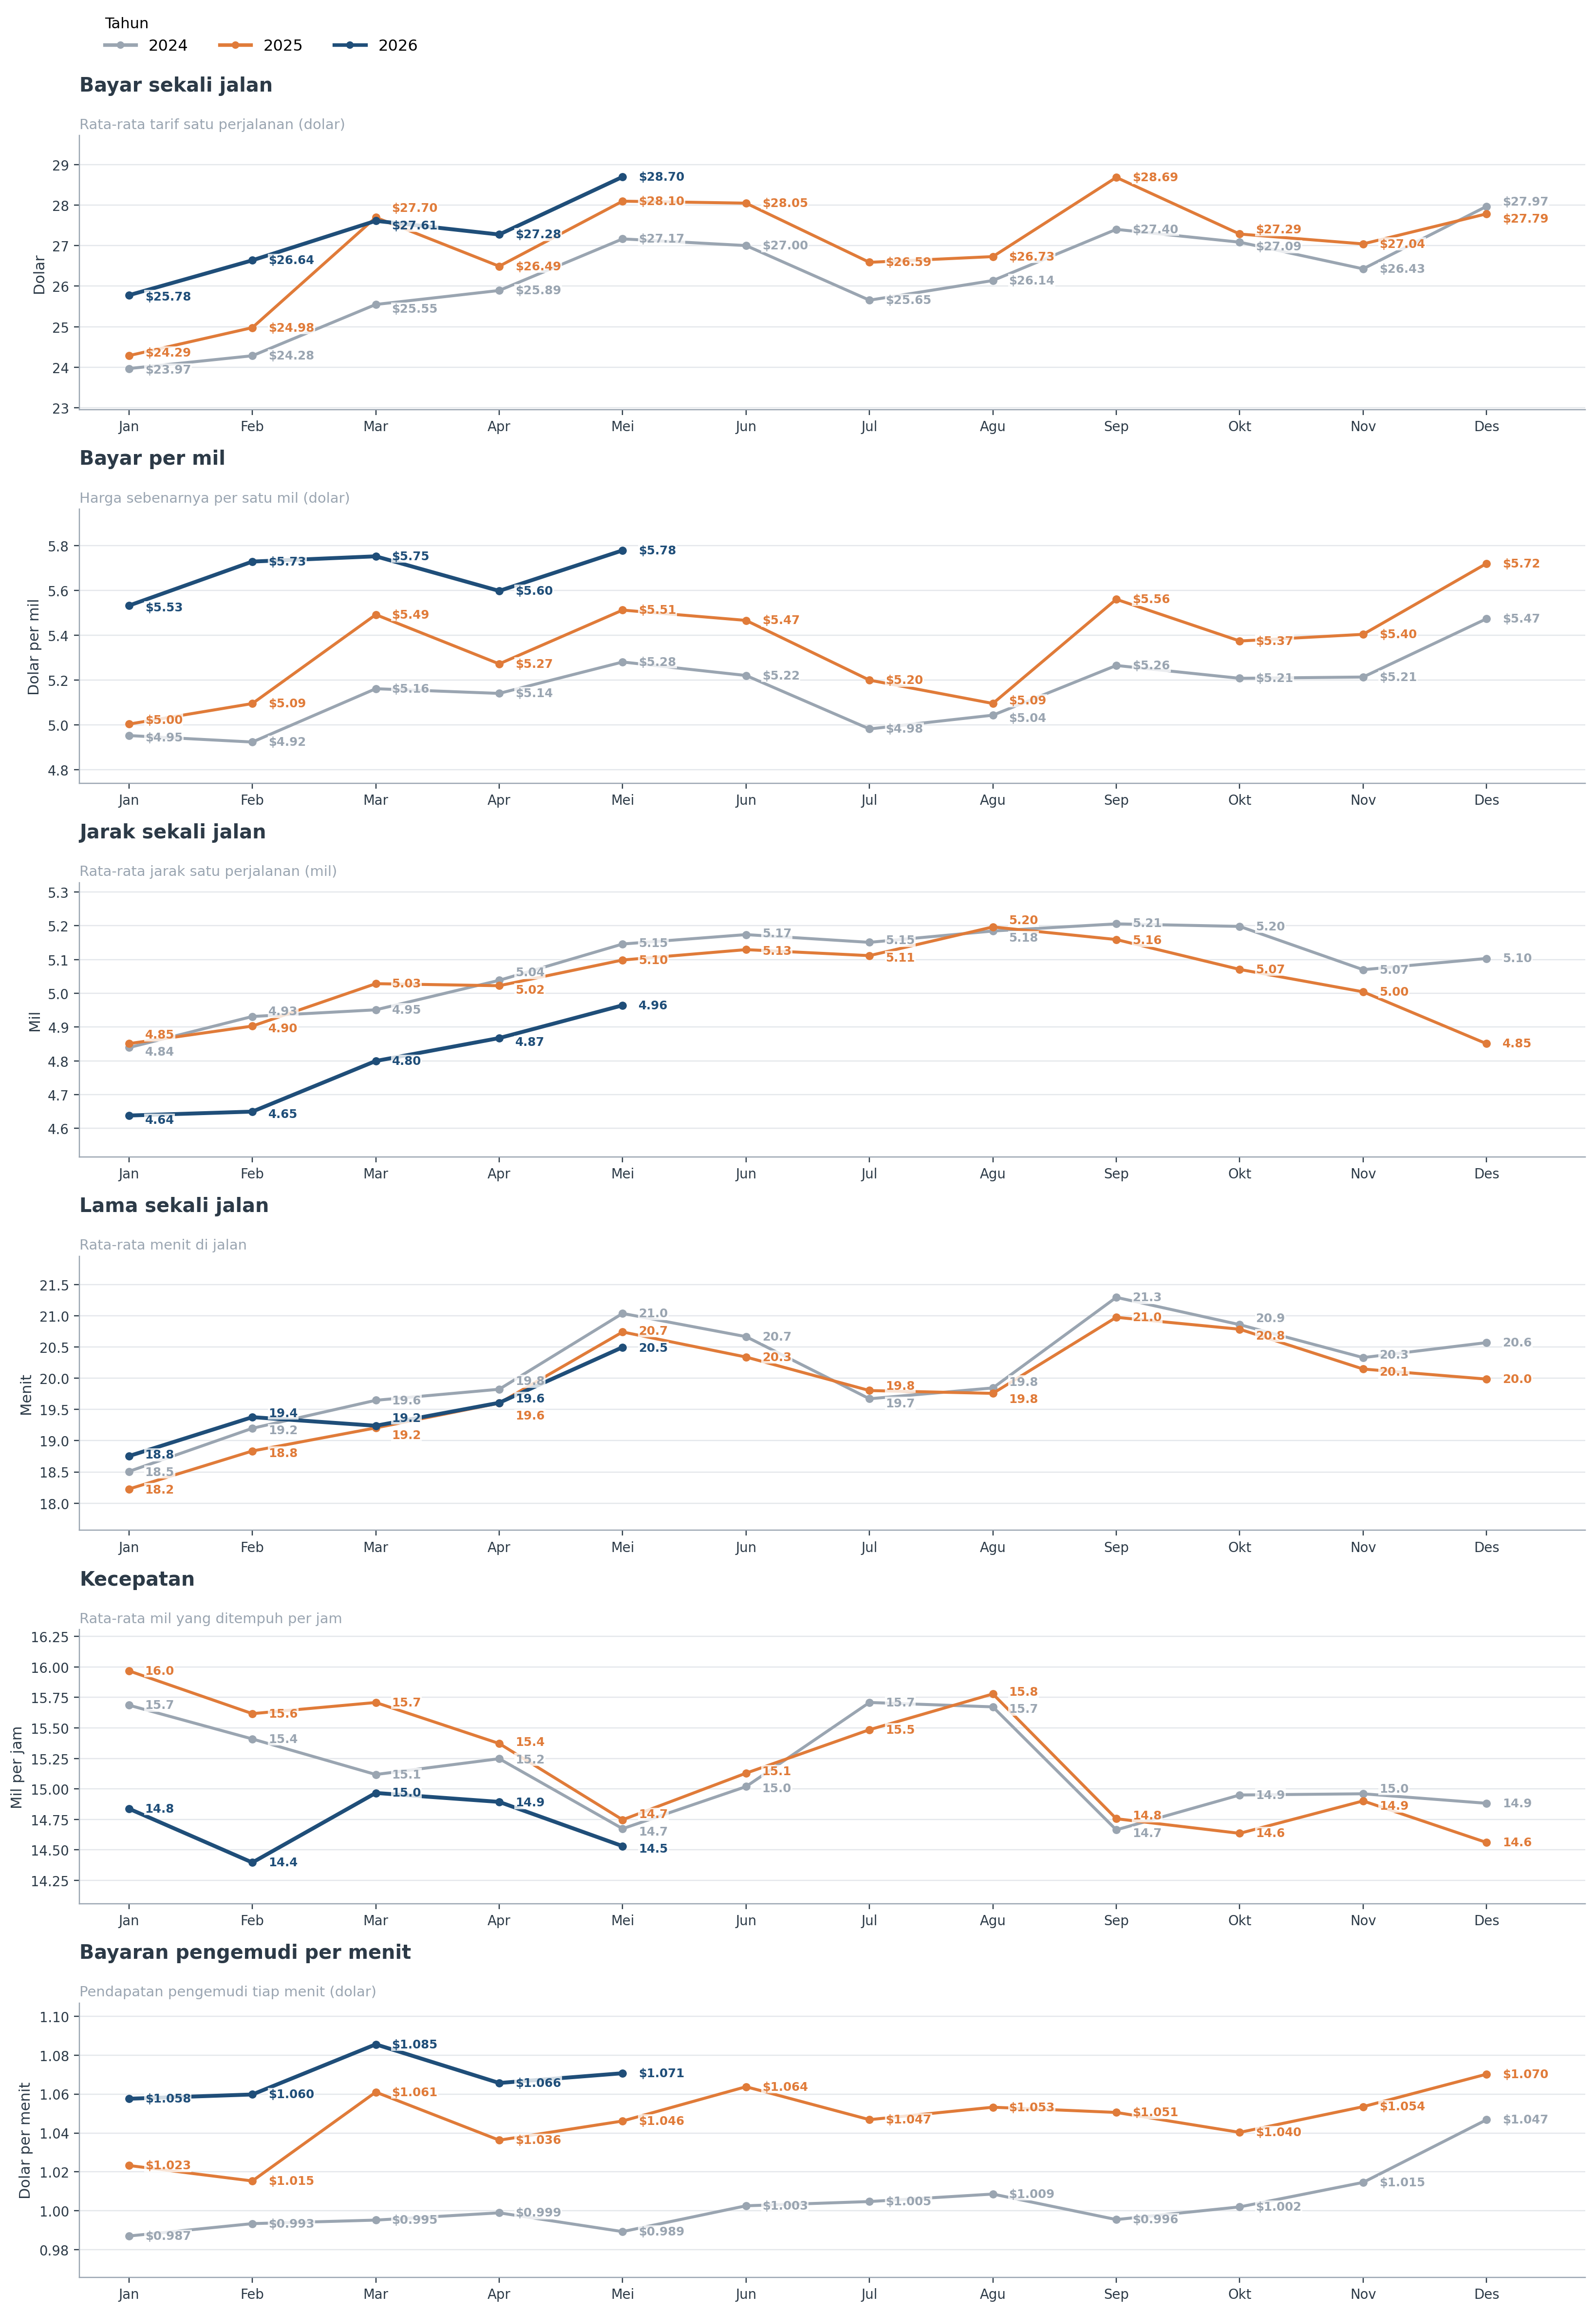

In [80]:
from matplotlib.lines import Line2D

WARNA_TH = {2024: C["muted"], 2025: C["secondary"], 2026: C["primary"]}

panel = [
    ("fare_per_trip",    "Bayar sekali jalan",          "Rata-rata tarif satu perjalanan (dolar)", "${:.2f}", "Dolar"),
    ("fare_per_mile",    "Bayar per mil",               "Harga sebenarnya per satu mil (dolar)",   "${:.2f}", "Dolar per mil"),
    ("miles_per_trip",   "Jarak sekali jalan",          "Rata-rata jarak satu perjalanan (mil)",   "{:.2f}",  "Mil"),
    ("minutes_per_trip", "Lama sekali jalan",           "Rata-rata menit di jalan",                "{:.1f}",  "Menit"),
    ("speed_mph",        "Kecepatan",                   "Rata-rata mil yang ditempuh per jam",     "{:.1f}",  "Mil per jam"),
    ("pay_per_minute",   "Bayaran pengemudi per menit", "Pendapatan pengemudi tiap menit (dolar)", "${:.3f}", "Dolar per menit"),
]

FONT_LABEL = 8


def label_per_bulan(ax, data, fmt, fig):
    """
    Label angka di setiap titik tanpa saling menimpa.

    Posisi dihitung dalam piksel layar, bukan satuan data, sehingga
    jarak antar label selalu sesuai tinggi tulisan. Di tiap bulan,
    label diurutkan, diberi jarak minimum, lalu tumpukannya
    dipusatkan kembali di sekitar titik aslinya.
    """
    ke_piksel = ax.transData.transform
    ke_data   = ax.transData.inverted().transform
    jarak_px  = FONT_LABEL / 72 * fig.dpi * 1.45

    for m in range(1, 13):
        titik = []
        for s, colr in data:
            baris = s[s["month"] == m]
            if len(baris):
                v = baris["val"].values[0]
                titik.append((v, ke_piksel((m, v))[1], colr))
        if not titik:
            continue
        titik.sort(key=lambda t: t[1])

        asli = [t[1] for t in titik]
        baru = []
        for yp in asli:
            baru.append(yp if not baru else max(yp, baru[-1] + jarak_px))

        # Pusatkan kembali tumpukan agar tidak hanya terdorong ke atas
        geser = np.mean(asli) - np.mean(baru)
        baru = [b + geser for b in baru]

        for (v, _, colr), yp in zip(titik, baru):
            y_data = ke_data((m, yp))[1]
            ax.text(m + 0.13, y_data, fmt.format(v), ha="left", va="center",
                    fontsize=FONT_LABEL, color=colr, fontweight="semibold",
                    bbox=dict(facecolor="white", edgecolor="none",
                              alpha=0.8, pad=0.5), zorder=7)


fig, axes = plt.subplots(len(panel), 1, figsize=(15, 3.6 * len(panel)))

kumpulan = []
for ax, (c, judul, arti, fmt, satuan) in zip(axes, panel):
    data = []
    for th, colr in WARNA_TH.items():
        s = di[di["year"] == th][["month", c]].rename(columns={c: "val"})
        ax.plot(s["month"], s["val"], color=colr, marker="o", markersize=4.5,
                linewidth=2.6 if th == 2026 else 2, zorder=5)
        data.append((s, colr))

    lo, hi = ax.get_ylim()
    ax.set_ylim(lo - (hi - lo) * 0.15, hi + (hi - lo) * 0.15)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(NAMA_BLN, fontsize=9)
    ax.set_xlim(0.6, 12.8)
    ax.set_ylabel(satuan)
    titled(ax, judul, arti)
    clean_axes(ax)
    kumpulan.append((ax, data, fmt))

# Legenda terpisah di bagian atas
penanda = [Line2D([0], [0], color=colr, marker="o", linewidth=2.4, label=str(th))
           for th, colr in WARNA_TH.items()]
fig.legend(handles=penanda, loc="upper left", ncol=3, fontsize=10.5,
           frameon=False, bbox_to_anchor=(0.06, 1.0),
           title="Tahun", title_fontsize=10, alignment="left")

# Tata letak dulu, baru label — posisi piksel baru pasti setelah tata letak selesai
plt.tight_layout(rect=[0, 0, 1, 0.975])
for ax, data, fmt in kumpulan:
    label_per_bulan(ax, data, fmt, fig)

plt.show()

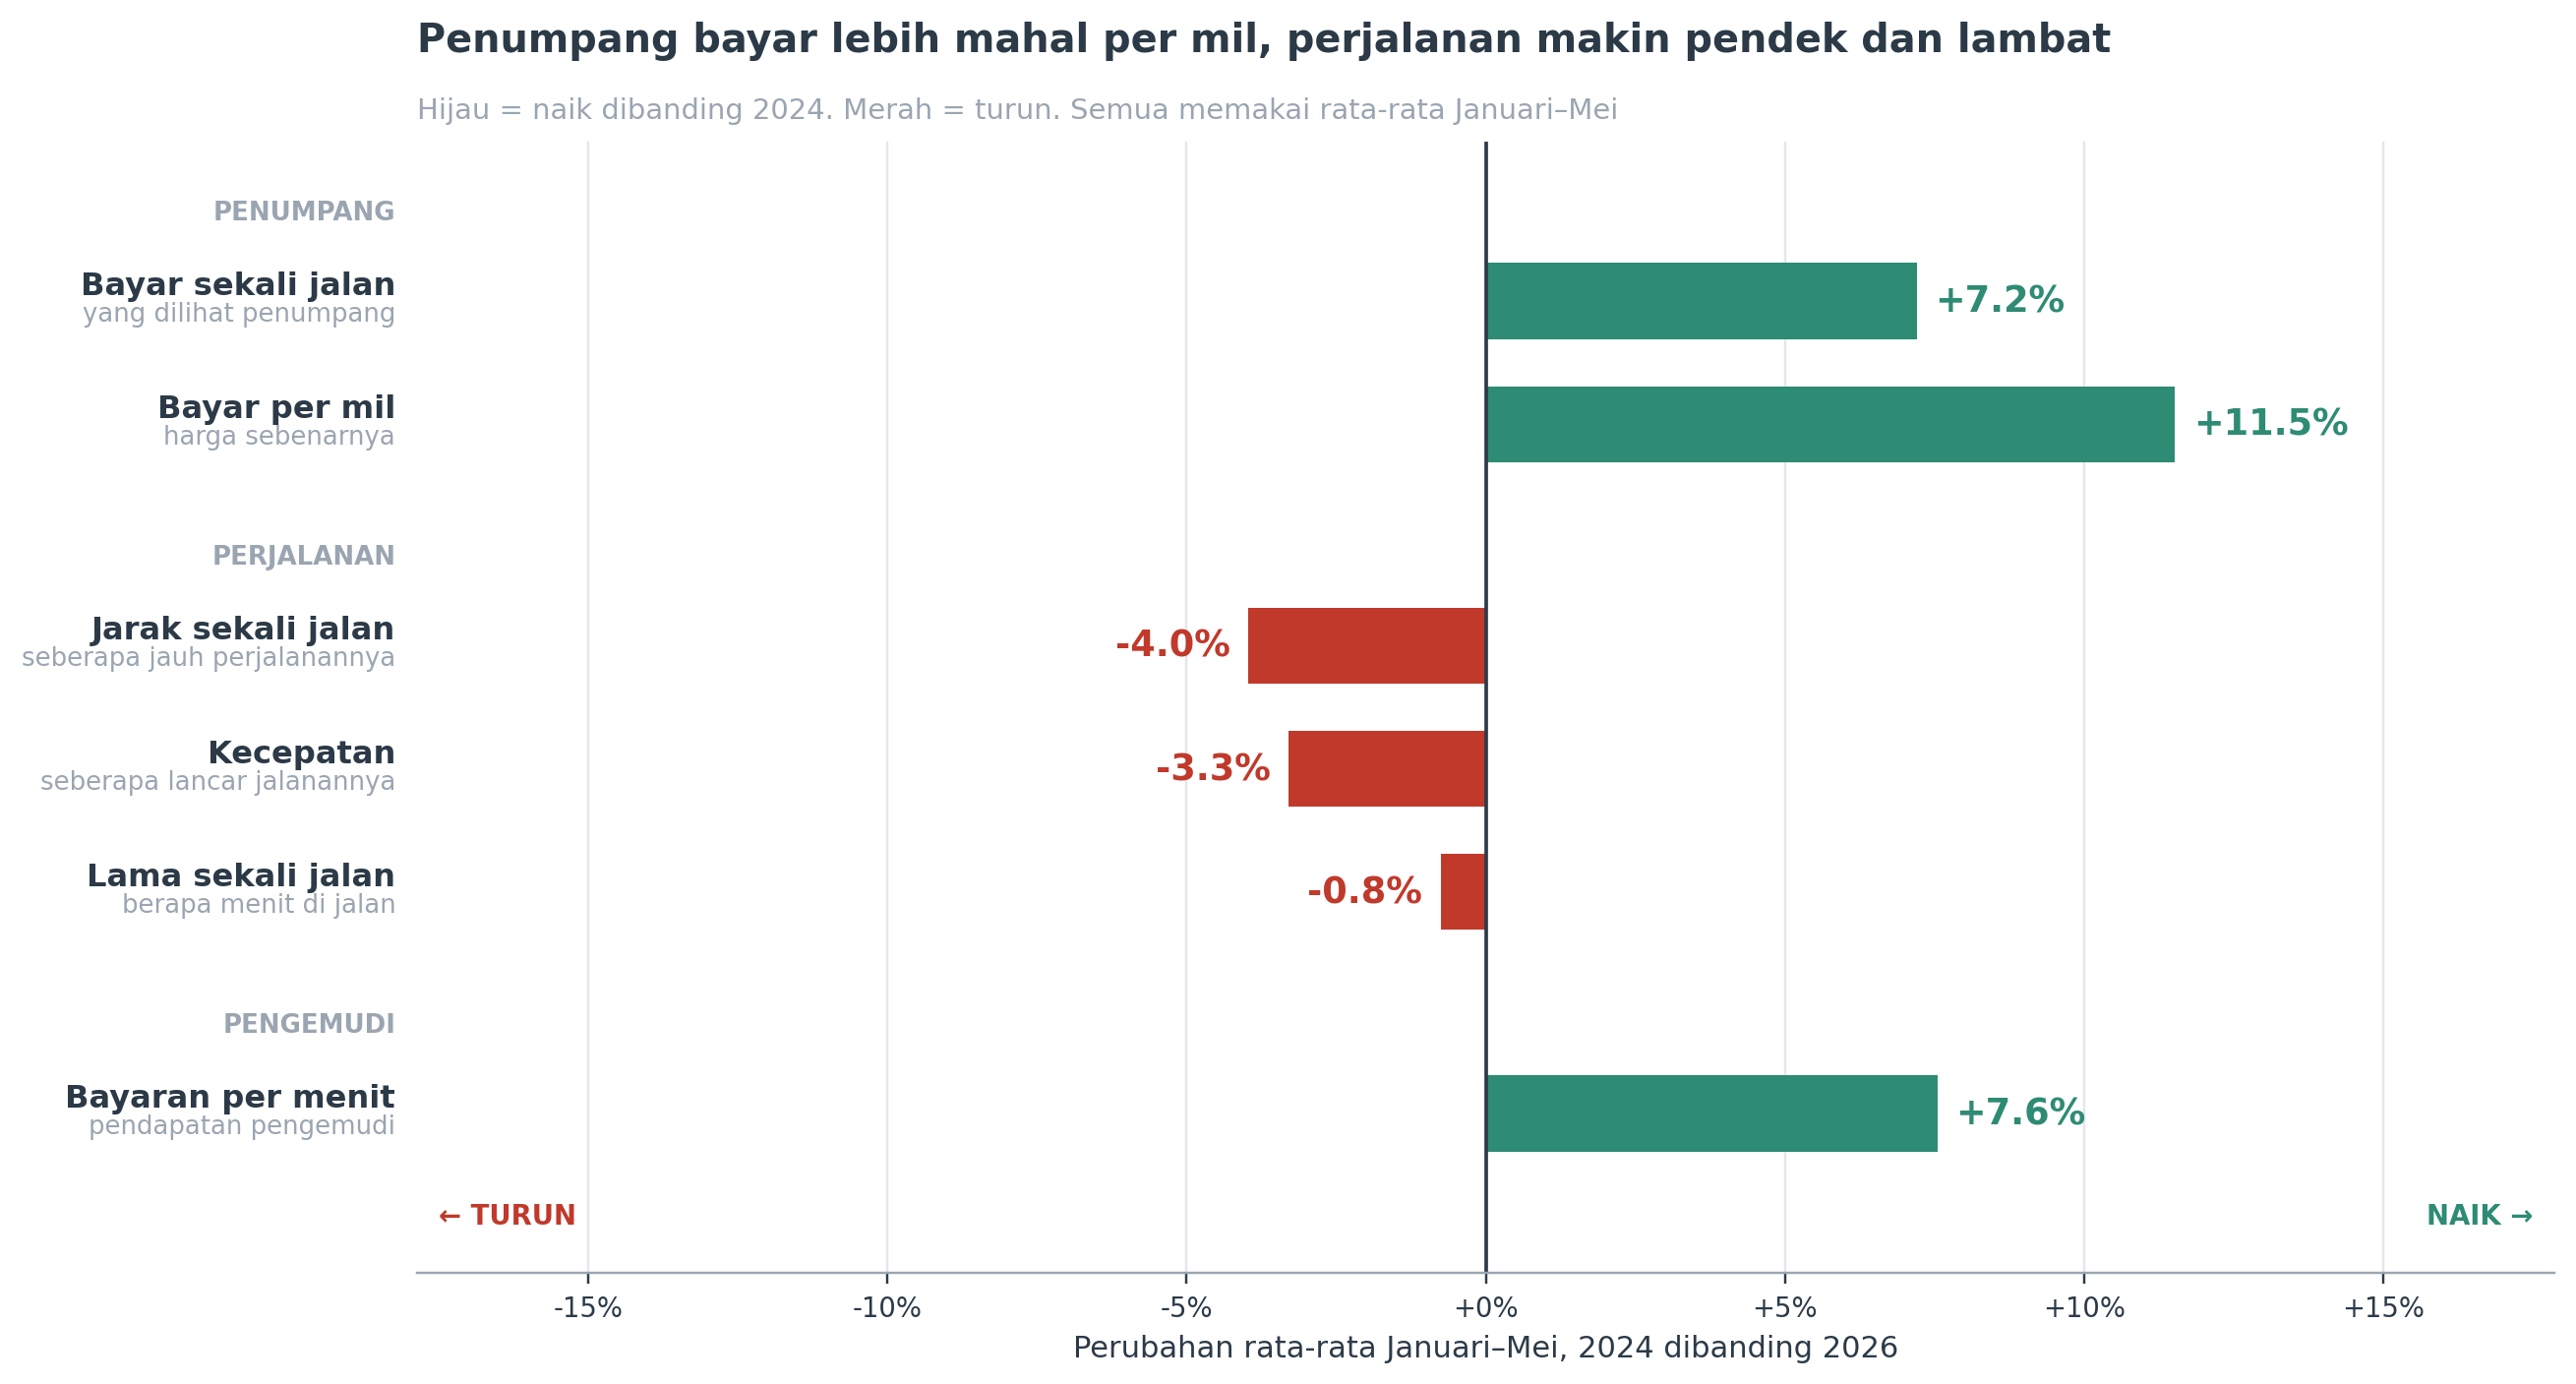

,2024,2025,2026,perubahan
metrik,,,,
Bayar sekali jalan,25.37,26.31,27.20,+7.2%
Bayar per mil,5.09,5.27,5.68,+11.5%
Jarak sekali jalan,4.98,4.98,4.78,-4.0%
Kecepatan,15.23,15.48,14.72,-3.3%
Lama sekali jalan,19.64,19.32,19.50,-0.8%
Bayaran per menit,0.99,1.04,1.07,+7.6%


In [81]:
# Semua perbandingan memakai rata-rata Januari–Mei,
# karena hanya bulan itu yang tersedia di ketiga tahun.
jm = [1, 2, 3, 4, 5]
def rata(c, th):
    return di[(di["year"] == th) & di["month"].isin(jm)][c].mean()

metrik = [
    ("fare_per_trip",    "Bayar sekali jalan", "yang dilihat penumpang",      "Penumpang"),
    ("fare_per_mile",    "Bayar per mil",      "harga sebenarnya",            "Penumpang"),
    ("miles_per_trip",   "Jarak sekali jalan", "seberapa jauh perjalanannya", "Perjalanan"),
    ("speed_mph",        "Kecepatan",          "seberapa lancar jalanannya",  "Perjalanan"),
    ("minutes_per_trip", "Lama sekali jalan",  "berapa menit di jalan",       "Perjalanan"),
    ("pay_per_minute",   "Bayaran per menit",  "pendapatan pengemudi",        "Pengemudi"),
]

hasil = pd.DataFrame([{
    "kelompok": g, "metrik": n, "arti": a,
    "2024": rata(c, 2024), "2025": rata(c, 2025), "2026": rata(c, 2026),
    "perubahan": (rata(c, 2026) / rata(c, 2024) - 1) * 100,
} for c, n, a, g in metrik])

# Posisi batang dengan jarak antar kelompok
y, pos, grup_pos, grup_lalu = 0, [], {}, None
for g in hasil["kelompok"]:
    if g != grup_lalu:
        if grup_lalu is not None:
            y += 0.8
        grup_pos[g], grup_lalu = y, g
    pos.append(y)
    y += 1
pos = np.array(pos)

fig, ax = plt.subplots(figsize=(12, 6.5))

warna = [C["accent"] if v > 0 else C["alert"] for v in hasil["perubahan"]]
ax.barh(pos, hasil["perubahan"], color=warna, height=0.62)
ax.axvline(0, color=C["text"], linewidth=1.2)

batas = hasil["perubahan"].abs().max() * 1.55
for p, v, nama, arti in zip(pos, hasil["perubahan"], hasil["metrik"], hasil["arti"]):
    ax.text(v + (0.3 if v > 0 else -0.3), p, f"{v:+.1f}%",
            ha="left" if v > 0 else "right", va="center",
            fontsize=12, fontweight="bold",
            color=C["accent"] if v > 0 else C["alert"])
    ax.text(-batas * 1.02, p, nama, ha="right", va="bottom",
            fontsize=10.5, fontweight="semibold", color=C["text"])
    ax.text(-batas * 1.02, p, arti, ha="right", va="top",
            fontsize=8.5, color=C["muted"])

for g, p in grup_pos.items():
    ax.text(-batas * 1.02, p - 0.72, g.upper(), ha="right", va="center",
            fontsize=8.5, color=C["muted"], fontweight="bold")

ax.text(batas * 0.98,  pos.max() + 0.9, "NAIK →",  ha="right",
        fontsize=9, color=C["accent"], fontweight="bold")
ax.text(-batas * 0.98, pos.max() + 0.9, "← TURUN", ha="left",
        fontsize=9, color=C["alert"], fontweight="bold")

ax.set_xlim(-batas, batas)
ax.set_ylim(pos.max() + 1.3, -1.3)
ax.set_yticks([])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:+.0f}%"))
ax.set_xlabel("Perubahan rata-rata Januari–Mei, 2024 dibanding 2026")
titled(ax, "Penumpang bayar lebih mahal per mil, perjalanan makin pendek dan lambat",
       "Hijau = naik dibanding 2024. Merah = turun. Semua memakai rata-rata Januari–Mei")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

hasil[["metrik", "2024", "2025", "2026", "perubahan"]].set_index("metrik").style.format(
    {"2024": "{:.2f}", "2025": "{:.2f}", "2026": "{:.2f}", "perubahan": "{:+.1f}%"})

> **Hasil Step 5 — memecah tarif menjadi komponennya**

Semua perbandingan memakai rata-rata Januari–Mei 2024 dibanding Januari–Mei 2026, karena hanya lima bulan itu yang tersedia di ketiga tahun. Pemeriksaan rumus menunjukkan selisih di bawah 1%, sehingga pemecahan ini dapat dipercaya.

**Temuan 1 — Harga sebenarnya naik lebih cepat dari yang terlihat**

```
Bayar sekali jalan  +7,2%  =  Jarak −4,0%  ×  Bayar per mil +11,5%
```

Penumpang membayar 7,2% lebih mahal per perjalanan, tetapi perjalanannya 4% lebih pendek. Harga per mil — harga sebenarnya — naik 11,5%, sekitar 1,6 kali kenaikan yang terlihat di tarif per perjalanan. Dua gerakan berlawanan saling menutupi.

Kenaikan ini konsisten: bayar per mil 2025 lebih tinggi dari 2024 di seluruh 12 bulan, dan 2026 lebih tinggi dari 2025 di seluruh 5 bulan.

**Temuan 2 — Perjalanan memendek sejak akhir 2025**

Sepanjang Januari–September 2025, jarak perjalanan hampir sama dengan 2024. Mulai Oktober 2025 jaraknya turun, dan seluruh Januari–Mei 2026 berada 3–6% di bawah 2024.

Waktunya bersamaan dengan percepatan pertumbuhan permintaan: sejak Oktober 2025 perjalanan makin banyak tetapi makin pendek. Data ini tidak dapat menjelaskan sebabnya, sehingga dicatat sebagai kejadian bersamaan, bukan sebab-akibat.

**Temuan 3 — Pendapatan pengemudi tidak tergerus**

Bayaran per menit naik 7,6%, dan lebih tinggi dari tahun sebelumnya di seluruh 17 perbandingan bulan yang sama. Porsi pengemudi dari tarif stabil di kisaran 74–79%. Kenaikan harga ikut dinikmati pengemudi.

**Temuan 4 — Jalanan melambat, tetapi baru di 2026**

Kecepatan 2026 lebih lambat dari 2024 di seluruh lima bulan, rata-rata −3,3%, paling tajam pada Januari (−5,4%) dan Februari (−6,6%). Sebaliknya, 2025 justru sedikit lebih cepat dari 2024 di lima bulan yang sama.

Karena jarak turun 4% dan kecepatan turun 3%, lama perjalanan hampir tidak berubah (−0,8%). Perjalanan lebih pendek, tetapi tidak lebih cepat selesai.

**Temuan 5 — Maret 2025 kembali janggal**

Porsi pengemudi mencapai titik terendahnya pada Maret 2025 (73,8%), sementara bulan lain berkisar 76–79%. Ini bulan yang sama yang janggal pada perbandingan bulanan dan tahunan.

**Status hipotesis**

| Hipotesis | Status | Bukti |
|---|---|---|
| H5 — pendapatan pengemudi tergerus | **Gugur** | Bayaran per menit +7,6%, naik di 17 dari 17 perbandingan |
| H6 — kenaikan tarif moderat | **Gugur** | Bayar per mil +11,5%, jauh di atas tarif per perjalanan +7,2% |
| H7 — kemacetan menjelaskan durasi | **Bertahan sebagian** | Kecepatan −3,3%, tetapi hanya di 2026; durasi hampir tetap karena jarak juga turun |

**Batas kesimpulan**

`base_passenger_fare` adalah bayaran penumpang, bukan pendapatan perusahaan. Selisih antara tarif dan bayaran pengemudi bukan margin, karena masih mengandung tol, pajak, dan biaya lain yang tidak tercatat.

**Kaitannya dengan argumen utama**

Ini contoh kedua dari mekanisme yang sama dengan efek kalender: satu angka rata-rata menyembunyikan dua gerakan berlawanan. Pada efek kalender yang tersembunyi adalah jumlah hari; di sini yang tersembunyi adalah kenaikan harga per mil di balik perjalanan yang memendek.

> **Keputusan:** harga sebenarnya naik +11,5%, bukan +7,2% · H5 dan H6 gugur, H7 bertahan sebagian · perjalanan memendek sejak Oktober 2025, bersamaan dengan percepatan permintaan · Maret 2025 muncul janggal untuk ketiga kalinya

---

# STEP 6 — Mix Effect vs Rate Effect

**Tujuan:** mencari tahu kenapa perjalanan makin pendek — karena perilaku perjalanan di tiap zona berubah, atau karena permintaan pindah ke zona yang perjalanannya memang pendek.

**Kenapa diperlukan:** rata-rata gabungan dapat turun karena dua sebab yang sangat berbeda, tetapi menghasilkan angka yang sama:

| Sebab | Artinya |
|---|---|
| Rate effect | Perjalanan dari zona yang sama memang makin pendek |
| Mix effect | Jarak di tiap zona tetap, tetapi lebih banyak perjalanan datang dari zona yang jaraknya pendek |

**Rumus pemecahan:**

```
perubahan total = mix effect + rate effect + interaksi

mix effect  = pergeseran porsi perjalanan antar zona × jarak lama
rate effect = porsi perjalanan lama × perubahan jarak di tiap zona
interaksi   = keduanya terjadi bersamaan di zona yang sama
```

**Hipotesis yang diuji:**

| Hipotesis | Pertanyaan |
|---|---|
| Pemendekan perjalanan adalah perubahan nyata | Apakah perjalanan di zona yang sama memang makin pendek, atau hanya campuran zonanya yang berubah? |
| H4 — rata-rata memadai untuk perencanaan | Apakah angka gabungan mewakili perubahan di tiap zona? |

**Input:** `mart_business_metrics` untuk Januari 2024 dan Januari 2026. Bulan yang sama dipakai agar tidak tercampur efek musim.

**Segmen:** zona pickup. Pemecahan berdasarkan ciri tiap perjalanan tidak dimungkinkan karena data sudah dirangkum per zona dan jam.

**Expected output:**
1. Tiga angka sumbangan yang menjumlah menjadi total perubahan
2. Grafik pecahan penurunan dan sebaran perubahan jarak per zona

**Cara interpretasi:**

- Bila **rate effect dominan** — perubahan terjadi di dalam zona itu sendiri. Perjalanan dari zona yang sama memang berubah, sehingga penjelasan seperti perubahan perilaku penumpang atau kondisi jalan layak dipertimbangkan.
- Bila **mix effect dominan** — jarak di tiap zona relatif tetap. Yang berubah adalah porsi permintaan antar zona, sehingga temuannya menjadi pergeseran peta permintaan, bukan perubahan perilaku.
- Bila **keduanya seimbang** — perubahan perilaku dan pergeseran peta permintaan terjadi bersamaan, dan keduanya perlu dilaporkan.

Ketiga kondisi dapat menghasilkan angka gabungan yang sama persis, tetapi tindakan yang tepat berbeda. Rate effect menuntut perencanaan ulang di setiap zona; mix effect menuntut perpindahan armada antar zona.

In [82]:
PERIOD_0 = "2024-01"   # periode awal
PERIOD_1 = "2026-01"   # periode akhir

sql = f"""
SELECT
    year_month,
    pickup_location_id,
    SUM(total_trips)          AS trips,
    SUM(total_trip_miles)     AS miles,
    SUM(valid_distance_trips) AS valid_dist,
    SUM(total_base_fare)      AS fare,
    SUM(valid_fare_trips)     AS valid_fare
FROM {MART_BUSINESS}
WHERE year_month IN ('{PERIOD_0}', '{PERIOD_1}')
GROUP BY year_month, pickup_location_id
"""

df_mix_raw = run_query(sql)
print(df_mix_raw.groupby("year_month").size())

Rows returned : 524
Bytes billed  : 0.0000 GB
year_month
2024-01    262
2026-01    262
dtype: int64


In [83]:
def decompose_mix_rate(df, period_0, period_1,
                       value_col="miles", weight_col="valid_dist",
                       segment_col="pickup_location_id"):
    """
    Memisahkan perubahan rata-rata tertimbang menjadi mix effect,
    rate effect, dan interaksi.

    r_s = value_col / weight_col pada segmen s
    w_s = porsi weight_col segmen s terhadap total
    """
    p0 = df[df["year_month"] == period_0].set_index(segment_col)
    p1 = df[df["year_month"] == period_1].set_index(segment_col)

    segs = p0.index.union(p1.index)
    p0 = p0.reindex(segs).fillna(0)
    p1 = p1.reindex(segs).fillna(0)

    w0 = p0[weight_col] / p0[weight_col].sum()
    w1 = p1[weight_col] / p1[weight_col].sum()

    r0 = (p0[value_col] / p0[weight_col]).replace([np.inf, -np.inf], np.nan).fillna(0)
    r1 = (p1[value_col] / p1[weight_col]).replace([np.inf, -np.inf], np.nan).fillna(0)

    m0 = (w0 * r0).sum()
    m1 = (w1 * r1).sum()

    mix         = ((w1 - w0) * r0).sum()
    rate        = (w0 * (r1 - r0)).sum()
    interaction = ((w1 - w0) * (r1 - r0)).sum()

    return {
        "metric_awal":   m0,
        "metric_akhir":  m1,
        "perubahan":     m1 - m0,
        "mix_effect":    mix,
        "rate_effect":   rate,
        "interaksi":     interaction,
        "cek_jumlah":    mix + rate + interaction,
    }

In [84]:
res_miles = decompose_mix_rate(
    df_mix_raw, PERIOD_0, PERIOD_1,
    value_col="miles", weight_col="valid_dist"
)

print(f"Dekomposisi miles per trip, {PERIOD_0} -> {PERIOD_1}\n")
for k, v in res_miles.items():
    print(f"  {k:15} {v:>12.4f}")

total = res_miles["perubahan"]
if abs(total) > 1e-9:
    print(f"\n  Kontribusi mix  : {res_miles['mix_effect']  / total * 100:6.1f}%")
    print(f"  Kontribusi rate : {res_miles['rate_effect'] / total * 100:6.1f}%")

Dekomposisi miles per trip, 2024-01 -> 2026-01

  metric_awal           4.8394
  metric_akhir          4.6383
  perubahan            -0.2012
  mix_effect           -0.0602
  rate_effect          -0.1208
  interaksi            -0.0202
  cek_jumlah           -0.2012

  Kontribusi mix  :   29.9%
  Kontribusi rate :   60.0%


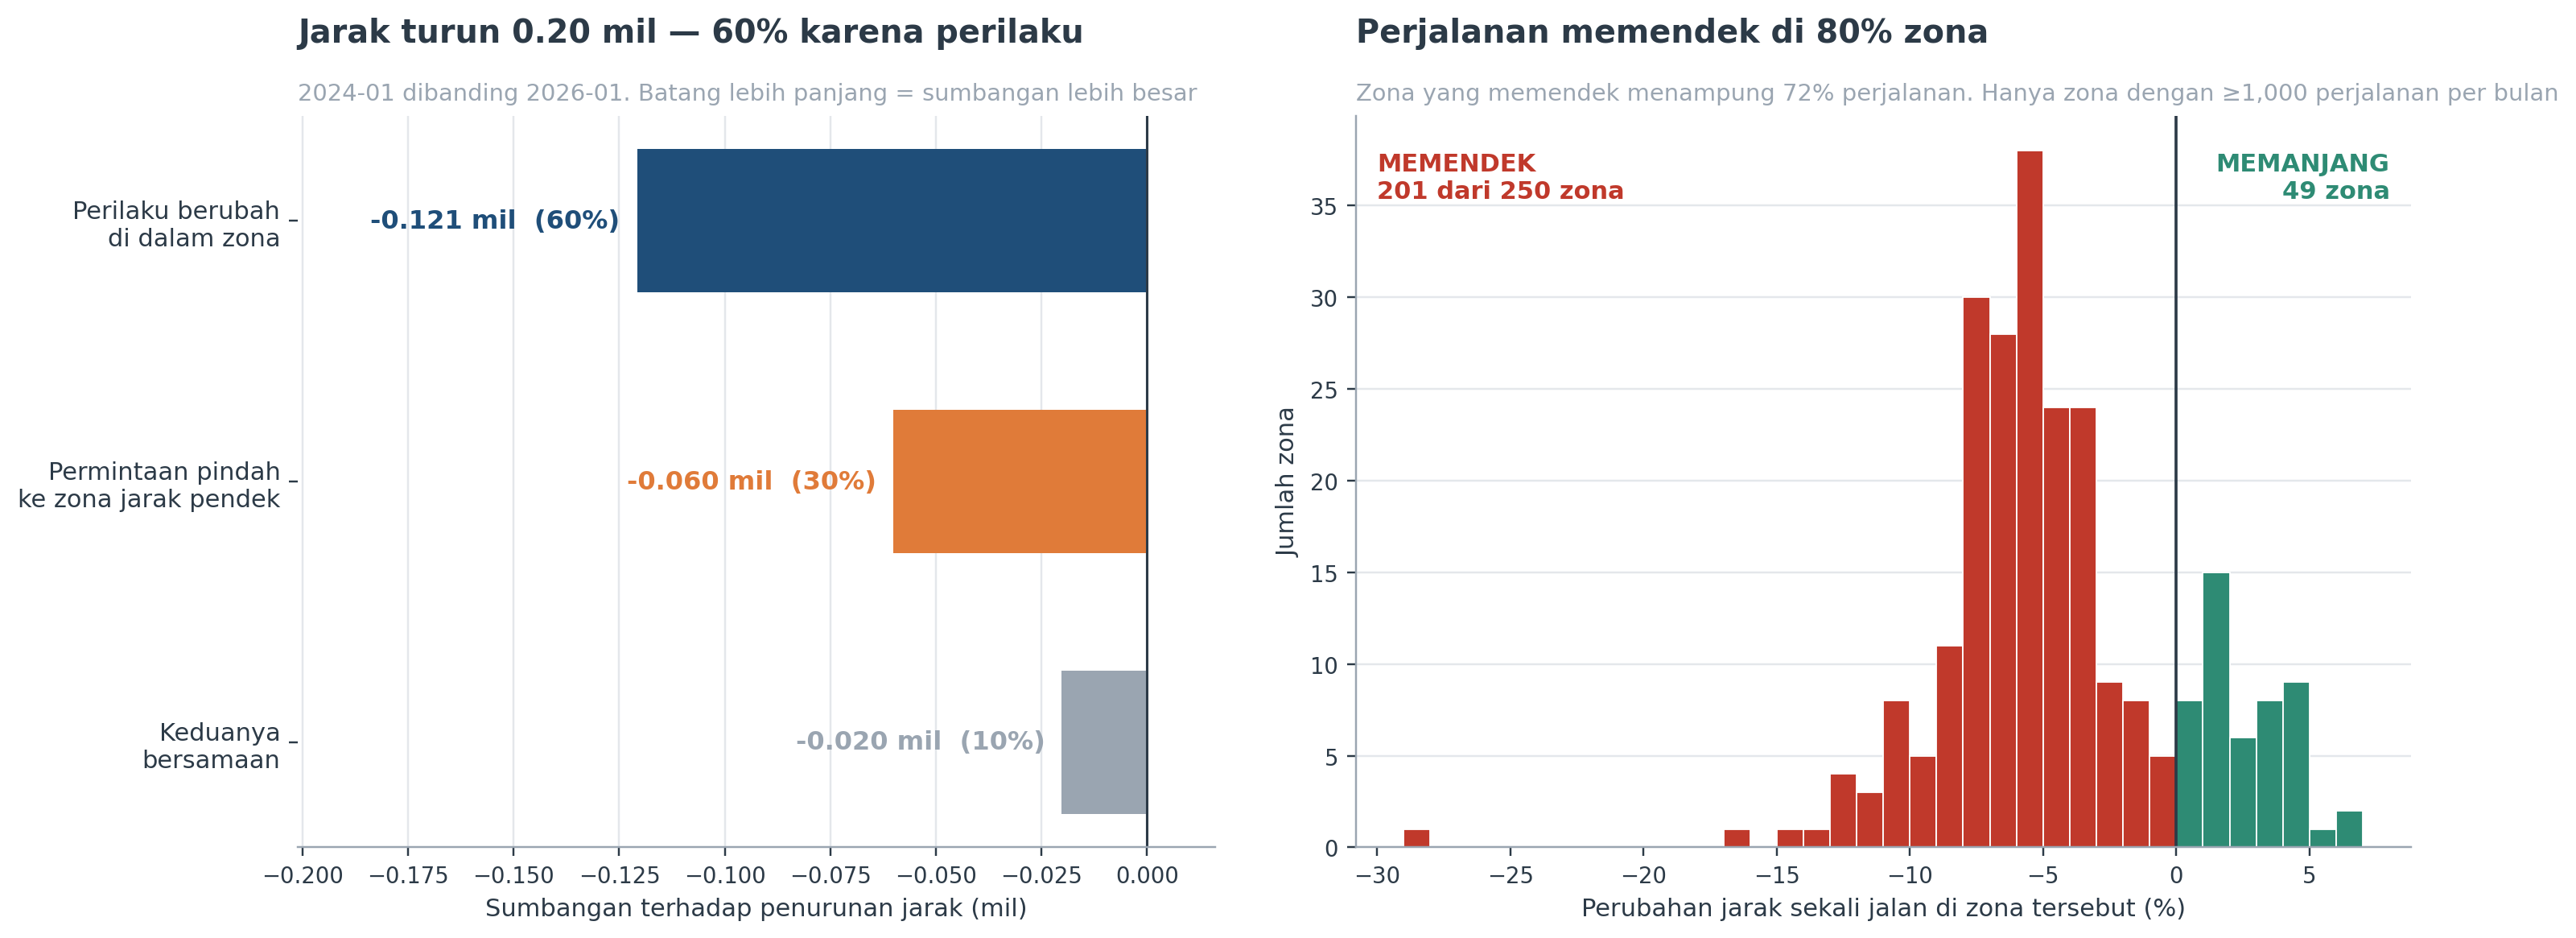

Zona yang dianalisis          : 250
Zona yang perjalanannya memendek : 201 (80%)
Porsi perjalanan di zona itu  : 72%
Median perubahan jarak per zona : -5.3%


In [85]:
# ---------- Jarak per perjalanan per zona, dua periode ----------
per_zona = (
    df_mix_raw
    .assign(jarak=lambda d: d["miles"] / d["valid_dist"])
    .pivot(index="pickup_location_id", columns="year_month",
           values=["jarak", "valid_dist"])
)
per_zona.columns = [f"{a}_{b}" for a, b in per_zona.columns]

# Hanya zona dengan perjalanan cukup banyak di kedua periode,
# supaya zona yang sangat sepi tidak membuat angka melonjak
MIN_TRIP = 1000
per_zona = per_zona[
    (per_zona[f"valid_dist_{PERIOD_0}"] >= MIN_TRIP) &
    (per_zona[f"valid_dist_{PERIOD_1}"] >= MIN_TRIP)
].copy()
per_zona["ubah_pct"] = (per_zona[f"jarak_{PERIOD_1}"] /
                        per_zona[f"jarak_{PERIOD_0}"] - 1) * 100

n_zona      = len(per_zona)
n_memendek  = int((per_zona["ubah_pct"] < 0).sum())
bobot       = per_zona[f"valid_dist_{PERIOD_1}"]
porsi_trip  = bobot[per_zona["ubah_pct"] < 0].sum() / bobot.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4),
                         gridspec_kw={"width_ratios": [1, 1.15]})

# ---------- Kiri: pecahan penurunan ----------
ax = axes[0]
bagian = [
    ("Perilaku berubah\ndi dalam zona",       res_miles["rate_effect"], C["primary"]),
    ("Permintaan pindah\nke zona jarak pendek", res_miles["mix_effect"],  C["secondary"]),
    ("Keduanya\nbersamaan",                   res_miles["interaksi"],   C["muted"]),
]
total = res_miles["perubahan"]
yb = np.arange(len(bagian))
ax.barh(yb, [b[1] for b in bagian], color=[b[2] for b in bagian], height=0.55)
for k, (nama, v, colr) in enumerate(bagian):
    ax.text(v - 0.004, k, f"{v:.3f} mil  ({v / total * 100:.0f}%)",
            ha="right", va="center", fontsize=10.5, fontweight="bold", color=colr)
ax.axvline(0, color=C["text"], linewidth=1)
ax.set_yticks(yb)
ax.set_yticklabels([b[0] for b in bagian], fontsize=10)
ax.invert_yaxis()
ax.set_xlim(total * 1.0, abs(total) * 0.08)
ax.set_xlabel("Sumbangan terhadap penurunan jarak (mil)")
titled(ax, f"Jarak turun {abs(total):.2f} mil — {res_miles['rate_effect'] / total * 100:.0f}% karena perilaku",
       f"{PERIOD_0} dibanding {PERIOD_1}. Batang lebih panjang = sumbangan lebih besar")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)

# ---------- Kanan: berapa zona yang memendek ----------
ax = axes[1]
bins = np.arange(np.floor(per_zona["ubah_pct"].min()),
                 np.ceil(per_zona["ubah_pct"].max()) + 1, 1)
n, edges, patches = ax.hist(per_zona["ubah_pct"], bins=bins,
                            edgecolor="white", linewidth=0.6)
for patch, kiri in zip(patches, edges[:-1]):
    patch.set_facecolor(C["alert"] if kiri < 0 else C["accent"])

ax.axvline(0, color=C["text"], linewidth=1.2)
ax.text(0.02, 0.95, f"MEMENDEK\n{n_memendek} dari {n_zona} zona",
        transform=ax.transAxes, fontsize=10, fontweight="bold",
        color=C["alert"], va="top")
ax.text(0.98, 0.95, f"MEMANJANG\n{n_zona - n_memendek} zona",
        transform=ax.transAxes, fontsize=10, fontweight="bold",
        color=C["accent"], va="top", ha="right")
ax.set_xlabel("Perubahan jarak sekali jalan di zona tersebut (%)")
ax.set_ylabel("Jumlah zona")
titled(ax, f"Perjalanan memendek di {n_memendek / n_zona * 100:.0f}% zona",
       f"Zona yang memendek menampung {porsi_trip:.0f}% perjalanan. "
       f"Hanya zona dengan ≥{MIN_TRIP:,} perjalanan per bulan")
clean_axes(ax)

plt.tight_layout()
plt.show()

print(f"Zona yang dianalisis          : {n_zona}")
print(f"Zona yang perjalanannya memendek : {n_memendek} ({n_memendek / n_zona * 100:.0f}%)")
print(f"Porsi perjalanan di zona itu  : {porsi_trip:.0f}%")
print(f"Median perubahan jarak per zona : {per_zona['ubah_pct'].median():+.1f}%")

> **Cara membaca grafik**

**Panel kiri** — tiga batang menunjukkan dari mana penurunan jarak 0,20 mil berasal. Batang biru adalah sumbangan dari perilaku perjalanan di dalam zona yang sama, oranye dari perpindahan permintaan ke zona berjarak pendek, abu-abu dari keduanya sekaligus. Batang yang lebih panjang berarti sumbangan yang lebih besar.

**Panel kanan** — setiap batang adalah sekelompok zona dengan perubahan jarak yang mirip. Batang merah di kiri garis nol adalah zona yang perjalanannya memendek, hijau di kanan adalah zona yang memanjang. Semakin banyak batang merah, semakin menyeluruh pemendekannya. Hanya zona dengan sedikitnya 1.000 perjalanan per bulan yang dihitung, karena zona yang sangat sepi bisa berubah drastis hanya dari segelintir perjalanan.

> **Hasil Step 6 — kenapa perjalanan makin pendek**

Jarak sekali jalan turun dari 4,84 mil pada Januari 2024 menjadi 4,64 mil pada Januari 2026, berkurang 0,20 mil atau −4,2%. Penurunan itu dipecah menjadi tiga bagian, dan jumlah ketiganya pas dengan total perubahan.

| Bagian | Sumbangan | Porsi |
|---|---|---|
| Perilaku berubah di dalam zona (rate effect) | −0,121 mil | **60%** |
| Permintaan pindah ke zona jarak pendek (mix effect) | −0,060 mil | 30% |
| Keduanya bersamaan (interaksi) | −0,020 mil | 10% |

**Temuan 1 — Rate effect dominan: perjalanan di zona yang sama memang makin pendek**

Enam puluh persen penurunan berasal dari perubahan di dalam zona. Orang yang naik dari zona yang sama sekarang bepergian lebih dekat daripada dua tahun lalu. Pemendekan perjalanan karena itu adalah perubahan nyata, bukan sekadar efek dari campuran zona yang berubah.

**Temuan 2 — Pemendekan terjadi hampir di semua zona**

Dari 250 zona yang dianalisis, **201 zona (80%)** mengalami perjalanan yang lebih pendek. Perubahan tipikal (nilai tengah) adalah −5,3%, dan sebagian besar zona berada di kisaran −3% sampai −10%. Pola ini menyeluruh, bukan terpusat di satu dua zona besar.

**Temuan 3 — Mix effect tidak kecil: peta permintaan ikut bergeser**

Tiga puluh persen penurunan berasal dari lebih banyaknya perjalanan yang datang dari zona berjarak pendek. Walaupun bukan penyebab utama, porsinya cukup besar untuk dilaporkan: selain perilaku berubah, sebaran permintaan antar zona juga bergeser.

**Temuan tambahan — Zona yang memanjang cenderung zona ramai**

Sebanyak 49 zona justru mengalami perjalanan yang lebih jauh. Jumlahnya hanya 20% dari seluruh zona, tetapi menampung 28% perjalanan. Artinya zona-zona yang memanjang cenderung lebih ramai daripada rata-rata. Karena itu angka gabungan (−4,2%) lebih kecil daripada perubahan tipikal per zona (−5,3%): zona ramai yang memanjang menahan penurunan angka gabungan.

**Temuan tambahan — Satu zona berubah sangat ekstrem**

Satu zona mengalami perubahan sekitar −29%, jauh dari zona lainnya. Zona ini perlu diperiksa tersendiri sebelum dijadikan dasar kesimpulan apa pun.

**Artinya untuk perencanaan**

Karena rate effect dominan, perencanaan tidak cukup hanya memindahkan armada antar zona. Karakter perjalanan di hampir setiap zona sudah berubah — lebih pendek — sehingga perhitungan kebutuhan armada di tiap zona perlu diperbarui. Mix effect 30% menambahkan kebutuhan kedua: penyesuaian sebaran armada mengikuti pergeseran peta permintaan.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Mengarah **tidak memadai**: angka gabungan −4,2% menutupi zona yang memendek dengan tipikal −5,3% dan zona ramai yang justru memanjang |
| Pemendekan perjalanan adalah perubahan nyata | Mengarah **ya**: 60% berasal dari perilaku di dalam zona dan terjadi di 80% zona |
| H1 — permintaan cukup terkonsentrasi | Belum dapat disimpulkan. Permintaan bergeser antar zona, tetapi tingkat konsentrasinya belum diukur |

**Keterbatasan**

Pemecahan hanya membandingkan satu bulan, Januari 2024 dengan Januari 2026. Bulannya sama sehingga aman dari efek musim, tetapi hasilnya dapat dipengaruhi kejadian khusus pada bulan Januari.

Rate effect menunjukkan bahwa perjalanan di zona yang sama makin pendek, tetapi tidak menjelaskan sebabnya — apakah karena tujuan perjalanan berubah, kebijakan lalu lintas, atau harga. Perubahan zona tujuan juga ikut terhitung sebagai rate effect, karena segmen yang dipakai hanya zona pickup.

**Kaitan dengan argumen utama**

Kenaikan harga per mil bukan hasil campuran zona yang berubah. Perjalanan di zona yang sama memang makin pendek dan makin mahal per mil. Dan sekali lagi, satu angka gabungan menyembunyikan gerakan berlawanan: mayoritas zona memendek, sementara sebagian zona ramai memanjang.

> **Keputusan:** rate effect dominan (60%), pemendekan adalah perubahan nyata · terjadi di 80% zona · mix effect 30% cukup besar untuk dilaporkan · zona ramai cenderung memanjang dan menahan angka gabungan · zona dengan perubahan −29% diperiksa tersendiri

---

# STEP 7 — Hari dalam Pekan

**Tujuan:** melihat apakah semua hari dalam sepekan sama ramainya, atau ada hari yang jauh lebih ramai dan lebih sepi.

**Kenapa diperlukan:** perencanaan sering memakai satu angka rata-rata harian untuk semua hari. Bila tiap hari berbeda jauh, angka itu akan meleset setiap hari — kelebihan armada di hari sepi dan kekurangan di hari ramai.

**Hipotesis yang diuji:**

| Hipotesis | Pertanyaan |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Apakah satu angka rata-rata harian mewakili semua hari? |
| Akhir pekan = Sabtu dan Minggu | Apakah pembagian akhir pekan yang umum juga berlaku untuk ride-hailing? |

**Input:** `mart_hourly_demand`, dirangkum per hari dalam pekan.

**Expected output:**
1. Tabel tujuh hari: jumlah kemunculan, total perjalanan, dan rata-rata per hari
2. Grafik dua panel: jumlah perjalanan per hari, dan selisihnya dari rata-rata
3. Perbandingan dua cara membagi akhir pekan

**Cara interpretasi:**
- Bandingkan rata-rata per hari, bukan total, supaya adil bila jumlah kemunculan tiap hari berbeda
- Semakin jauh selisih hari tersibuk dan tersepi, semakin tidak memadai satu angka rata-rata harian
- Bila hari di luar Sabtu–Minggu berperilaku seperti akhir pekan, pembagian akhir pekan yang umum tidak cocok untuk data ini

In [86]:
sql = f"""
SELECT
    day_of_week,
    day_name,
    COUNT(DISTINCT request_date)                AS n_days,
    SUM(demand)                                 AS total_demand,
    SUM(demand) / COUNT(DISTINCT request_date)  AS demand_per_day
FROM {MART_DEMAND}
GROUP BY day_of_week, day_name
"""

df_dow = run_query(sql)

# BigQuery memakai 1 = Minggu. Urutan diubah agar dimulai dari Senin,
# dan nama hari diterjemahkan ke Bahasa Indonesia.
NAMA_HARI = {"Monday": "Senin", "Tuesday": "Selasa", "Wednesday": "Rabu",
             "Thursday": "Kamis", "Friday": "Jumat", "Saturday": "Sabtu",
             "Sunday": "Minggu"}
URUTAN = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]

df_dow["hari"] = df_dow["day_name"].map(NAMA_HARI)
df_dow["urut"] = df_dow["hari"].map({h: i for i, h in enumerate(URUTAN)})
df_dow = df_dow.sort_values("urut").reset_index(drop=True)

rata_harian = df_dow["demand_per_day"].mean()
df_dow["selisih_pct"] = (df_dow["demand_per_day"] / rata_harian - 1) * 100

print(f"Setiap hari muncul {df_dow['n_days'].min()} sampai "
      f"{df_dow['n_days'].max()} kali selama periode data.\n")

df_dow[["hari", "n_days", "total_demand", "demand_per_day", "selisih_pct"]] \
    .set_index("hari").style.format({
        "n_days": "{:,.0f}", "total_demand": "{:,.0f}",
        "demand_per_day": "{:,.0f}", "selisih_pct": "{:+.1f}%",
    })

Rows returned : 7
Bytes billed  : 0.0000 GB
Setiap hari muncul 126 sampai 126 kali selama periode data.



,n_days,total_demand,demand_per_day,selisih_pct
hari,,,,
Senin,126,"72,385,394","574,487",-14.0%
Selasa,126,"76,397,722","606,331",-9.2%
Rabu,126,"81,019,071","643,008",-3.7%
Kamis,126,"85,105,344","675,439",+1.1%
Jumat,126,"92,408,866","733,404",+9.8%
Sabtu,126,"98,292,353","780,098",+16.8%
Minggu,126,"83,446,622","662,275",-0.8%


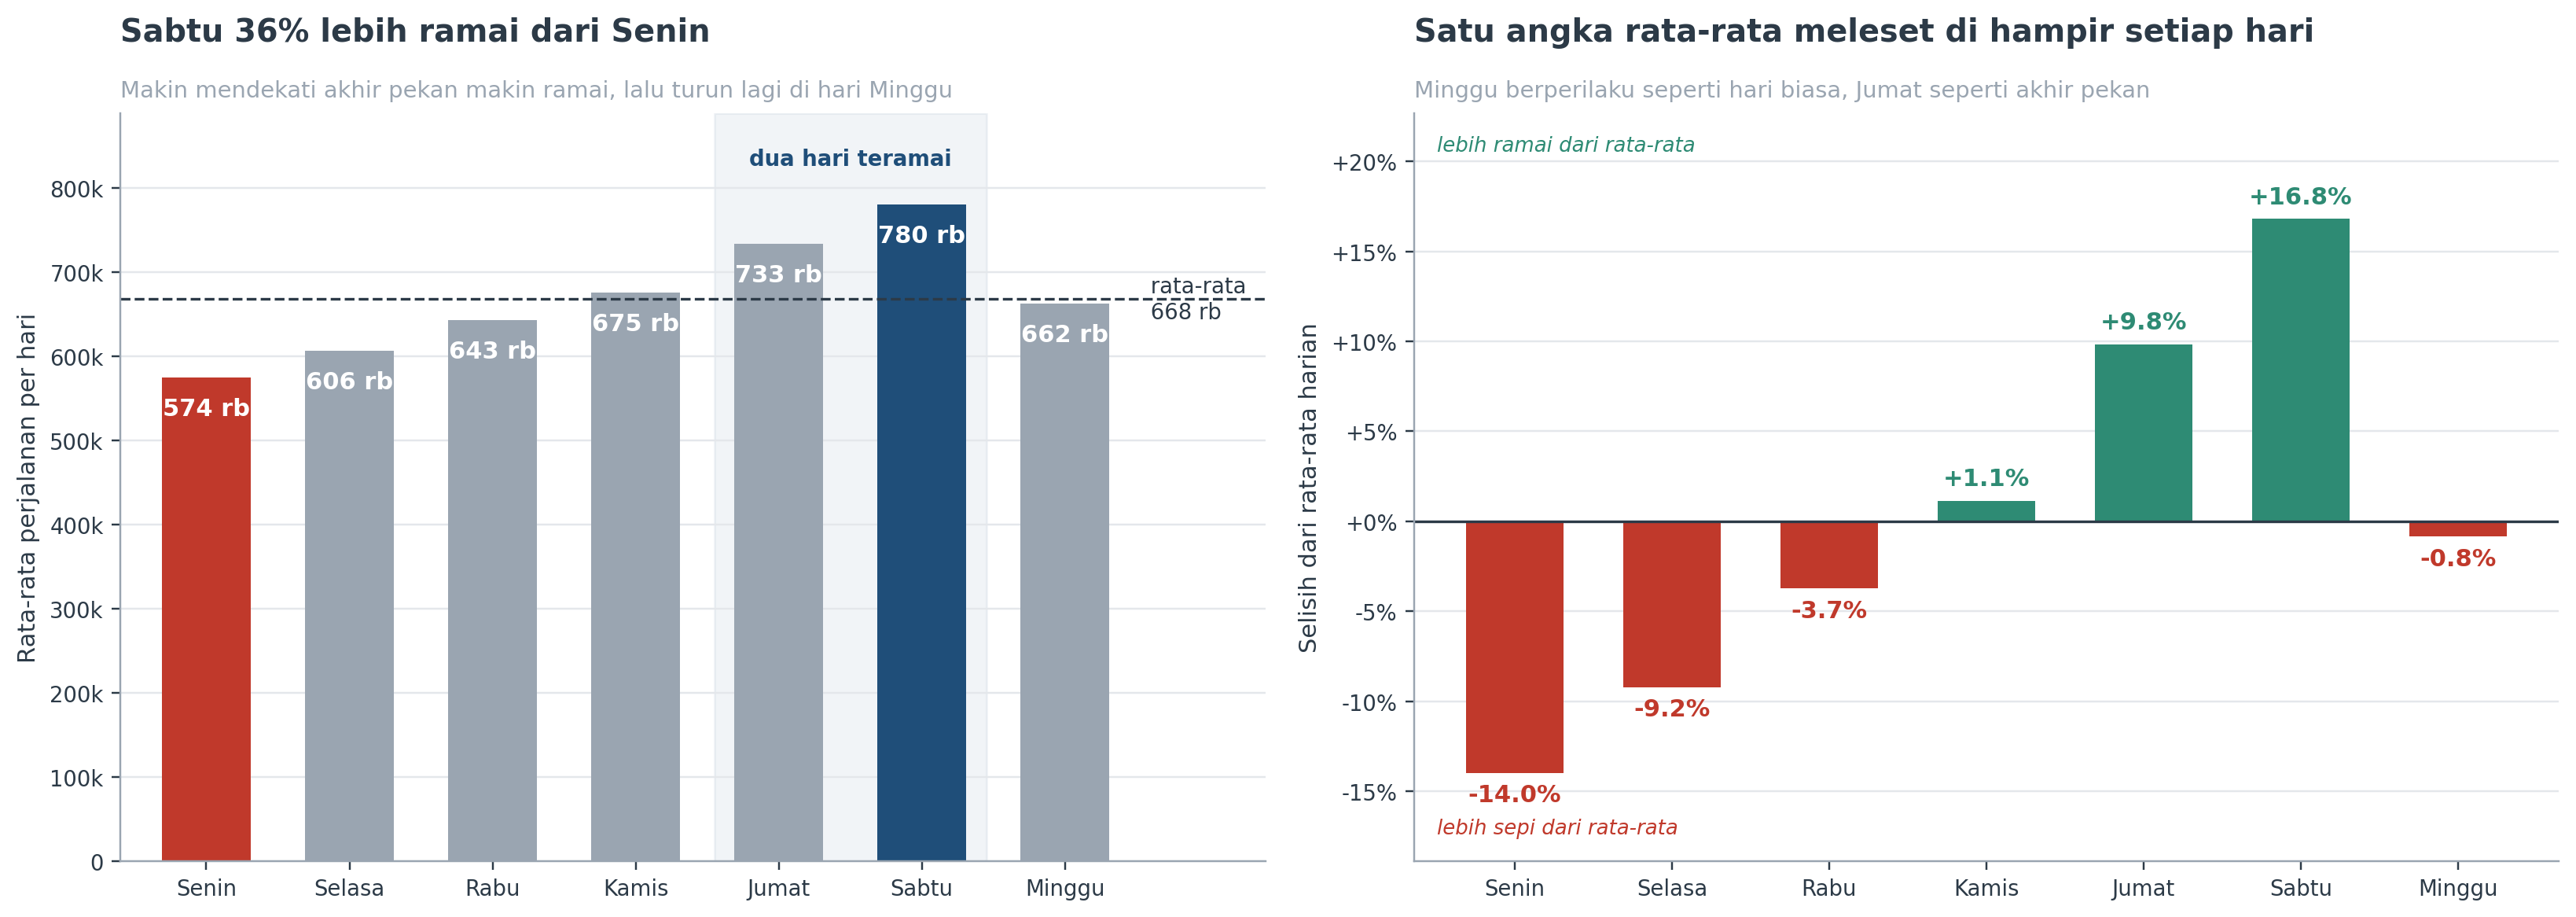

In [87]:
hi  = df_dow["demand_per_day"].max()
lo  = df_dow["demand_per_day"].min()
h_hi = df_dow.loc[df_dow["demand_per_day"].idxmax(), "hari"]
h_lo = df_dow.loc[df_dow["demand_per_day"].idxmin(), "hari"]
x = np.arange(len(df_dow))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

# ---------- Kiri: jumlah perjalanan per hari ----------
ax = axes[0]
warna = [C["primary"] if h == h_hi else C["alert"] if h == h_lo else C["muted"]
         for h in df_dow["hari"]]
ax.bar(x, df_dow["demand_per_day"], color=warna, width=0.62)

# Label angka di DALAM batang bagian atas, supaya tidak tertimpa garis rata-rata
for k, v in enumerate(df_dow["demand_per_day"]):
    ax.text(k, v - hi * 0.03, f"{v/1000:,.0f} rb", ha="center", va="top",
            fontsize=10, fontweight="bold", color="white")

ax.axhline(rata_harian, color=C["text"], linestyle="--", linewidth=1.1)
ax.text(len(x) - 0.45, rata_harian, f" rata-rata\n {rata_harian/1000:,.0f} rb",
        va="center", fontsize=9, color=C["text"])

# Tandai Jumat–Sabtu, pasangan hari teramai
ax.axvspan(3.55, 5.45, color=C["primary"], alpha=0.06, zorder=0)
ax.text(4.5, hi * 1.06, "dua hari teramai", ha="center",
        fontsize=9, color=C["primary"], fontweight="semibold")

ax.set_xticks(x)
ax.set_xticklabels(df_dow["hari"])
ax.set_xlim(-0.6, len(x) + 0.4)
ax.set_ylim(0, hi * 1.14)
ax.yaxis.set_major_formatter(FMT_K)
ax.set_ylabel("Rata-rata perjalanan per hari")
titled(ax, f"{h_hi} {(hi / lo - 1) * 100:.0f}% lebih ramai dari {h_lo}",
       "Makin mendekati akhir pekan makin ramai, lalu turun lagi di hari Minggu")
clean_axes(ax)

# ---------- Kanan: selisih dari rata-rata ----------
ax = axes[1]
sel = df_dow["selisih_pct"]
ax.bar(x, sel, color=[C["accent"] if v > 0 else C["alert"] for v in sel], width=0.62)
ax.axhline(0, color=C["text"], linewidth=1.1)

for k, v in enumerate(sel):
    ax.text(k, v + (0.6 if v >= 0 else -0.6), f"{v:+.1f}%",
            ha="center", va="bottom" if v >= 0 else "top",
            fontsize=10, fontweight="bold",
            color=C["accent"] if v > 0 else C["alert"])

ax.text(0.02, 0.97, "lebih ramai dari rata-rata", transform=ax.transAxes,
        fontsize=8.5, color=C["accent"], va="top", style="italic")
ax.text(0.02, 0.03, "lebih sepi dari rata-rata", transform=ax.transAxes,
        fontsize=8.5, color=C["alert"], va="bottom", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(df_dow["hari"])
ax.set_ylim(sel.min() * 1.35, sel.max() * 1.35)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:+.0f}%"))
ax.set_ylabel("Selisih dari rata-rata harian")
titled(ax, "Satu angka rata-rata meleset di hampir setiap hari",
       "Minggu berperilaku seperti hari biasa, Jumat seperti akhir pekan")
clean_axes(ax)

plt.tight_layout()
plt.show()

> **Cara membaca grafik**

**Panel kiri** — tiap batang adalah rata-rata jumlah perjalanan dalam satu hari. Batang biru adalah hari teramai, merah hari tersepi. Garis putus-putus adalah rata-rata seluruh hari. Area biru tipis menandai Jumat dan Sabtu, dua hari teramai.

**Panel kanan** — tiap batang menunjukkan seberapa jauh hari itu dari rata-rata. Hijau ke atas berarti lebih ramai dari rata-rata, merah ke bawah berarti lebih sepi. Semakin tinggi atau dalam batangnya, semakin besar kesalahan bila hari itu direncanakan dengan angka rata-rata.

In [88]:
# Cara umum : akhir pekan = Sabtu dan Minggu
# Cara data : akhir pekan = Jumat dan Sabtu, dua hari teramai
def bandingkan(akhir_pekan):
    ap = df_dow[df_dow["hari"].isin(akhir_pekan)]["demand_per_day"].mean()
    hk = df_dow[~df_dow["hari"].isin(akhir_pekan)]["demand_per_day"].mean()
    return hk, ap, (ap / hk - 1) * 100

hasil_ap = pd.DataFrame(
    [("Sabtu–Minggu (umum)", *bandingkan(["Sabtu", "Minggu"])),
     ("Jumat–Sabtu (dari data)", *bandingkan(["Jumat", "Sabtu"]))],
    columns=["pembagian", "hari_biasa", "akhir_pekan", "selisih_pct"],
).set_index("pembagian")

print("Semakin besar selisihnya, semakin tajam pembagian itu")
print("memisahkan hari ramai dari hari biasa.\n")
hasil_ap.style.format({"hari_biasa": "{:,.0f}", "akhir_pekan": "{:,.0f}",
                       "selisih_pct": "{:+.1f}%"})

Semakin besar selisihnya, semakin tajam pembagian itu
memisahkan hari ramai dari hari biasa.



,hari_biasa,akhir_pekan,selisih_pct
pembagian,,,
Sabtu–Minggu (umum),"646,534","721,186",+11.5%
Jumat–Sabtu (dari data),"632,308","756,751",+19.7%


> **Hasil Step 7 — hari dalam pekan**

Setiap hari muncul 126 kali selama periode data, sehingga perbandingan antar hari adil.

| Hari | Rata-rata per hari | Selisih dari rata-rata |
|---|---|---|
| Senin | 574.487 | −14,0% |
| Selasa | 606.331 | −9,2% |
| Rabu | 643.009 | −3,7% |
| Kamis | 675.439 | +1,1% |
| Jumat | 733.404 | +9,8% |
| Sabtu | 780.098 | +16,8% |
| Minggu | 662.275 | −0,8% |

**Temuan 1 — Permintaan naik seperti tangga dari Senin ke Sabtu**

Senin paling sepi, lalu setiap hari lebih ramai dari hari sebelumnya sampai puncaknya di Sabtu. Sabtu **35,8% lebih ramai** daripada Senin. Minggu turun kembali mendekati rata-rata.

**Temuan 2 — Satu angka rata-rata meleset di hampir setiap hari**

Rata-rata seluruh hari adalah 667.863 perjalanan. Bila armada disiapkan dengan angka itu setiap hari, Senin kelebihan sekitar 93 ribu perjalanan dan Sabtu kekurangan sekitar 112 ribu. Hanya Kamis dan Minggu yang dekat dengan rata-rata.

**Temuan 3 — Akhir pekan ride-hailing adalah Jumat–Sabtu, bukan Sabtu–Minggu**

Jumat (+9,8%) berperilaku seperti akhir pekan, sementara Minggu (−0,8%) justru mendekati hari biasa. Bila akhir pekan didefinisikan Jumat–Sabtu, selisih akhir pekan terhadap hari biasa mencapai **+19,7%**, jauh lebih tajam daripada pembagian umum Sabtu–Minggu yang hanya +11,5%.

Penyebabnya tidak dapat dibuktikan dari data ini. Kemungkinan terkait kegiatan keluar rumah pada Jumat dan Sabtu malam, sementara Minggu malam orang bersiap untuk hari kerja.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Mengarah **tidak memadai**: rata-rata harian meleset hingga −14% pada Senin dan +17% pada Sabtu |
| Akhir pekan = Sabtu dan Minggu | Mengarah **tidak berlaku**: Jumat–Sabtu memisahkan hari ramai jauh lebih tajam |

**Kaitannya dengan forecasting**

Kolom `is_weekend` di data menandai Sabtu–Minggu sebagai akhir pekan. Untuk model Phase 6, penanda itu kurang tepat. Lebih baik memakai hari dalam minggu secara langsung, atau membuat penanda baru berdasarkan pola yang terlihat di data.

**Kaitan dengan argumen utama**

Satu angka rata-rata harian meratakan selisih 36% antara hari tersepi dan teramai. Rata-rata yang terlihat wajar ternyata tidak mewakili hari mana pun secara tepat, kecuali Kamis dan Minggu.

> **Keputusan:** permintaan naik bertahap dari Senin ke Sabtu · rata-rata harian meleset hingga −14% dan +17% · akhir pekan ride-hailing adalah Jumat–Sabtu · penanda `is_weekend` perlu ditinjau ulang untuk model

---

# STEP 8 — Jam dalam Hari

**Tujuan:** melihat seberapa besar perbedaan permintaan antar jam dalam satu hari, dan apakah pola jamnya sama di setiap hari.

**Kenapa diperlukan:** satu angka harian yang dibagi rata ke 24 jam akan meratakan perbedaan antara jam sepi dan jam sibuk. Selain itu, bila pola jam berbeda antar hari, satu kurva harian juga tidak cukup.

**Hipotesis yang diuji:**

| Hipotesis | Pertanyaan |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Apakah satu angka rata-rata per jam mewakili jam sepi dan jam sibuk? |
| H2 — satu pola jam berlaku untuk semua | Apakah bentuk kurva harian sama di setiap hari? |

**Input:** `mart_hourly_demand`, dirangkum per jam.

**Catatan hari operasional:** pada grafik kedua, satu hari dihitung mulai jam 05:00 sampai jam 04:59 esok harinya. Perjalanan Sabtu jam 01:00 karena itu dihitung sebagai Jumat malam. Cara ini dipakai karena keramaian malam hari sering berlanjut melewati tengah malam.

**Expected output:**
1. Tabel 24 jam: rata-rata perjalanan per jam
2. Grafik pola jam seluruh hari
3. Grafik pola jam untuk Senin–Kamis, Jumat, Sabtu, dan Minggu
4. Perbandingan keramaian lewat tengah malam

**Cara interpretasi:**
- Semakin jauh jarak jam tersibuk dan tersepi, semakin tidak memadai satu angka rata-rata per jam
- Bila garis tiap kelompok hari punya puncak di jam berbeda, satu pola jam tidak cukup untuk seluruh hari

In [89]:
sql = f"""
SELECT
    hour,
    SUM(demand)                                AS total_demand,
    SUM(demand) / COUNT(DISTINCT request_date) AS demand_per_hour_avg
FROM {MART_DEMAND}
GROUP BY hour
ORDER BY hour
"""

df_hourly = run_query(sql)
rata_jam = df_hourly["demand_per_hour_avg"].mean()
df_hourly["selisih_pct"] = (df_hourly["demand_per_hour_avg"] / rata_jam - 1) * 100

df_hourly.set_index("hour").style.format({
    "total_demand": "{:,.0f}", "demand_per_hour_avg": "{:,.0f}",
    "selisih_pct": "{:+.1f}%"})

Rows returned : 24
Bytes billed  : 0.0000 GB


,total_demand,demand_per_hour_avg,selisih_pct
hour,,,
0,"20,528,544","23,275",-16.4%
1,"14,476,202","16,413",-41.0%
2,"10,381,125","11,770",-57.7%
3,"8,646,650","9,803",-64.8%
4,"8,948,725","10,146",-63.5%
5,"10,983,868","12,453",-55.2%
6,"17,179,921","19,478",-30.0%
7,"25,493,758","28,904",+3.9%
8,"29,720,869","33,697",+21.1%


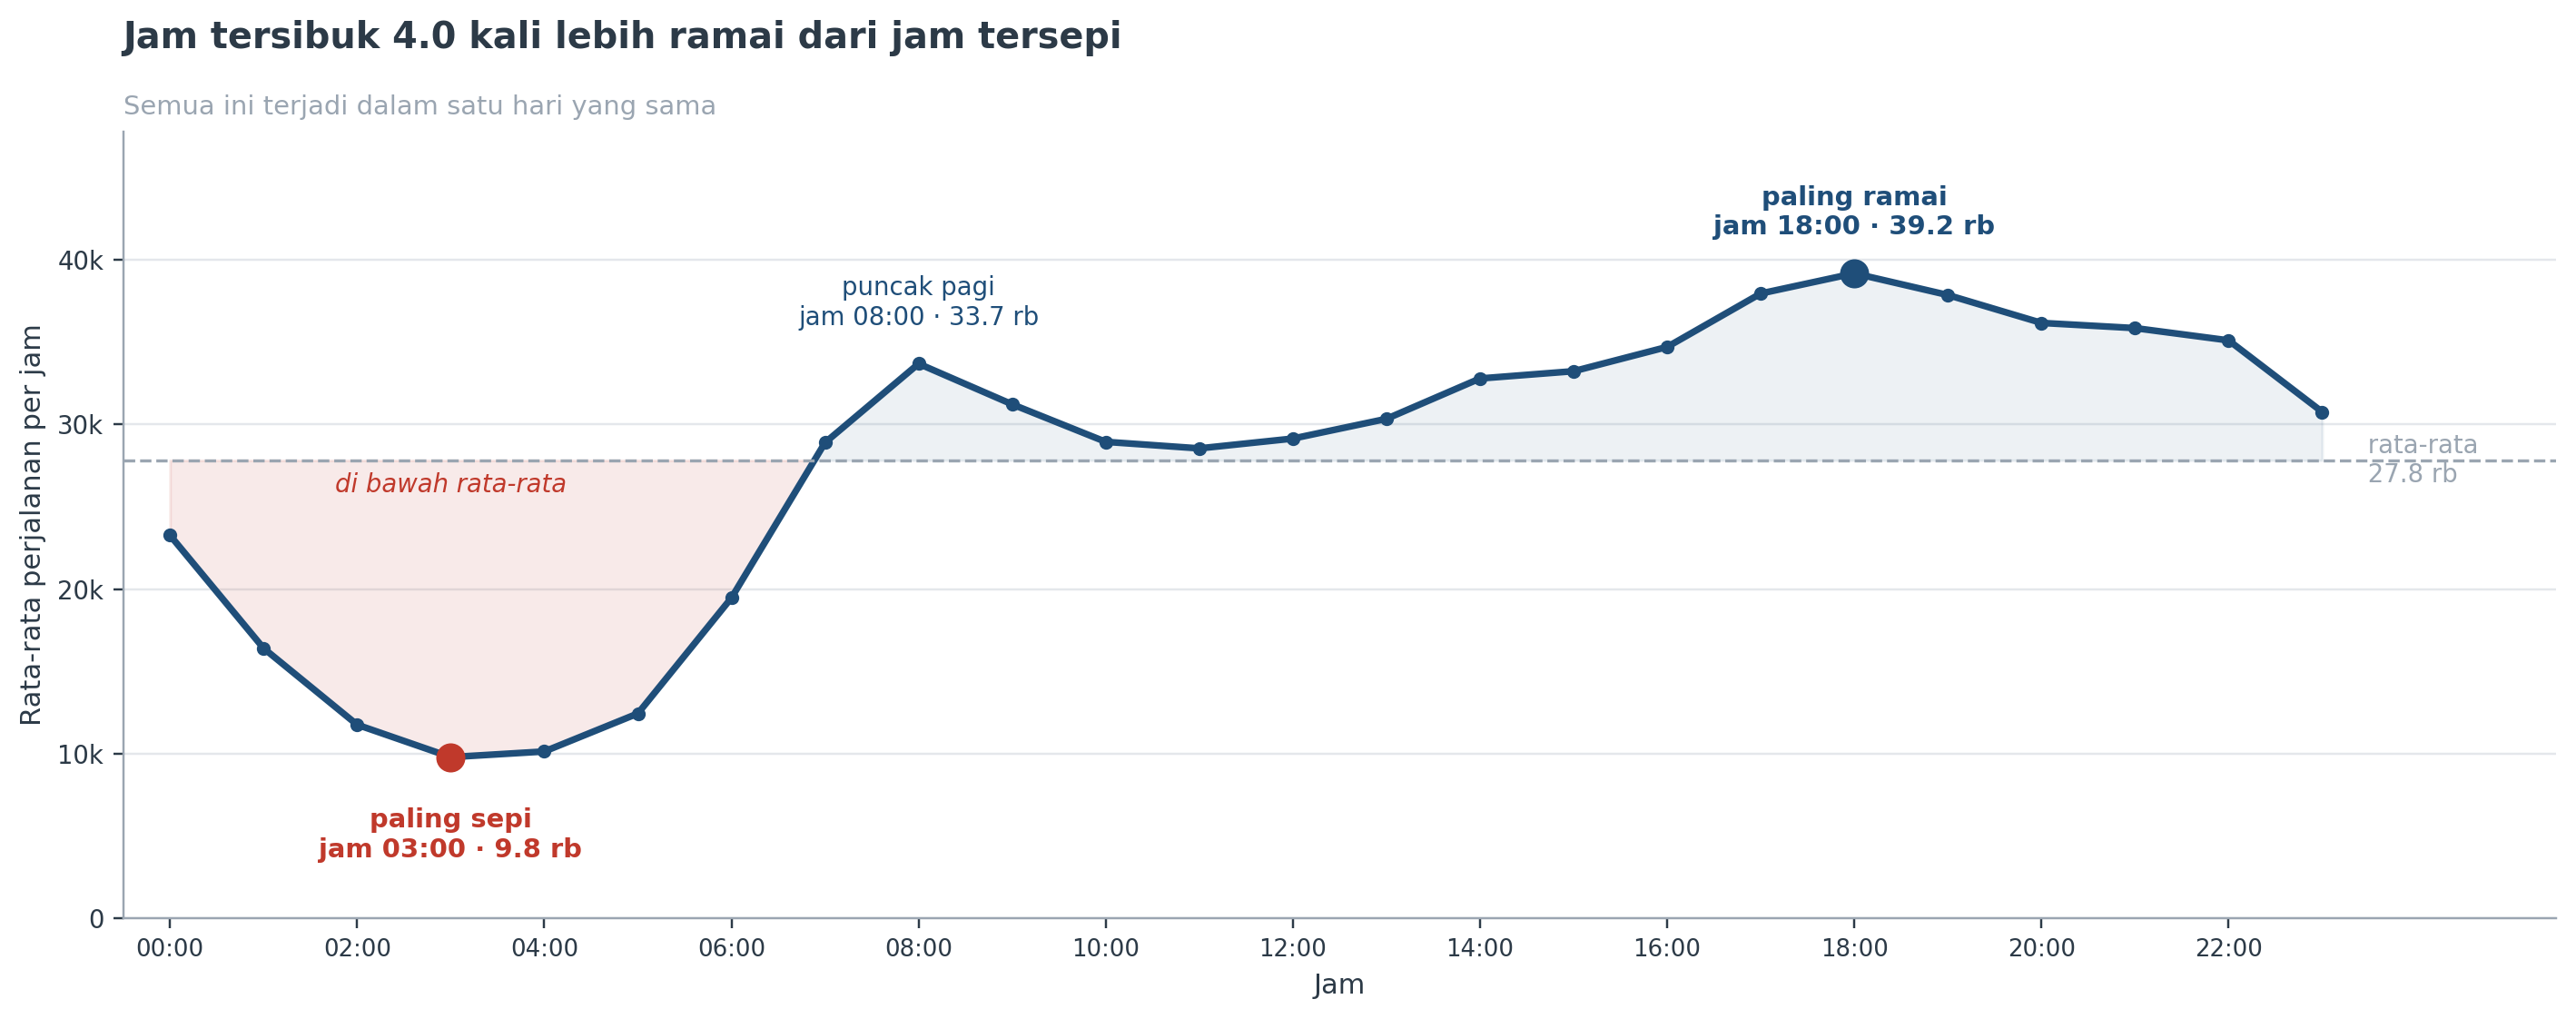

Jam tersibuk : 18:00  (39,186)
Jam tersepi  : 03:00  (9,803)
Rasio        : 4.0 kali
Jam di bawah rata-rata : 00, 01, 02, 03, 04, 05, 06


In [90]:
hi, lo = df_hourly["demand_per_hour_avg"].max(), df_hourly["demand_per_hour_avg"].min()
h_hi = int(df_hourly.loc[df_hourly["demand_per_hour_avg"].idxmax(), "hour"])
h_lo = int(df_hourly.loc[df_hourly["demand_per_hour_avg"].idxmin(), "hour"])
y = df_hourly["demand_per_hour_avg"].values
xh = df_hourly["hour"].values

fig, ax = plt.subplots(figsize=(13, 5.2))

# Arsir jam yang berada di bawah rata-rata
ax.fill_between(xh, y, rata_jam, where=y < rata_jam, interpolate=True,
                color=C["alert"], alpha=0.10)
ax.fill_between(xh, y, rata_jam, where=y >= rata_jam, interpolate=True,
                color=C["primary"], alpha=0.08)

ax.plot(xh, y, color=C["primary"], marker="o", markersize=4, linewidth=2.4)
ax.axhline(rata_jam, color=C["muted"], linestyle="--", linewidth=1.1)
ax.text(23.4, rata_jam, f" rata-rata\n {rata_jam/1000:,.1f} rb",
        va="center", fontsize=9, color=C["muted"])

for h, v, teks, colr, dy in [(h_hi, hi, "paling ramai", C["primary"], 14),
                             (h_lo, lo, "paling sepi",  C["alert"],  -36)]:
    ax.scatter([h], [v], s=90, color=colr, zorder=5)
    ax.annotate(f"{teks}\njam {h:02d}:00 · {v/1000:,.1f} rb",
                xy=(h, v), xytext=(0, dy), textcoords="offset points",
                ha="center", fontsize=9.5, color=colr, fontweight="semibold")

# Puncak pagi
k8 = 8
ax.annotate(f"puncak pagi\njam 08:00 · {y[k8]/1000:,.1f} rb",
            xy=(k8, y[k8]), xytext=(0, 14), textcoords="offset points",
            ha="center", fontsize=9, color=C["primary"])

ax.text(3, rata_jam * 0.93, "di bawah rata-rata", ha="center",
        fontsize=9, color=C["alert"], style="italic")

ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], fontsize=8.5)
ax.set_xlim(-0.5, 25.5)
ax.set_ylim(0, hi * 1.22)
ax.yaxis.set_major_formatter(FMT_K)
ax.set_xlabel("Jam")
ax.set_ylabel("Rata-rata perjalanan per jam")
titled(ax, f"Jam tersibuk {hi / lo:.1f} kali lebih ramai dari jam tersepi",
       "Semua ini terjadi dalam satu hari yang sama")
clean_axes(ax)

plt.tight_layout()
plt.show()

print(f"Jam tersibuk : {h_hi:02d}:00  ({hi:,.0f})")
print(f"Jam tersepi  : {h_lo:02d}:00  ({lo:,.0f})")
print(f"Rasio        : {hi / lo:.1f} kali")
print(f"Jam di bawah rata-rata : {', '.join(f'{h:02d}' for h in xh[y < rata_jam])}")

In [91]:
# Hari operasional dimulai jam 05:00.
# Perjalanan jam 00:00–04:59 dihitung sebagai malam hari sebelumnya.
sql = f"""
WITH base AS (
    SELECT
        hour,
        demand,
        IF(hour < 5, DATE_SUB(request_date, INTERVAL 1 DAY), request_date) AS op_date
    FROM {MART_DEMAND}
),
dikelompokkan AS (
    SELECT
        hour,
        demand,
        op_date,
        CASE EXTRACT(DAYOFWEEK FROM op_date)
            WHEN 6 THEN 'Jumat'
            WHEN 7 THEN 'Sabtu'
            WHEN 1 THEN 'Minggu'
            ELSE 'Senin–Kamis'
        END AS kelompok
    FROM base
    -- Buang hari operasional yang tidak lengkap di ujung periode data
    WHERE op_date >= DATE '2024-01-01'
      AND op_date <= DATE '2026-05-30'
)
SELECT
    kelompok,
    hour,
    SUM(demand) / COUNT(DISTINCT op_date) AS demand_per_hour_avg
FROM dikelompokkan
GROUP BY kelompok, hour
ORDER BY kelompok, hour
"""

df_hour_grp = run_query(sql)

# Urutan jam dimulai dari 05:00 sesuai hari operasional
URUT_JAM = list(range(5, 24)) + list(range(0, 5))
pivot_grp = (df_hour_grp
             .pivot(index="hour", columns="kelompok", values="demand_per_hour_avg")
             .loc[URUT_JAM, ["Senin–Kamis", "Jumat", "Sabtu", "Minggu"]])

pivot_grp.index = [f"{h:02d}" for h in pivot_grp.index]
pivot_grp.style.format("{:,.0f}")

Rows returned : 96
Bytes billed  : 0.0000 GB


kelompok,Senin–Kamis,Jumat,Sabtu,Minggu
05,"12,380","13,419","11,987","12,244"
06,"21,317","21,866","15,030","14,175"
07,"33,368","33,499","18,670","16,685"
08,"38,721","38,025","23,478","19,480"
09,"33,012","33,194","28,262","25,093"
10,"28,068","29,854","30,891","29,627"
11,"26,594","29,343","33,055","31,092"
12,"26,830","30,414","34,335","31,969"
13,"28,199","31,721","35,434","32,484"
14,"31,207","34,587","36,654","33,523"


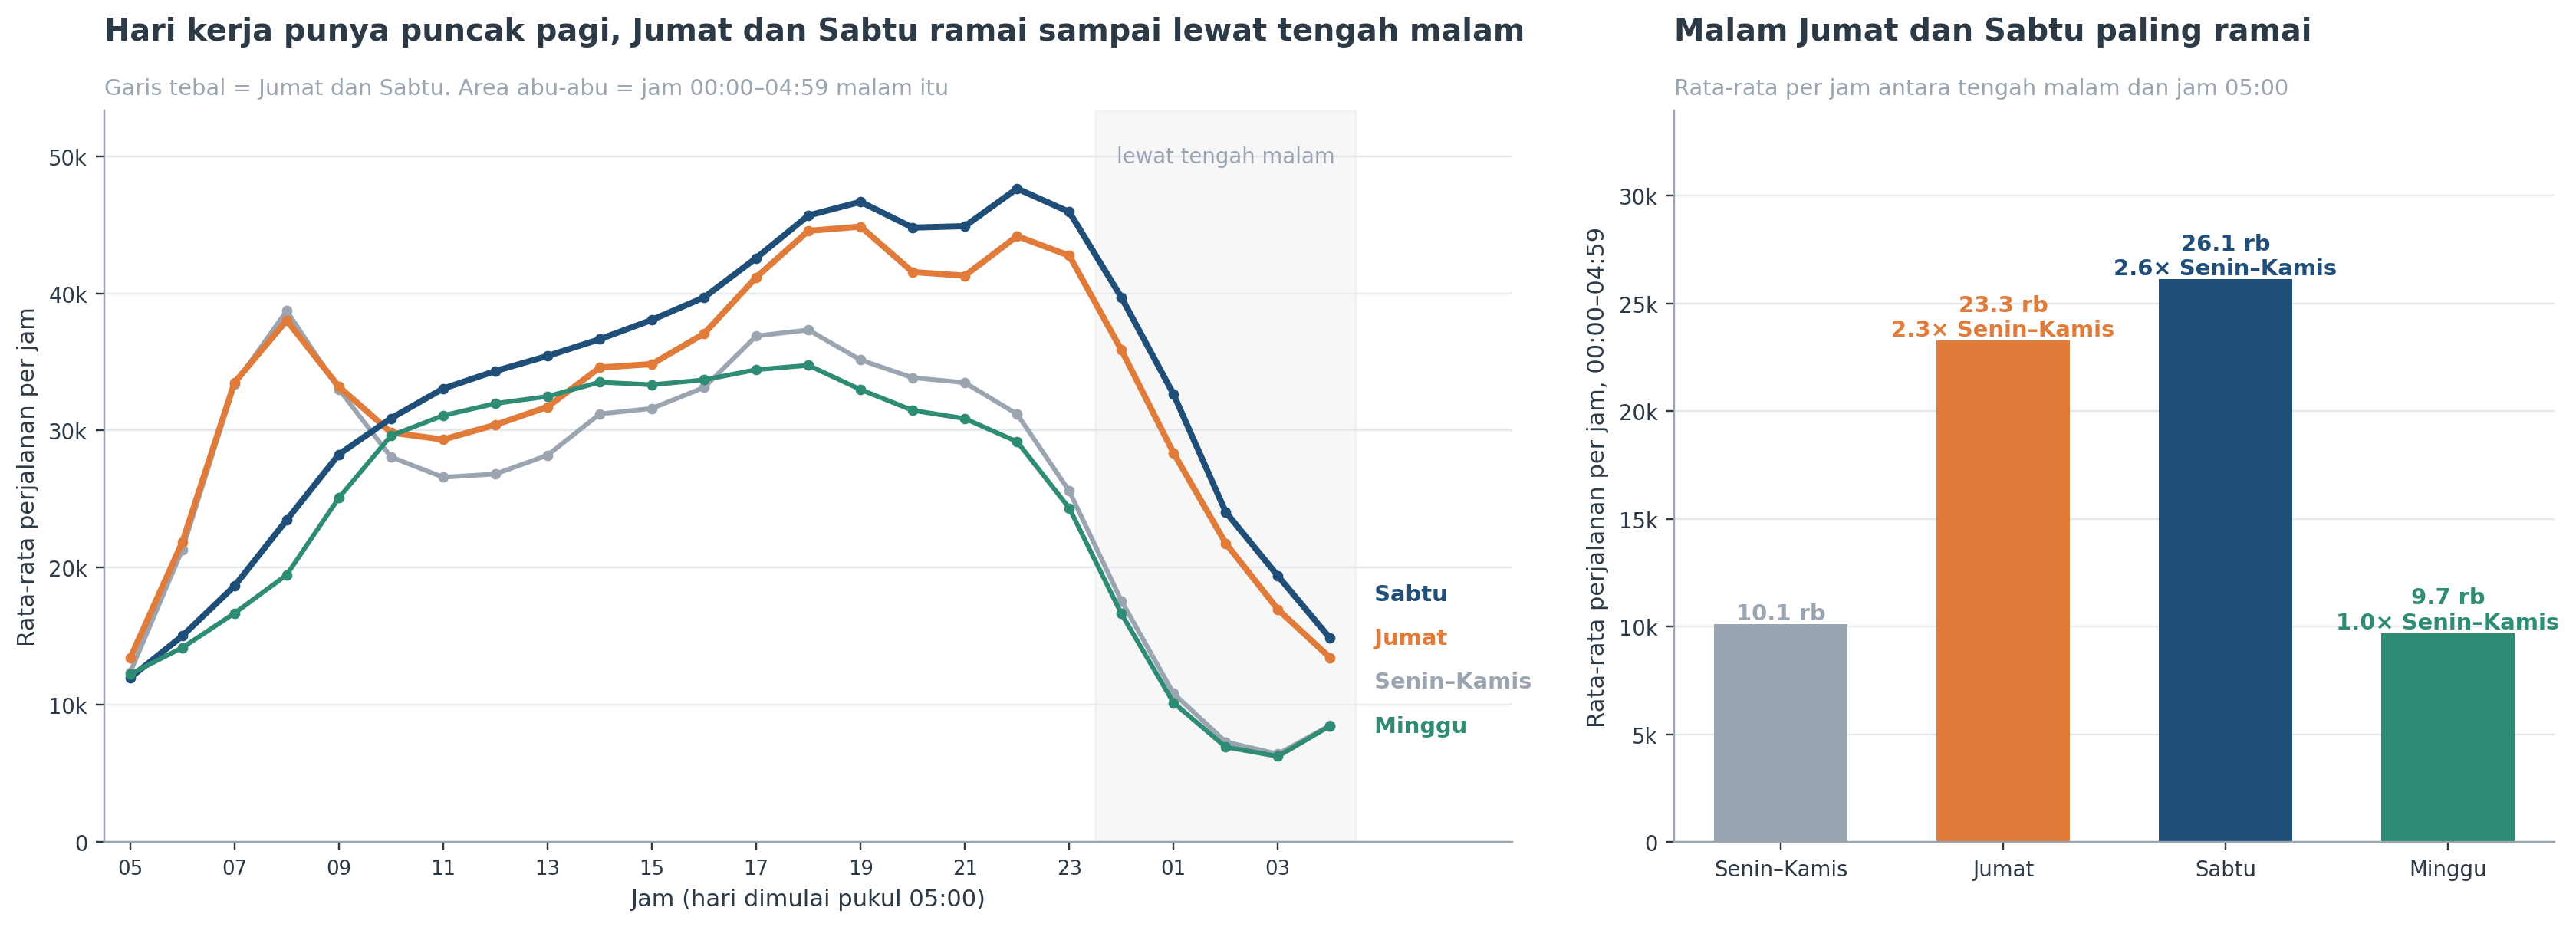

Rata-rata perjalanan per jam, 00:00–04:59:
  Senin–Kamis     10,135   (1.0× Senin–Kamis)
  Jumat           23,280   (2.3× Senin–Kamis)
  Sabtu           26,129   (2.6× Senin–Kamis)
  Minggu           9,695   (1.0× Senin–Kamis)

Jam puncak tiap kelompok:
  Senin–Kamis  jam 08:00  (38,721)
  Jumat        jam 19:00  (44,861)
  Sabtu        jam 22:00  (47,630)
  Minggu       jam 18:00  (34,751)


In [92]:
WARNA_GRP = {"Senin–Kamis": C["muted"], "Jumat": C["secondary"],
             "Sabtu": C["primary"], "Minggu": C["accent"]}
xg = np.arange(len(URUT_JAM))
k_malam = URUT_JAM.index(0)          # posisi jam 00:00 di sumbu

# Rata-rata keramaian lewat tengah malam (00:00–04:59)
malam = pivot_grp.iloc[k_malam:].mean()

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.6),
                         gridspec_kw={"width_ratios": [1.6, 1]})

# ---------- Kiri: kurva jam tiap kelompok ----------
ax = axes[0]
ax.axvspan(k_malam - 0.5, len(xg) - 0.5, color=C["muted"], alpha=0.08, zorder=0)
ax.text((k_malam + len(xg) - 1) / 2, pivot_grp.values.max() * 1.04,
        "lewat tengah malam", ha="center", fontsize=9, color=C["muted"])

for g, colr in WARNA_GRP.items():
    ax.plot(xg, pivot_grp[g], color=colr, marker="o", markersize=3.5,
            linewidth=2.6 if g in ("Jumat", "Sabtu") else 2)

# Label kelompok di ujung garis, digeser bila berdekatan
ujung = sorted([(pivot_grp[g].iloc[-1], g, c) for g, c in WARNA_GRP.items()])
lo_y, hi_y = 0, pivot_grp.values.max() * 1.12
jarak = (hi_y - lo_y) * 0.06
pos = []
for v, g, c in ujung:
    yt = v if not pos else max(v, pos[-1] + jarak)
    pos.append(yt)
    ax.text(len(xg) - 0.3, yt, f" {g}", va="center", fontsize=9.5,
            color=c, fontweight="bold")

ax.set_xticks(xg[::2])
ax.set_xticklabels([f"{h:02d}" for h in URUT_JAM[::2]], fontsize=8.5)
ax.set_xlim(-0.5, len(xg) + 2.5)
ax.set_ylim(lo_y, hi_y)
ax.yaxis.set_major_formatter(FMT_K)
ax.set_xlabel("Jam (hari dimulai pukul 05:00)")
ax.set_ylabel("Rata-rata perjalanan per jam")
titled(ax, "Hari kerja punya puncak pagi, Jumat dan Sabtu ramai sampai lewat tengah malam",
       "Garis tebal = Jumat dan Sabtu. Area abu-abu = jam 00:00–04:59 malam itu")
clean_axes(ax)

# ---------- Kanan: keramaian lewat tengah malam ----------
ax = axes[1]
urut = ["Senin–Kamis", "Jumat", "Sabtu", "Minggu"]
vals = [malam[g] for g in urut]
basis = malam["Senin–Kamis"]
ax.bar(urut, vals, color=[WARNA_GRP[g] for g in urut], width=0.6)
for k, (g, v) in enumerate(zip(urut, vals)):
    label = f"{v/1000:,.1f} rb"
    if g != "Senin–Kamis":
        label += f"\n{v / basis:.1f}× Senin–Kamis"
    ax.text(k, v, label, ha="center", va="bottom", fontsize=9.5,
            fontweight="semibold", color=WARNA_GRP[g])
ax.set_ylim(0, max(vals) * 1.3)
ax.yaxis.set_major_formatter(FMT_K)
ax.set_ylabel("Rata-rata perjalanan per jam, 00:00–04:59")
titled(ax, "Malam Jumat dan Sabtu paling ramai",
       "Rata-rata per jam antara tengah malam dan jam 05:00")
clean_axes(ax)

plt.tight_layout()
plt.show()

print("Rata-rata perjalanan per jam, 00:00–04:59:")
for g in urut:
    print(f"  {g:12} {malam[g]:>9,.0f}   ({malam[g] / basis:.1f}× Senin–Kamis)")
print("\nJam puncak tiap kelompok:")
for g in urut:
    h = pivot_grp[g].idxmax()
    print(f"  {g:12} jam {h}:00  ({pivot_grp[g].max():,.0f})")

> **Cara membaca grafik**

**Grafik pola jam keseluruhan** — garis menunjukkan rata-rata perjalanan pada tiap jam. Garis putus-putus adalah rata-rata seluruh jam. Area merah tipis adalah jam yang lebih sepi dari rata-rata, area biru tipis jam yang lebih ramai.

**Grafik pola jam per kelompok hari, panel kiri** — sumbu bawah dimulai dari jam 05:00, karena satu hari dihitung mulai pukul 05:00. Area abu-abu di sisi kanan adalah jam 00:00–04:59 setelah malam itu. Jadi titik jam 01:00 pada garis Jumat berarti Jumat malam lewat tengah malam, bukan Jumat dini hari. Garis tebal adalah Jumat dan Sabtu.

**Panel kanan** — setiap batang adalah rata-rata perjalanan per jam antara tengah malam dan jam 05:00. Angka di bawahnya membandingkan kelompok itu dengan Senin–Kamis.

> **Hasil Step 8 — jam dalam hari**

Rata-rata seluruh jam adalah 27.828 perjalanan per jam.

**Temuan 1 — Jam tersibuk 4 kali lebih ramai dari jam tersepi**

Jam 03:00 paling sepi (9.803 perjalanan) dan jam 18:00 paling ramai (39.186 perjalanan). Dalam satu hari yang sama, permintaan bergerak empat kali lipat. Selisih ini jauh lebih besar daripada perbedaan antar hari dalam seminggu, yang hanya sekitar 36%.

**Temuan 2 — Tujuh jam malam berada di bawah rata-rata**

Jam 00:00 sampai 06:00 lebih sepi dari rata-rata, sementara jam 07:00 sampai 23:00 lebih ramai. Satu angka rata-rata per jam akan berlebihan di tujuh jam malam dan kekurangan di tujuh belas jam sisanya.

**Temuan 3 — Pola sehari punya dua puncak**

Permintaan naik tajam pada pagi hari dengan puncak pertama jam 08:00 (33.697), turun sedikit menjelang siang, lalu naik perlahan sampai puncak utama jam 18:00. Setelah itu turun bertahap, tetapi tetap di atas rata-rata sampai jam 23:00.

**Temuan 4 — Puncak pagi hanya ada di hari kerja**

Senin–Kamis dan Jumat sama-sama memuncak pada jam 08:00, pola orang berangkat kerja. Sabtu dan Minggu tidak punya puncak pagi sama sekali; permintaannya naik perlahan sejak subuh. Puncak pagi yang terlihat pada grafik keseluruhan karena itu hanya berasal dari hari kerja, dan tingginya teredam oleh akhir pekan.

**Temuan 5 — Jumat adalah hari peralihan, Sabtu malam paling ramai**

Jumat berperilaku seperti hari kerja pada pagi hari, lalu seperti akhir pekan pada malam hari. Sabtu memiliki puncak paling tinggi dan paling larut, sekitar jam 22:00.

Keramaian lewat tengah malam (00:00–04:59) memperjelas perbedaannya:

| Malam | Rata-rata per jam | Dibanding Senin–Kamis |
|---|---|---|
| Senin–Kamis | 10,1 rb | — |
| Jumat | 23,3 rb | **2,3 kali** |
| Sabtu | 26,1 rb | **2,6 kali** |
| Minggu | 9,7 rb | 1,0 kali |

Minggu malam sepi seperti malam hari kerja. Ini menegaskan bahwa akhir pekan ride-hailing adalah Jumat dan Sabtu malam, bukan Sabtu dan Minggu.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Mengarah **tidak memadai**: dalam satu hari permintaan bergerak empat kali lipat |
| H2 — satu pola jam berlaku untuk semua | Mengarah **tidak berlaku**: hari kerja punya puncak pagi, akhir pekan tidak; Sabtu memuncak paling larut; malam Jumat dan Sabtu dua kali lebih ramai dari malam lainnya |

**Keterbatasan**

Hari operasional dihitung mulai jam 05:00. Batas ini dipilih karena jam 03:00–05:00 adalah titik tersepi, sehingga paling sedikit memotong kegiatan yang sedang berlangsung. Batas lain dapat sedikit mengubah angka keramaian malam, tetapi tidak mengubah polanya.

**Kaitan dengan argumen utama**

Semakin rinci dilihat, semakin besar variasi yang disembunyikan rata-rata: selisih antar bulan tertutupi jumlah hari, selisih antar hari mencapai 36%, dan selisih antar jam mencapai empat kali lipat. Pola jam juga berbeda antar hari, sehingga satu kurva harian pun tidak cukup.

> **Keputusan:** jam tersibuk 4 kali lebih ramai dari jam tersepi · puncak pagi hanya milik hari kerja · Jumat adalah hari peralihan · malam Jumat dan Sabtu 2,3–2,6 kali lebih ramai · pola jam berbeda antar hari, sehingga model perlu mengenali kombinasi hari dan jam

---

# STEP 9 — Zona dan Provider

**Tujuan:** melihat apakah permintaan menumpuk di sedikit zona, dan apakah pembagian Uber dan Lyft sama di semua zona serta tetap dari waktu ke waktu.

**Kenapa diperlukan:** bila permintaan menumpuk di sedikit zona, perencanaan cukup fokus di zona-zona itu. Bila tersebar, rata-rata kota tidak mewakili zona mana pun. Untuk provider, bila pembagiannya sama di semua zona dan tetap dari waktu ke waktu, keduanya cukup direncanakan bersama.

**Hipotesis yang diuji:**

| Hipotesis | Pertanyaan |
|---|---|
| H1 — permintaan cukup terkonsentrasi | Apakah sebagian kecil zona menampung sebagian besar permintaan? |
| H3 — kedua provider bergerak searah | Apakah porsi Uber dan Lyft sama di semua zona, dan tetap dari 2024 ke 2026? |

**Pembanding:** bila permintaan tersebar sama rata di 263 zona aktif, sepuluh zona teratas akan menampung sekitar 3,8% permintaan.

**Input:** `mart_hourly_demand`, dirangkum per zona pickup dan per provider. Nama zona diambil dari taxi zone lookup TLC.

**Expected output:**
1. Tabel peringkat zona beserta nama zonanya
2. Grafik penumpukan permintaan antar zona
3. Grafik porsi Uber per zona dan pergeserannya dari 2024 ke 2026

**Cara interpretasi:**
- Semakin besar porsi yang ditampung sedikit zona teratas, semakin terkonsentrasi permintaannya
- Porsi provider yang menumpuk rapat di satu angka berarti pembagiannya sama di hampir semua zona
- Pergeseran yang searah di sebagian besar zona berarti rasio antar provider berubah menyeluruh, bukan di satu dua tempat

In [93]:
sql = f"""
WITH zone_total AS (
    SELECT pickup_location_id, SUM(demand) AS total_demand
    FROM {MART_DEMAND}
    GROUP BY pickup_location_id
),
ranked AS (
    SELECT
        pickup_location_id,
        total_demand,
        ROW_NUMBER() OVER (ORDER BY total_demand DESC) AS zone_rank,
        SUM(total_demand) OVER ()                      AS grand_total
    FROM zone_total
)
SELECT
    zone_rank,
    pickup_location_id,
    total_demand,
    total_demand / grand_total * 100                                AS share_pct,
    SUM(total_demand) OVER (ORDER BY zone_rank) / grand_total * 100 AS cum_share_pct
FROM ranked
ORDER BY zone_rank
"""

df_zone = run_query(sql)

# Nama zona dari taxi zone lookup TLC
URL_LOOKUP = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
try:
    lookup = pd.read_csv(URL_LOOKUP)
    df_zone = df_zone.merge(
        lookup.rename(columns={"LocationID": "pickup_location_id",
                               "Zone": "nama_zona", "Borough": "borough"})
              [["pickup_location_id", "nama_zona", "borough"]],
        on="pickup_location_id", how="left")
except Exception as e:
    print("Taxi zone lookup tidak dapat diunduh:", e)
    df_zone["nama_zona"], df_zone["borough"] = "—", "—"

n_zona = len(df_zone)
def top(k):
    return df_zone.loc[df_zone["zone_rank"] == k, "cum_share_pct"].values[0]

print(f"Zona aktif : {n_zona}\n")
for k in [10, 20, 50, 100]:
    print(f"Top-{k:<4} zona : {top(k):5.1f}%")
print(f"\nZona yang dibutuhkan untuk 50% permintaan : "
      f"{int((df_zone['cum_share_pct'] < 50).sum()) + 1}")
print(f"Zona yang dibutuhkan untuk 80% permintaan : "
      f"{int((df_zone['cum_share_pct'] < 80).sum()) + 1}\n")

df_zone.head(15)[["zone_rank", "pickup_location_id", "nama_zona", "borough",
                  "total_demand", "share_pct", "cum_share_pct"]] \
    .set_index("zone_rank").style.format({
        "total_demand": "{:,.0f}", "share_pct": "{:.2f}%", "cum_share_pct": "{:.1f}%"})

Rows returned : 263
Bytes billed  : 0.0000 GB
Zona aktif : 263

Top-10   zona :  12.9%
Top-20   zona :  22.8%
Top-50   zona :  45.2%
Top-100  zona :  71.1%

Zona yang dibutuhkan untuk 50% permintaan : 58
Zona yang dibutuhkan untuk 80% permintaan : 126



,pickup_location_id,nama_zona,borough,total_demand,share_pct,cum_share_pct
zone_rank,,,,,,
1,138,LaGuardia Airport,Queens,"11,643,505",1.98%,2.0%
2,132,JFK Airport,Queens,"10,014,597",1.70%,3.7%
3,61,Crown Heights North,Brooklyn,"7,680,571",1.30%,5.0%
4,79,East Village,Manhattan,"7,284,817",1.24%,6.2%
5,230,Times Sq/Theatre District,Manhattan,"7,000,104",1.19%,7.4%
6,161,Midtown Center,Manhattan,"6,797,960",1.15%,8.6%
7,76,East New York,Brooklyn,"6,554,083",1.11%,9.7%
8,231,TriBeCa/Civic Center,Manhattan,"6,474,440",1.10%,10.8%
9,37,Bushwick South,Brooklyn,"6,472,451",1.10%,11.9%


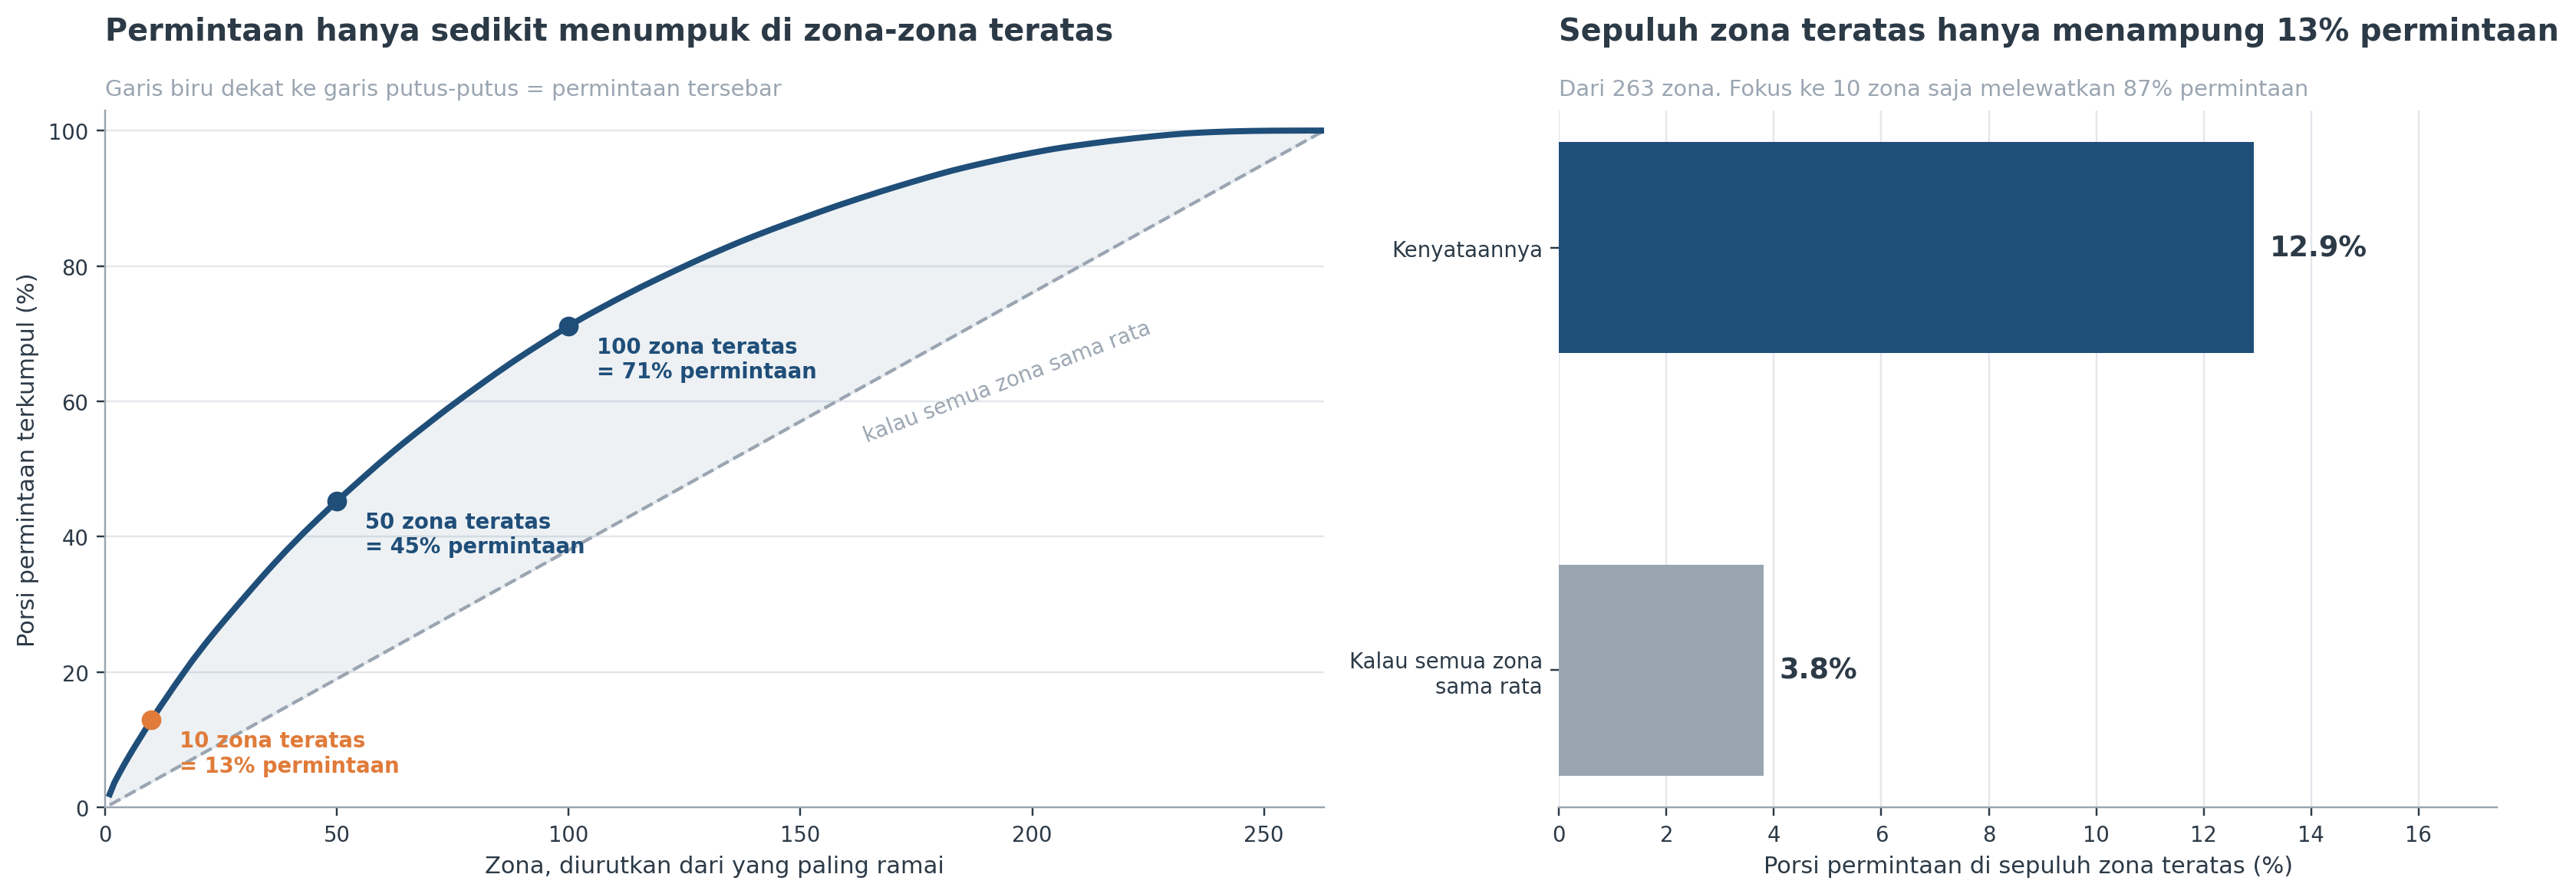

In [94]:
top10   = top(10)
merata  = 10 / n_zona * 100
x_rank  = df_zone["zone_rank"].values
y_cum   = df_zone["cum_share_pct"].values
y_rata  = x_rank / n_zona * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4),
                         gridspec_kw={"width_ratios": [1.3, 1]})

# ---------- Kiri: kurva penumpukan ----------
ax = axes[0]
ax.fill_between(x_rank, y_cum, y_rata, color=C["primary"], alpha=0.08)
ax.plot(x_rank, y_rata, color=C["muted"], linestyle="--", linewidth=1.4)
ax.plot(x_rank, y_cum,  color=C["primary"], linewidth=2.6)

for k, colr in [(10, C["secondary"]), (50, C["primary"]), (100, C["primary"])]:
    v = top(k)
    ax.scatter([k], [v], s=55, color=colr, zorder=5)
    ax.annotate(f"{k} zona teratas\n= {v:.0f}% permintaan", xy=(k, v),
                xytext=(12, -22), textcoords="offset points",
                fontsize=9, color=colr, fontweight="semibold")

ax.text(n_zona * 0.62, n_zona * 0.62 / n_zona * 100 - 8,
        "kalau semua zona sama rata", color=C["muted"], fontsize=9, rotation=21)

ax.set_xlim(0, n_zona)
ax.set_ylim(0, 103)
ax.set_xlabel("Zona, diurutkan dari yang paling ramai")
ax.set_ylabel("Porsi permintaan terkumpul (%)")
titled(ax, "Permintaan hanya sedikit menumpuk di zona-zona teratas",
       "Garis biru dekat ke garis putus-putus = permintaan tersebar")
clean_axes(ax)

# ---------- Kanan: sepuluh zona teratas ----------
ax = axes[1]
bars = ax.barh(["Kalau semua zona\nsama rata", "Kenyataannya"], [merata, top10],
               color=[C["muted"], C["primary"]], height=0.5)
for b, v in zip(bars, [merata, top10]):
    ax.text(v + 0.3, b.get_y() + b.get_height() / 2, f"{v:.1f}%",
            va="center", fontsize=12, fontweight="bold", color=C["text"])
ax.set_xlim(0, top10 * 1.35)
ax.set_xlabel("Porsi permintaan di sepuluh zona teratas (%)")
titled(ax, f"Sepuluh zona teratas hanya menampung {top10:.0f}% permintaan",
       f"Dari {n_zona} zona. Fokus ke 10 zona saja melewatkan {100 - top10:.0f}% permintaan")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

In [95]:
sql = f"""
WITH zone_provider AS (
    SELECT pickup_location_id, provider, SUM(demand) AS demand
    FROM {MART_DEMAND}
    GROUP BY pickup_location_id, provider
)
SELECT
    pickup_location_id,
    provider,
    demand,
    demand / SUM(demand) OVER (PARTITION BY pickup_location_id) * 100 AS provider_share_pct,
    SUM(demand) OVER (PARTITION BY pickup_location_id)                AS zone_total
FROM zone_provider
QUALIFY provider = 'Uber'
ORDER BY zone_total DESC
"""

df_zone_provider = run_query(sql)
porsi_nasional = df_zone_provider["demand"].sum() / df_zone_provider["zone_total"].sum() * 100

print(f"Porsi Uber seluruh kota : {porsi_nasional:.1f}%\n")
print("Sebaran porsi Uber antar zona:")
print(df_zone_provider["provider_share_pct"].describe().round(1).to_string())

Rows returned : 263
Bytes billed  : 0.0000 GB
Porsi Uber seluruh kota : 73.2%

Sebaran porsi Uber antar zona:
count   263.0000
mean     73.3000
std       7.2000
min       9.0000
25%      71.7000
50%      74.2000
75%      75.9000
max     100.0000


In [96]:
sql = f"""
WITH yz AS (
    SELECT year, pickup_location_id, provider, SUM(demand) AS demand
    FROM {MART_DEMAND}
    GROUP BY year, pickup_location_id, provider
)
SELECT
    year,
    pickup_location_id,
    demand / SUM(demand) OVER (PARTITION BY year, pickup_location_id) * 100 AS share_pct,
    SUM(demand) OVER (PARTITION BY year, pickup_location_id)                AS zone_year_total,
    provider
FROM yz
QUALIFY provider = 'Uber'
ORDER BY pickup_location_id, year
"""

df_share_shift = run_query(sql)
pivot_share = df_share_shift.pivot(index="pickup_location_id",
                                   columns="year", values="share_pct")

tahun = sorted(pivot_share.columns)
geser = (pivot_share[tahun[-1]] - pivot_share[tahun[0]]).dropna()

print(f"Pergeseran porsi Uber, {tahun[0]} ke {tahun[-1]} (poin persentase):\n")
print(geser.describe().round(1).to_string())
print(f"\nZona yang porsi Ubernya turun : {(geser < 0).sum()} dari {len(geser)}")
print(f"Zona yang bergeser lebih dari 5 poin : {(geser.abs() > 5).sum()} dari {len(geser)}")

Rows returned : 786
Bytes billed  : 0.0000 GB
Pergeseran porsi Uber, 2024 ke 2026 (poin persentase):

count   261.0000
mean     -2.9000
std       2.4000
min     -21.7000
25%      -4.0000
50%      -2.6000
75%      -1.5000
max       5.1000

Zona yang porsi Ubernya turun : 243 dari 261
Zona yang bergeser lebih dari 5 poin : 48 dari 261


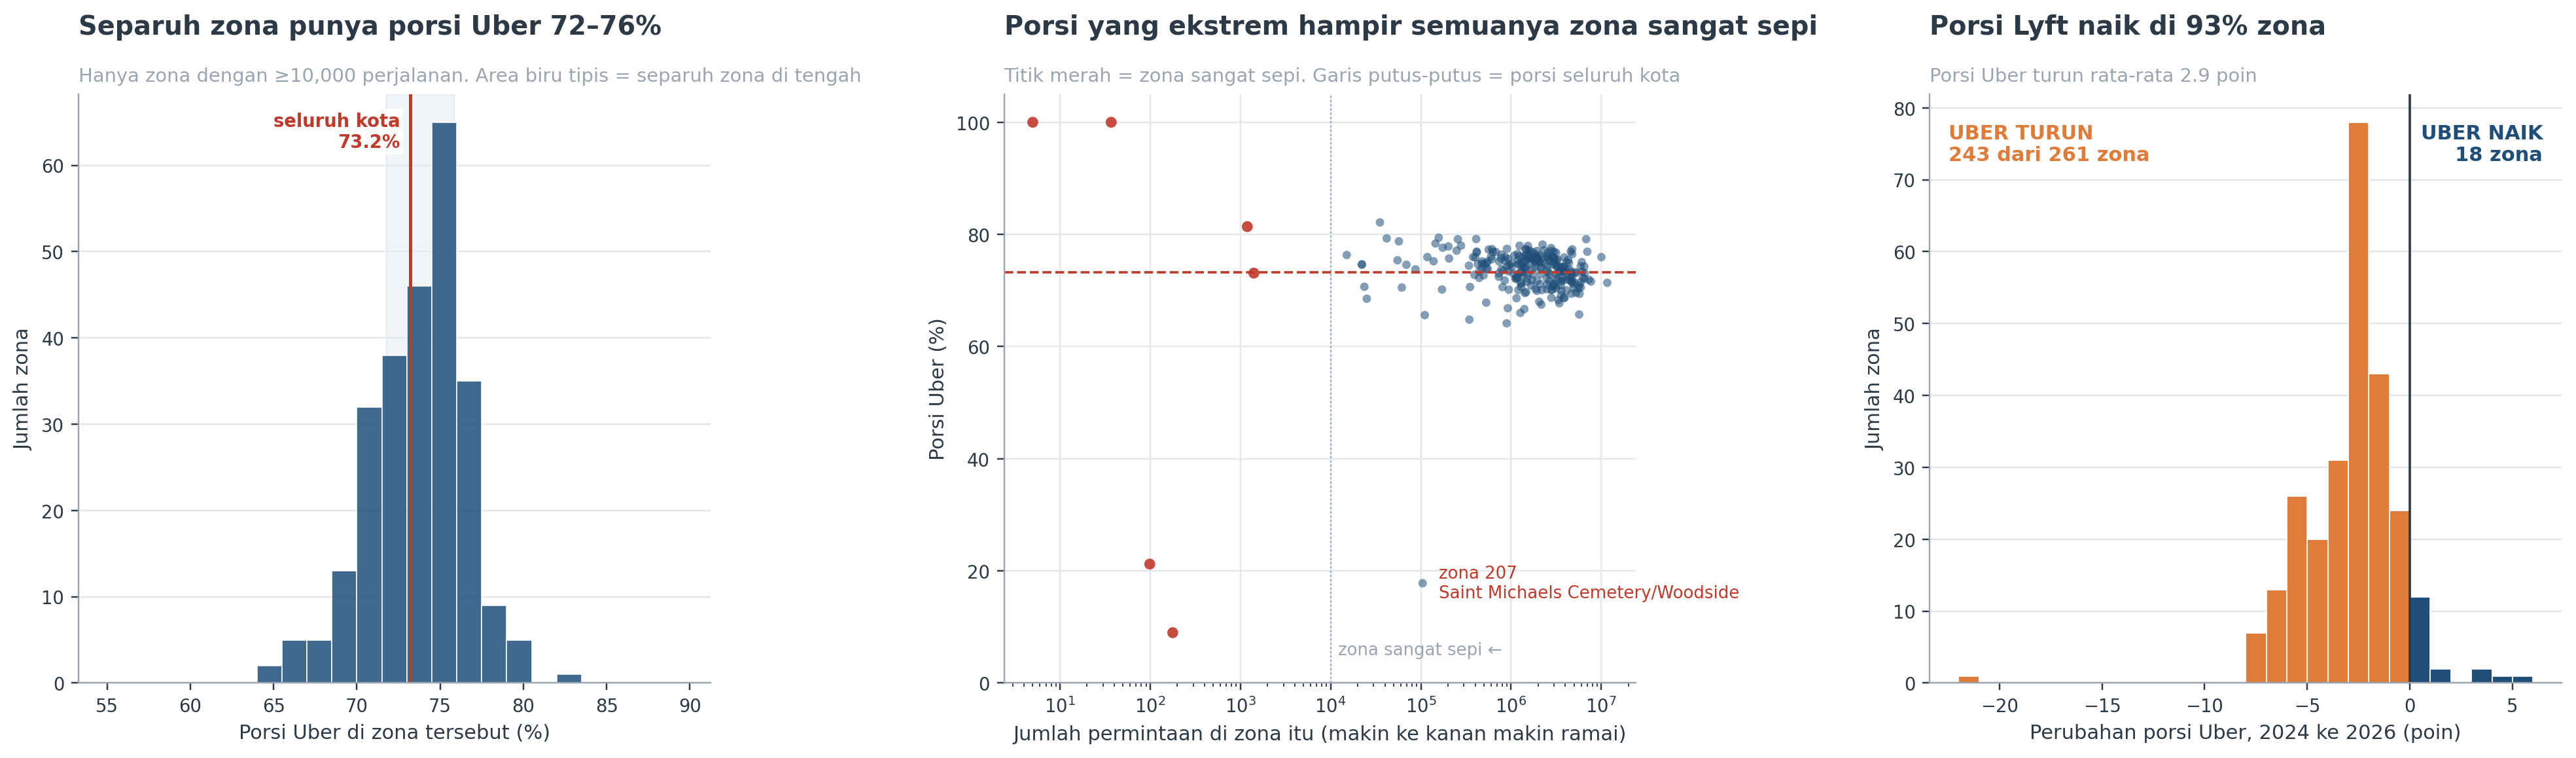

Zona sangat sepi (< 10,000 perjalanan) : 6

Zona cukup ramai dengan porsi Uber menyimpang lebih dari 20 poin:
 pickup_location_id zone_total provider_share_pct                        nama_zona
                207    104,595              17.8% Saint Michaels Cemetery/Woodside


In [97]:
MIN_RAMAI = 10_000   # zona dengan permintaan di bawah ini dianggap sangat sepi

ramai = df_zone_provider[df_zone_provider["zone_total"] >= MIN_RAMAI]
sepi  = df_zone_provider[df_zone_provider["zone_total"] <  MIN_RAMAI]

# Nama zona untuk label
nama = df_zone.set_index("pickup_location_id")["nama_zona"].to_dict()

fig, axes = plt.subplots(1, 3, figsize=(18, 5.4))

# ---------- Kiri: porsi Uber di zona ramai ----------
ax = axes[0]
ax.hist(ramai["provider_share_pct"], bins=np.arange(55, 91, 1.5),
        color=C["primary"], alpha=0.85, edgecolor="white", linewidth=0.6)
q1, q3 = ramai["provider_share_pct"].quantile([0.25, 0.75])
ax.axvspan(q1, q3, color=C["primary"], alpha=0.06, zorder=0)
ax.axvline(porsi_nasional, color=C["alert"], linewidth=1.6)
ax.text(porsi_nasional - 0.6, ax.get_ylim()[1] * 0.97,
        f"seluruh kota\n{porsi_nasional:.1f}%", color=C["alert"],
        fontsize=9, fontweight="semibold", va="top", ha="right",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5))
ax.set_xlabel("Porsi Uber di zona tersebut (%)")
ax.set_ylabel("Jumlah zona")
titled(ax, f"Separuh zona punya porsi Uber {q1:.0f}–{q3:.0f}%",
       f"Hanya zona dengan ≥{MIN_RAMAI:,} perjalanan. Area biru tipis = separuh zona di tengah")
clean_axes(ax)

# ---------- Tengah: porsi terhadap ukuran zona ----------
ax = axes[1]
ax.scatter(ramai["zone_total"], ramai["provider_share_pct"],
           s=18, alpha=0.55, color=C["primary"], edgecolors="none")
ax.scatter(sepi["zone_total"], sepi["provider_share_pct"],
           s=30, alpha=0.9, color=C["alert"], edgecolors="none")
ax.axhline(porsi_nasional, color=C["alert"], linewidth=1.2, linestyle="--")
ax.axvline(MIN_RAMAI, color=C["muted"], linewidth=0.8, linestyle=":")
ax.text(MIN_RAMAI * 1.2, 5, "zona sangat sepi ←", fontsize=8.5,
        color=C["muted"], ha="left")

# Zona cukup ramai yang porsinya sangat menyimpang
aneh = ramai[(ramai["provider_share_pct"] - porsi_nasional).abs() > 20]
for _, r in aneh.iterrows():
    zid = int(r["pickup_location_id"])
    ax.annotate(f"zona {zid}\n{nama.get(zid, '')}",
                xy=(r["zone_total"], r["provider_share_pct"]),
                xytext=(8, 0), textcoords="offset points",
                fontsize=8.5, color=C["alert"], va="center")

ax.set_xscale("log")
ax.set_ylim(0, 105)
ax.set_xlabel("Jumlah permintaan di zona itu (makin ke kanan makin ramai)")
ax.set_ylabel("Porsi Uber (%)")
titled(ax, "Porsi yang ekstrem hampir semuanya zona sangat sepi",
       "Titik merah = zona sangat sepi. Garis putus-putus = porsi seluruh kota")
clean_axes(ax, x_grid=True)

# ---------- Kanan: pergeseran 2024 ke 2026 ----------
ax = axes[2]
bins = np.arange(np.floor(geser.min()), np.ceil(geser.max()) + 1, 1)
n, edges, patches = ax.hist(geser, bins=bins, edgecolor="white", linewidth=0.6)
for p, kiri in zip(patches, edges[:-1]):
    p.set_facecolor(C["secondary"] if kiri < 0 else C["primary"])
ax.axvline(0, color=C["text"], linewidth=1.2)
n_turun = int((geser < 0).sum())
ax.text(0.03, 0.95, f"UBER TURUN\n{n_turun} dari {len(geser)} zona",
        transform=ax.transAxes, fontsize=10, fontweight="bold",
        color=C["secondary"], va="top")
ax.text(0.97, 0.95, f"UBER NAIK\n{len(geser) - n_turun} zona",
        transform=ax.transAxes, fontsize=10, fontweight="bold",
        color=C["primary"], va="top", ha="right")
ax.set_xlabel(f"Perubahan porsi Uber, {tahun[0]} ke {tahun[-1]} (poin)")
ax.set_ylabel("Jumlah zona")
titled(ax, f"Porsi Lyft naik di {n_turun / len(geser) * 100:.0f}% zona",
       f"Porsi Uber turun rata-rata {abs(geser.mean()):.1f} poin")
clean_axes(ax)

plt.tight_layout()
plt.show()

print(f"Zona sangat sepi (< {MIN_RAMAI:,} perjalanan) : {len(sepi)}")
if len(aneh):
    print("\nZona cukup ramai dengan porsi Uber menyimpang lebih dari 20 poin:")
    tampil = aneh[["pickup_location_id", "zone_total", "provider_share_pct"]].copy()
    tampil["nama_zona"] = tampil["pickup_location_id"].map(nama)
    print(tampil.to_string(index=False,
                           formatters={"zone_total": "{:,.0f}".format,
                                       "provider_share_pct": "{:.1f}%".format}))

> **Hasil Step 9 — zona dan provider**

**Temuan 1 — Permintaan hanya sedikit menumpuk**

| Zona teratas | Porsi permintaan |
|---|---|
| 1 zona | 2,0% |
| 10 zona | 12,9% |
| 20 zona | 22,8% |
| 50 zona | 45,2% |
| 100 zona | 71,1% |

Zona paling ramai hanya menampung 2% permintaan kota. Sepuluh zona teratas menampung 12,9%, sekitar 3,4 kali lipat dibanding kondisi sama rata (3,8%). Permintaan memang agak menumpuk, tetapi jauh dari kondisi segelintir zona menguasai semuanya. Untuk menjangkau separuh permintaan dibutuhkan **58 zona**, dan untuk 80% dibutuhkan **126 zona**.

**Temuan 2 — Dua zona tersibuk adalah bandara**

| Peringkat | Zona | Borough | Porsi |
|---|---|---|---|
| 1 | LaGuardia Airport | Queens | 1,98% |
| 2 | JFK Airport | Queens | 1,70% |
| 3 | Crown Heights North | Brooklyn | 1,30% |
| 4 | East Village | Manhattan | 1,24% |
| 5 | Times Sq/Theatre District | Manhattan | 1,19% |

Dua bandara menempati peringkat teratas. Di bawahnya, zona teramai tersebar di Manhattan dan Brooklyn: dari sepuluh zona teratas, lima berada di Manhattan, tiga di Brooklyn, dan dua di Queens. Keramaian tidak terpusat di satu wilayah kota.

**Temuan 3 — Fokus pada zona besar melewatkan sebagian besar permintaan**

Perencanaan yang hanya memperhatikan sepuluh zona teratas akan melewatkan 87% permintaan. Rata-rata kota juga tidak mewakili zona mana pun secara tepat, karena permintaan tersebar di ratusan zona dengan ukuran berbeda.

**Temuan 4 — Pembagian Uber dan Lyft hampir sama di semua zona ramai**

Separuh zona memiliki porsi Uber di rentang sempit, 72% sampai 76%, mengapit porsi seluruh kota 73,2%. Porsi ekstrem seperti 9% atau 100% hanya muncul di 6 zona yang sangat sepi, dengan kurang dari 10.000 perjalanan selama 29 bulan, tempat segelintir perjalanan dapat membuat porsinya melonjak.

Satu pengecualian adalah **zona 207, Saint Michaels Cemetery/Woodside** (Queens), dengan sekitar 105 ribu perjalanan tetapi porsi Uber hanya 17,8%. Zona ini perlu diperiksa tersendiri.

**Temuan 5 — Porsi Lyft naik hampir di semua zona**

Dari 2024 ke 2026, porsi Uber turun di **243 dari 261 zona (93%)**, rata-rata 2,9 poin. Hanya 18 zona yang porsi Ubernya naik, paling tinggi 5,1 poin. Lyft merebut porsi secara merata, bukan di satu dua tempat. Pergeseran ini sejalan dengan kenaikan porsi Lyft di tingkat kota, dari 25,8% menjadi 28,2% (rata-rata Januari–Mei 2024 dan 2026).

**Temuan tambahan — Pergeseran besar terjadi di 48 zona**

Sebanyak 48 dari 261 zona mengalami pergeseran lebih dari 5 poin, dengan pergeseran terbesar mencapai 21,7 poin. Zona-zona ini adalah tempat persaingan provider berubah paling cepat.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H1 — permintaan cukup terkonsentrasi | Mengarah **tidak**: sepuluh zona teratas hanya menampung 12,9%, dan separuh permintaan tersebar di 58 zona |
| H3 — kedua provider bergerak searah | Mengarah **sebagian**: pembagiannya sama di hampir semua zona, tetapi berubah seiring waktu karena porsi Lyft naik di 93% zona |

**Keterbatasan**

Nama zona berasal dari taxi zone lookup TLC. Porsi provider di zona yang sangat sepi tidak dapat dijadikan dasar kesimpulan karena jumlah perjalanannya terlalu kecil. Pergeseran porsi membandingkan seluruh tahun 2024 dengan Januari–Mei 2026, sehingga sedikit tercampur efek musim; arah pergeserannya konsisten dengan perbandingan Januari–Mei di tingkat kota.

**Kaitannya dengan forecasting**

Karena pembagian provider seragam antar zona, satu model dengan penanda provider dapat dipakai untuk semua zona. Namun karena porsi Lyft terus bertambah, model perlu menangkap perubahan rasio provider dari waktu ke waktu, bukan menganggapnya tetap. Untuk cakupan zona, 126 zona sudah mewakili 80% permintaan.

> **Keputusan:** permintaan tersebar, 58 zona untuk separuh permintaan · dua zona tersibuk adalah bandara · pembagian Uber dan Lyft seragam antar zona ramai · porsi Lyft naik di 93% zona · zona 207 (Saint Michaels Cemetery/Woodside) diperiksa tersendiri · satu model dengan penanda provider layak dipakai, asalkan menangkap perubahan rasio dari waktu ke waktu

---

# STEP 10 — Pola Jam per Zona

**Tujuan:** melihat apakah semua zona ramai di jam yang sama, atau setiap jenis zona punya jam ramainya sendiri.

**Kenapa diperlukan:** perbedaan antar bulan, antar hari, dan antar jam masih bisa ditangani dengan tabel rata-rata bertingkat — rata-rata per hari, per jam, per zona. Namun bila setiap zona punya bentuk kurva harian yang berbeda, tidak ada satu kurva rata-rata pun yang dapat mewakili semua zona. Kebutuhan armada lalu ditentukan oleh kombinasi zona dan jam.

**Hipotesis yang diuji:**

| Hipotesis | Pertanyaan |
|---|---|
| H2 — satu pola jam berlaku untuk semua | Apakah bentuk kurva harian sama di semua zona? |
| H4 — rata-rata memadai untuk perencanaan | Apakah kurva rata-rata kota mewakili kurva tiap zona? |

**Cara mengukur:** setiap jam dibagi dengan rata-rata per jam zona itu sendiri.

```
indeks bentuk = permintaan pada jam itu ÷ rata-rata per jam di zona itu
```

Nilai 1,0 berarti jam biasa, 2,0 berarti dua kali lebih ramai dari biasanya. Dengan cara ini zona besar dan zona kecil dapat dibandingkan, karena yang dilihat adalah **bentuk** kurvanya, bukan besarnya.

**Input:** `mart_hourly_demand`, 40 zona teramai.

**Expected output:**
1. Tingkat kemiripan bentuk kurva antar pasangan zona
2. Zona yang bentuknya paling berbeda dan paling mirip dengan rata-rata kota
3. Sebaran jam puncak tiap zona
4. Grafik bentuk kurva dan jam puncak

**Cara interpretasi:**
- Kemiripan diukur dengan korelasi: 1 berarti bentuknya sama persis, 0 tidak berhubungan, negatif berarti berlawanan
- Bila hampir semua pasangan berkorelasi tinggi, satu pola jam cukup untuk seluruh kota
- Bila banyak pasangan berkorelasi rendah atau negatif, dan jam puncaknya tersebar, setiap jenis zona butuh pola jamnya sendiri

In [98]:
TOP_N_ZONES = 40

sql = f"""
WITH zone_rank AS (
    SELECT
        pickup_location_id,
        ROW_NUMBER() OVER (ORDER BY SUM(demand) DESC) AS rk
    FROM {MART_DEMAND}
    GROUP BY pickup_location_id
),
top_zones AS (
    SELECT pickup_location_id FROM zone_rank WHERE rk <= {TOP_N_ZONES}
),
zone_hour AS (
    SELECT d.pickup_location_id, d.hour, SUM(d.demand) AS demand
    FROM {MART_DEMAND} d
    JOIN top_zones t USING (pickup_location_id)
    GROUP BY 1, 2
)
SELECT
    pickup_location_id,
    hour,
    demand,
    demand / AVG(demand) OVER (PARTITION BY pickup_location_id) AS shape_index
FROM zone_hour
ORDER BY pickup_location_id, hour
"""

df_shape = run_query(sql)

shape_matrix = df_shape.pivot(index="hour", columns="pickup_location_id",
                              values="shape_index")
city_shape = shape_matrix.mean(axis=1)

# Nama zona dari taxi zone lookup
nama = df_zone.set_index("pickup_location_id")["nama_zona"].to_dict()

print(f"Zona yang dianalisis : {shape_matrix.shape[1]}")
df_shape.head(10).style.format({"demand": "{:,.0f}", "shape_index": "{:.2f}"})

Rows returned : 960
Bytes billed  : 0.0000 GB
Zona yang dianalisis : 40


,pickup_location_id,hour,demand,shape_index
0,7,0,"211,861",0.90
1,7,1,"165,810",0.70
2,7,2,"131,457",0.56
3,7,3,"125,954",0.53
4,7,4,"136,991",0.58
5,7,5,"150,240",0.64
6,7,6,"205,135",0.87
7,7,7,"272,271",1.15
8,7,8,"291,803",1.23
9,7,9,"260,285",1.10


In [99]:
# ---------- Kemiripan bentuk kurva antar pasangan zona ----------
corr = shape_matrix.corr()
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pasangan = corr.where(mask).stack()

print("KEMIRIPAN BENTUK KURVA ANTAR PASANGAN ZONA")
print(f"  Jumlah pasangan           : {len(pasangan)}")
print(f"  Nilai tengah korelasi     : {pasangan.median():.2f}")
print(f"  Korelasi di bawah 0,5     : {(pasangan < 0.5).sum()} pasangan "
      f"({(pasangan < 0.5).mean() * 100:.1f}%)")
print(f"  Korelasi negatif          : {(pasangan < 0).sum()} pasangan "
      f"({(pasangan < 0).mean() * 100:.1f}%)")

# ---------- Zona paling berbeda dan paling mirip ----------
beda = shape_matrix.apply(lambda col: np.abs(col - city_shape).mean())
peak_hour = shape_matrix.idxmax()

def tabel_zona(seri):
    t = seri.rename("selisih_bentuk").to_frame()
    t["nama_zona"] = [nama.get(z, "—") for z in t.index]
    t["jam_puncak"] = [f"{int(peak_hour[z]):02d}:00" for z in t.index]
    return t[["nama_zona", "jam_puncak", "selisih_bentuk"]].round(3)

print("\nLIMA ZONA DENGAN BENTUK PALING BERBEDA DARI RATA-RATA KOTA")
print(tabel_zona(beda.sort_values(ascending=False).head(5)).to_string())
print("\nLIMA ZONA DENGAN BENTUK PALING MIRIP RATA-RATA KOTA")
print(tabel_zona(beda.sort_values().head(5)).to_string())

KEMIRIPAN BENTUK KURVA ANTAR PASANGAN ZONA
  Jumlah pasangan           : 780
  Nilai tengah korelasi     : 0.83
  Korelasi di bawah 0,5     : 134 pasangan (17.2%)
  Korelasi negatif          : 19 pasangan (2.4%)

LIMA ZONA DENGAN BENTUK PALING BERBEDA DARI RATA-RATA KOTA
                            nama_zona jam_puncak  selisih_bentuk
pickup_location_id                                              
148                   Lower East Side      23:00          0.3760
36                     Bushwick North      23:00          0.3100
79                       East Village      22:00          0.3080
138                 LaGuardia Airport      23:00          0.2950
249                      West Village      22:00          0.2730

LIMA ZONA DENGAN BENTUK PALING MIRIP RATA-RATA KOTA
                              nama_zona jam_puncak  selisih_bentuk
pickup_location_id                                                
61                  Crown Heights North      18:00          0.0460
112                

In [100]:
# ---------- Jam puncak tiap zona ----------
counts = peak_hour.value_counts()
vals = [int(counts.get(h, 0)) for h in range(24)]

KELOMPOK = {"Pagi (06–11)": range(6, 12), "Siang (12–16)": range(12, 17),
            "Sore (17–19)": range(17, 20), "Malam (20–23)": range(20, 24),
            "Dini hari (00–05)": range(0, 6)}

print("JAM PUNCAK TIAP ZONA")
for h, v in enumerate(vals):
    if v > 0:
        print(f"  jam {h:02d} : {v:2d} zona  {'#' * v}")

print("\nDikelompokkan:")
for k, rng in KELOMPOK.items():
    n = sum(vals[h] for h in rng)
    print(f"  {k:18} : {n:2d} zona ({n / len(peak_hour) * 100:.0f}%)")

# Zona wakil: satu dari tiap tiga jam puncak terpopuler
top_hours = sorted(counts.head(3).index.tolist())
reps = []
for h in top_hours:
    zs = peak_hour[peak_hour == h].index
    reps.append((int(h), shape_matrix[zs].max().idxmax()))

print("\nZona wakil tiap kelompok:")
for h, z in reps:
    print(f"  jam {h:02d} : zona {z} — {nama.get(z, '—')}")

JAM PUNCAK TIAP ZONA
  jam 08 :  6 zona  ######
  jam 17 :  2 zona  ##
  jam 18 : 13 zona  #############
  jam 19 :  2 zona  ##
  jam 20 :  4 zona  ####
  jam 21 :  2 zona  ##
  jam 22 :  6 zona  ######
  jam 23 :  5 zona  #####

Dikelompokkan:
  Pagi (06–11)       :  6 zona (15%)
  Siang (12–16)      :  0 zona (0%)
  Sore (17–19)       : 17 zona (42%)
  Malam (20–23)      : 17 zona (42%)
  Dini hari (00–05)  :  0 zona (0%)

Zona wakil tiap kelompok:
  jam 08 : zona 39 — Canarsie
  jam 18 : zona 246 — West Chelsea/Hudson Yards
  jam 22 : zona 249 — West Village


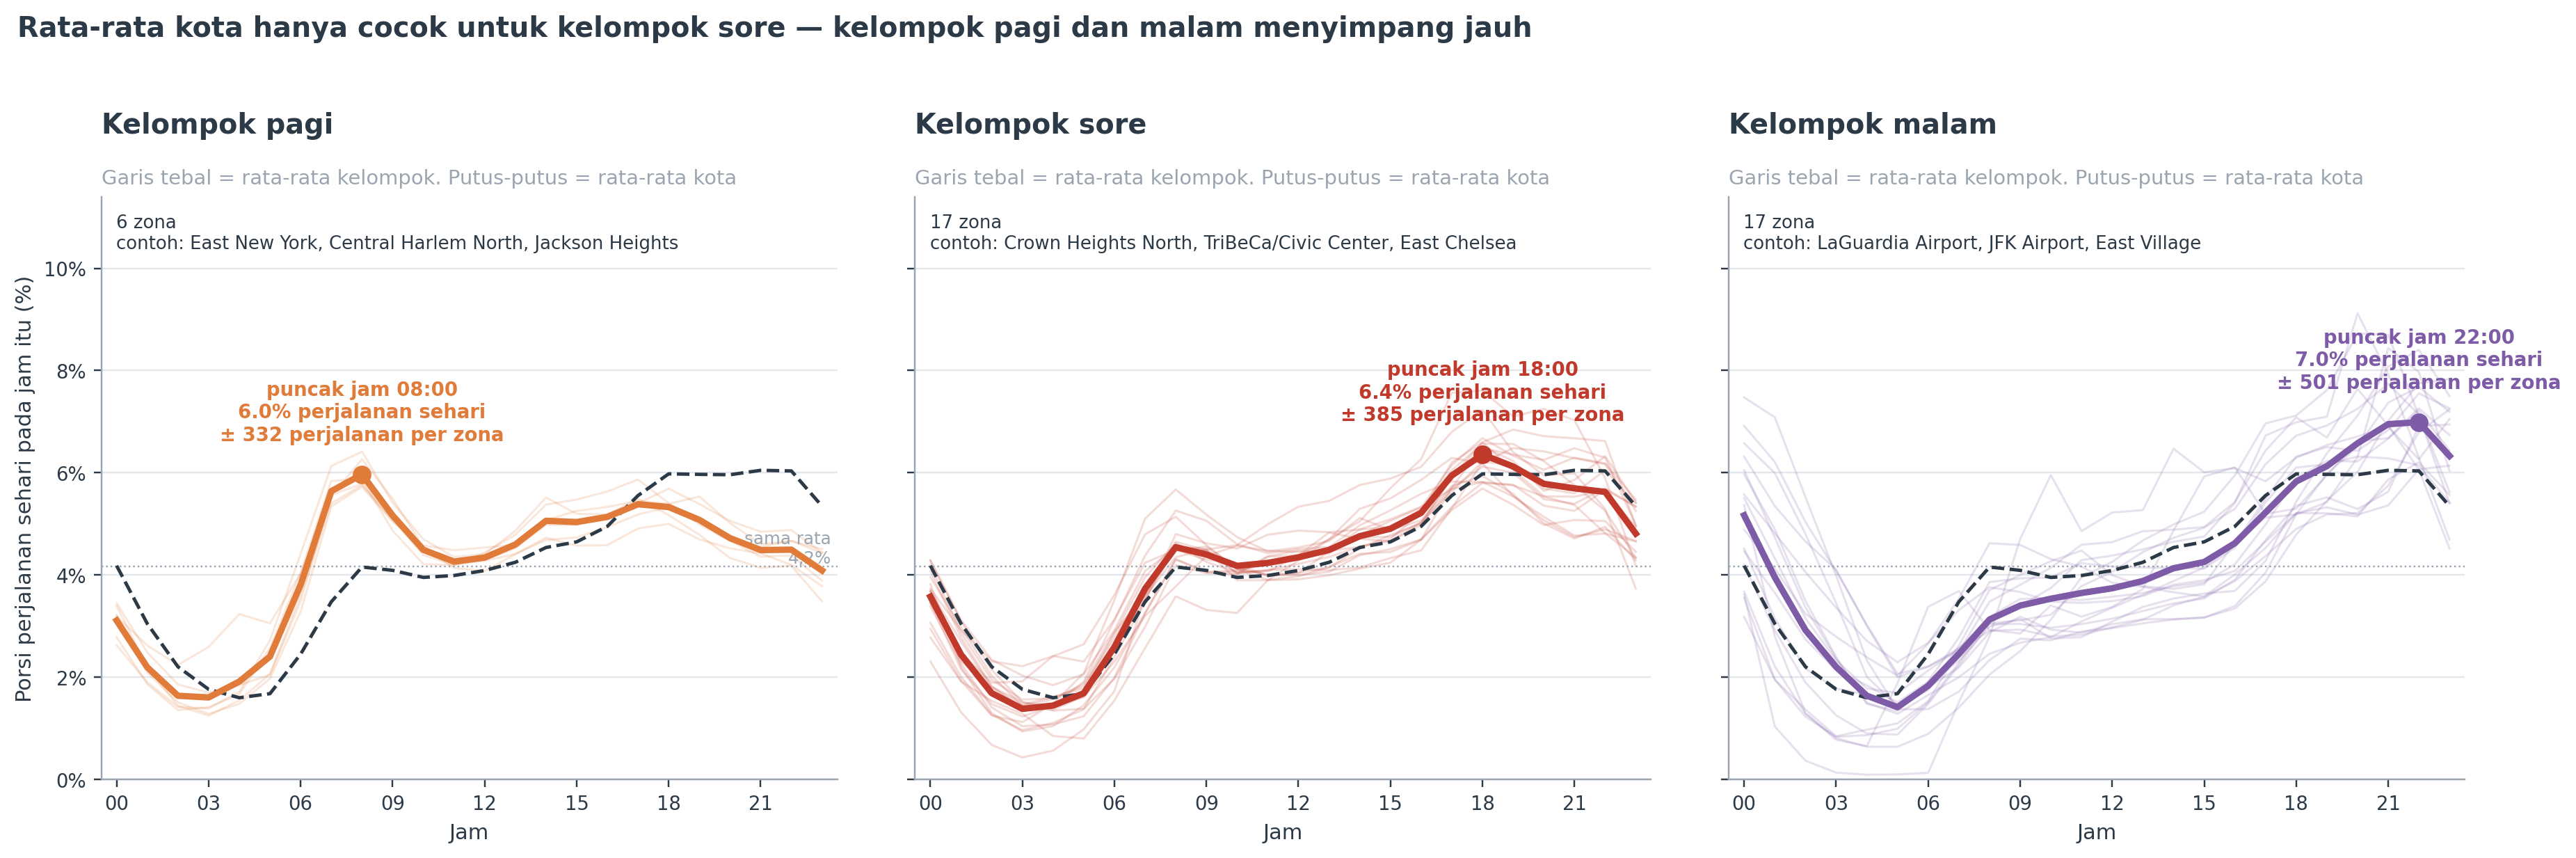

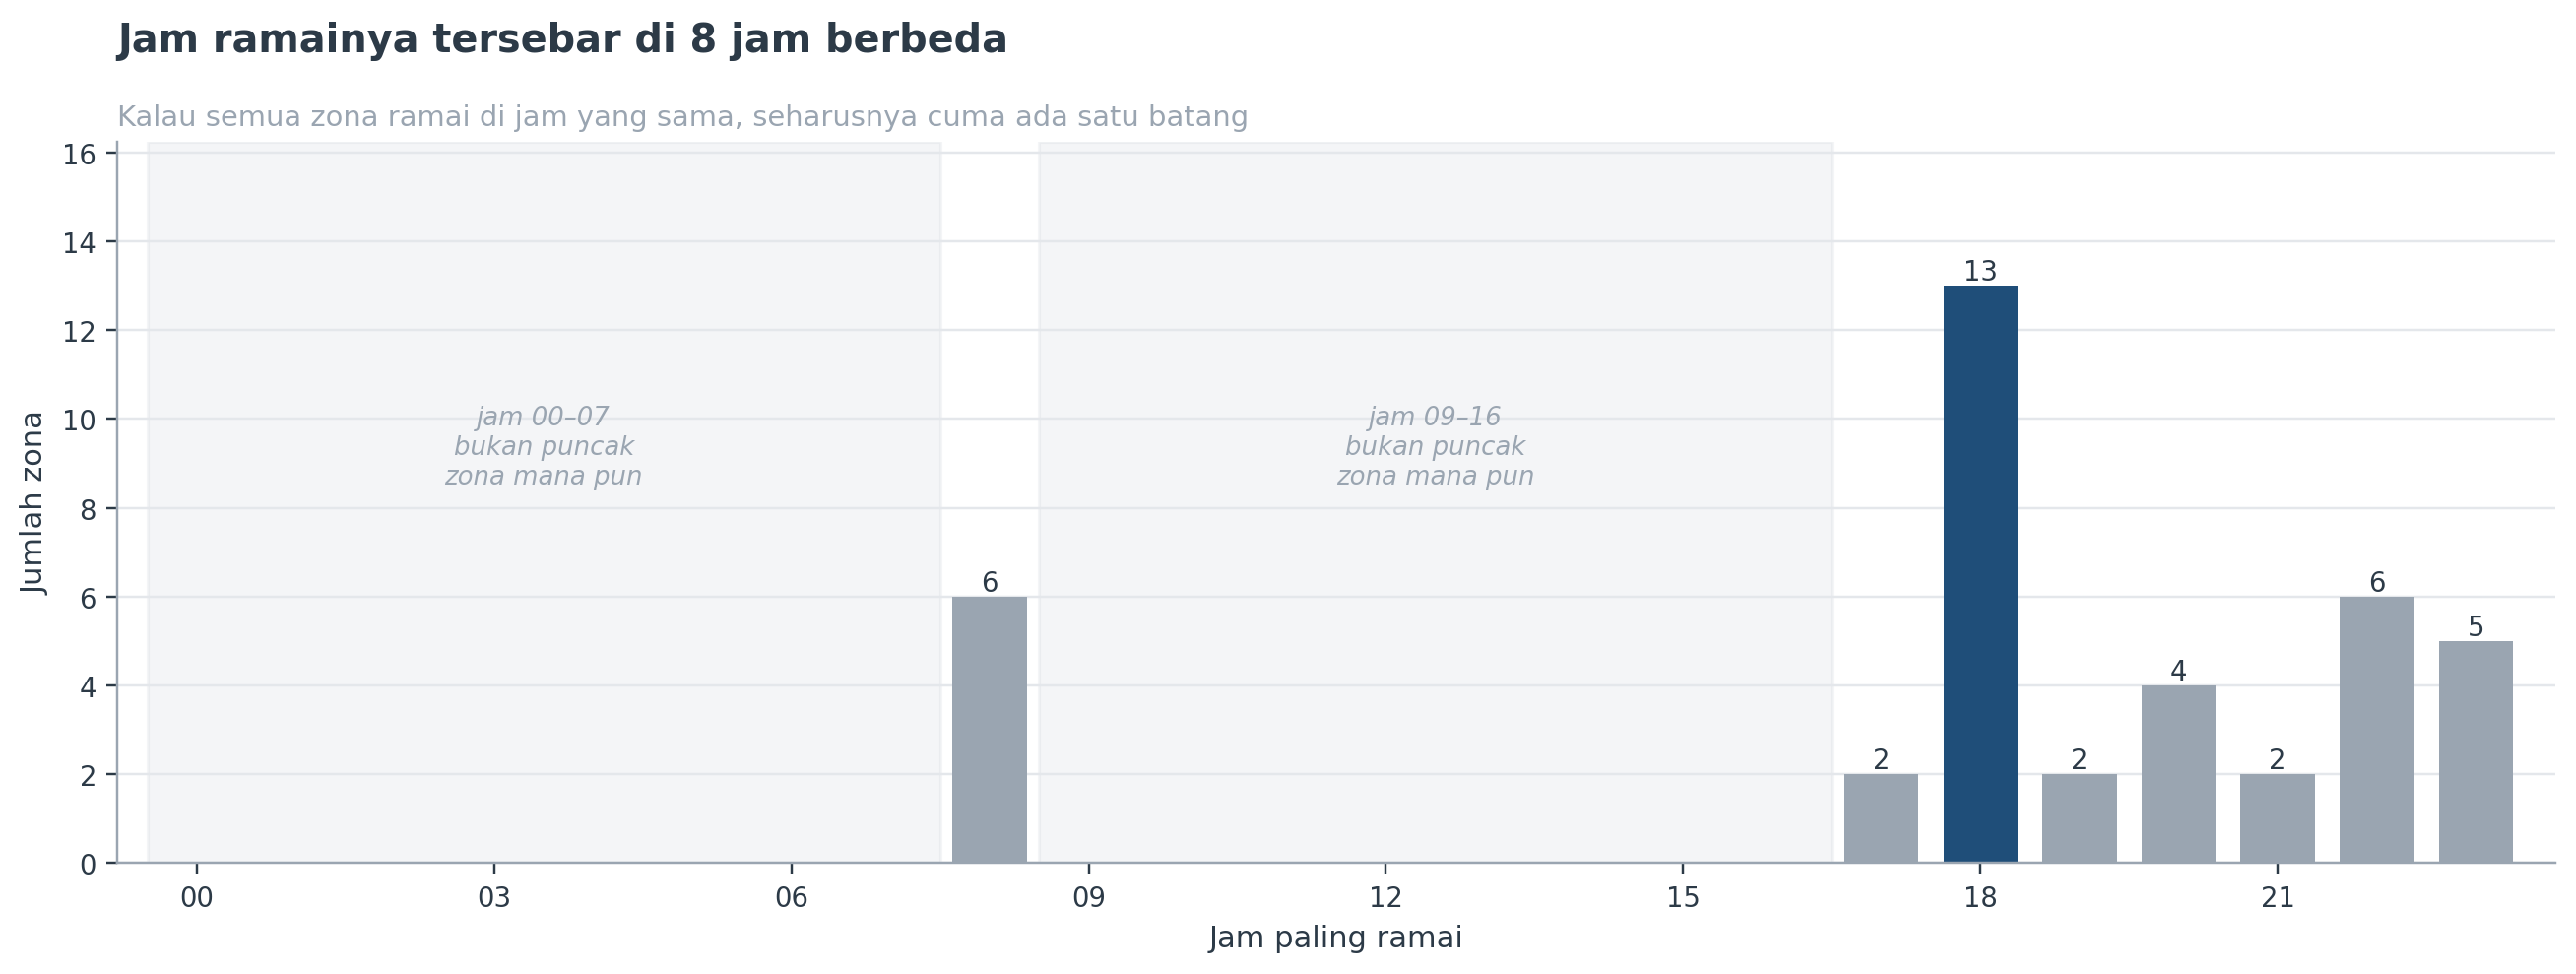

,jumlah_zona,jam_puncak,porsi_jam_puncak,perjalanan_per_zona_di_puncak
kelompok,,,,
Pagi,6,08:00,6.0%,332
Sore,17,18:00,6.4%,385
Malam,17,22:00,7.0%,501
Rata-rata kota,40,21:00,6.0%,397


In [101]:
# Jumlah hari dalam periode data
N_HARI = int(df_monthly["n_days"].sum())

# Perjalanan per jam dalam satu hari, tiap zona
per_jam = df_shape.pivot(index="hour", columns="pickup_location_id",
                         values="demand") / N_HARI

# Porsi perjalanan harian yang terjadi pada tiap jam (%)
porsi = per_jam / per_jam.sum() * 100
porsi_kota = porsi.mean(axis=1)
MERATA = 100 / 24

# Kelompokkan zona berdasarkan jam puncaknya
peak_hour = porsi.idxmax()
KELOMPOK = {
    "Pagi":  {"jam": range(6, 12),  "warna": C["secondary"]},
    "Sore":  {"jam": range(17, 20), "warna": C["alert"]},
    "Malam": {"jam": range(20, 24), "warna": "#7D5BA6"},
}
anggota = {k: [z for z in porsi.columns if peak_hour[z] in v["jam"]]
           for k, v in KELOMPOK.items()}

# ================= Grafik 1: tiga kelompok =================
fig, axes = plt.subplots(1, 3, figsize=(17, 5.4), sharey=True)
y_top = porsi.values.max() * 1.25

for ax, (k, info) in zip(axes, KELOMPOK.items()):
    zs, colr = anggota[k], info["warna"]
    if not zs:
        ax.set_visible(False)
        continue

    for z in zs:
        ax.plot(porsi.index, porsi[z], color=colr, alpha=0.18, linewidth=1)

    rata_k = porsi[zs].mean(axis=1)
    ax.plot(porsi.index, rata_k, color=colr, linewidth=3, zorder=5)
    ax.plot(porsi_kota.index, porsi_kota.values, color=C["text"],
            linewidth=1.6, linestyle="--", zorder=4)
    ax.axhline(MERATA, color=C["muted"], linewidth=0.8, linestyle=":")

    # Puncak rata-rata kelompok
    hp = int(rata_k.idxmax())
    n_puncak = per_jam[zs].mean(axis=1)[hp]
    ax.scatter([hp], [rata_k[hp]], s=60, color=colr, zorder=6)
    ax.annotate(f"puncak jam {hp:02d}:00\n{rata_k[hp]:.1f}% perjalanan sehari\n"
                f"± {n_puncak:,.0f} perjalanan per zona",
                xy=(hp, rata_k[hp]), xytext=(0, 14), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, color=colr, fontweight="semibold")

    # Contoh zona
    contoh = ", ".join(nama.get(z, str(z)) for z in
                       sorted(zs, key=lambda z: -per_jam[z].sum())[:3])
    ax.text(0.02, 0.97, f"{len(zs)} zona\ncontoh: {contoh}",
            transform=ax.transAxes, fontsize=8.5, color=C["text"], va="top")

    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f"{h:02d}" for h in range(0, 24, 3)])
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(0, y_top)
    ax.set_xlabel("Jam")
    titled(ax, f"Kelompok {k.lower()}",
           "Garis tebal = rata-rata kelompok. Putus-putus = rata-rata kota")
    clean_axes(ax)

axes[0].set_ylabel("Porsi perjalanan sehari pada jam itu (%)")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:.0f}%"))
axes[0].text(23.3, MERATA, "sama rata\n4,2%", fontsize=8, color=C["muted"],
             ha="right", va="bottom")

fig.suptitle("Rata-rata kota hanya cocok untuk kelompok sore — "
             "kelompok pagi dan malam menyimpang jauh",
             x=0.01, ha="left", fontsize=13, fontweight="semibold",
             color=C["text"], y=1.03)
plt.tight_layout()
plt.show()

# ================= Grafik 2: jam puncak =================
counts = peak_hour.value_counts()
vals = [int(counts.get(h, 0)) for h in range(24)]
top = max(vals)

fig, ax = plt.subplots(figsize=(12, 4.6))
warna = [C["primary"] if v == top else (C["muted"] if v > 0 else "none") for v in vals]
ax.bar(range(24), vals, color=warna, width=0.75)
for h, v in enumerate(vals):
    if v > 0:
        ax.text(h, v, str(v), ha="center", va="bottom", fontsize=9, color=C["text"])

kosong = [h for h in range(24) if vals[h] == 0]
runs, cur = [], [kosong[0]] if kosong else []
for h in kosong[1:]:
    if h == cur[-1] + 1:
        cur.append(h)
    else:
        runs.append(cur); cur = [h]
if cur:
    runs.append(cur)
for r in runs:
    if len(r) >= 3:
        ax.axvspan(r[0] - 0.5, r[-1] + 0.5, color=C["muted"], alpha=0.10, zorder=0)
        ax.text((r[0] + r[-1]) / 2, top * 0.72,
                f"jam {r[0]:02d}–{r[-1]:02d}\nbukan puncak\nzona mana pun",
                ha="center", va="center", fontsize=8.5, color=C["muted"], style="italic")

ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels([f"{h:02d}" for h in range(0, 24, 3)])
ax.set_xlim(-0.8, 23.8)
ax.set_ylim(0, top * 1.25)
ax.set_xlabel("Jam paling ramai")
ax.set_ylabel("Jumlah zona")
titled(ax, f"Jam ramainya tersebar di {sum(v > 0 for v in vals)} jam berbeda",
       "Kalau semua zona ramai di jam yang sama, seharusnya cuma ada satu batang")
clean_axes(ax)
plt.tight_layout()
plt.show()

# ================= Ringkasan =================
baris = []
for k, zs in anggota.items():
    if not zs:
        continue
    rata_k = porsi[zs].mean(axis=1)
    hp = int(rata_k.idxmax())
    baris.append({"kelompok": k, "jumlah_zona": len(zs), "jam_puncak": f"{hp:02d}:00",
                  "porsi_jam_puncak": rata_k[hp],
                  "perjalanan_per_zona_di_puncak": per_jam[zs].mean(axis=1)[hp]})
hk = int(porsi_kota.idxmax())
baris.append({"kelompok": "Rata-rata kota", "jumlah_zona": porsi.shape[1],
              "jam_puncak": f"{hk:02d}:00", "porsi_jam_puncak": porsi_kota[hk],
              "perjalanan_per_zona_di_puncak": per_jam.mean(axis=1)[hk]})

pd.DataFrame(baris).set_index("kelompok").style.format({
    "porsi_jam_puncak": "{:.1f}%", "perjalanan_per_zona_di_puncak": "{:,.0f}"})

> **Cara membaca grafik**

**Grafik tiga kelompok** — 40 zona teramai dibagi berdasarkan jam paling ramainya: pagi, sore, atau malam. Sumbu kiri menunjukkan berapa persen perjalanan dalam sehari yang terjadi pada jam itu. Bila perjalanan tersebar sama rata sepanjang hari, setiap jam menampung sekitar 4,2% — itu garis titik-titik tipis.

Di setiap panel ada tiga jenis garis:
- Garis tipis berwarna adalah zona-zona anggota kelompok
- Garis tebal berwarna adalah rata-rata kelompok itu
- Garis putus-putus hitam adalah rata-rata seluruh kota, sama di ketiga panel

Bandingkan garis tebal dengan garis putus-putus. Di panel sore, keduanya hampir berimpit — rata-rata kota cocok untuk kelompok ini. Di panel pagi, garis tebal naik jauh lebih tinggi di jam 06:00–09:00. Di panel malam, garis tebal naik jauh lebih tinggi di jam 20:00–23:00. Semakin jauh garis tebal dari garis putus-putus, semakin salah rata-rata kota bila dipakai untuk kelompok itu.

Label di titik puncak menunjukkan jam puncak, porsi perjalanan sehari pada jam itu, dan perkiraan jumlah perjalanan per zona.

**Grafik jam puncak** — setiap batang adalah jumlah zona yang paling ramai pada jam tersebut. Batang biru adalah jam puncak yang paling umum. Area abu-abu tipis adalah rentang jam yang tidak pernah menjadi puncak di zona mana pun.

**Tabel ringkasan** — merangkum angka dari grafik tiga kelompok: jumlah zona, jam puncak, porsi perjalanan sehari pada jam itu, dan rata-rata jumlah perjalanan per zona pada jam puncak.

> **Hasil Step 10 — pola jam per zona**

Analisis dilakukan pada 40 zona teramai, sehingga ada 780 pasangan zona yang dibandingkan.

**Temuan 1 — Sebagian besar zona mirip, tetapi sebagian lainnya berlawanan**

| Ukuran | Nilai |
|---|---|
| Nilai tengah korelasi | 0,83 |
| Pasangan dengan korelasi di bawah 0,5 | 134 dari 780 (17,2%) |
| Pasangan dengan korelasi negatif | 19 (2,4%) |

Sebagian besar zona punya bentuk kurva yang mirip, karena hampir semua zona sama-sama sepi di dini hari dan ramai di sore hari. Namun 17% pasangan tidak mirip, dan 19 pasangan bahkan berlawanan: ketika satu zona sedang ramai, zona pasangannya justru sepi.

**Temuan 2 — Zona hiburan malam dan bandara paling berbeda**

| Zona | Nama | Jam puncak |
|---|---|---|
| 148 | Lower East Side | 23:00 |
| 36 | Bushwick North | 23:00 |
| 79 | East Village | 22:00 |
| 138 | LaGuardia Airport | 23:00 |
| 249 | West Village | 22:00 |

Kelima zona yang bentuknya paling berbeda dari rata-rata kota semuanya memuncak larut malam, jam 22:00–23:00. Empat di antaranya dikenal sebagai kawasan hiburan malam, dan satu adalah bandara. Sebaliknya, zona yang paling mirip rata-rata kota — Crown Heights North, Greenpoint, Gramercy, Bedford, dan Stuyvesant Heights — memuncak jam 18:00–19:00.

**Temuan 3 — Ada tiga kelompok jam puncak**

| Kelompok | Jumlah zona | Jam puncak | Porsi perjalanan sehari di jam puncak | Perjalanan per zona di jam puncak |
|---|---|---|---|---|
| Pagi | 6 (15%) | 08:00 | 6,0% | 332 |
| Sore | 17 (42%) | 18:00 | 6,4% | 385 |
| Malam | 17 (42%) | 22:00 | 7,0% | 501 |
| Rata-rata kota | 40 | 21:00 | 6,0% | 397 |

Kelompok pagi berisi kawasan permukiman seperti East New York, Central Harlem North, dan Jackson Heights. Kelompok malam berisi bandara dan kawasan hiburan malam seperti LaGuardia, JFK, dan East Village. Tidak ada satu pun zona yang memuncak di siang hari (jam 09–16) maupun dini hari (jam 00–07).

Bila perjalanan tersebar sama rata sepanjang hari, setiap jam menampung 4,2%. Jam puncak kelompok malam menampung 7,0%, atau sekitar 1,7 kali lipat jam biasa — paling tajam di antara ketiga kelompok.

**Temuan 4 — Rata-rata kota hanya cocok untuk kelompok sore**

Kurva kelompok sore hampir berimpit dengan kurva rata-rata kota, karena kelompok ini menyumbang 17 dari 40 zona. Namun kelompok pagi dan malam menyimpang jauh:

- Kelompok pagi jauh lebih ramai dari rata-rata kota pada jam 06:00–09:00, lalu lebih sepi pada malam hari
- Kelompok malam lebih sepi dari rata-rata kota pada pagi hari, lalu jauh lebih ramai pada jam 20:00–23:00 dan dini hari

Rata-rata kota karena itu cocok untuk sekitar 42% zona, tetapi salah untuk 58% sisanya.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H2 — satu pola jam berlaku untuk semua | Mengarah **tidak berlaku**: ada tiga kelompok jam puncak, dan 17% pasangan zona tidak mirip |
| H4 — rata-rata memadai untuk perencanaan | Mengarah **tidak memadai**: kurva rata-rata kota hanya cocok untuk kelompok sore, dan salah untuk kelompok pagi dan malam yang mencakup 58% zona |

**Keterbatasan**

Analisis hanya mencakup 40 zona teramai. Zona yang lebih sepi dapat memiliki pola berbeda yang belum terlihat. Pengelompokan zona sebagai kawasan permukiman, hiburan malam, atau bandara didasarkan pada nama zona, bukan pada data penggunaan lahan.

**Kaitannya dengan forecasting**

Karena bentuk kurva berbeda antar kelompok zona, model tidak cukup hanya mengenali jam dan zona secara terpisah. Model perlu mengenali kombinasi keduanya — misalnya melalui penanda kelompok zona (pagi, sore, malam) atau interaksi antara jam dan zona.

**Kaitan dengan argumen utama**

Ini lapis terdalam. Variasi antar bulan, antar hari, dan antar jam masih bisa ditangani dengan tabel rata-rata bertingkat. Variasi antar zona dalam bentuk kurva tidak bisa: satu kurva rata-rata kota hanya mewakili sebagian zona dan salah untuk sisanya.

> **Keputusan:** tiga kelompok jam puncak — pagi 15%, sore 42%, malam 42% · rata-rata kota hanya cocok untuk kelompok sore, salah untuk 58% zona · kelompok malam paling tajam, 7,0% perjalanan sehari di jam 22:00 · model perlu mengenali kombinasi zona dan jam

---

# STEP 11 — Tujuan Perjalanan dan Keseimbangan Zona

**Tujuan:** melihat ke mana orang bepergian, dan zona mana yang lebih banyak mengirim atau menerima penumpang.

**Kenapa diperlukan:** setiap perjalanan memindahkan mobil dari zona asal ke zona tujuan. Zona yang lebih banyak menerima penumpang akan mengumpulkan mobil kosong, sedangkan zona yang lebih banyak mengirim akan kekurangan mobil bila tidak ada yang datang. Ketidakseimbangan ini tidak terlihat bila hanya melihat jumlah pickup.

**Hipotesis yang diuji:**

| Hipotesis | Pertanyaan |
|---|---|
| Asal dan tujuan seimbang di tiap zona | Apakah jumlah orang yang naik dan turun di setiap zona kurang lebih sama? |
| H1 — permintaan cukup terkonsentrasi | Apakah tujuan perjalanan menumpuk di sedikit zona? |

**Zona penampung:** zona 264 dan 265 pada taxi zone lookup TLC adalah penampung untuk tujuan yang tidak diketahui atau berada di luar NYC. Keduanya dikeluarkan dari peringkat dan dilaporkan terpisah.

**Koreksi rasio:** jumlah pickup dihitung dari seluruh perjalanan, sedangkan dropoff hanya dari perjalanan yang tujuannya diketahui. Agar sebanding, rasio pickup terhadap dropoff dikoreksi dengan perbandingan kedua total tersebut.

```
rasio terkoreksi = (pickup ÷ dropoff) ÷ (total pickup ÷ total dropoff diketahui)
```

**Input:** `mart_destination_metrics` dan `mart_hourly_demand`. Data tujuan hanya tersedia per hari, tidak per jam.

**Expected output:**
1. Porsi tujuan yang tidak diketahui
2. Peringkat zona tujuan beserta namanya
3. Keseimbangan pickup dan dropoff per zona
4. Grafik tujuan teratas dan zona pengirim/penerima

**Cara interpretasi:**
- Rasio terkoreksi 1,0 berarti zona seimbang
- Di atas 1,0 berarti zona pengirim: lebih banyak orang naik daripada turun
- Di bawah 1,0 berarti zona penerima: lebih banyak orang turun daripada naik

In [102]:
UNKNOWN_ZONES = (264, 265)

sql = f"""
SELECT
    SUM(CASE WHEN dropoff_location_id IN {UNKNOWN_ZONES}
             THEN total_dropoffs ELSE 0 END)                       AS unknown_dropoffs,
    SUM(total_dropoffs)                                            AS total_dropoffs,
    SAFE_DIVIDE(SUM(CASE WHEN dropoff_location_id IN {UNKNOWN_ZONES}
                         THEN total_dropoffs ELSE 0 END),
                SUM(total_dropoffs)) * 100                         AS unknown_pct
FROM {MART_DESTINATION}
"""

df_unknown = run_query(sql)

print("Identitas zona penampung menurut taxi zone lookup TLC:")
print(lookup[lookup["LocationID"].isin(UNKNOWN_ZONES)]
      [["LocationID", "Borough", "Zone", "service_zone"]].to_string(index=False))
print()

df_unknown.T.style.format({0: "{:,.2f}"})

Rows returned : 1
Bytes billed  : 0.0000 GB
Identitas zona penampung menurut taxi zone lookup TLC:
 LocationID Borough           Zone service_zone
        264 Unknown            NaN          NaN
        265     NaN Outside of NYC          NaN



,0
unknown_dropoffs,"25,652,136.00"
total_dropoffs,"589,055,372.00"
unknown_pct,4.35


In [103]:
sql = f"""
WITH agg AS (
    SELECT dropoff_location_id, SUM(total_dropoffs) AS total_dropoffs
    FROM {MART_DESTINATION}
    WHERE dropoff_location_id NOT IN {UNKNOWN_ZONES}
    GROUP BY dropoff_location_id
)
SELECT
    ROW_NUMBER() OVER (ORDER BY total_dropoffs DESC)                AS zone_rank,
    dropoff_location_id,
    total_dropoffs,
    total_dropoffs / SUM(total_dropoffs) OVER () * 100              AS share_pct,
    SUM(total_dropoffs) OVER (ORDER BY total_dropoffs DESC)
        / SUM(total_dropoffs) OVER () * 100                         AS cum_share_pct
FROM agg
ORDER BY zone_rank
"""

df_dest = run_query(sql)
df_dest["nama_zona"] = df_dest["dropoff_location_id"].map(nama)
df_dest["borough"] = df_dest["dropoff_location_id"].map(
    lookup.set_index("LocationID")["Borough"])

top10_dest = df_dest.loc[df_dest["zone_rank"] == 10, "cum_share_pct"].values[0]
print(f"Zona tujuan diketahui : {len(df_dest)}")
print(f"Sepuluh tujuan teratas menampung {top10_dest:.1f}% perjalanan "
      f"yang tujuannya diketahui\n")

df_dest.head(15)[["zone_rank", "dropoff_location_id", "nama_zona", "borough",
                  "total_dropoffs", "share_pct", "cum_share_pct"]] \
    .set_index("zone_rank").style.format({
        "total_dropoffs": "{:,.0f}", "share_pct": "{:.2f}%", "cum_share_pct": "{:.1f}%"})

Rows returned : 262
Bytes billed  : 0.0000 GB
Zona tujuan diketahui : 262
Sepuluh tujuan teratas menampung 13.5% perjalanan yang tujuannya diketahui



,dropoff_location_id,nama_zona,borough,total_dropoffs,share_pct,cum_share_pct
zone_rank,,,,,,
1,138,LaGuardia Airport,Queens,"12,636,515",2.24%,2.2%
2,132,JFK Airport,Queens,"12,253,030",2.17%,4.4%
3,61,Crown Heights North,Brooklyn,"8,089,690",1.44%,5.9%
4,37,Bushwick South,Brooklyn,"6,551,507",1.16%,7.0%
5,76,East New York,Brooklyn,"6,522,187",1.16%,8.2%
6,68,East Chelsea,Manhattan,"6,083,156",1.08%,9.3%
7,161,Midtown Center,Manhattan,"5,988,716",1.06%,10.3%
8,79,East Village,Manhattan,"5,957,576",1.06%,11.4%
9,230,Times Sq/Theatre District,Manhattan,"5,927,215",1.05%,12.4%


In [104]:
sql = f"""
WITH pu AS (
    SELECT pickup_location_id AS zone_id, SUM(demand) AS pickups
    FROM {MART_DEMAND}
    GROUP BY 1
),
do AS (
    SELECT dropoff_location_id AS zone_id, SUM(total_dropoffs) AS dropoffs
    FROM {MART_DESTINATION}
    WHERE dropoff_location_id NOT IN {UNKNOWN_ZONES}
    GROUP BY 1
)
SELECT zone_id, pickups, dropoffs
FROM pu
JOIN do USING (zone_id)
"""

df_balance = run_query(sql)

# Koreksi: pickup mencakup semua perjalanan, dropoff hanya yang tujuannya diketahui
faktor = df_balance["pickups"].sum() / df_balance["dropoffs"].sum()
df_balance["rasio_mentah"] = df_balance["pickups"] / df_balance["dropoffs"]
df_balance["rasio"] = df_balance["rasio_mentah"] / faktor
df_balance["selisih_pct"] = (df_balance["rasio"] - 1) * 100
df_balance["nama_zona"] = df_balance["zone_id"].map(nama)

# Hanya zona yang cukup ramai, supaya rasio tidak melonjak karena angka kecil
MIN_TRIP = 1_000_000
df_bal_ramai = (df_balance[df_balance["pickups"] >= MIN_TRIP]
                .sort_values("selisih_pct", ascending=False)
                .reset_index(drop=True))

print(f"Faktor koreksi : {faktor:.4f}")
print(f"Zona dengan sedikitnya {MIN_TRIP:,} pickup : {len(df_bal_ramai)}\n")

tampil = pd.concat([df_bal_ramai.head(10), df_bal_ramai.tail(10)])
tampil[["zone_id", "nama_zona", "pickups", "dropoffs", "rasio", "selisih_pct"]] \
    .set_index("zone_id").style.format({
        "pickups": "{:,.0f}", "dropoffs": "{:,.0f}",
        "rasio": "{:.2f}", "selisih_pct": "{:+.1f}%"})

Rows returned : 261
Bytes billed  : 0.0000 GB
Faktor koreksi : 1.0455
Zona dengan sedikitnya 1,000,000 pickup : 185



,nama_zona,pickups,dropoffs,rasio,selisih_pct
zone_id,,,,,
203,Rosedale,"1,164,698","848,169",1.31,+31.3%
143,Lincoln Square West,"2,855,465","2,187,677",1.25,+24.8%
148,Lower East Side,"5,903,958","4,525,611",1.25,+24.8%
259,Woodlawn/Wakefield,"2,022,245","1,567,212",1.23,+23.4%
229,Sutton Place/Turtle Bay North,"3,314,980","2,596,832",1.22,+22.1%
48,Clinton East,"5,560,624","4,454,628",1.19,+19.4%
218,Springfield Gardens North,"1,279,164","1,025,578",1.19,+19.3%
191,Queens Village,"1,760,625","1,414,319",1.19,+19.1%
219,Springfield Gardens South,"1,123,789","907,474",1.18,+18.4%


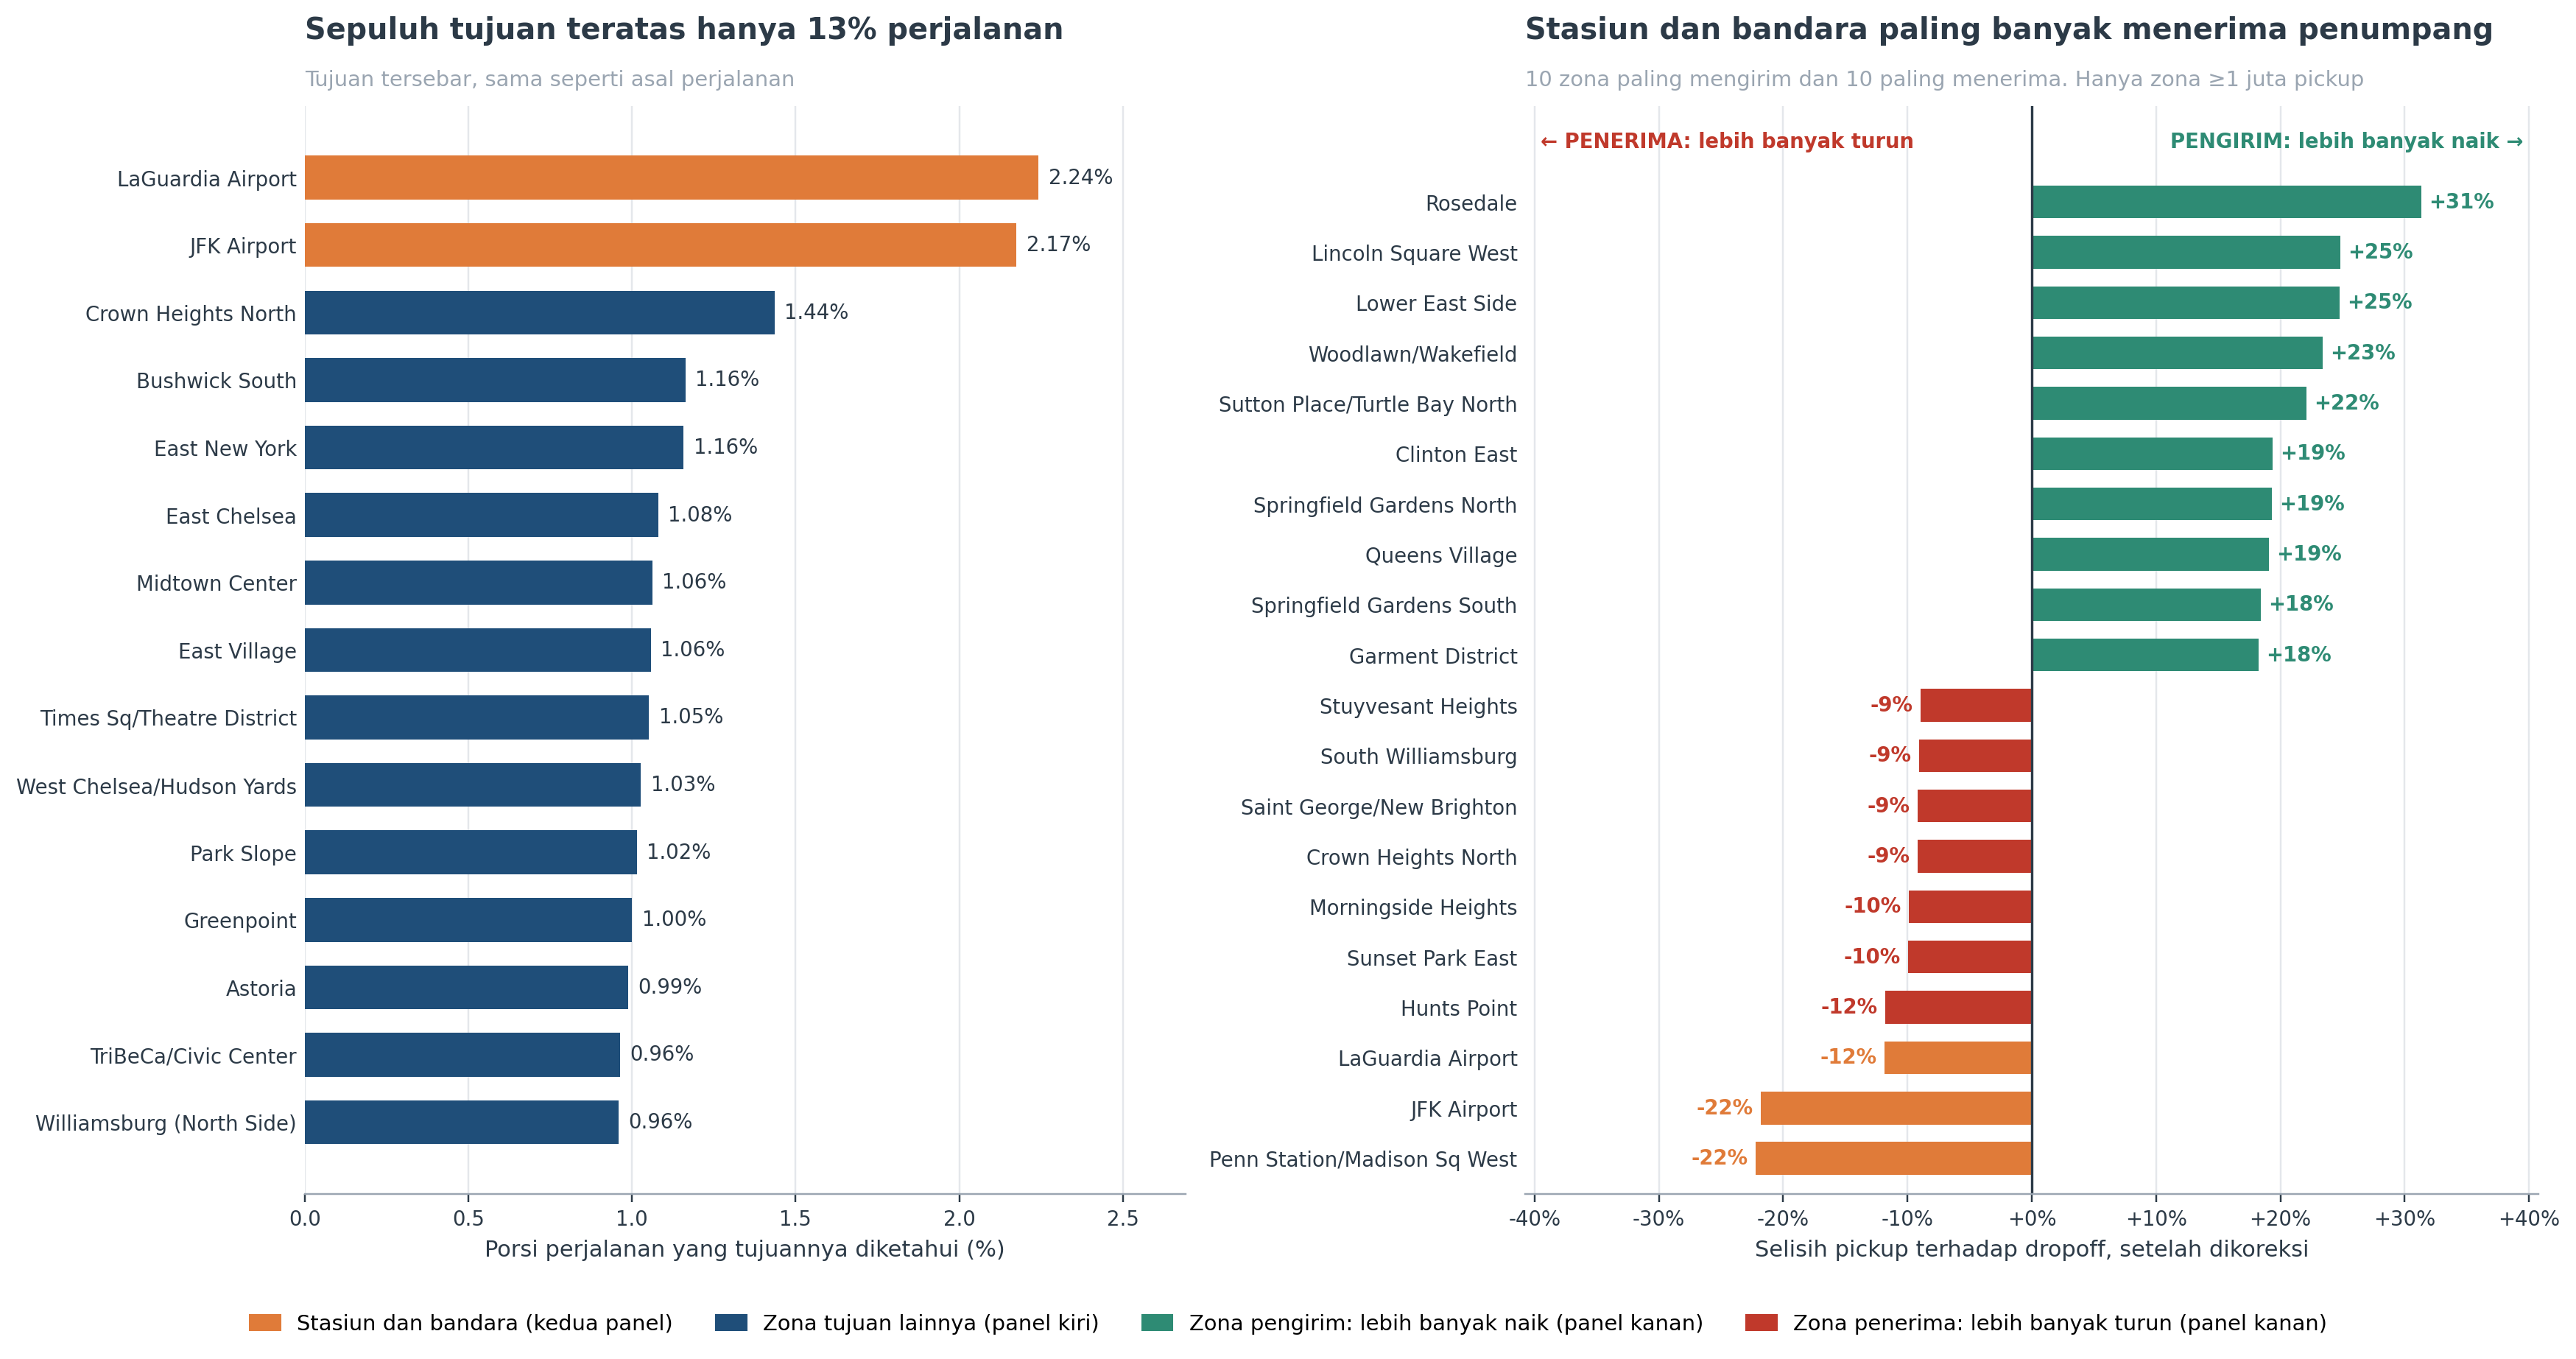

Sepuluh zona paling mengirim:
                    nama_zona selisih_pct
                     Rosedale      +31.3%
          Lincoln Square West      +24.8%
              Lower East Side      +24.8%
           Woodlawn/Wakefield      +23.4%
Sutton Place/Turtle Bay North      +22.1%
                 Clinton East      +19.4%
    Springfield Gardens North      +19.3%
               Queens Village      +19.1%
    Springfield Gardens South      +18.4%
             Garment District      +18.3%

Sepuluh zona paling menerima:
                   nama_zona selisih_pct
Penn Station/Madison Sq West      -22.2%
                 JFK Airport      -21.8%
           LaGuardia Airport      -11.9%
                 Hunts Point      -11.8%
            Sunset Park East       -9.9%
         Morningside Heights       -9.9%
         Crown Heights North       -9.2%
   Saint George/New Brighton       -9.2%
          South Williamsburg       -9.1%
          Stuyvesant Heights       -9.0%


In [105]:
from matplotlib.patches import Patch

# Simpul transportasi: dipakai di kedua panel agar arti warna oranye sama
HUB = ["Penn Station/Madison Sq West", "JFK Airport", "LaGuardia Airport"]

fig, axes = plt.subplots(1, 2, figsize=(16, 8.4),
                         gridspec_kw={"width_ratios": [1, 1.15]})

# ---------- Kiri: 15 tujuan teratas ----------
ax = axes[0]
t15 = df_dest.head(15).iloc[::-1]
warna = [C["secondary"] if n in HUB else C["primary"] for n in t15["nama_zona"]]
ax.barh(t15["nama_zona"], t15["share_pct"], color=warna, height=0.65)
for i, v in enumerate(t15["share_pct"]):
    ax.text(v + 0.03, i, f"{v:.2f}%", va="center", fontsize=9, color=C["text"])
ax.set_xlim(0, t15["share_pct"].max() * 1.2)
ax.set_xlabel("Porsi perjalanan yang tujuannya diketahui (%)")
titled(ax, f"Sepuluh tujuan teratas hanya {top10_dest:.0f}% perjalanan",
       "Tujuan tersebar, sama seperti asal perjalanan")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)

# ---------- Kanan: zona pengirim dan penerima ----------
ax = axes[1]
N = 10
bagian = pd.concat([df_bal_ramai.head(N), df_bal_ramai.tail(N)]) \
           .sort_values("selisih_pct").reset_index(drop=True)

warna = [C["secondary"] if n in HUB else (C["accent"] if v > 0 else C["alert"])
         for v, n in zip(bagian["selisih_pct"], bagian["nama_zona"])]

y = np.arange(len(bagian))
ax.barh(y, bagian["selisih_pct"], color=warna, height=0.65)
ax.axvline(0, color=C["text"], linewidth=1.1)

for i, (v, c) in enumerate(zip(bagian["selisih_pct"], warna)):
    ax.text(v + (0.6 if v > 0 else -0.6), i, f"{v:+.0f}%",
            ha="left" if v > 0 else "right", va="center",
            fontsize=9, fontweight="bold", color=c)

batas = bagian["selisih_pct"].abs().max() * 1.3
ax.set_xlim(-batas, batas)

# Baris kosong di atas batang pertama untuk tulisan arah
baris_arah = len(y) + 0.2
ax.set_ylim(-0.7, len(y) + 0.9)
ax.text(-batas * 0.97, baris_arah, "← PENERIMA: lebih banyak turun",
        ha="left", va="center", fontsize=9, color=C["alert"], fontweight="bold")
ax.text(batas * 0.97, baris_arah, "PENGIRIM: lebih banyak naik →",
        ha="right", va="center", fontsize=9, color=C["accent"], fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(bagian["nama_zona"], fontsize=9)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:+.0f}%"))
ax.set_xlabel("Selisih pickup terhadap dropoff, setelah dikoreksi")

titled(ax, "Stasiun dan bandara paling banyak menerima penumpang",
       f"10 zona paling mengirim dan 10 paling menerima. Hanya zona ≥{MIN_TRIP/1e6:.0f} juta pickup")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)

# ---------- Legenda warna untuk kedua panel ----------
legenda = [
    Patch(color=C["secondary"], label="Stasiun dan bandara (kedua panel)"),
    Patch(color=C["primary"],   label="Zona tujuan lainnya (panel kiri)"),
    Patch(color=C["accent"],    label="Zona pengirim: lebih banyak naik (panel kanan)"),
    Patch(color=C["alert"],     label="Zona penerima: lebih banyak turun (panel kanan)"),
]
fig.legend(handles=legenda, loc="lower center", ncol=4, fontsize=9.5,
           frameon=False, bbox_to_anchor=(0.5, 0.0), handlelength=1.4)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print("Sepuluh zona paling mengirim:")
print(df_bal_ramai.head(N)[["nama_zona", "selisih_pct"]]
      .to_string(index=False, formatters={"selisih_pct": "{:+.1f}%".format}))
print("\nSepuluh zona paling menerima:")
print(df_bal_ramai.tail(N).iloc[::-1][["nama_zona", "selisih_pct"]]
      .to_string(index=False, formatters={"selisih_pct": "{:+.1f}%".format}))

> **Cara membaca grafik**

**Warna** — keterangan warna ada di bawah grafik. Oranye dipakai di kedua panel untuk stasiun dan bandara, sehingga zona yang sama mudah dikenali di kedua sisi.

| Warna | Arti |
|---|---|
| Oranye | Stasiun dan bandara |
| Biru | Zona tujuan lainnya |
| Hijau | Zona pengirim: lebih banyak orang naik daripada turun |
| Merah | Zona penerima: lebih banyak orang turun daripada naik |

**Panel kiri** — lima belas zona tujuan paling ramai. Panjang batang menunjukkan porsi perjalanan yang berakhir di zona itu, dari seluruh perjalanan yang tujuannya diketahui.

**Panel kanan** — sepuluh zona yang paling banyak mengirim penumpang dan sepuluh yang paling banyak menerima, dari zona dengan sedikitnya satu juta pickup. Batang ke kanan berarti zona pengirim, batang ke kiri berarti zona penerima. Angka +25% berarti jumlah orang yang naik 25% lebih banyak daripada yang turun, setelah dikoreksi untuk perjalanan yang tujuannya tidak diketahui.

LaGuardia dan JFK muncul di kedua panel: di kiri sebagai tujuan paling ramai, di kanan sebagai zona yang menerima jauh lebih banyak daripada mengirim.

> **Hasil Step 11 — tujuan perjalanan dan keseimbangan zona**

**Temuan 1 — Sekitar 4% perjalanan tidak punya tujuan yang jelas**

Sebanyak 25.652.136 perjalanan (4,35%) berakhir di zona penampung 264 atau 265, yaitu tujuan tidak diketahui atau di luar NYC. Keduanya dikeluarkan dari peringkat agar tidak tampil sebagai "destinasi teratas".

**Temuan 2 — Tujuan juga tersebar, dan bandara di posisi teratas**

| Peringkat | Zona tujuan | Porsi |
|---|---|---|
| 1 | LaGuardia Airport | 2,24% |
| 2 | JFK Airport | 2,17% |
| 3 | Crown Heights North | 1,44% |
| 4 | Bushwick South | 1,16% |
| 5 | East New York | 1,16% |

Sepuluh tujuan teratas hanya menampung 13,5% perjalanan yang tujuannya diketahui. Seperti asal perjalanan, tujuan juga tersebar di ratusan zona, dan daftar tujuan teratas hampir sama dengan daftar asal teratas.

**Temuan 3 — Stasiun dan bandara adalah penerima terbesar**

| Zona | Selisih |
|---|---|
| Penn Station/Madison Sq West | −22% |
| JFK Airport | −22% |
| LaGuardia Airport | −12% |
| Hunts Point | −12% |
| Sunset Park East | −10% |

Tiga penerima terbesar adalah simpul transportasi. Banyak orang diantar ke stasiun dan bandara dengan ride-hailing, lalu melanjutkan perjalanan dengan kereta atau pesawat. Arah sebaliknya tidak seimbang: orang yang tiba di simpul transportasi tidak semuanya pulang dengan ride-hailing.

**Temuan 4 — Pengirim terbesar tersebar di Queens, Bronx, dan Manhattan**

| Zona | Borough | Selisih |
|---|---|---|
| Rosedale | Queens | +31% |
| Lincoln Square West | Manhattan | +25% |
| Lower East Side | Manhattan | +25% |
| Woodlawn/Wakefield | Bronx | +23% |
| Sutton Place/Turtle Bay North | Manhattan | +22% |

Pengirim terkuat tidak terpusat di satu wilayah. Sebagian adalah permukiman di Queens seperti Rosedale, Springfield Gardens, dan Queens Village; sebagian lagi kawasan Manhattan seperti Lincoln Square West, Lower East Side, Clinton East, dan Garment District. Penyebabnya tidak dapat ditentukan dari data ini; yang terlihat hanya bahwa lebih banyak orang berangkat dari zona-zona ini dengan ride-hailing daripada yang tiba.

**Temuan tambahan — Rasio mentah menyesatkan**

Tanpa koreksi, hampir semua zona tampak sebagai pengirim, karena pickup dihitung dari seluruh perjalanan sedangkan dropoff hanya dari perjalanan yang tujuannya diketahui. Koreksi sebesar 4,5% diperlukan agar zona yang seimbang benar-benar terbaca seimbang.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| Asal dan tujuan seimbang di tiap zona | Mengarah **tidak**: pengirim terkuat mengirim hingga 31% lebih banyak, penerima terkuat menerima hingga 22% lebih banyak |
| H1 — permintaan cukup terkonsentrasi | Mengarah **tidak**: sepuluh tujuan teratas hanya 13,5% |

**Keterbatasan**

Data tujuan hanya tersedia per hari, sehingga tidak dapat dilihat pada jam berapa ketidakseimbangan terjadi. Perbedaan pickup dan dropoff juga dipengaruhi cara orang bepergian di luar ride-hailing, seperti kereta, bus, atau taksi kuning, yang tidak tercatat dalam data ini. Hanya zona dengan sedikitnya satu juta pickup yang dianalisis.

**Kaitannya dengan perencanaan**

Simpul transportasi seperti Penn Station, JFK, dan LaGuardia terus mengumpulkan mobil yang baru selesai mengantar. Zona pengirim membutuhkan mobil yang datang dari zona lain. Perkiraan permintaan per zona karena itu perlu dibaca bersama arah perpindahan mobil, bukan hanya jumlah pickup.

> **Keputusan:** 4,35% perjalanan tanpa tujuan jelas dikeluarkan · tujuan tersebar, bandara teratas · stasiun dan bandara adalah penerima terbesar hingga −22% · pengirim terbesar tersebar di Queens, Bronx, dan Manhattan hingga +31% · rasio pickup/dropoff wajib dikoreksi

---

# STEP 12 — Berbagi Tumpangan dan Kendaraan Kursi Roda

**Tujuan:** melihat seberapa sering penumpang meminta berbagi tumpangan (shared ride) dan kendaraan kursi roda (WAV), dan bagaimana perubahannya dari waktu ke waktu.

**Kenapa diperlukan:** berbagi tumpangan mengurangi jumlah mobil yang dibutuhkan, karena satu mobil melayani lebih dari satu penumpang. Bila minatnya berubah, kebutuhan armada ikut berubah. Kendaraan kursi roda perlu tersedia bagi penumpang yang membutuhkannya.

**Hipotesis yang diuji:**

| Hipotesis | Pertanyaan |
|---|---|
| Minat berbagi tumpangan stabil | Apakah porsi penumpang yang meminta berbagi tumpangan tetap dari 2024 ke 2026? |
| Penurunan hanya karena komposisi provider | Bila turun, apakah karena penumpang berubah, atau karena porsi provider yang tidak mencatatnya bertambah? |

**Dua cara pengukuran yang diperbaiki:**

Kendaraan kursi roda diukur dengan dua angka terpisah, bukan dibagi satu sama lain:

```
porsi permintaan WAV = perjalanan yang meminta WAV ÷ total perjalanan
porsi layanan WAV    = perjalanan yang dilayani kendaraan WAV ÷ total perjalanan
```

Keduanya tidak boleh dibagi, karena kendaraan WAV juga melayani penumpang yang tidak memintanya.

Tingkat keberhasilan pemasangan berbagi tumpangan hanya dihitung untuk provider yang benar-benar mencatat permintaannya.

**Input:** `mart_business_metrics`, per bulan dan per provider.

**Expected output:**
1. Ringkasan layanan per provider
2. Uji apakah penurunan berbagi tumpangan disebabkan perubahan komposisi provider
3. Grafik berbagi tumpangan dan kendaraan kursi roda

**Cara interpretasi:** perbandingan waktu memakai rata-rata Januari–Mei 2024 dan 2026, agar tidak tercampur efek musim.

In [106]:
sql = f"""
SELECT
    provider,
    SUM(total_trips)                                                AS total_trips,
    SUM(shared_request_count)                                       AS shared_requests,
    SUM(shared_match_count)                                         AS shared_matches,
    SAFE_DIVIDE(SUM(shared_request_count), SUM(total_trips)) * 100  AS shared_request_rate_pct,
    SUM(wav_request_count)                                          AS wav_requests,
    SUM(wav_match_count)                                            AS wav_matches,
    SAFE_DIVIDE(SUM(wav_request_count), SUM(total_trips)) * 100     AS wav_request_rate_pct,
    SAFE_DIVIDE(SUM(wav_match_count),   SUM(total_trips)) * 100     AS wav_fleet_share_pct
FROM {MART_BUSINESS}
GROUP BY provider
ORDER BY total_trips DESC
"""

df_service = run_query(sql)

# Tingkat keberhasilan pemasangan hanya bila permintaannya tercatat memadai
MIN_SHARED_RATE_PCT = 0.5
df_service["shared_match_rate_pct"] = np.where(
    df_service["shared_request_rate_pct"] >= MIN_SHARED_RATE_PCT,
    df_service["shared_matches"] / df_service["shared_requests"] * 100,
    np.nan,
)

tampil = df_service.set_index("provider")[[
    "total_trips", "shared_requests", "shared_request_rate_pct", "shared_match_rate_pct",
    "wav_requests", "wav_request_rate_pct", "wav_fleet_share_pct"]].T
tampil.index = [
    "Total perjalanan", "Minta berbagi tumpangan", "Porsi minta berbagi (%)",
    "Berhasil dipasangkan (%)", "Minta kendaraan WAV",
    "Porsi minta WAV (%)", "Porsi dilayani kendaraan WAV (%)"]

print(f"Keberhasilan pemasangan kosong berarti provider mencatat permintaan "
      f"berbagi di bawah {MIN_SHARED_RATE_PCT}% perjalanan.\n")
tampil.style.format("{:,.2f}", na_rep="—")

Rows returned : 2
Bytes billed  : 0.0000 GB
Keberhasilan pemasangan kosong berarti provider mencatat permintaan berbagi di bawah 0.5% perjalanan.



provider,Uber,Lyft
Total perjalanan,"431,217,282.00","157,838,090.00"
Minta berbagi tumpangan,"17,489,210.00","17,768.00"
Porsi minta berbagi (%),4.06,0.01
Berhasil dipasangkan (%),50.17,—
Minta kendaraan WAV,"1,120,248.00","514,984.00"
Porsi minta WAV (%),0.26,0.33
Porsi dilayani kendaraan WAV (%),9.01,9.10


In [107]:
sql = f"""
SELECT
    year_month,
    provider,
    SUM(total_trips)          AS total_trips,
    SUM(shared_request_count) AS shared_requests,
    SUM(shared_match_count)   AS shared_matches,
    SUM(wav_request_count)    AS wav_requests,
    SUM(wav_match_count)      AS wav_matches
FROM {MART_BUSINESS}
GROUP BY year_month, provider
ORDER BY year_month, provider
"""

df_svc = run_query(sql)
df_svc["month"] = df_svc["year_month"].str[-2:].astype(int)
df_svc["year"]  = df_svc["year_month"].str[:4].astype(int)

def piv(kolom):
    return df_svc.pivot(index="year_month", columns="provider", values=kolom)

trips   = piv("total_trips")
req     = piv("shared_requests")
match   = piv("shared_matches")
rate    = req / trips * 100                        # porsi minta berbagi per provider
porsi   = trips.div(trips.sum(axis=1), axis=0) * 100
match_uber = match["Uber"] / req["Uber"] * 100      # keberhasilan pemasangan Uber
gabungan   = req.sum(axis=1) / trips.sum(axis=1) * 100

# ---------- Uji komposisi, memakai rata-rata Januari–Mei ----------
JM = [f"{y}-{m:02d}" for y in (2024, 2026) for m in range(1, 6)]
awal  = [b for b in JM if b.startswith("2024")]
akhir = [b for b in JM if b.startswith("2026")]

r0, r1 = rate.loc[awal].mean(),  rate.loc[akhir].mean()
w0, w1 = porsi.loc[awal].mean() / 100, porsi.loc[akhir].mean() / 100

gab_awal  = (r0 * w0).sum()
gab_akhir = (r1 * w1).sum()
gab_andai = (r0 * w1).sum()                        # perilaku tetap, komposisi berubah

total = gab_akhir - gab_awal
ef_komposisi = gab_andai - gab_awal
ef_perilaku  = gab_akhir - gab_andai

print("UJI: apakah penurunan berbagi tumpangan hanya karena porsi provider berubah?")
print("Rata-rata Januari–Mei 2024 dibanding Januari–Mei 2026\n")
print(f"  Porsi minta berbagi, Uber : {r0['Uber']:.2f}%  ->  {r1['Uber']:.2f}%  "
      f"({(r1['Uber'] / r0['Uber'] - 1) * 100:+.0f}%)")
print(f"  Porsi perjalanan Lyft     : {w0['Lyft']*100:.1f}%  ->  {w1['Lyft']*100:.1f}%  "
      f"({(w1['Lyft'] - w0['Lyft']) * 100:+.1f} poin)")
print(f"\n  Angka gabungan            : {gab_awal:.2f}%  ->  {gab_akhir:.2f}%")
print(f"  Andai perilaku tetap      : {gab_andai:.2f}%")
print(f"\n  Dari total penurunan {total:+.2f} poin:")
print(f"    karena porsi provider berubah : {ef_komposisi:+.2f} poin "
      f"({abs(ef_komposisi / total) * 100:.0f}%)")
print(f"    karena perilaku penumpang     : {ef_perilaku:+.2f} poin "
      f"({abs(ef_perilaku / total) * 100:.0f}%)")

m0, m1 = match_uber.loc[awal].mean(), match_uber.loc[akhir].mean()
print(f"\n  Keberhasilan pemasangan Uber : {m0:.1f}%  ->  {m1:.1f}%")

kesimpulan = ("perubahan nyata, bukan efek komposisi" if abs(ef_perilaku) > abs(ef_komposisi)
              else "sebagian besar efek komposisi")
print(f"\n  KESIMPULAN: penurunan ini {kesimpulan}.")

Rows returned : 58
Bytes billed  : 0.0000 GB
UJI: apakah penurunan berbagi tumpangan hanya karena porsi provider berubah?
Rata-rata Januari–Mei 2024 dibanding Januari–Mei 2026

  Porsi minta berbagi, Uber : 5.08%  ->  2.55%  (-50%)
  Porsi perjalanan Lyft     : 25.8%  ->  28.2%  (+2.3 poin)

  Angka gabungan            : 3.77%  ->  1.84%
  Andai perilaku tetap      : 3.65%

  Dari total penurunan -1.93 poin:
    karena porsi provider berubah : -0.12 poin (6%)
    karena perilaku penumpang     : -1.81 poin (94%)

  Keberhasilan pemasangan Uber : 34.8%  ->  57.4%

  KESIMPULAN: penurunan ini perubahan nyata, bukan efek komposisi.


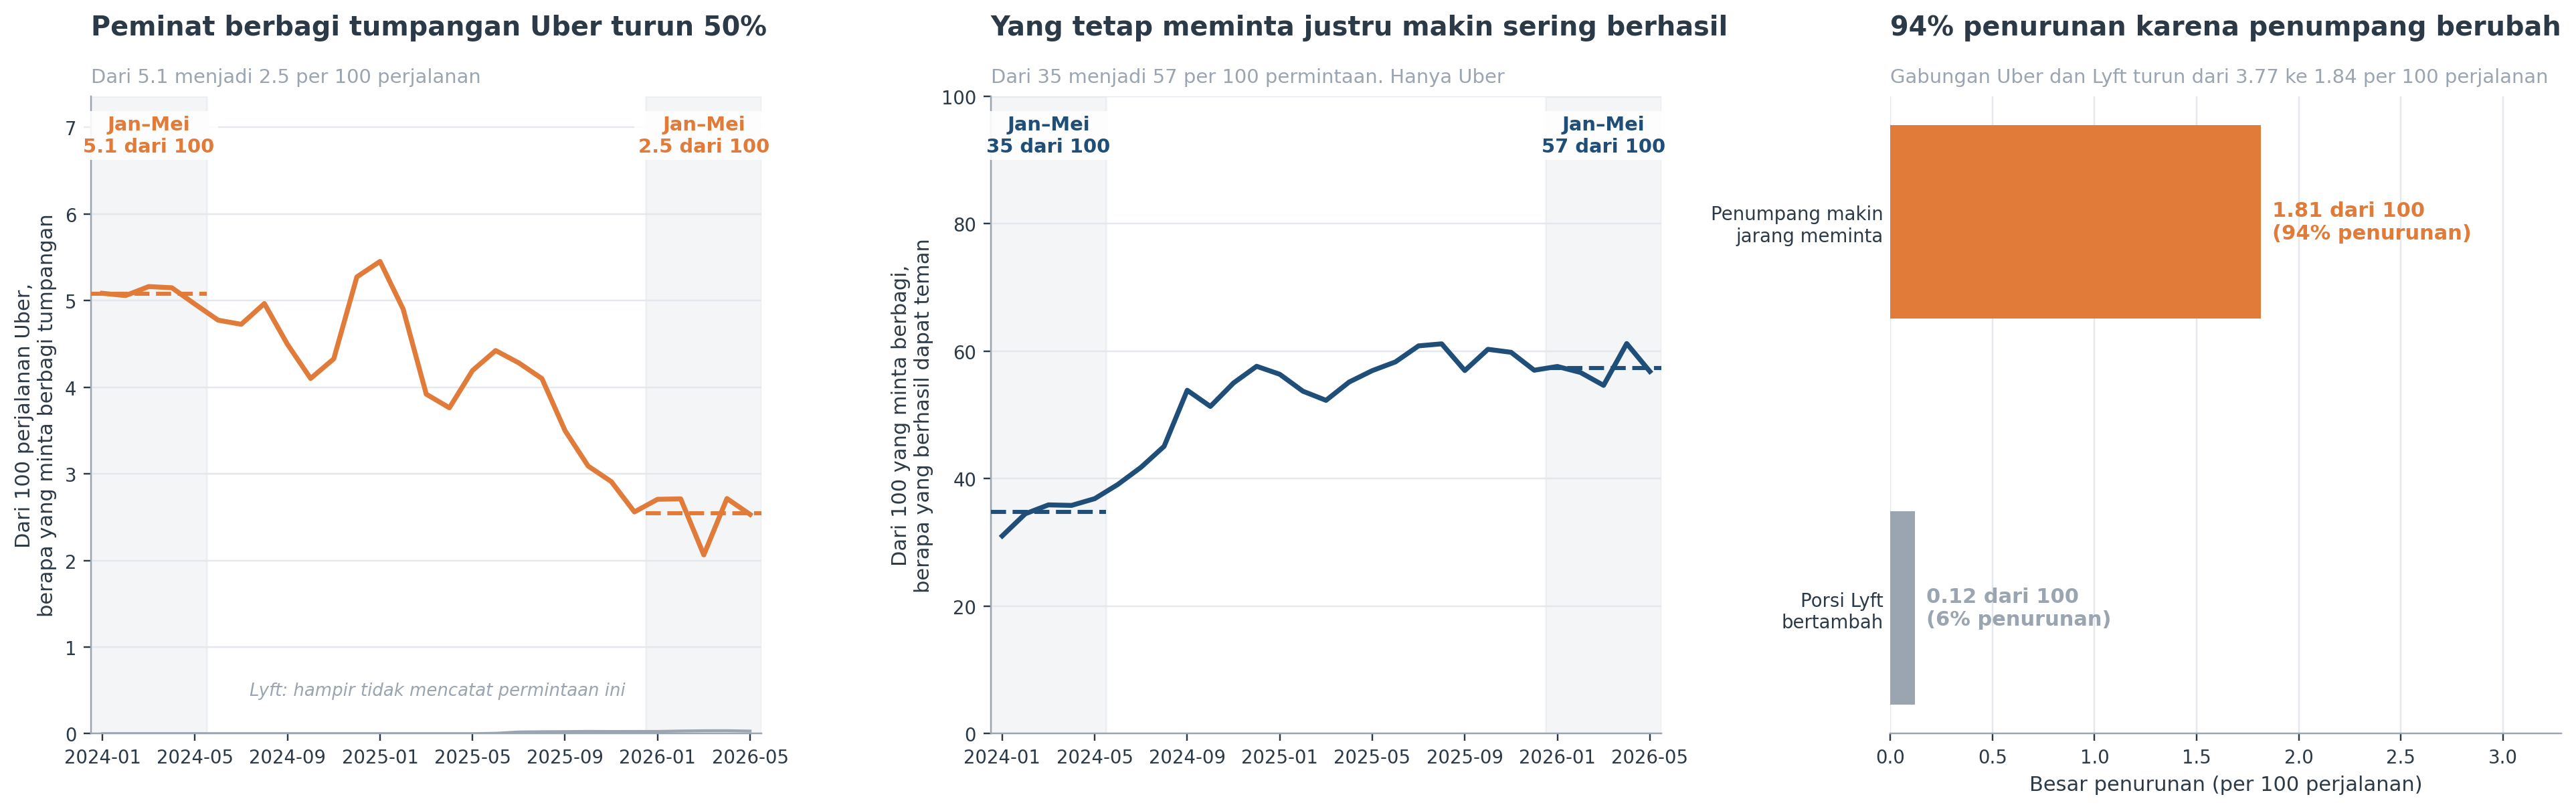

In [108]:
bulan = rate.index.tolist()
x = np.arange(len(bulan))
pos_awal  = [bulan.index(b) for b in awal]
pos_akhir = [bulan.index(b) for b in akhir]


def tandai_periode(ax, seri, nilai_awal, nilai_akhir, colr, fmt, y_label):
    """
    Arsir Januari–Mei 2024 dan 2026, gambar rata-ratanya sebagai garis
    putus-putus pendek, dan tulis angkanya di bagian atas area arsir
    supaya tidak menimpa garis data.
    """
    for pos, nilai in [(pos_awal, nilai_awal), (pos_akhir, nilai_akhir)]:
        x0, x1 = min(pos) - 0.5, max(pos) + 0.5
        ax.axvspan(x0, x1, color=C["muted"], alpha=0.10, zorder=0)
        ax.hlines(nilai, x0, x1, colors=colr, linestyles="--", linewidth=2, zorder=4)
        ax.text((x0 + x1) / 2, y_label, fmt.format(nilai), ha="center", va="top",
                fontsize=9.5, fontweight="bold", color=colr,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=2))


fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))

# ---------- Kiri: berapa penumpang Uber yang minta berbagi ----------
ax = axes[0]
y_top = rate["Uber"].max() * 1.35
ax.plot(x, rate["Uber"], color=C["secondary"], linewidth=2.4, zorder=3)
ax.plot(x, rate["Lyft"], color=C["muted"], linewidth=1.4, zorder=3)
ax.text(len(x) / 2, y_top * 0.06, "Lyft: hampir tidak mencatat permintaan ini",
        ha="center", fontsize=8.5, color=C["muted"], style="italic")
tandai_periode(ax, rate["Uber"], r0["Uber"], r1["Uber"], C["secondary"],
               "Jan–Mei\n{:.1f} dari 100", y_top * 0.97)
ax.set_ylim(0, y_top)
ax.set_xlim(-0.5, len(x) - 0.5)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:.0f}"))
ax.set_ylabel("Dari 100 perjalanan Uber,\nberapa yang minta berbagi tumpangan")
titled(ax, f"Peminat berbagi tumpangan Uber turun {abs(r1['Uber']/r0['Uber']-1)*100:.0f}%",
       f"Dari {r0['Uber']:.1f} menjadi {r1['Uber']:.1f} per 100 perjalanan")
clean_axes(ax)
sparse_ticks(ax, bulan, every=4)

# ---------- Tengah: berapa yang berhasil dapat teman seperjalanan ----------
ax = axes[1]
ax.plot(x, match_uber, color=C["primary"], linewidth=2.4, zorder=3)
tandai_periode(ax, match_uber, m0, m1, C["primary"],
               "Jan–Mei\n{:.0f} dari 100", 97)
ax.set_ylim(0, 100)
ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_ylabel("Dari 100 yang minta berbagi,\nberapa yang berhasil dapat teman")
titled(ax, "Yang tetap meminta justru makin sering berhasil",
       f"Dari {m0:.0f} menjadi {m1:.0f} per 100 permintaan. Hanya Uber")
clean_axes(ax)
sparse_ticks(ax, bulan, every=4)

# ---------- Kanan: kenapa angka gabungan turun ----------
ax = axes[2]
bagian = [("Penumpang makin\njarang meminta", ef_perilaku, C["secondary"]),
          ("Porsi Lyft\nbertambah", ef_komposisi, C["muted"])]
yb = np.arange(len(bagian))
ax.barh(yb, [abs(b[1]) for b in bagian], color=[b[2] for b in bagian], height=0.5)
for k, (n, v, c) in enumerate(bagian):
    ax.text(abs(v) + abs(total) * 0.03, k,
            f"{abs(v):.2f} dari 100\n({abs(v / total) * 100:.0f}% penurunan)",
            ha="left", va="center", fontsize=10, fontweight="bold", color=c)
ax.set_yticks(yb)
ax.set_yticklabels([b[0] for b in bagian])
ax.invert_yaxis()
ax.set_xlim(0, abs(total) * 1.7)
ax.set_xlabel("Besar penurunan (per 100 perjalanan)")
titled(ax, f"{abs(ef_perilaku / total) * 100:.0f}% penurunan karena penumpang berubah",
       f"Gabungan Uber dan Lyft turun dari {gab_awal:.2f} ke {gab_akhir:.2f} per 100 perjalanan")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

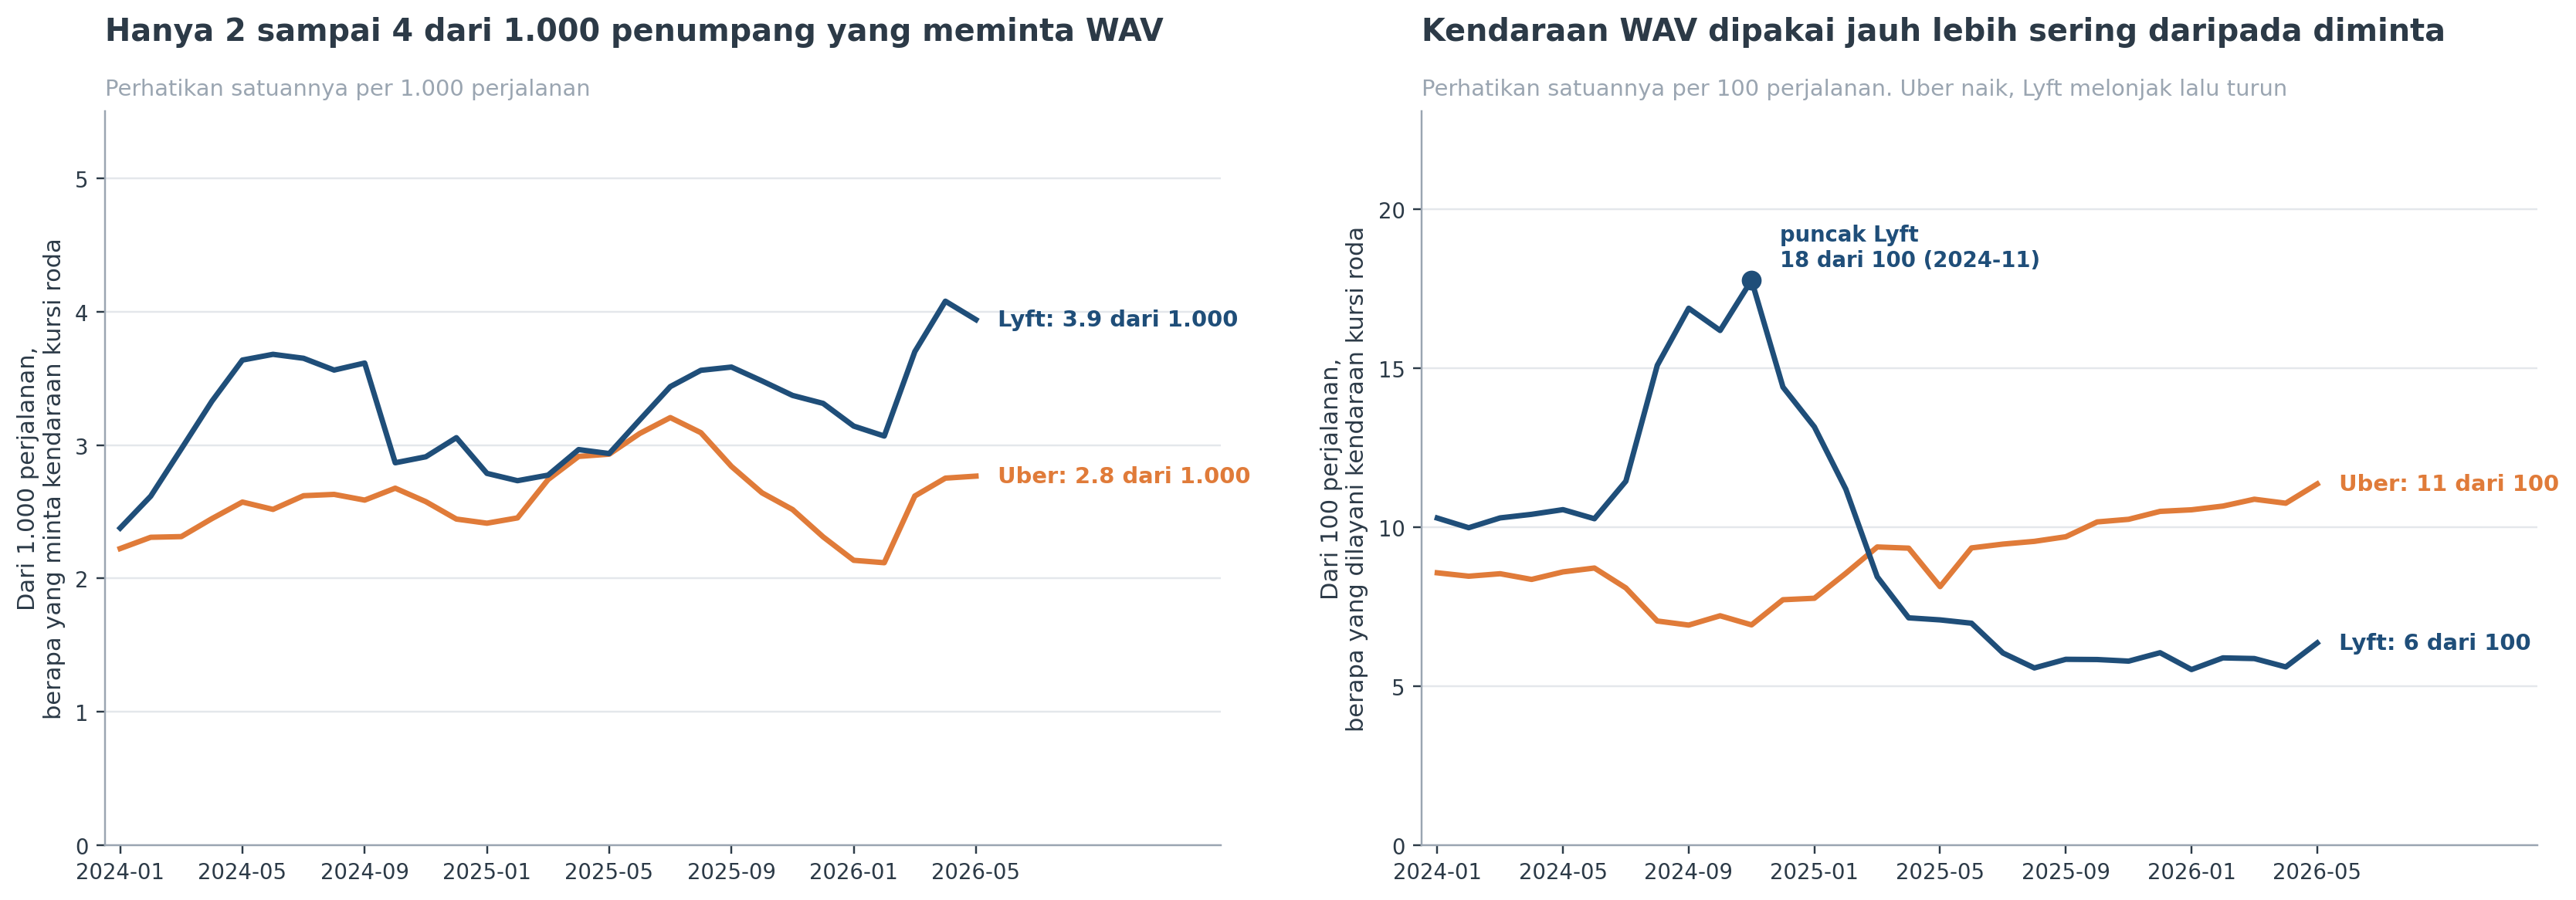

Rata-rata Januari–Mei, per 100 perjalanan dilayani kendaraan WAV:
  Uber  :   8.5  ->   10.8
  Lyft  :  10.3  ->    5.8

Puncak Lyft : 17.8 per 100 pada 2024-11


In [109]:
wav_req = piv("wav_requests") / trips * 1000        # per 1.000 perjalanan
wav_flt = piv("wav_matches")  / trips * 100         # per 100 perjalanan
WARNA_P = {"Uber": C["secondary"], "Lyft": C["primary"]}

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4))

# ---------- Kiri: berapa yang meminta WAV ----------
ax = axes[0]
for p, c in WARNA_P.items():
    ax.plot(x, wav_req[p], color=c, linewidth=2.3)
    label_last(ax, len(x) - 1, wav_req[p].iloc[-1],
               f" {p}: {wav_req[p].iloc[-1]:.1f} dari 1.000", c)
ax.set_ylim(0, wav_req.values.max() * 1.35)
ax.set_xlim(-0.5, len(x) + 7)
ax.set_ylabel("Dari 1.000 perjalanan,\nberapa yang minta kendaraan kursi roda")
titled(ax, "Hanya 2 sampai 4 dari 1.000 penumpang yang meminta WAV",
       "Perhatikan satuannya per 1.000 perjalanan")
clean_axes(ax)
sparse_ticks(ax, bulan, every=4)

# ---------- Kanan: berapa yang dilayani kendaraan WAV ----------
ax = axes[1]
for p, c in WARNA_P.items():
    ax.plot(x, wav_flt[p], color=c, linewidth=2.3)
    label_last(ax, len(x) - 1, wav_flt[p].iloc[-1],
               f" {p}: {wav_flt[p].iloc[-1]:.0f} dari 100", c)

k_pk = int(np.argmax(wav_flt["Lyft"].values))
ax.scatter([k_pk], [wav_flt["Lyft"].iloc[k_pk]], s=55, color=C["primary"], zorder=5)
ax.annotate(f"puncak Lyft\n{wav_flt['Lyft'].iloc[k_pk]:.0f} dari 100 ({bulan[k_pk]})",
            xy=(k_pk, wav_flt["Lyft"].iloc[k_pk]), xytext=(12, 6),
            textcoords="offset points", fontsize=9, color=C["primary"],
            fontweight="semibold")

ax.set_ylim(0, wav_flt.values.max() * 1.3)
ax.set_xlim(-0.5, len(x) + 6)
ax.set_ylabel("Dari 100 perjalanan,\nberapa yang dilayani kendaraan kursi roda")
titled(ax, "Kendaraan WAV dipakai jauh lebih sering daripada diminta",
       "Perhatikan satuannya per 100 perjalanan. Uber naik, Lyft melonjak lalu turun")
clean_axes(ax)
sparse_ticks(ax, bulan, every=4)

plt.tight_layout()
plt.show()

print("Rata-rata Januari–Mei, per 100 perjalanan dilayani kendaraan WAV:")
for p in WARNA_P:
    print(f"  {p:5} : {wav_flt[p].loc[awal].mean():5.1f}  ->  {wav_flt[p].loc[akhir].mean():5.1f}")
print(f"\nPuncak Lyft : {wav_flt['Lyft'].iloc[k_pk]:.1f} per 100 pada {bulan[k_pk]}")

> **Cara membaca grafik**

Semua angka ditulis sebagai "sekian dari 100" atau "sekian dari 1.000" perjalanan. Contohnya, 5 dari 100 berarti dari setiap 100 perjalanan, 5 di antaranya meminta berbagi tumpangan.

**Grafik berbagi tumpangan, panel kiri** — garis oranye adalah jumlah penumpang Uber yang meminta berbagi tumpangan, dari setiap 100 perjalanan. Garis abu-abu di dasar adalah Lyft, yang hampir tidak mencatat permintaan ini. Area abu-abu tipis menandai Januari–Mei 2024 dan Januari–Mei 2026. Garis putus-putus di dalamnya adalah rata-rata periode itu, dengan angkanya tertulis di atas.

**Panel tengah** — dari setiap 100 penumpang Uber yang meminta berbagi tumpangan, berapa yang benar-benar mendapat teman seperjalanan.

**Panel kanan** — angka gabungan Uber dan Lyft turun beberapa poin per 100 perjalanan. Batang oranye menunjukkan berapa bagian penurunan itu yang disebabkan penumpang makin jarang meminta. Batang abu-abu menunjukkan bagian yang disebabkan porsi Lyft bertambah, padahal Lyft tidak mencatat permintaan ini.

**Grafik kendaraan kursi roda** — panel kiri memakai satuan per 1.000 perjalanan karena angkanya sangat kecil. Panel kanan memakai satuan per 100 perjalanan. Jadi walau garisnya terlihat setinggi-sama, angka di panel kanan jauh lebih besar.

> **Hasil Step 12 — berbagi tumpangan dan kendaraan kursi roda**

Perbandingan waktu memakai rata-rata Januari–Mei 2024 dan Januari–Mei 2026.

**Temuan 1 — Lyft hampir tidak mencatat permintaan berbagi tumpangan**

Dari 158 juta perjalanan Lyft, hanya 17.768 yang tercatat meminta berbagi tumpangan — sekitar 1 dari 10.000 perjalanan. Jumlah yang tercatat berhasil dipasangkan (23.203) bahkan lebih besar dari yang meminta, yang secara logika tidak mungkin. Ini persoalan cara pencatatan Lyft, bukan perilaku penumpangnya. Analisis berbagi tumpangan karena itu hanya memakai data Uber.

**Temuan 2 — Peminat berbagi tumpangan Uber turun separuh**

Dari setiap 100 perjalanan Uber, penumpang yang meminta berbagi tumpangan turun dari **5,1 menjadi 2,5**. Penurunannya terjadi bertahap sepanjang 29 bulan, bukan tiba-tiba.

**Temuan 3 — Penurunan ini perubahan perilaku, bukan efek komposisi**

Angka gabungan Uber dan Lyft turun dari 3,77 menjadi 1,84 per 100 perjalanan. Dari penurunan itu, **94% disebabkan penumpang yang memang makin jarang meminta**, dan hanya 6% karena porsi Lyft bertambah. Kekhawatiran bahwa penurunan ini hanya ilusi komposisi tidak terbukti.

**Temuan 4 — Yang tetap meminta justru makin sering berhasil**

Dari setiap 100 penumpang Uber yang meminta berbagi tumpangan, yang berhasil mendapat teman seperjalanan naik dari **35 menjadi 57**. Dengan peminat yang makin sedikit, sistem justru lebih sering berhasil memasangkan. Penyebabnya tidak dapat ditentukan dari data ini.

**Temuan 5 — Kendaraan WAV dipakai jauh lebih sering daripada diminta**

Hanya 2 sampai 4 dari 1.000 penumpang yang meminta kendaraan kursi roda. Namun sekitar 6 sampai 11 dari 100 perjalanan dilayani kendaraan kursi roda. Sebagian besar kendaraan WAV karena itu dipakai untuk penumpang biasa.

**Temuan 6 — Pemakaian kendaraan WAV bergerak berlawanan antar provider**

Di Uber, perjalanan yang dilayani kendaraan WAV naik bertahap dari sekitar 9 menjadi 11 per 100 perjalanan. Di Lyft, angkanya sempat melonjak hingga sekitar 18 per 100 pada akhir 2024, lalu turun tajam ke sekitar 6. Angka gabungan sekitar 9 per 100 menyembunyikan dua arah gerak yang berlawanan ini.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| Minat berbagi tumpangan stabil | Mengarah **tidak**: peminat Uber turun dari 5,1 menjadi 2,5 per 100 perjalanan |
| Penurunan hanya karena komposisi provider | Mengarah **tidak**: 94% penurunan karena perilaku penumpang |

**Keterbatasan**

Data tidak menghubungkan satu permintaan WAV dengan pelayanannya, sehingga tidak dapat diketahui apakah penumpang yang meminta kendaraan kursi roda benar-benar mendapatkannya. Penyebab lonjakan dan penurunan kendaraan WAV di Lyft juga tidak dapat ditentukan dari data ini. Data hanya mencatat perjalanan yang berhasil dilakukan, bukan permintaan yang gagal atau dibatalkan.

**Kaitannya dengan perencanaan**

Berbagi tumpangan mengurangi jumlah mobil yang dibutuhkan untuk jumlah penumpang yang sama. Karena peminatnya turun separuh, kebutuhan armada per penumpang cenderung naik. Hal ini perlu diperhitungkan saat membaca perkiraan permintaan di tahap berikutnya.

> **Keputusan:** analisis berbagi tumpangan memakai Uber saja · peminat turun dari 5,1 ke 2,5 per 100 perjalanan · 94% karena perilaku, bukan komposisi · keberhasilan pemasangan naik dari 35 ke 57 per 100 · kendaraan WAV bergerak berlawanan: Uber naik, Lyft melonjak lalu turun

> **Sebelum pengujian — tiga hal yang perlu dipahami**

**1 · Jam tanpa perjalanan tidak ikut dihitung**

Data hanya berisi kombinasi jam, zona, dan provider yang ada perjalanannya. Jam yang kosong sama sekali tidak tercatat sebagai 0, melainkan tidak muncul.

| Zona | Jam | Perjalanan | Ada di data? |
|---|---|---|---|
| A | 08:00 | 120 | Ya |
| A | 03:00 | 0 | Tidak |

Akibatnya, bila suatu cara menebak memperkirakan ada perjalanan pada jam yang sebenarnya kosong, kesalahan itu tidak ikut terhitung. Angka kesalahan yang dihasilkan karena itu **lebih kecil dari kenyataan** — kesalahan sebenarnya paling tidak sebesar itu.

Namun ketiga cara menebak diuji pada baris data yang sama persis, sehingga perbandingan di antara ketiganya tetap adil.

| Boleh disimpulkan | Tidak boleh disimpulkan |
|---|---|
| Cara mana yang lebih sedikit salahnya | Berapa persis besar kesalahan perencanaan yang sebenarnya |

**2 · Tebakan hanya memakai data masa lalu**

Rata-rata yang dipakai untuk menebak hanya dihitung dari data sebelum periode yang diuji. Bila data periode uji ikut dipakai, hasilnya akan terlihat lebih baik dari kenyataan, sama seperti menebak sambil melihat jawaban. Cara yang memakai angka pekan lalu sudah pasti memakai data masa lalu.

**3 · Pengujian ini memakan kuota paling besar**

Pengujian membaca seluruh data permintaan per jam beberapa kali. Perhatikan angka `Bytes billed` saat dijalankan.

---

# STEP 13 — Seberapa Meleset Perencanaan dengan Rata-rata?

**Tujuan:** mengukur langsung seberapa besar kesalahan bila permintaan tiap zona dan jam ditebak memakai rata-rata masa lalu.

**Kenapa diperlukan:** langkah-langkah sebelumnya menunjukkan permintaan berbeda antar bulan, hari, jam, dan zona. Langkah ini menerjemahkan semuanya menjadi satu angka: berapa besar kesalahan bila armada direncanakan dengan rata-rata.

**Hipotesis yang diuji:**

| Hipotesis | Pertanyaan |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Apakah rata-rata masa lalu cukup akurat untuk menebak permintaan tiap zona dan jam? |

**Cara menguji:**

1. Hitung rata-rata perjalanan untuk setiap kombinasi zona × jam × provider, dari Januari 2024 sampai Desember 2025
2. Pakai rata-rata itu sebagai tebakan untuk Januari sampai Mei 2026
3. Bandingkan tebakan dengan jumlah perjalanan yang sebenarnya terjadi

Rata-rata hanya dihitung dari data sebelum periode uji, agar tebakan tidak memakai informasi yang belum terjadi.

**Ukuran kesalahan:**

```
WMAPE = jumlah seluruh selisih tebakan dan kenyataan ÷ jumlah seluruh perjalanan nyata
```

WMAPE 0,28 berarti dari setiap 100 perjalanan, tebakan meleset sekitar 28. Selain itu dilaporkan juga:

| Ukuran | Artinya |
|---|---|
| MAE | Rata-rata selisih tebakan per zona per jam, dalam jumlah perjalanan |
| RMSE | Sama seperti MAE, tetapi kesalahan besar dihukum lebih berat |
| Arah meleset | Apakah tebakan cenderung terlalu rendah atau terlalu tinggi |

**Input:** `mart_hourly_demand`.

**Expected output:**
1. Kesalahan keseluruhan
2. Kesalahan per kelompok ukuran zona
3. Contoh satu pekan: tebakan dibanding kenyataan
4. Grafik

**Cara interpretasi:** semakin kecil WMAPE, semakin akurat tebakan. Bila WMAPE besar, rata-rata masa lalu tidak memadai sebagai dasar perencanaan.

In [110]:
sql = f"""
WITH hist AS (
    SELECT provider, pickup_location_id, hour, AVG(demand) AS pred
    FROM {MART_DEMAND}
    WHERE request_hour < {TS_TYPE} '{TRAIN_END}'
    GROUP BY 1, 2, 3
),
eval AS (
    SELECT provider, pickup_location_id, hour, demand
    FROM {MART_DEMAND}
    WHERE request_hour >= {TS_TYPE} '{EVAL_START}'
),
joined AS (
    SELECT e.*, COALESCE(h.pred, 0) AS pred
    FROM eval e
    LEFT JOIN hist h USING (provider, pickup_location_id, hour)
)
SELECT
    COUNT(*)                                                AS n_cells,
    SUM(demand)                                             AS total_aktual,
    SUM(pred)                                               AS total_tebakan,
    SAFE_DIVIDE(SUM(ABS(demand - pred)), SUM(demand))       AS wmape,
    AVG(ABS(demand - pred))                                 AS mae,
    SQRT(AVG(POW(demand - pred, 2)))                        AS rmse,
    SAFE_DIVIDE(SUM(pred) - SUM(demand), SUM(demand)) * 100 AS arah_pct,
    COUNTIF(pred < demand) / COUNT(*) * 100                 AS pct_terlalu_rendah
FROM joined
"""

df_gate1 = run_query(sql)
g = df_gate1.iloc[0]

print("KESALAHAN TEBAKAN RATA-RATA, JANUARI–MEI 2026")
print(f"  Sel yang diuji          : {g['n_cells']:,.0f}")
print(f"  Perjalanan nyata        : {g['total_aktual']:,.0f}")
print(f"  Perjalanan ditebak      : {g['total_tebakan']:,.0f}")
print(f"\n  WMAPE                   : {g['wmape']:.4f}  "
      f"(meleset {g['wmape'] * 100:.0f} dari setiap 100 perjalanan)")
print(f"  MAE                     : {g['mae']:.1f} perjalanan per zona per jam")
print(f"  RMSE                    : {g['rmse']:.1f}")
print(f"\n  Arah meleset            : total tebakan {g['arah_pct']:+.1f}% dari kenyataan")
print(f"  Sel yang ditebak terlalu rendah : {g['pct_terlalu_rendah']:.0f}%")

# ---------- Per kelompok ukuran zona ----------
sql = f"""
WITH zone_volume AS (
    SELECT pickup_location_id,
           NTILE(4) OVER (ORDER BY SUM(demand) DESC) AS kelompok
    FROM {MART_DEMAND}
    GROUP BY pickup_location_id
),
hist AS (
    SELECT provider, pickup_location_id, hour, AVG(demand) AS pred
    FROM {MART_DEMAND}
    WHERE request_hour < {TS_TYPE} '{TRAIN_END}'
    GROUP BY 1, 2, 3
),
eval AS (
    SELECT provider, pickup_location_id, hour, demand
    FROM {MART_DEMAND}
    WHERE request_hour >= {TS_TYPE} '{EVAL_START}'
)
SELECT
    v.kelompok,
    COUNT(DISTINCT e.pickup_location_id)                                  AS n_zona,
    SUM(e.demand)                                                         AS total_aktual,
    AVG(e.demand)                                                         AS rata_per_jam,
    SAFE_DIVIDE(SUM(ABS(e.demand - COALESCE(h.pred, 0))), SUM(e.demand))  AS wmape,
    SAFE_DIVIDE(SUM(COALESCE(h.pred, 0)) - SUM(e.demand), SUM(e.demand)) * 100 AS arah_pct
FROM eval e
JOIN zone_volume v USING (pickup_location_id)
LEFT JOIN hist h USING (provider, pickup_location_id, hour)
GROUP BY v.kelompok
ORDER BY v.kelompok
"""

df_gate1_tier = run_query(sql)
df_gate1_tier["meleset_per_100"] = df_gate1_tier["wmape"] * 100
df_gate1_tier["porsi_perjalanan"] = (df_gate1_tier["total_aktual"]
                                     / df_gate1_tier["total_aktual"].sum() * 100)

df_gate1_tier.set_index("kelompok")[[
    "n_zona", "rata_per_jam", "porsi_perjalanan", "meleset_per_100", "arah_pct"]] \
    .style.format({"rata_per_jam": "{:,.0f}", "porsi_perjalanan": "{:.0f}%",
                   "meleset_per_100": "{:.0f}", "arah_pct": "{:+.1f}%"})

Rows returned : 1
Bytes billed  : 0.0000 GB
KESALAHAN TEBAKAN RATA-RATA, JANUARI–MEI 2026
  Sel yang diuji          : 1,792,197
  Perjalanan nyata        : 105,994,736
  Perjalanan ditebak      : 99,777,132

  WMAPE                   : 0.2755  (meleset 28 dari setiap 100 perjalanan)
  MAE                     : 16.3 perjalanan per zona per jam
  RMSE                    : 31.3

  Arah meleset            : total tebakan -5.9% dari kenyataan
  Sel yang ditebak terlalu rendah : 56%
Rows returned : 4
Bytes billed  : 0.0000 GB


,n_zona,rata_per_jam,porsi_perjalanan,meleset_per_100,arah_pct
kelompok,,,,,
1,66,118,53%,28,-3.0%
2,66,62,28%,26,-7.9%
3,66,33,15%,28,-11.3%
4,64,11,4%,34,-10.1%


In [111]:
CONTOH_ZONA     = 138          # LaGuardia Airport
CONTOH_PROVIDER = "Uber"
MINGGU_MULAI    = "2026-03-02" # Senin
MINGGU_AKHIR    = "2026-03-09"

sql = f"""
WITH hist AS (
    SELECT hour, AVG(demand) AS pred
    FROM {MART_DEMAND}
    WHERE request_hour < {TS_TYPE} '{TRAIN_END}'
      AND pickup_location_id = {CONTOH_ZONA}
      AND provider = '{CONTOH_PROVIDER}'
    GROUP BY hour
)
SELECT d.request_hour, d.hour, d.demand, h.pred
FROM {MART_DEMAND} d
JOIN hist h USING (hour)
WHERE d.pickup_location_id = {CONTOH_ZONA}
  AND d.provider = '{CONTOH_PROVIDER}'
  AND d.request_hour >= {TS_TYPE} '{MINGGU_MULAI} 00:00:00'
  AND d.request_hour <  {TS_TYPE} '{MINGGU_AKHIR} 00:00:00'
ORDER BY d.request_hour
"""

df_contoh = run_query(sql)
wmape_contoh = (df_contoh["demand"] - df_contoh["pred"]).abs().sum() / df_contoh["demand"].sum()
print(f"{nama.get(CONTOH_ZONA)}, {CONTOH_PROVIDER}, {MINGGU_MULAI} sampai {MINGGU_AKHIR}")
print(f"Meleset {wmape_contoh * 100:.0f} dari setiap 100 perjalanan pada pekan ini")
print(f"Jam yang tercatat: {len(df_contoh)} dari 168 (8 Maret 2026 adalah tanggal pergantian musim semi)")

Rows returned : 166
Bytes billed  : 0.0000 GB
LaGuardia Airport, Uber, 2026-03-02 sampai 2026-03-09
Meleset 22 dari setiap 100 perjalanan pada pekan ini
Jam yang tercatat: 166 dari 168 (8 Maret 2026 adalah tanggal pergantian musim semi)


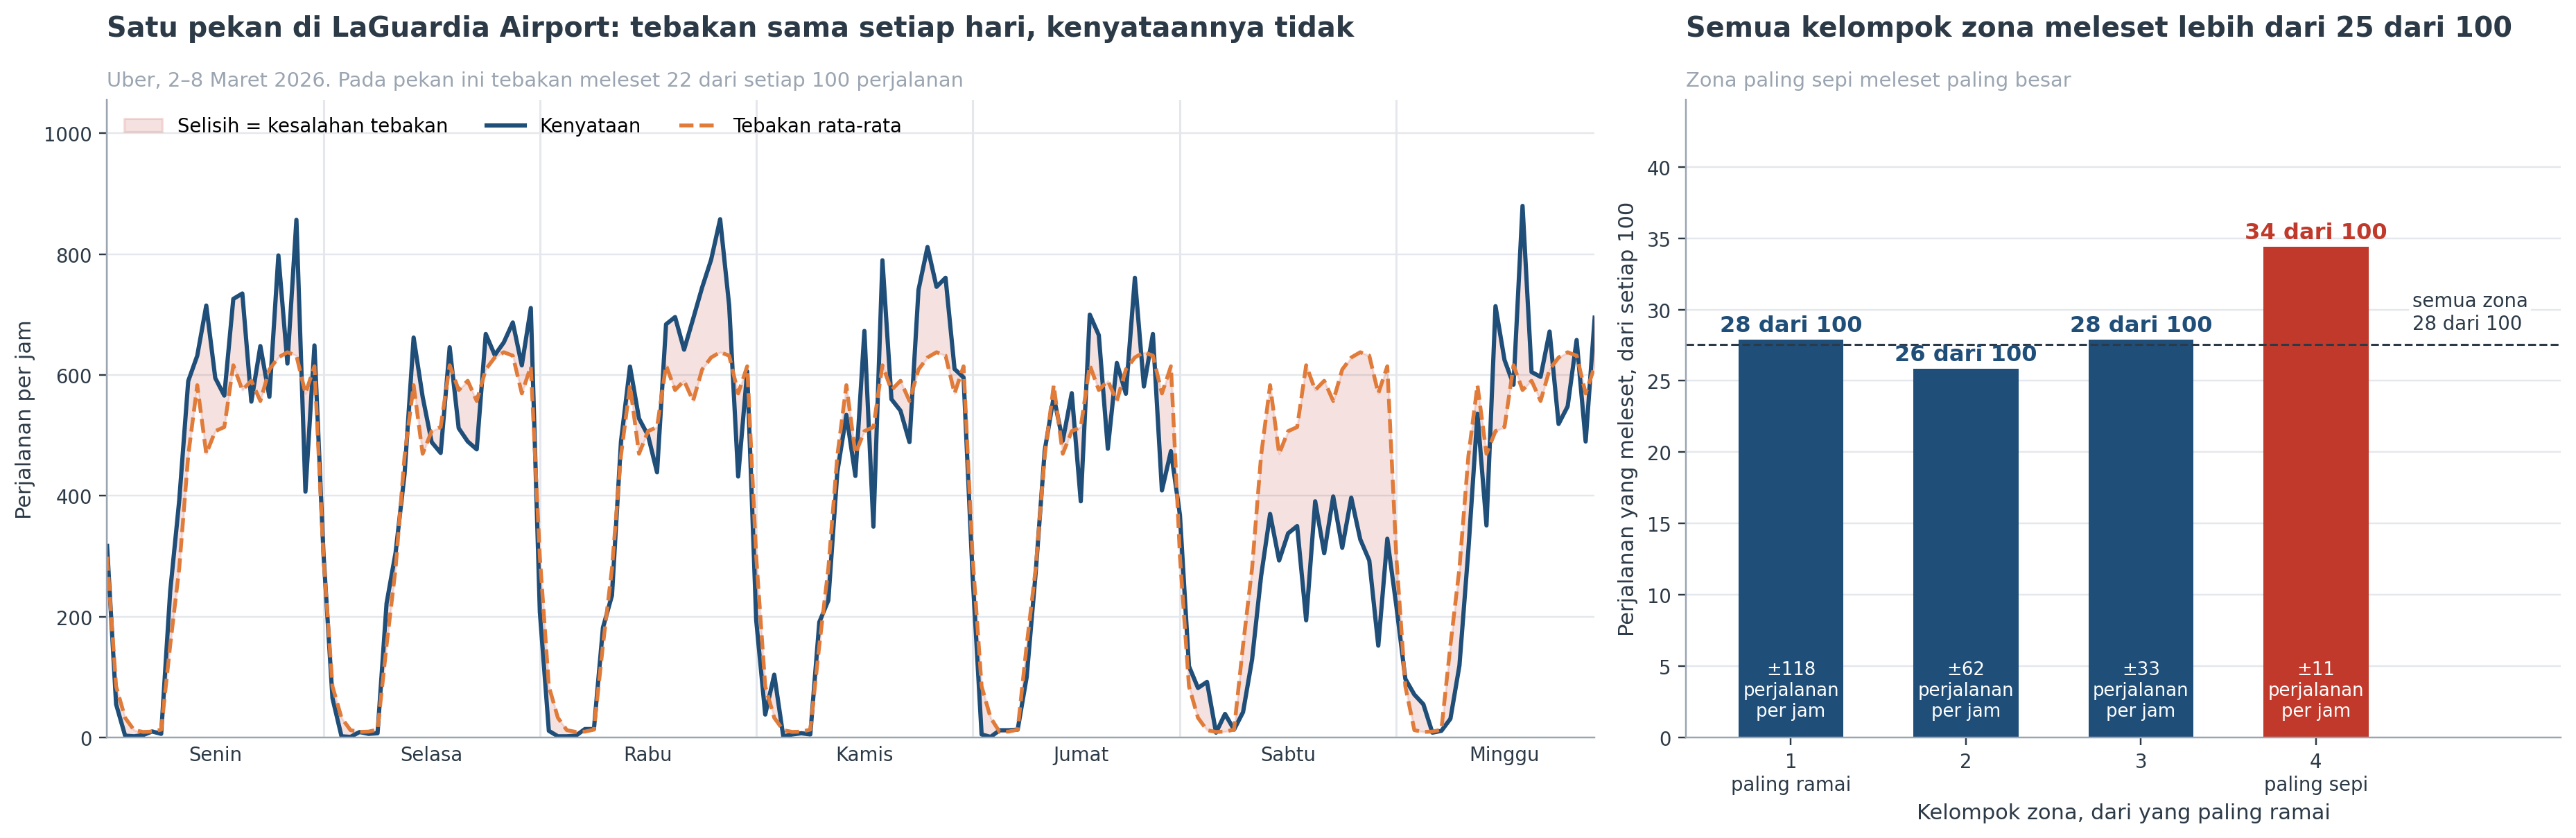

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5.6),
                         gridspec_kw={"width_ratios": [1.7, 1]})

# ---------- Kiri: satu pekan, tebakan vs kenyataan ----------
ax = axes[0]
xk = np.arange(len(df_contoh))
ax.fill_between(xk, df_contoh["demand"], df_contoh["pred"],
                color=C["alert"], alpha=0.15, label="Selisih = kesalahan tebakan")
ax.plot(xk, df_contoh["demand"], color=C["primary"], linewidth=2, label="Kenyataan")
ax.plot(xk, df_contoh["pred"], color=C["secondary"], linewidth=1.8,
        linestyle="--", label="Tebakan rata-rata")

hari = pd.to_datetime(df_contoh["request_hour"]).dt.day_name().map(
    {"Monday": "Senin", "Tuesday": "Selasa", "Wednesday": "Rabu", "Thursday": "Kamis",
     "Friday": "Jumat", "Saturday": "Sabtu", "Sunday": "Minggu"})
awal_hari = [i for i in range(len(df_contoh)) if df_contoh["hour"].iloc[i] == 0]
for i in awal_hari:
    ax.axvline(i, color=C["grid"], linewidth=1, zorder=0)
ax.set_xticks([i + 12 for i in awal_hari])
ax.set_xticklabels([hari.iloc[i] for i in awal_hari])
ax.tick_params(axis="x", length=0)
ax.set_xlim(0, len(xk) - 1)
ax.set_ylim(0, df_contoh[["demand", "pred"]].values.max() * 1.2)
ax.set_ylabel("Perjalanan per jam")
ax.legend(loc="upper left", ncol=3, fontsize=9)
titled(ax, f"Satu pekan di {nama.get(CONTOH_ZONA)}: tebakan sama setiap hari, kenyataannya tidak",
       f"{CONTOH_PROVIDER}, 2–8 Maret 2026. Pada pekan ini tebakan meleset "
       f"{wmape_contoh * 100:.0f} dari setiap 100 perjalanan")
clean_axes(ax)

# ---------- Kanan: kesalahan per kelompok ukuran zona ----------
ax = axes[1]
label_k = ["1\npaling ramai", "2", "3", "4\npaling sepi"]
nilai = df_gate1_tier["meleset_per_100"].values
warna = [C["alert"] if v == nilai.max() else C["primary"] for v in nilai]
ax.bar(label_k, nilai, color=warna, width=0.6)
for i, (v, r) in enumerate(zip(nilai, df_gate1_tier["rata_per_jam"])):
    ax.text(i, v + 0.6, f"{v:.0f} dari 100", ha="center", fontsize=10.5,
            fontweight="bold", color=warna[i])
    ax.text(i, 1.2, f"±{r:,.0f}\nperjalanan\nper jam", ha="center", va="bottom",
            fontsize=8.5, color="white")

semua = g["wmape"] * 100
ax.axhline(semua, color=C["text"], linestyle="--", linewidth=1)
ax.text(3.55, semua + 0.8, f"semua zona\n{semua:.0f} dari 100", va="bottom",
        ha="left", fontsize=9, color=C["text"],
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.5))

ax.set_ylim(0, nilai.max() * 1.3)
ax.set_xlim(-0.6, 4.4)
ax.set_xlabel("Kelompok zona, dari yang paling ramai")
ax.set_ylabel("Perjalanan yang meleset, dari setiap 100")
titled(ax, "Semua kelompok zona meleset lebih dari 25 dari 100",
       "Zona paling sepi meleset paling besar")
clean_axes(ax)

plt.tight_layout()
plt.show()

> **Cara membaca grafik**

**Panel kiri** — satu pekan nyata di LaGuardia Airport untuk Uber, 2–8 Maret 2026, jam per jam. Garis tipis vertikal memisahkan hari.

| Garis | Artinya |
|---|---|
| Biru | Jumlah perjalanan yang benar-benar terjadi |
| Oranye putus-putus | Tebakan dari rata-rata masa lalu pada jam yang sama |
| Area merah muda | Selisih keduanya, yaitu kesalahan tebakan |

Garis oranye bentuknya sama persis setiap hari, karena rata-rata tidak membedakan hari. Semakin lebar area merah muda, semakin besar kesalahan pada jam itu.

**Panel kanan** — seluruh zona dibagi empat kelompok berdasarkan keramaiannya, masing-masing sekitar 66 zona. Tinggi batang menunjukkan berapa perjalanan yang meleset dari setiap 100. Angka putih di dalam batang adalah rata-rata perjalanan per jam di kelompok itu. Garis putus-putus adalah kesalahan untuk seluruh zona.

> **Hasil Step 13 — seberapa meleset perencanaan dengan rata-rata**

Tebakan memakai rata-rata Januari 2024 – Desember 2025 untuk setiap zona, jam, dan provider, lalu diuji pada Januari – Mei 2026.

**Temuan 1 — Rata-rata meleset sekitar 28 dari setiap 100 perjalanan**

| Ukuran | Nilai | Artinya |
|---|---|---|
| WMAPE | 0,2755 | Meleset sekitar 28 dari setiap 100 perjalanan |
| MAE | 16,3 | Di setiap zona pada setiap jam, tebakan meleset rata-rata 16 perjalanan |
| RMSE | 31,3 | Hampir dua kali MAE: sebagian jam meleset sangat besar |

Pengujian mencakup 1.792.197 kombinasi zona, jam, dan provider dengan total 106 juta perjalanan. Padahal tebakan ini sudah memakai rata-rata paling rinci — membedakan zona, jam, dan provider sekaligus. Rata-rata yang lebih kasar, seperti rata-rata per kota atau per hari, akan meleset lebih besar lagi.

**Temuan 2 — Tebakan sama setiap hari, kenyataannya tidak**

Rata-rata masa lalu memberikan tebakan yang persis sama untuk jam yang sama, apa pun harinya. Contoh satu pekan di LaGuardia memperlihatkan kesalahannya tidak acak:

| Waktu | Arah kesalahan |
|---|---|
| Sabtu siang sampai sore | Tebakan sekitar dua kali lebih tinggi dari kenyataan |
| Sore hari kerja dan Minggu malam | Tebakan lebih rendah dari kenyataan pada jam tersibuk |
| Dini hari | Tebakan dan kenyataan hampir berimpit |

Pada pekan 2–8 Maret 2026, tebakan untuk LaGuardia meleset 22 dari setiap 100 perjalanan.

**Temuan 3 — Semua kelompok zona meleset lebih dari 25 dari 100**

| Kelompok zona | Rata-rata perjalanan per jam | Meleset dari 100 |
|---|---|---|
| 1 — paling ramai | 118 | 28 |
| 2 | 62 | 26 |
| 3 | 33 | 28 |
| 4 — paling sepi | 11 | 34 |

Zona ramai tidak lebih mudah ditebak daripada zona sedang. Zona paling sepi meleset paling besar, karena selisih beberapa perjalanan saja sudah besar persentasenya.

**Temuan 4 — Tebakan rata-rata cenderung terlalu rendah**

| Ukuran | Nilai |
|---|---|
| Perjalanan nyata | 105.994.736 |
| Perjalanan ditebak | 99.777.132 |
| Total tebakan dibanding kenyataan | −5,9% |
| Sel yang ditebak terlalu rendah | 56% |

Rata-rata masa lalu menebak 5,9% lebih sedikit dari yang benar-benar terjadi. Angka ini sama dengan pertumbuhan permintaan dua tahun (+5,9%): rata-rata 2024–2025 tertinggal dari permintaan 2026 yang sudah lebih tinggi. Sebagian kesalahan tebakan karena itu berasal dari tren yang tidak tertangkap, bukan hanya dari pola hari dan jam.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | Mengarah **tidak memadai**: rata-rata paling rinci pun meleset sekitar 28 dari setiap 100 perjalanan |

**Keterbatasan**

Jam tanpa perjalanan tidak tercatat dalam data, sehingga kesalahan pada jam-jam itu tidak ikut terhitung. Angka kesalahan sebenarnya paling tidak sebesar yang dilaporkan di sini. Contoh LaGuardia hanya satu pekan di satu zona, dipakai untuk memperlihatkan bentuk kesalahan, bukan untuk menyimpulkan besarnya. Pekan contoh mencakup 8 Maret 2026, tanggal pergantian musim semi, sehingga tercatat 166 dari 168 jam.

**Pertanyaan berikutnya**

Rata-rata tidak memadai. Namun itu belum cukup untuk membenarkan pembuatan model. Kesalahan pada contoh LaGuardia tampak berpola — terlalu tinggi di hari Sabtu, terlalu rendah di jam sibuk hari kerja. Perlu diuji apakah pola seperti ini berlaku di seluruh zona dan dapat mengurangi kesalahan.

> **Keputusan:** rata-rata paling rinci meleset sekitar 28 dari 100 perjalanan · tebakan 5,9% terlalu rendah karena tren tidak tertangkap · semua kelompok zona meleset lebih dari 25 dari 100 · kesalahan berpola menurut hari, bukan acak · perlu diuji apakah pola dapat mengurangi kesalahan

---

# STEP 14 — Apakah Kesalahan Tebakan Berpola?

**Tujuan:** menguji apakah kesalahan tebakan rata-rata bersifat acak, atau punya pola yang bisa dipelajari.

**Kenapa diperlukan:** rata-rata terbukti meleset sekitar 28 dari setiap 100 perjalanan. Namun itu belum cukup untuk membenarkan pembuatan model. Bila kesalahannya acak, tidak ada cara apa pun yang bisa menebak lebih baik, dan solusinya adalah menyiapkan armada cadangan. Bila kesalahannya berpola, cara menebak yang memakai pola itu akan lebih akurat, dan model layak dibuat.

**Hipotesis yang diuji:**

| Hipotesis | Pertanyaan |
|---|---|
| Variasi permintaan punya pola yang dapat dipelajari | Apakah menambah informasi waktu membuat tebakan lebih akurat? |

**Cara menguji:** bandingkan tiga cara menebak pada periode Januari–Mei 2026. Setiap cara memakai lebih banyak informasi waktu dari cara sebelumnya.

| Cara | Informasi yang dipakai | Contoh tebakan untuk Sabtu jam 18:00 |
|---|---|---|
| A | Rata-rata zona saja | Rata-rata semua jam di zona itu |
| B | Rata-rata zona per jam | Rata-rata semua jam 18:00 di zona itu |
| C | Angka pekan lalu | Angka Sabtu sebelumnya jam 18:00 di zona itu |

Cara A dan B hanya memakai data sebelum periode uji. Cara C memakai angka 168 jam sebelumnya (7 hari × 24 jam), yang dengan sendirinya sudah berada di masa lalu.

**Input:** `mart_hourly_demand`.

**Expected output:**
1. Kesalahan ketiga cara untuk seluruh zona
2. Kesalahan ketiga cara per kelompok ukuran zona
3. Jam tanpa angka pekan lalu per kelompok zona
4. Perbandingan Cara B dan Cara C per pekan
5. Grafik

**Cara interpretasi:**
- Bila kesalahan turun tajam dari A ke C, permintaan punya pola dan model layak dibuat
- Bila kesalahan hampir sama, permintaan acak dan model tidak akan membantu
- Kesalahan Cara C menjadi batas yang wajib dikalahkan model mana pun

In [113]:
def sql_tiga_cara(dengan_kelompok=False):
    kolom_k = "v.kelompok," if dengan_kelompok else ""
    join_k  = "JOIN zone_volume v USING (pickup_location_id)" if dengan_kelompok else ""
    group_k = "GROUP BY v.kelompok ORDER BY v.kelompok" if dengan_kelompok else ""
    cte_k = f"""
zone_volume AS (
    SELECT pickup_location_id,
           NTILE(4) OVER (ORDER BY SUM(demand) DESC) AS kelompok
    FROM {MART_DEMAND}
    GROUP BY pickup_location_id
),""" if dengan_kelompok else ""

    return f"""
WITH {cte_k}
cara_a AS (
    SELECT provider, pickup_location_id, AVG(demand) AS pred_a
    FROM {MART_DEMAND}
    WHERE request_hour < {TS_TYPE} '{TRAIN_END}'
    GROUP BY 1, 2
),
cara_b AS (
    SELECT provider, pickup_location_id, hour, AVG(demand) AS pred_b
    FROM {MART_DEMAND}
    WHERE request_hour < {TS_TYPE} '{TRAIN_END}'
    GROUP BY 1, 2, 3
),
cara_c AS (
    SELECT provider, pickup_location_id,
           {TS_ADD}(request_hour, INTERVAL 168 HOUR) AS target_hour,
           demand AS pred_c
    FROM {MART_DEMAND}
),
eval AS (
    SELECT provider, pickup_location_id, hour, request_hour, demand
    FROM {MART_DEMAND}
    WHERE request_hour >= {TS_TYPE} '{EVAL_START}'
)
SELECT
    {kolom_k}
    COUNT(*)                                                                 AS n_cells,
    SUM(e.demand)                                                            AS total_aktual,
    SAFE_DIVIDE(SUM(ABS(e.demand - COALESCE(a.pred_a, 0))), SUM(e.demand))   AS wmape_a,
    SAFE_DIVIDE(SUM(ABS(e.demand - COALESCE(b.pred_b, 0))), SUM(e.demand))   AS wmape_b,
    SAFE_DIVIDE(SUM(ABS(e.demand - COALESCE(c.pred_c, 0))), SUM(e.demand))   AS wmape_c,
    AVG(ABS(e.demand - COALESCE(a.pred_a, 0)))                               AS mae_a,
    AVG(ABS(e.demand - COALESCE(b.pred_b, 0)))                               AS mae_b,
    AVG(ABS(e.demand - COALESCE(c.pred_c, 0)))                               AS mae_c,
    SQRT(AVG(POW(e.demand - COALESCE(a.pred_a, 0), 2)))                      AS rmse_a,
    SQRT(AVG(POW(e.demand - COALESCE(b.pred_b, 0), 2)))                      AS rmse_b,
    SQRT(AVG(POW(e.demand - COALESCE(c.pred_c, 0), 2)))                      AS rmse_c,
    COUNTIF(c.pred_c IS NULL)                                                AS tanpa_pekan_lalu
FROM eval e
{join_k}
LEFT JOIN cara_a a USING (provider, pickup_location_id)
LEFT JOIN cara_b b USING (provider, pickup_location_id, hour)
LEFT JOIN cara_c c
       ON c.provider = e.provider
      AND c.pickup_location_id = e.pickup_location_id
      AND c.target_hour = e.request_hour
{group_k}
"""

df_gate2 = run_query(sql_tiga_cara())
g2 = df_gate2.iloc[0]
wa, wb, wc = g2["wmape_a"], g2["wmape_b"], g2["wmape_c"]

print("KESALAHAN TIGA CARA MENEBAK, JANUARI–MEI 2026")
print(f"  Sel yang diuji : {g2['n_cells']:,.0f}\n")
print(f"  {'Cara':32} {'Meleset dari 100':>17} {'MAE':>7} {'RMSE':>7}")
for kode, nama_cara, w, m, r in [
        ("A", "rata-rata zona saja",    wa, g2["mae_a"], g2["rmse_a"]),
        ("B", "rata-rata zona per jam", wb, g2["mae_b"], g2["rmse_b"]),
        ("C", "angka pekan lalu",       wc, g2["mae_c"], g2["rmse_c"])]:
    print(f"  {kode}  {nama_cara:29} {w * 100:>17.1f} {m:>7.1f} {r:>7.1f}")

print(f"\n  Kesalahan berkurang dari A ke C : "
      f"{wa * 100:.0f} -> {wc * 100:.0f} dari 100 ({(1 - wc / wa) * 100:.0f}% lebih sedikit)")

n_kosong = g2["tanpa_pekan_lalu"]
print(f"\n  Sel tanpa angka pekan lalu : {n_kosong:,.0f} "
      f"({n_kosong / g2['n_cells'] * 100:.1f}%)")
print("  Pada sel ini Cara C menebak 0, sehingga kesalahannya justru dibuat lebih besar.")

if (wa - wc) / wa > 0.20:
    print("\n  KESIMPULAN: kesalahan turun tajam. Permintaan punya pola yang dapat dipelajari.")
else:
    print("\n  KESIMPULAN: kesalahan hampir tidak turun. Permintaan cenderung acak.")
print(f"  Batas yang wajib dikalahkan model : meleset {wc * 100:.1f} dari 100 (Cara C)")

Rows returned : 1
Bytes billed  : 0.0000 GB
KESALAHAN TIGA CARA MENEBAK, JANUARI–MEI 2026
  Sel yang diuji : 1,792,197

  Cara                              Meleset dari 100     MAE    RMSE
  A  rata-rata zona saja                        43.9    26.0    46.0
  B  rata-rata zona per jam                     27.5    16.3    31.3
  C  angka pekan lalu                           22.1    13.1    26.4

  Kesalahan berkurang dari A ke C : 44 -> 22 dari 100 (50% lebih sedikit)

  Sel tanpa angka pekan lalu : 31,417 (1.8%)
  Pada sel ini Cara C menebak 0, sehingga kesalahannya justru dibuat lebih besar.

  KESIMPULAN: kesalahan turun tajam. Permintaan punya pola yang dapat dipelajari.
  Batas yang wajib dikalahkan model : meleset 22.1 dari 100 (Cara C)


In [114]:
df_gate2_tier = run_query(sql_tiga_cara(dengan_kelompok=True))

tampil = df_gate2_tier.set_index("kelompok")[["wmape_a", "wmape_b", "wmape_c"]] * 100
tampil.columns = ["Cara A", "Cara B", "Cara C"]
tampil["Berkurang A→C"] = (1 - tampil["Cara C"] / tampil["Cara A"]) * 100
tampil.index = ["1 — paling ramai", "2", "3", "4 — paling sepi"]
tampil.index.name = "Kelompok zona"

print("Perjalanan yang meleset dari setiap 100, per kelompok zona:\n")
tampil.style.format({"Cara A": "{:.0f}", "Cara B": "{:.0f}", "Cara C": "{:.0f}",
                     "Berkurang A→C": "{:.0f}%"})

Rows returned : 4
Bytes billed  : 0.0000 GB
Perjalanan yang meleset dari setiap 100, per kelompok zona:



,Cara A,Cara B,Cara C,Berkurang A→C
Kelompok zona,,,,
1 — paling ramai,45,28,21,53%
2,41,26,21,49%
3,44,28,25,44%
4 — paling sepi,50,34,36,29%


In [115]:
# ---------- Jam tanpa angka pekan lalu, per kelompok zona ----------
# Pada jam ini Cara C terpaksa menebak 0, sehingga perlu diketahui
# di kelompok mana hal itu paling sering terjadi.
sql = f"""
WITH zone_volume AS (
    SELECT pickup_location_id,
           NTILE(4) OVER (ORDER BY SUM(demand) DESC) AS kelompok
    FROM {MART_DEMAND}
    GROUP BY pickup_location_id
),
cara_c AS (
    SELECT provider, pickup_location_id,
           {TS_ADD}(request_hour, INTERVAL 168 HOUR) AS target_hour
    FROM {MART_DEMAND}
),
eval AS (
    SELECT provider, pickup_location_id, request_hour
    FROM {MART_DEMAND}
    WHERE request_hour >= {TS_TYPE} '{EVAL_START}'
)
SELECT
    v.kelompok,
    COUNT(*)                                        AS n_cells,
    COUNTIF(c.target_hour IS NULL)                  AS tanpa_pekan_lalu,
    COUNTIF(c.target_hour IS NULL) / COUNT(*) * 100 AS persen
FROM eval e
JOIN zone_volume v USING (pickup_location_id)
LEFT JOIN cara_c c
       ON c.provider = e.provider
      AND c.pickup_location_id = e.pickup_location_id
      AND c.target_hour = e.request_hour
GROUP BY v.kelompok
ORDER BY v.kelompok
"""

df_kosong_c = run_query(sql)
df_kosong_c.index = ["1 — paling ramai", "2", "3", "4 — paling sepi"]
df_kosong_c.index.name = "Kelompok zona"
df_kosong_c[["n_cells", "tanpa_pekan_lalu", "persen"]].style.format(
    {"n_cells": "{:,.0f}", "tanpa_pekan_lalu": "{:,.0f}", "persen": "{:.1f}%"})

Rows returned : 4
Bytes billed  : 0.0000 GB


,n_cells,tanpa_pekan_lalu,persen
Kelompok zona,,,
1 — paling ramai,"477,987",365,0.1%
2,"478,003",360,0.1%
3,"476,650","1,515",0.3%
4 — paling sepi,"359,557","29,177",8.1%


In [116]:
BATAS_POIN = 1.0   # batas manfaat praktis, per 100 perjalanan

sql = f"""
WITH zone_volume AS (
    SELECT pickup_location_id,
           NTILE(4) OVER (ORDER BY SUM(demand) DESC) AS kelompok
    FROM {MART_DEMAND}
    GROUP BY pickup_location_id
),
cara_b AS (
    SELECT provider, pickup_location_id, hour, AVG(demand) AS pred_b
    FROM {MART_DEMAND}
    WHERE request_hour < {TS_TYPE} '{TRAIN_END}'
    GROUP BY 1, 2, 3
),
cara_c AS (
    SELECT provider, pickup_location_id,
           {TS_ADD}(request_hour, INTERVAL 168 HOUR) AS target_hour,
           demand AS pred_c
    FROM {MART_DEMAND}
),
eval AS (
    SELECT provider, pickup_location_id, hour, request_hour, demand,
           DATE_TRUNC(DATE(request_hour), WEEK(MONDAY)) AS pekan
    FROM {MART_DEMAND}
    WHERE request_hour >= {TS_TYPE} '{EVAL_START}'
)
SELECT
    v.kelompok,
    e.pekan,
    SAFE_DIVIDE(SUM(ABS(e.demand - COALESCE(b.pred_b, 0))), SUM(e.demand)) * 100 AS meleset_b,
    SAFE_DIVIDE(SUM(ABS(e.demand - c.pred_c)), SUM(e.demand)) * 100              AS meleset_c
FROM eval e
JOIN zone_volume v USING (pickup_location_id)
LEFT JOIN cara_b b USING (provider, pickup_location_id, hour)
JOIN cara_c c                                  -- hanya sel yang punya angka pekan lalu
       ON c.provider = e.provider
      AND c.pickup_location_id = e.pickup_location_id
      AND c.target_hour = e.request_hour
GROUP BY v.kelompok, e.pekan
ORDER BY v.kelompok, e.pekan
"""

df_pekan = run_query(sql)
df_pekan["selisih"] = df_pekan["meleset_c"] - df_pekan["meleset_b"]

ringkas = df_pekan.groupby("kelompok").agg(
    jumlah_pekan   = ("pekan", "count"),
    rata_selisih   = ("selisih", "mean"),
    c_menang       = ("selisih", lambda s: (s <= -BATAS_POIN).sum()),
    setara         = ("selisih", lambda s: (s.abs() < BATAS_POIN).sum()),
    c_kalah        = ("selisih", lambda s: (s >= BATAS_POIN).sum()),
)
ringkas.index = ["1 — paling ramai", "2", "3", "4 — paling sepi"]
ringkas.index.name = "Kelompok zona"

print("Hanya sel yang punya angka pekan lalu.")
print(f"Selisih = kesalahan Cara C dikurangi Cara B, per 100 perjalanan.")
print(f"Menang atau kalah bila selisihnya minimal {BATAS_POIN:.0f} poin; di bawah itu dianggap setara.\n")
ringkas.style.format({"rata_selisih": "{:+.1f}"})

Rows returned : 88
Bytes billed  : 0.0000 GB
Hanya sel yang punya angka pekan lalu.
Selisih = kesalahan Cara C dikurangi Cara B, per 100 perjalanan.
Menang atau kalah bila selisihnya minimal 1 poin; di bawah itu dianggap setara.



,jumlah_pekan,rata_selisih,c_menang,setara,c_kalah
Kelompok zona,,,,,
1 — paling ramai,22,-6.8,21,0,1
2,22,-4.7,20,1,1
3,22,-3.1,18,2,2
4 — paling sepi,22,+0.6,10,4,8


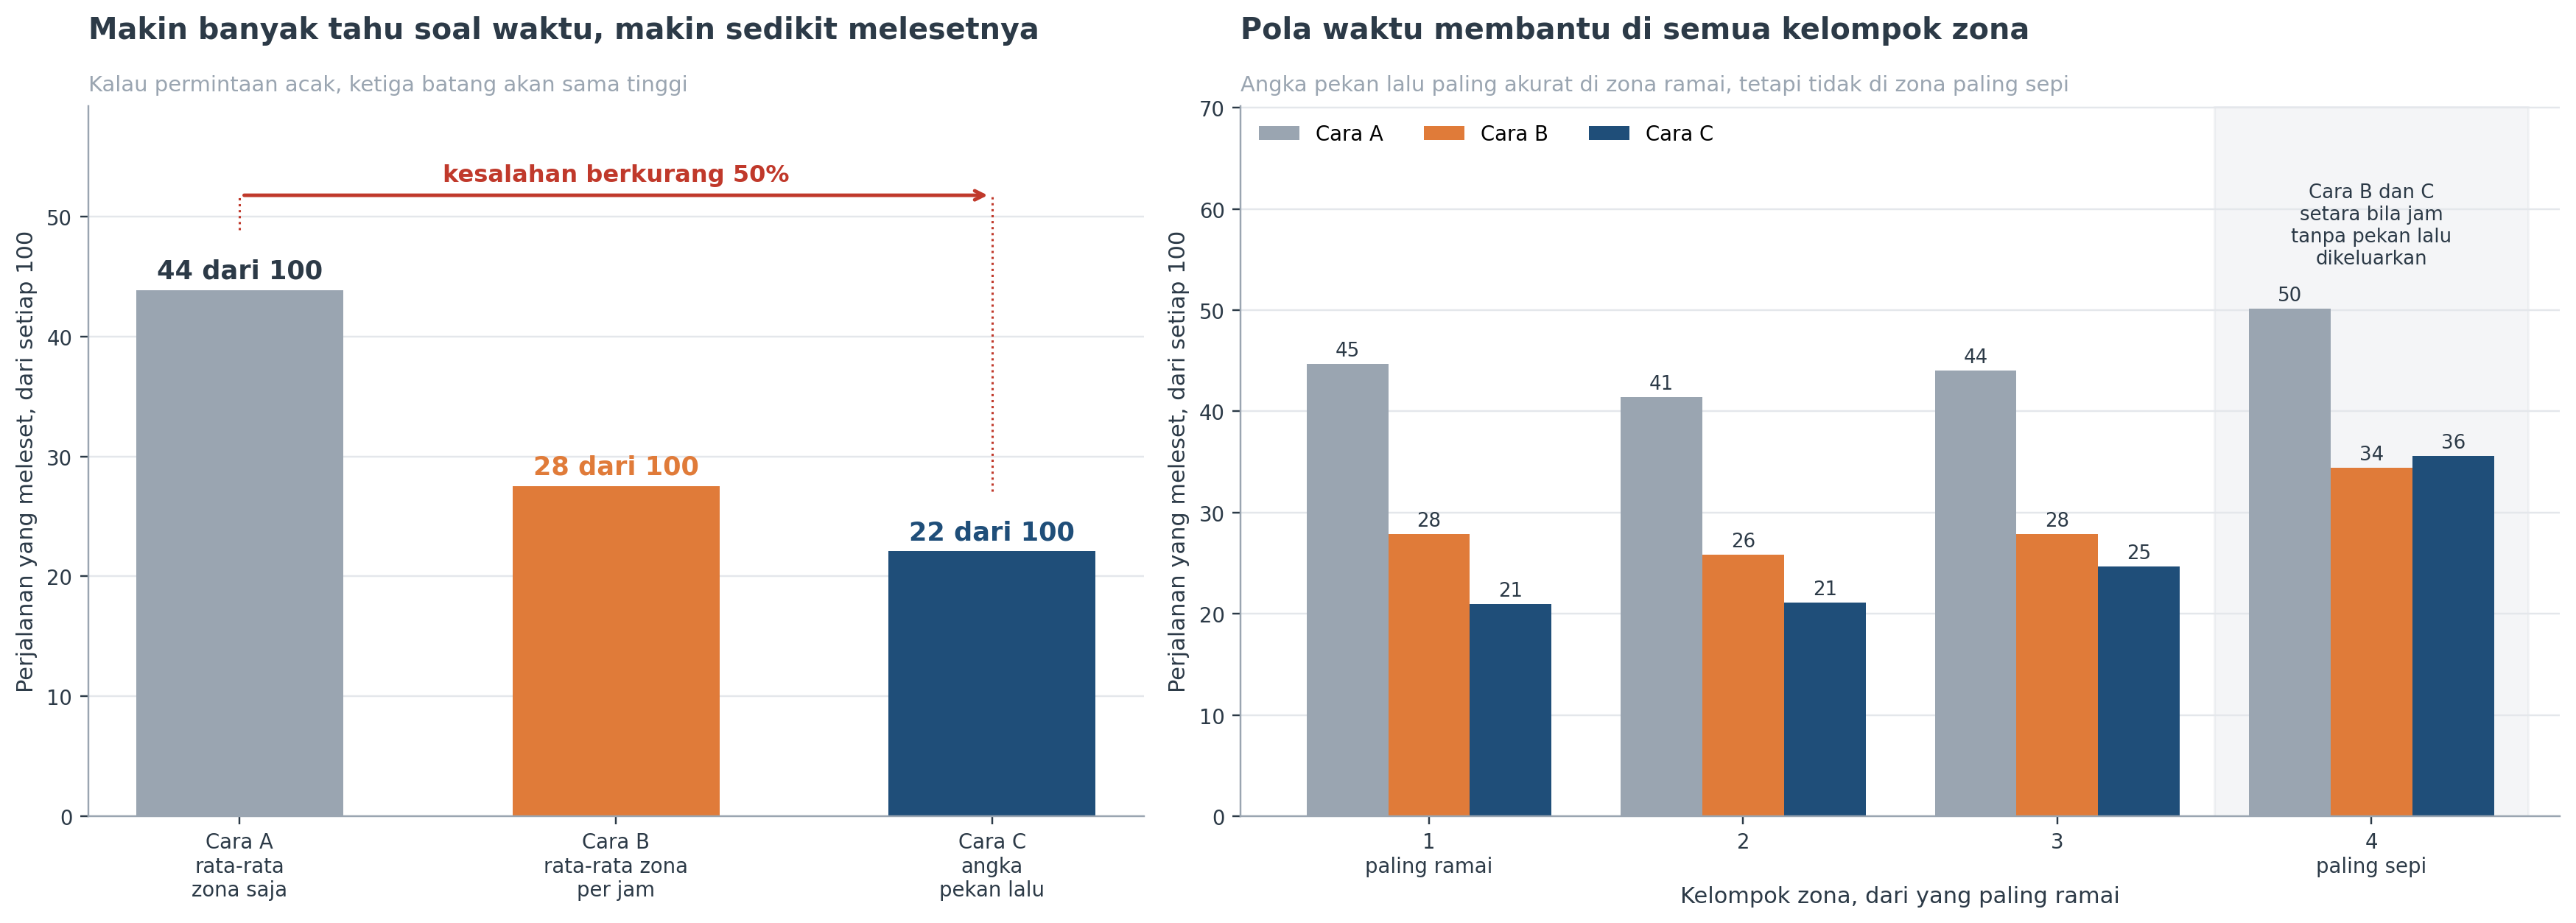

In [117]:
WARNA_CARA = [C["muted"], C["secondary"], C["primary"]]
NAMA_CARA  = ["Cara A\nrata-rata\nzona saja", "Cara B\nrata-rata zona\nper jam",
              "Cara C\nangka\npekan lalu"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8),
                         gridspec_kw={"width_ratios": [1, 1.25]})

# ---------- Kiri: seluruh zona ----------
ax = axes[0]
vals = np.array([wa, wb, wc]) * 100
ax.bar(NAMA_CARA, vals, color=WARNA_CARA, width=0.55)
for i, v in enumerate(vals):
    ax.text(i, v + 1, f"{v:.0f} dari 100", ha="center", fontsize=11.5,
            fontweight="bold", color=WARNA_CARA[i] if i else C["text"])

y_panah = vals.max() * 1.18
ax.annotate("", xy=(2, y_panah), xytext=(0, y_panah),
            arrowprops=dict(arrowstyle="->", color=C["alert"], linewidth=1.6))
ax.plot([0, 0], [vals[0] + 5, y_panah], color=C["alert"], linewidth=1, linestyle=":")
ax.plot([2, 2], [vals[2] + 5, y_panah], color=C["alert"], linewidth=1, linestyle=":")
ax.text(1, y_panah + 1.2, f"kesalahan berkurang {(1 - wc / wa) * 100:.0f}%",
        ha="center", fontsize=10.5, color=C["alert"], fontweight="semibold")

ax.set_ylim(0, vals.max() * 1.35)
ax.set_ylabel("Perjalanan yang meleset, dari setiap 100")
titled(ax, "Makin banyak tahu soal waktu, makin sedikit melesetnya",
       "Kalau permintaan acak, ketiga batang akan sama tinggi")
clean_axes(ax)

# ---------- Kanan: per kelompok zona ----------
ax = axes[1]
lebar = 0.26
xk = np.arange(len(df_gate2_tier))
kolom = ["wmape_a", "wmape_b", "wmape_c"]
for j, (kol, colr, lbl) in enumerate(zip(kolom, WARNA_CARA, ["Cara A", "Cara B", "Cara C"])):
    v = df_gate2_tier[kol].values * 100
    ax.bar(xk + (j - 1) * lebar, v, width=lebar, color=colr, label=lbl)
    for xi, vi in zip(xk + (j - 1) * lebar, v):
        ax.text(xi, vi + 0.8, f"{vi:.0f}", ha="center", fontsize=8.5, color=C["text"])

# Tandai kelompok zona paling sepi
y_max = df_gate2_tier[kolom].values.max() * 100
k_sepi = len(xk) - 1
ax.axvspan(k_sepi - 0.5, k_sepi + 0.5, color=C["muted"], alpha=0.10, zorder=0)
ax.text(k_sepi, y_max * 1.08, "Cara B dan C\nsetara bila jam\ntanpa pekan lalu\ndikeluarkan",
        ha="center", va="bottom", fontsize=8.5, color=C["text"])

ax.set_xticks(xk)
ax.set_xticklabels(["1\npaling ramai", "2", "3", "4\npaling sepi"])
ax.set_xlim(-0.6, len(xk) - 0.4)
ax.set_xlabel("Kelompok zona, dari yang paling ramai")
ax.set_ylabel("Perjalanan yang meleset, dari setiap 100")
ax.set_ylim(0, y_max * 1.4)
ax.legend(loc="upper left", ncol=3, fontsize=9)
titled(ax, "Pola waktu membantu di semua kelompok zona",
       "Angka pekan lalu paling akurat di zona ramai, tetapi tidak di zona paling sepi")
clean_axes(ax)

plt.tight_layout()
plt.show()

> **Cara membaca grafik dan tabel**

**Grafik panel kiri** — tiga cara menebak permintaan, diuji pada Januari–Mei 2026. Tinggi batang menunjukkan berapa perjalanan yang meleset dari setiap 100. Semakin pendek batang, semakin akurat tebakannya. Bila permintaan acak, ketiga batang akan sama tinggi karena tambahan informasi tidak membantu.

**Grafik panel kanan** — perbandingan yang sama, dipisah untuk empat kelompok zona berdasarkan keramaiannya. Setiap kelompok punya tiga batang: abu-abu Cara A, oranye Cara B, biru Cara C. Di grafik ini, jam yang tidak punya angka pekan lalu ditebak 0 oleh Cara C. Hal itu paling sering terjadi di zona paling sepi, sehingga batang biru di kelompok itu tampak lebih tinggi dari kenyataannya.

**Tabel per pekan** — Cara B dan Cara C dibandingkan ulang setiap pekan, hanya pada jam yang punya angka pekan lalu, agar adil bagi Cara C.

| Kolom | Artinya |
|---|---|
| Jumlah pekan | Banyaknya pekan dalam Januari–Mei 2026 |
| Rata-rata selisih | Kesalahan Cara C dikurangi Cara B, per 100 perjalanan. Negatif berarti Cara C lebih akurat |
| C menang | Pekan ketika Cara C lebih akurat minimal 1 poin |
| Setara | Pekan ketika selisihnya kurang dari 1 poin |
| C kalah | Pekan ketika Cara C kurang akurat minimal 1 poin |

Batas 1 poin dipilih sebagai batas manfaat praktis: selisih di bawahnya terlalu kecil untuk memengaruhi penempatan armada. Batas ini pilihan analisis, bukan aturan baku.

> **Hasil Step 14 — apakah kesalahan tebakan berpola**

**Temuan 1 — Kesalahan berkurang separuh bila tebakan memakai pola waktu**

| Cara | Informasi yang dipakai | Meleset dari 100 | MAE | RMSE |
|---|---|---|---|---|
| A | Rata-rata zona saja | 44 | 26,0 | 46,0 |
| B | Rata-rata zona per jam | 28 | 16,3 | 31,3 |
| C | Angka pekan lalu | 22 | 13,1 | 26,4 |

Setiap tambahan informasi waktu membuat tebakan lebih akurat. Dari Cara A ke Cara C, kesalahan berkurang sekitar separuh, dari 44 menjadi 22 dari setiap 100 perjalanan. Bila permintaan acak, ketiga cara akan meleset kurang lebih sama.

**Temuan 2 — Pola jam memberi bantuan terbesar, pola hari menambah lagi**

Mengetahui jam berapa (Cara A ke Cara B) menurunkan kesalahan dari 44 menjadi 28 dari 100. Mengetahui hari dan kondisi terbaru melalui angka pekan lalu (Cara B ke Cara C) menurunkannya lagi menjadi 22. Cara C menangkap perbedaan antar hari, misalnya Sabtu yang berbeda dari hari kerja, yang tidak tertangkap oleh rata-rata per jam.

**Temuan 3 — Pola waktu membantu di semua kelompok zona**

| Kelompok zona | Cara A | Cara B | Cara C | Berkurang A→C |
|---|---|---|---|---|
| 1 — paling ramai | 45 | 28 | 21 | 53% |
| 2 | 41 | 26 | 21 | 49% |
| 3 | 44 | 28 | 25 | 44% |
| 4 — paling sepi | 50 | 34 | 36 | 29% |

Di semua kelompok, Cara A selalu paling meleset. Pola waktu membantu di zona ramai maupun sepi. Namun manfaatnya mengecil seiring zona makin sepi: kesalahan berkurang 53% di zona paling ramai, tetapi hanya 29% di zona paling sepi.

**Temuan 4 — Angka pekan lalu konsisten unggul di zona ramai, tetapi tidak di zona paling sepi**

Cara B dan Cara C dibandingkan ulang setiap pekan, hanya pada jam yang punya angka pekan lalu.

| Kelompok zona | C menang | Setara | C kalah | Rata-rata selisih |
|---|---|---|---|---|
| 1 — paling ramai | 21 dari 22 pekan | 0 | 1 | −6,8 poin |
| 2 | 20 | 1 | 1 | −4,7 poin |
| 3 | 18 | 2 | 2 | −3,1 poin |
| 4 — paling sepi | 10 | 4 | 8 | +0,6 poin |

Di kelompok 1 sampai 3, Cara C lebih akurat hampir setiap pekan, sehingga keunggulannya konsisten. Di kelompok paling sepi, Cara C menang di 10 pekan dan kalah di 8 pekan, dengan rata-rata selisih hanya 0,6 poin. Tidak ada cara yang jelas lebih baik di zona ini.

Selisih 34 dan 36 pada tabel Temuan 3 karena itu sebagian besar berasal dari jam yang tidak punya angka pekan lalu. Sebanyak 8,1% jam di zona paling sepi tidak punya pasangan pekan lalu, dibanding hanya 0,1–0,3% di kelompok lain. Pada jam-jam itu Cara C menebak 0.

**Kaitan dengan hipotesis**

| Hipotesis | Indikasi |
|---|---|
| H4 — rata-rata memadai untuk perencanaan | **Tidak memadai**: rata-rata meleset 28 dari 100, sementara cara sederhana yang memakai pola sudah menurunkannya menjadi 22 |
| Variasi permintaan punya pola yang dapat dipelajari | **Ya**: kesalahan berkurang di semua kelompok zona ketika informasi waktu ditambahkan |

**Batas yang dipakai**

Permintaan dianggap berpola bila kesalahan turun lebih dari 20% dari Cara A ke Cara C. Hasilnya turun 50%, jauh melewati batas itu, sehingga kesimpulan tidak bergantung pada pilihan batas. Pada uji per pekan, selisih di bawah 1 poin per 100 perjalanan dianggap setara. Kedua batas ini pilihan analisis, bukan aturan baku.

**Keterbatasan**

Jam tanpa perjalanan tidak tercatat dalam data, sehingga angka kesalahan ketiga cara lebih kecil dari kenyataan. Ketiga cara diuji pada data yang sama, sehingga perbandingannya tetap adil. Pekan pertama Januari 2026 tidak lengkap karena periode uji dimulai hari Kamis.

**Kesimpulan untuk langkah berikutnya**

Permintaan punya pola yang dapat dipelajari, sehingga pembuatan model perkiraan permintaan dibenarkan oleh bukti. Cara C meleset 22,1 dari setiap 100 perjalanan, dan angka ini menjadi batas yang wajib dikalahkan: model yang tidak lebih akurat dari cara sederhana ini tidak memberi manfaat.

Temuan 4 memberi arahan untuk model. Di zona ramai, angka terbaru paling membantu. Di zona paling sepi, angka terbaru tidak lebih baik dari rata-rata jangka panjang, dan banyak jam tidak punya angka pekan lalu sama sekali. Model perlu menangani zona sepi dengan hati-hati, dan hasilnya perlu dilaporkan per kelompok zona, bukan hanya untuk seluruh zona.

> **Keputusan:** kesalahan berkurang separuh dengan pola waktu · permintaan berpola, bukan acak · angka pekan lalu konsisten unggul di zona ramai, setara dengan rata-rata di zona paling sepi · model perkiraan permintaan dibenarkan · batas yang wajib dikalahkan: meleset 22,1 dari 100 · hasil model wajib dilaporkan per kelompok zona

---

# STEP 15 — Persiapan Data untuk Model

**Tujuan:** menyiapkan tiga keputusan yang dibutuhkan sebelum membangun model perkiraan permintaan: zona mana yang dimodelkan, bagaimana menangani jam tanpa perjalanan, dan bagaimana menangani pergantian jam musim panas.

**Kenapa diperlukan:** model dibangun per **seri**, yaitu satu kombinasi zona × provider. Seri yang terlalu sepi, jam yang tidak tercatat, dan jam yang hilang atau berulang saat pergantian musim akan membuat model belajar dari data yang tidak lengkap.

**Catatan pengelompokan:** langkah sebelumnya mengelompokkan **zona** (sekitar 66 zona per kelompok). Langkah ini mengelompokkan **seri zona × provider** (131 seri per kelompok), karena seri adalah satuan yang akan dimodelkan.

**Input:** `mart_hourly_demand`. Hanya satu query ringkas per seri dan satu query kecil untuk tanggal pergantian musim. Pemeriksaan lain dihitung dari hasil yang sudah ada, tanpa memindai tabel lagi.

**Expected output:**
1. Ringkasan 524 seri dan cakupan permintaan
2. Kelengkapan data: berapa jam tanpa perjalanan
3. Pemeriksaan pergantian jam musim panas
4. Grafik dan keputusan untuk model

**Cara interpretasi:**
- Semakin sedikit seri yang dibutuhkan untuk menjangkau sebagian besar permintaan, semakin kecil cakupan model yang diperlukan
- Semakin banyak jam tanpa perjalanan di suatu kelompok, semakin penting penanganan nilai nol
- Bila jam 02:00 hilang pada tanggal pergantian musim semi, waktu di data adalah waktu lokal New York

In [118]:
# ---------- Ringkasan per seri zona × provider ----------
sql = f"""
WITH zone_stats AS (
    SELECT
        pickup_location_id,
        provider,
        SUM(demand)                               AS total_demand,
        AVG(demand)                               AS mean_demand,
        STDDEV(demand)                            AS std_demand,
        SAFE_DIVIDE(STDDEV(demand), AVG(demand))  AS cv,
        COUNT(*)                                  AS n_cells,
        MAX(demand)                               AS max_demand
    FROM {MART_DEMAND}
    GROUP BY pickup_location_id, provider
)
SELECT
    *,
    NTILE(4) OVER (ORDER BY total_demand DESC) AS kelompok_seri
FROM zone_stats
ORDER BY total_demand DESC
"""

df_zone_stats = run_query(sql)
df_zone_stats["nama_zona"] = df_zone_stats["pickup_location_id"].map(nama)

# Jam kalender dalam periode data (dari Step 3, tanpa query baru)
N_JAM_KALENDER = int(df_monthly["n_days"].sum()) * 24

# Waktu di data adalah waktu lokal New York. Pada tiga tanggal pergantian
# musim semi, jam 02:00 dilompati sehingga tidak pernah terjadi.
N_JAM_DILOMPATI = 3
N_JAM = N_JAM_KALENDER - N_JAM_DILOMPATI

# Jam kosong tidak boleh negatif: beberapa seri punya catatan kecil
# di jam 02:00 yang dilompati, sehingga n_cells bisa sedikit melebihi N_JAM
df_zone_stats["jam_kosong"] = (N_JAM - df_zone_stats["n_cells"]).clip(lower=0)

print(f"Jumlah seri zona × provider : {len(df_zone_stats)}")
print(f"Jam kalender dalam periode  : {N_JAM_KALENDER:,}")
print(f"Jam yang benar-benar terjadi: {N_JAM:,}  (dikurangi {N_JAM_DILOMPATI} jam yang dilompati)")
df_zone_stats.head(10)[["pickup_location_id", "nama_zona", "provider", "total_demand",
                        "mean_demand", "cv", "n_cells", "jam_kosong"]] \
    .style.format({"total_demand": "{:,.0f}", "mean_demand": "{:,.1f}",
                   "cv": "{:.2f}", "n_cells": "{:,.0f}", "jam_kosong": "{:,.0f}"})

Rows returned : 524
Bytes billed  : 0.0000 GB
Jumlah seri zona × provider : 524
Jam kalender dalam periode  : 21,168
Jam yang benar-benar terjadi: 21,165  (dikurangi 3 jam yang dilompati)


,pickup_location_id,nama_zona,provider,total_demand,mean_demand,cv,n_cells,jam_kosong
0,138,LaGuardia Airport,Uber,"8,311,277",395.7,0.71,"21,006",159
1,132,JFK Airport,Uber,"7,606,576",359.4,0.53,"21,165",0
2,61,Crown Heights North,Uber,"5,499,816",259.9,0.46,"21,165",0
3,230,Times Sq/Theatre District,Uber,"5,384,396",254.6,0.53,"21,149",16
4,161,Midtown Center,Uber,"5,380,975",254.3,0.78,"21,164",1
5,79,East Village,Uber,"5,239,671",247.6,0.74,"21,165",0
6,231,TriBeCa/Civic Center,Uber,"4,809,938",227.3,0.58,"21,164",1
7,76,East New York,Uber,"4,789,150",226.3,0.44,"21,165",0
8,37,Bushwick South,Uber,"4,665,687",220.4,0.53,"21,165",0
9,234,Union Sq,Uber,"4,561,257",215.5,0.61,"21,164",1


In [119]:
# ---------- Ringkasan per kelompok seri dan cakupan ----------
ringkas_seri = (
    df_zone_stats.groupby("kelompok_seri")
    .agg(jumlah_seri   = ("pickup_location_id", "count"),
         total_demand  = ("total_demand", "sum"),
         rata_per_jam  = ("mean_demand", "mean"),
         cv_median     = ("cv", "median"),
         jam_kosong    = ("jam_kosong", "sum"),
         jam_mungkin   = ("n_cells", lambda s: len(s) * N_JAM))
)
ringkas_seri["porsi_permintaan"] = ringkas_seri["total_demand"] / ringkas_seri["total_demand"].sum() * 100
ringkas_seri["porsi_jam_kosong"] = ringkas_seri["jam_kosong"] / ringkas_seri["jam_mungkin"] * 100
ringkas_seri.index = ["1 — paling ramai", "2", "3", "4 — paling sepi"]
ringkas_seri.index.name = "Kelompok seri"

display(ringkas_seri[["jumlah_seri", "porsi_permintaan", "rata_per_jam",
                      "cv_median", "porsi_jam_kosong"]]
        .style.format({"porsi_permintaan": "{:.1f}%", "rata_per_jam": "{:,.1f}",
                       "cv_median": "{:.2f}", "porsi_jam_kosong": "{:.1f}%"}))

# Berapa seri dibutuhkan untuk menjangkau porsi permintaan tertentu
urut = df_zone_stats.sort_values("total_demand", ascending=False)
kumulatif = urut["total_demand"].cumsum() / urut["total_demand"].sum() * 100
korelasi = df_zone_stats[["total_demand", "cv"]].corr(method="spearman").iloc[0, 1]
print(f"Korelasi Spearman jumlah permintaan dan CV : {korelasi:.2f}")
print("Negatif berarti seri yang lebih ramai cenderung lebih stabil.")

print("\nCakupan permintaan:")
for target in [80, 90, 95, 99]:
    n = int((kumulatif < target).sum()) + 1
    print(f"  {target}% permintaan : {n:>3} seri teratas dari {len(urut)}")

,jumlah_seri,porsi_permintaan,rata_per_jam,cv_median,porsi_jam_kosong
Kelompok seri,,,,,
1 — paling ramai,131,61.2%,130.1,0.51,0.0%
2,131,24.5%,52.1,0.51,0.0%
3,131,11.3%,24.1,0.54,0.3%
4 — paling sepi,131,3.0%,6.9,0.62,22.9%


Korelasi Spearman jumlah permintaan dan CV : -0.35
Negatif berarti seri yang lebih ramai cenderung lebih stabil.

Cakupan permintaan:
  80% permintaan : 224 seri teratas dari 524
  90% permintaan : 300 seri teratas dari 524
  95% permintaan : 360 seri teratas dari 524
  99% permintaan : 438 seri teratas dari 524


In [120]:
# ---------- Kelengkapan data ----------
mungkin = len(df_zone_stats) * N_JAM
kosong  = int(df_zone_stats["jam_kosong"].sum())

print("KELENGKAPAN DATA")
print(f"  Seri zona × provider              : {len(df_zone_stats)}")
print(f"  Jam yang benar-benar terjadi      : {N_JAM:,}")
print(f"  Kombinasi jam × seri yang mungkin : {mungkin:,}")
print(f"  Jam tanpa perjalanan              : {kosong:,} ({kosong / mungkin * 100:.1f}%)")

per_kelompok = df_zone_stats.groupby("kelompok_seri")["jam_kosong"].sum()
print("\n  Jam tanpa perjalanan per kelompok seri:")
for k, v in per_kelompok.items():
    print(f"    Kelompok {k} : {v:>9,} jam ({v / kosong * 100:4.1f}% dari seluruh jam kosong)")

KELENGKAPAN DATA
  Seri zona × provider              : 524
  Jam yang benar-benar terjadi      : 21,165
  Kombinasi jam × seri yang mungkin : 11,090,460
  Jam tanpa perjalanan              : 643,879 (5.8%)

  Jam tanpa perjalanan per kelompok seri:
    Kelompok 1 :       879 jam ( 0.1% dari seluruh jam kosong)
    Kelompok 2 :       637 jam ( 0.1% dari seluruh jam kosong)
    Kelompok 3 :     7,128 jam ( 1.1% dari seluruh jam kosong)
    Kelompok 4 :   635,235 jam (98.7% dari seluruh jam kosong)


In [121]:
# ---------- Pergantian jam musim panas (DST) ----------
TGL_SEMI  = ["2024-03-10", "2025-03-09", "2026-03-08"]   # jam 02:00 dilompati
TGL_GUGUR = ["2024-11-03", "2025-11-02"]                 # jam 01:00 terjadi dua kali
tanggal = ", ".join(f"DATE '{t}'" for t in TGL_SEMI + TGL_GUGUR)

sql = f"""
SELECT request_date, hour, SUM(demand) AS demand
FROM {MART_DEMAND}
WHERE request_date IN ({tanggal})
  AND hour BETWEEN 0 AND 4
GROUP BY request_date, hour
ORDER BY request_date, hour
"""

df_dst = run_query(sql)
tabel_dst = df_dst.pivot(index="request_date", columns="hour", values="demand")
tabel_dst.columns = [f"{h:02d}:00" for h in tabel_dst.columns]
tabel_dst.index = [f"{d} ({'musim semi' if str(d) in TGL_SEMI else 'musim gugur'})"
                   for d in tabel_dst.index]

seri_penuh = int((df_zone_stats["n_cells"] >= N_JAM).sum())
print(f"Seri tercatat di seluruh {N_JAM:,} jam yang benar-benar terjadi : {seri_penuh} dari {len(df_zone_stats)}\n")

semi  = tabel_dst[tabel_dst.index.str.contains("semi")]
gugur = tabel_dst[tabel_dst.index.str.contains("gugur")]
print(f"Musim semi, jam 02:00 : {semi['02:00'].min():,.0f}–{semi['02:00'].max():,.0f} perjalanan "
      f"(jam 01:00 sekitar {semi['01:00'].mean():,.0f})")
print(f"Musim gugur, jam 01:00 : {gugur['01:00'].min():,.0f}–{gugur['01:00'].max():,.0f} perjalanan "
      f"(jam 00:00 sekitar {gugur['00:00'].mean():,.0f})")
print("\nKesimpulan: jam 02:00 musim semi hampir kosong dan jam 01:00 musim gugur menumpuk,")
print("sehingga waktu di data adalah waktu lokal New York.\n")

tabel_dst.style.format("{:,.0f}", na_rep="tidak ada")

Rows returned : 25
Bytes billed  : 0.0000 GB
Seri tercatat di seluruh 21,165 jam yang benar-benar terjadi : 150 dari 524

Musim semi, jam 02:00 : 3–4 perjalanan (jam 01:00 sekitar 33,608)
Musim gugur, jam 01:00 : 62,448–73,456 perjalanan (jam 00:00 sekitar 46,678)

Kesimpulan: jam 02:00 musim semi hampir kosong dan jam 01:00 musim gugur menumpuk,
sehingga waktu di data adalah waktu lokal New York.



,00:00,01:00,02:00,03:00,04:00
2024-03-10 (musim semi),"40,355","33,007",4,"26,554","18,368"
2024-11-03 (musim gugur),"43,765","62,448","20,759","16,085","13,512"
2025-03-09 (musim semi),"40,768","33,740",3,"26,859","18,513"
2025-11-02 (musim gugur),"49,592","73,456","25,020","20,153","17,156"
2026-03-08 (musim semi),"42,416","34,077",4,"27,682","18,802"


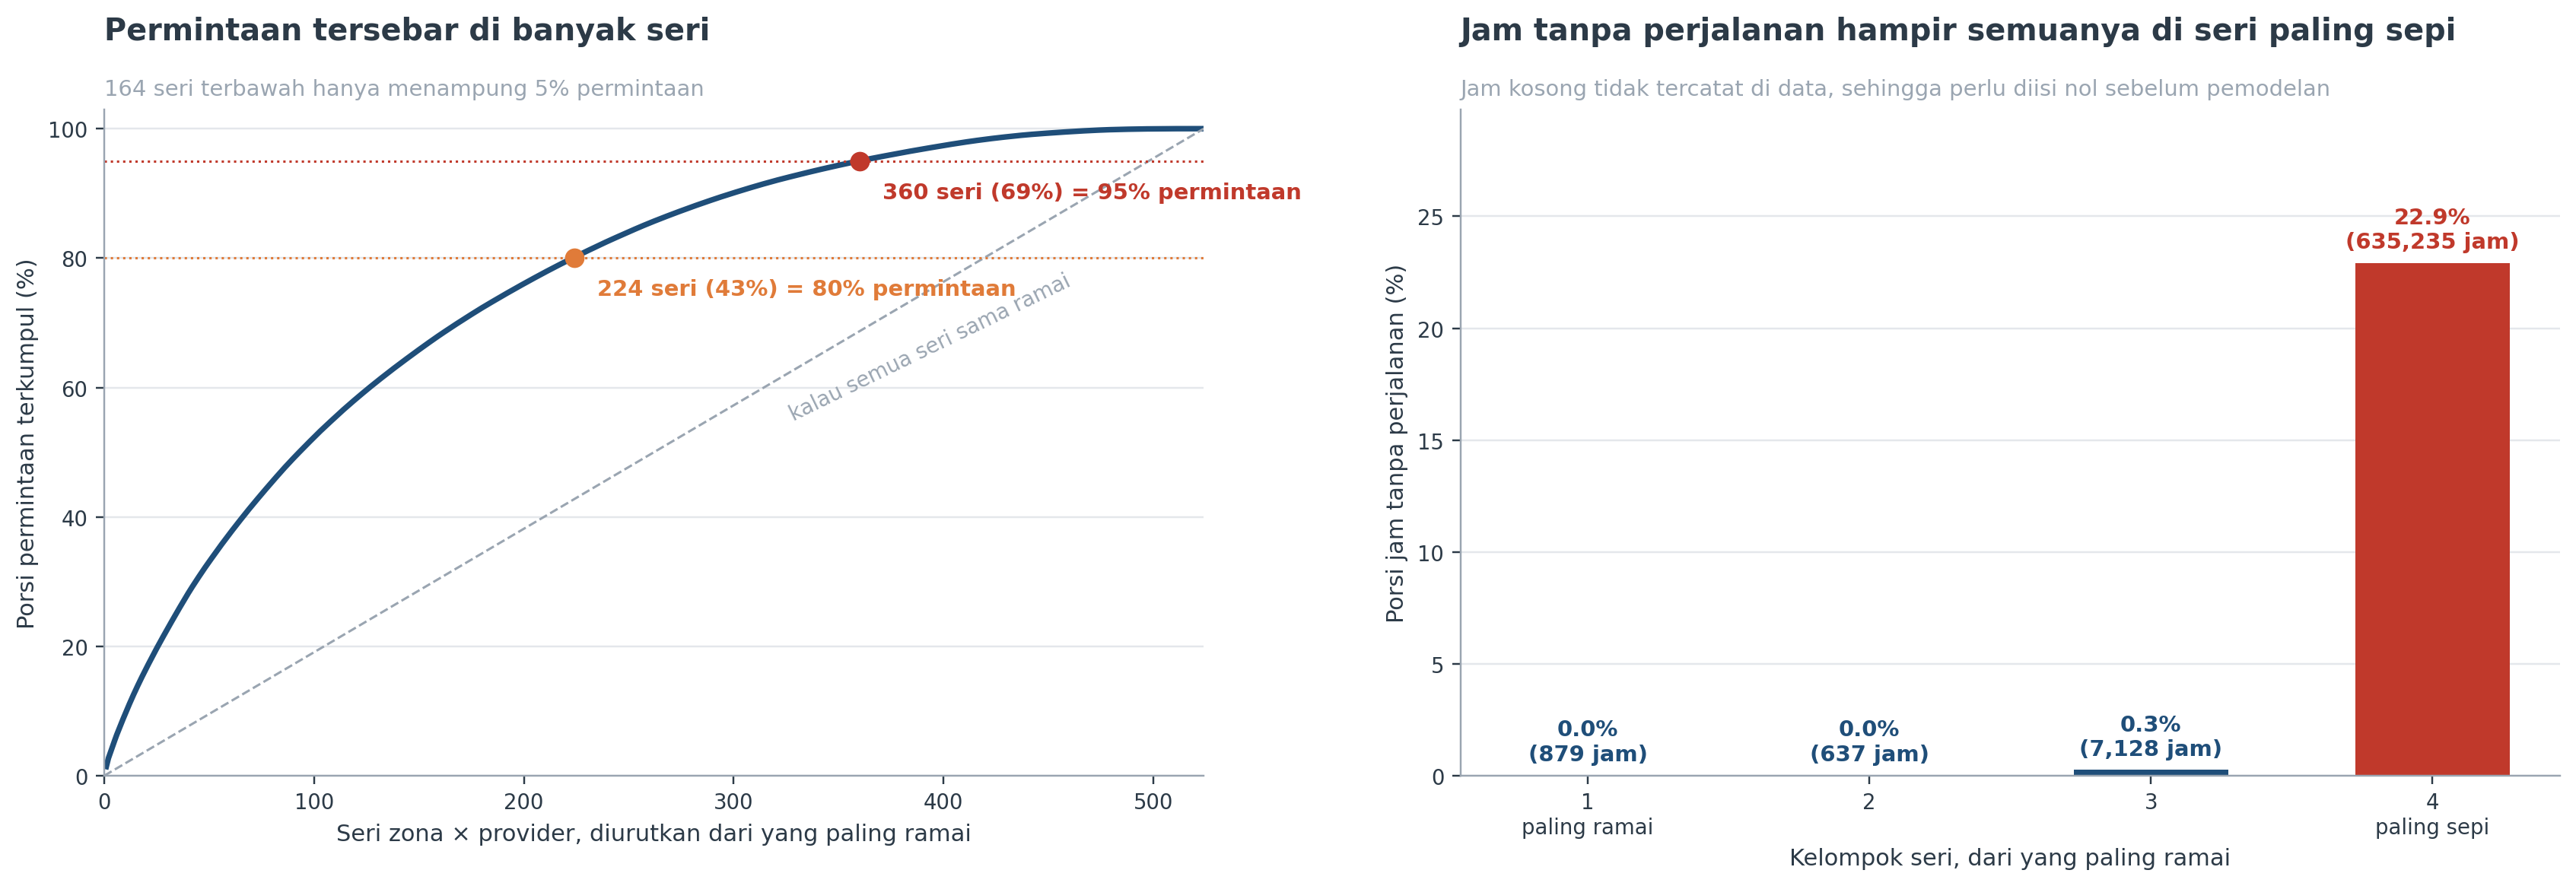

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4))

# Kiri: cakupan permintaan
ax = axes[0]
xs = np.arange(1, len(kumulatif) + 1)
ax.plot(xs, kumulatif.values, color=C["primary"], linewidth=2.4)
ax.plot([0, len(xs)], [0, 100], color=C["muted"], linestyle="--", linewidth=1)
ax.text(len(xs) * 0.62, 55, "kalau semua seri sama ramai", color=C["muted"],
        fontsize=9, rotation=26)
for target, colr in [(80, C["secondary"]), (95, C["alert"])]:
    n = int((kumulatif < target).sum()) + 1
    ax.axhline(target, color=colr, linestyle=":", linewidth=1)
    ax.scatter([n], [target], s=55, color=colr, zorder=5)
    ax.annotate(f"{n} seri ({n / len(xs) * 100:.0f}%) = {target}% permintaan",
                xy=(n, target), xytext=(10, -16), textcoords="offset points",
                fontsize=9.5, color=colr, fontweight="semibold")
n95 = int((kumulatif < 95).sum()) + 1
ax.set_xlim(0, len(kumulatif))
ax.set_ylim(0, 103)
ax.set_xlabel("Seri zona × provider, diurutkan dari yang paling ramai")
ax.set_ylabel("Porsi permintaan terkumpul (%)")
titled(ax, "Permintaan tersebar di banyak seri",
       f"{len(xs) - n95} seri terbawah hanya menampung 5% permintaan")
clean_axes(ax)

# Kanan: jam tanpa perjalanan per kelompok seri
ax = axes[1]
lbl = ["1\npaling ramai", "2", "3", "4\npaling sepi"]
v = ringkas_seri["porsi_jam_kosong"].values
n_kosong = df_zone_stats.groupby("kelompok_seri")["jam_kosong"].sum().values
warna = [C["alert"] if x == v.max() else C["primary"] for x in v]
ax.bar(lbl, v, color=warna, width=0.55)
for i, (x, nk) in enumerate(zip(v, n_kosong)):
    ax.text(i, x + v.max() * 0.02, f"{x:.1f}%\n({nk:,.0f} jam)", ha="center",
            va="bottom", fontsize=9.5, fontweight="bold", color=warna[i])
ax.set_ylim(0, v.max() * 1.3)
ax.set_xlabel("Kelompok seri, dari yang paling ramai")
ax.set_ylabel("Porsi jam tanpa perjalanan (%)")
titled(ax, "Jam tanpa perjalanan hampir semuanya di seri paling sepi",
       "Jam kosong tidak tercatat di data, sehingga perlu diisi nol sebelum pemodelan")
clean_axes(ax)

plt.tight_layout()
plt.show()

> **Cara membaca grafik dan tabel**

**Tabel kelompok seri** — 524 seri zona × provider dibagi empat kelompok berdasarkan jumlah permintaannya, masing-masing 131 seri.

| Kolom | Artinya |
|---|---|
| Porsi permintaan | Bagian seluruh perjalanan yang terjadi di kelompok itu |
| Rata-rata per jam | Rata-rata perjalanan per jam di satu seri |
| CV median | Seberapa naik-turun permintaan dari jam ke jam. 0,5 berarti naik-turunnya sekitar separuh dari rata-ratanya; makin besar, makin sulit ditebak |
| Porsi jam kosong | Persen jam di kelompok itu yang tidak punya satu perjalanan pun |

**Grafik kiri** — seri diurutkan dari yang paling ramai. Garis biru menunjukkan porsi permintaan yang sudah terjangkau. Garis putus-putus abu-abu adalah kondisi bila semua seri sama ramainya; semakin jauh garis biru di atasnya, semakin menumpuk permintaan di seri-seri teratas. Titik oranye dan merah menandai berapa seri yang dibutuhkan untuk menjangkau 80% dan 95% permintaan.

**Grafik kanan** — porsi jam tanpa perjalanan di tiap kelompok seri. Angka dalam kurung adalah jumlah jamnya. Jam seperti ini tidak tercatat sebagai 0, melainkan tidak muncul di data sama sekali.

**Tabel pergantian musim** — jumlah perjalanan pada jam 00:00–04:00 di tanggal pergantian jam musim panas.
- Pada tanggal musim semi, jam 02:00 dilompati. Bila jam itu hampir kosong, waktu di data adalah waktu lokal New York.
- Pada tanggal musim gugur, jam 01:00 terjadi dua kali. Bila jam itu jauh lebih ramai dari jam 00:00, dua jam tergabung dalam satu baris.

> **Hasil Step 15 — persiapan data untuk model**

**Temuan 1 — Permintaan tersebar di banyak seri**

| Kelompok seri | Porsi permintaan | Rata-rata per jam | CV median |
|---|---|---|---|
| 1 — paling ramai | 61,2% | 130,1 | 0,51 |
| 2 | 24,5% | 52,1 | 0,51 |
| 3 | 11,3% | 24,1 | 0,54 |
| 4 — paling sepi | 3,0% | 6,9 | 0,62 |

| Cakupan permintaan | Seri yang dibutuhkan |
|---|---|
| 80% | 224 dari 524 seri (43%) |
| 90% | 300 seri (57%) |
| 95% | 360 seri (69%) |
| 99% | 438 seri (84%) |

Permintaan tidak menumpuk di sedikit seri. Untuk menjangkau 95% permintaan dibutuhkan 360 seri. Sebaliknya, 164 seri terbawah hanya menampung 5% permintaan.

Seri besar sedikit lebih stabil daripada seri kecil (korelasi Spearman volume dan CV −0,35), tetapi kelompok 1 sampai 3 hampir sama (CV median 0,51–0,54). Hal ini sejalan dengan hasil pengujian sebelumnya: zona ramai tidak lebih mudah ditebak daripada zona sedang.

**Temuan 2 — Jam tanpa perjalanan hampir semuanya di seri paling sepi**

| Kelompok seri | Jam tanpa perjalanan | Porsi dari jam kelompok itu |
|---|---|---|
| 1 — paling ramai | 879 | 0,0% |
| 2 | 637 | 0,0% |
| 3 | 7.128 | 0,3% |
| 4 — paling sepi | 635.235 | 22,9% |
| **Seluruh seri** | **643.879** | **5,8%** |

Kelompok paling sepi menampung 98,7% seluruh jam kosong. Di kelompok ini hampir 1 dari 4 jam tidak punya perjalanan sama sekali, sedangkan di tiga kelompok lain hampir setiap jam punya perjalanan. Jam kosong tidak tercatat sebagai 0 di data, melainkan tidak muncul.

Seri teramai pun tidak selalu lengkap: LaGuardia Airport untuk Uber tidak punya perjalanan pada 159 jam. Dari 524 seri, hanya 150 yang tercatat di setiap jam.

**Temuan 3 — Waktu di data adalah waktu lokal New York**

| Tanggal | Jam 00:00 | Jam 01:00 | Jam 02:00 |
|---|---|---|---|
| Musim semi (10 Mar 2024, 9 Mar 2025, 8 Mar 2026) | ± 41 ribu | ± 34 ribu | 3–4 perjalanan |
| Musim gugur (3 Nov 2024, 2 Nov 2025) | ± 47 ribu | 62–73 ribu | 21–25 ribu |

Pada tanggal musim semi, jam 02:00 hampir kosong karena jam itu dilompati. Pada tanggal musim gugur, jam 01:00 terjadi dua kali sehingga perjalanannya menumpuk jauh di atas jam 00:00. Walaupun kolom `request_hour` tertulis `+00:00`, isinya adalah waktu lokal New York. Periode data karena itu berisi 21.165 jam yang benar-benar terjadi, bukan 21.168.

**Keputusan untuk model**

| Keputusan | Pilihan | Dasar |
|---|---|---|
| Cakupan seri | 360 seri yang menampung 95% permintaan; 164 seri sisanya ditebak dengan cara sederhana | Seri terbawah hanya 5% permintaan dan menampung hampir semua jam kosong |
| Jam tanpa perjalanan | Grid jam lengkap per seri, jam kosong diisi 0 | 643.879 jam tidak tercatat; tanpa diisi, fitur 24 dan 168 jam sebelumnya bergeser |
| Pergantian musim | Waktu diperlakukan sebagai waktu lokal; jam yang dilompati tidak dibuat, jam berulang tetap satu baris | Jam 02:00 musim semi hampir kosong, jam 01:00 musim gugur menumpuk |
| Pelaporan | Kesalahan model dilaporkan per kelompok seri | Kelompok 1 menampung 61% permintaan sehingga mendominasi angka keseluruhan |

**Keterbatasan**

Batas 95% adalah pilihan analisis, bukan aturan baku. Pada jam 02:00 tanggal musim semi tercatat 3–4 perjalanan, padahal jam itu tidak terjadi; kemungkinan kesalahan pencatatan yang sangat kecil dan tidak memengaruhi kesimpulan. Pada jam 01:00 musim gugur, dua jam yang berbeda tergabung dalam satu baris, sehingga jumlahnya tampak jauh lebih tinggi.

> **Keputusan:** model mencakup 360 seri (95% permintaan) · jam kosong diisi 0 · waktu diperlakukan sebagai waktu lokal New York dengan 21.165 jam · kesalahan dilaporkan per kelompok seri

---

# STEP 16 — Ringkasan Pengujian Hipotesis

Status ditentukan dengan kriteria yang ditulis di bagian 0.5 sebelum pengujian.

| # | Hipotesis | Status | Bukti utama |
|---|---|---|---|
| H1 | Permintaan cukup terkonsentrasi di sedikit zona | **Gugur** | Sepuluh zona teratas hanya 12,9% permintaan; 58 zona untuk separuh permintaan |
| H2 | Satu pola jam berlaku untuk seluruh kota | **Gugur** | Tiga kelompok zona dengan jam puncak pagi, sore, dan malam; puncak pagi hanya di hari kerja |
| H3 | Kedua provider bergerak searah sehingga cukup direncanakan bersama | **Gugur sebagian** | Pangsa seragam antar zona (bertahan), tetapi bergeser dari waktu ke waktu: porsi Uber turun di 93% zona (gugur) |
| H4 | Rata-rata historis memadai untuk perencanaan | **Gugur** | Rata-rata paling rinci meleset 28 dari 100; cara sederhana berpola meleset 22 dari 100 |
| H5 | Pendapatan pengemudi tergerus | **Gugur** | Bayaran per menit naik 7,6% |
| H6 | Kenaikan tarif bersifat moderat | **Gugur** | Harga per mil naik 11,5%, jauh di atas tarif per perjalanan 7,2% |
| H7 | Kemacetan menjelaskan perubahan lama perjalanan | **Bertahan sebagian** | Kecepatan turun 3,3%, tetapi hanya di 2026; lama perjalanan hampir tetap karena jarak juga turun |

**Hipotesis tambahan yang muncul selama analisis**

| Hipotesis | Status | Bukti utama |
|---|---|---|
| Akhir pekan = Sabtu dan Minggu | **Gugur** | Jumat–Sabtu memisahkan hari ramai lebih tajam (+19,7% vs +11,5%) |
| Pemendekan perjalanan adalah perubahan nyata | **Bertahan** | 60% karena perilaku di dalam zona, terjadi di 80% zona |
| Asal dan tujuan seimbang di tiap zona | **Gugur** | Stasiun dan bandara menerima hingga 22% lebih banyak dari yang dikirim |
| Minat berbagi tumpangan stabil | **Gugur** | Peminat Uber turun dari 5,1 menjadi 2,5 per 100 perjalanan |
| Variasi permintaan punya pola yang dapat dipelajari | **Bertahan** | Kesalahan berkurang separuh dengan informasi waktu |

Hipotesis yang gugur bukan kegagalan analisis. Setiap hipotesis yang gugur menunjukkan anggapan perencanaan yang tidak didukung data.

---

# STEP 17 — Temuan Utama dan Pendukung

## Temuan utama

> **Rata-rata yang terlihat stabil menyembunyikan gerakan yang berlawanan, dan pada tingkat zona dan jam — tempat keputusan armada diambil — rata-rata meleset sekitar 28 dari setiap 100 perjalanan.**

Mekanisme yang sama muncul berulang di setiap lapisan data:

| Lapisan | Yang terlihat di angka rata-rata | Yang sebenarnya terjadi |
|---|---|---|
| Bulan | Februari selalu turun | Permintaan harian Februari justru naik; hanya jumlah harinya lebih sedikit |
| Harga | Tarif per perjalanan naik 7,2% | Harga per mil naik 11,5%; perjalanan makin pendek menutupinya |
| Hari | Satu angka harian | Sabtu 36% lebih ramai dari Senin |
| Jam | Satu kurva kota | Hanya cocok untuk kelompok sore; salah untuk zona pagi dan malam |
| Zona dan jam | Rata-rata zona per jam | Meleset 28 dari 100; cara sederhana yang memakai pola hari meleset 22 |

## Temuan pendukung

| # | Temuan | Bukti |
|---|---|---|
| 1 | Permintaan tumbuh, dan pertumbuhannya mempercepat | +5,9% dalam dua tahun; laju tahunan naik dari +1,0% menjadi +4,9% sejak Oktober 2025 |
| 2 | Tebakan rata-rata tertinggal dari pertumbuhan | Total tebakan 5,9% di bawah kenyataan pada Januari–Mei 2026 |
| 3 | Perjalanan memendek secara menyeluruh | Jarak turun 4,0% (Januari–Mei), 60% karena perilaku di dalam zona, di 80% zona |
| 4 | Akhir pekan ride-hailing adalah Jumat–Sabtu | Malam Jumat dan Sabtu 2,3–2,6 kali lebih ramai dari malam hari kerja |
| 5 | Stasiun dan bandara mengumpulkan mobil | Penn Station dan JFK menerima 22% lebih banyak dari yang dikirim |
| 6 | Peminat berbagi tumpangan turun separuh | 94% karena perubahan perilaku, bukan komposisi provider |
| 7 | Porsi Lyft naik secara merata | Porsi Uber turun di 243 dari 261 zona |

---

# STEP 18 — Rekomendasi

Setiap rekomendasi menyebut dasar bukti, langkah, ukuran keberhasilan, dan yang bukan ukuran keberhasilan.

## 01 — Rencanakan armada dengan perkiraan per zona dan jam, bukan rata-rata

| Aspek | Isi |
|---|---|
| Dasar bukti | Rata-rata zona per jam meleset 28 dari 100; angka pekan lalu saja sudah menurunkannya menjadi 22 |
| Langkah | Bangun model perkiraan permintaan per zona × provider × jam, dimulai dari 360 seri yang menampung 95% permintaan |
| Ukuran keberhasilan | Kesalahan lebih kecil dari 22,1 per 100 perjalanan, pada seluruh seri dan di setiap kelompok seri |
| **Bukan** ukuran keberhasilan | Kesalahan keseluruhan saja, karena kelompok paling ramai menampung 61% permintaan dan mendominasi angka itu |

## 02 — Bedakan hari dan kelompok zona dalam perencanaan

| Aspek | Isi |
|---|---|
| Dasar bukti | Jumat–Sabtu berbeda dari hari lain; zona terbagi menjadi kelompok pagi, sore, dan malam |
| Langkah | Gunakan hari dalam pekan dan kelompok zona sebagai bagian dari perkiraan, bukan penanda akhir pekan Sabtu–Minggu |
| Ukuran keberhasilan | Kesalahan pada Sabtu dan pada zona kelompok malam turun paling besar |
| **Bukan** ukuran keberhasilan | Kesalahan rata-rata seluruh hari |

## 03 — Perhitungkan arah perpindahan mobil

| Aspek | Isi |
|---|---|
| Dasar bukti | Stasiun dan bandara menerima hingga 22% lebih banyak penumpang daripada yang dikirim |
| Langkah | Baca perkiraan permintaan bersama arah perpindahan mobil antar zona |
| Ukuran keberhasilan | Penempatan armada yang memperhitungkan zona pengirim dan penerima |
| **Bukan** ukuran keberhasilan | Jumlah pickup di zona penerima saja |

---

# STEP 19 — Batas Kesimpulan

| Batas | Konsekuensi |
|---|---|
| Yang tercatat hanya perjalanan yang terlaksana | Permintaan yang dibatalkan atau tidak mendapat pengemudi tidak terlihat |
| Tidak ada data ketersediaan pengemudi | Project tidak dapat menyimpulkan kekurangan atau kelebihan armada |
| `base_passenger_fare` bukan pendapatan perusahaan | Selisih tarif dan bayaran pengemudi bukan margin |
| Data sudah dirangkum per zona dan jam | Analisis per perjalanan individual tidak dimungkinkan |
| Hubungan bersifat keterkaitan | Kesimpulan ditulis sebagai "sejalan dengan", bukan "disebabkan oleh" |
| Jam tanpa perjalanan tidak tercatat | Angka kesalahan tebakan adalah batas bawah |
| Waktu di data adalah waktu lokal New York | Tanggal pergantian musim panas perlu ditangani sebelum pemodelan |
| Periode uji jatuh pada fase pertumbuhan cepat | Sebagian kesalahan tebakan rata-rata berasal dari tren yang tidak tertangkap |
| Data 2026 hanya sampai Mei | Perbandingan 2026 hanya memakai Januari–Mei; musim sepi 2026 belum terlihat |
| Lyft hampir tidak mencatat permintaan berbagi tumpangan | Analisis berbagi tumpangan hanya memakai Uber |
| Zona 264 dan 265 bukan lokasi nyata | Dikeluarkan dari peringkat tujuan |
| Maret 2025 janggal di beberapa metrik | Dicatat sebagai kejanggalan, penyebabnya belum diuji |
| Batas 20%, 1 poin, dan 95% adalah pilihan analisis | Ditulis terbuka; kesimpulan utama tidak bergantung pada pilihan batas |

---

# STEP 20 — Serah Terima ke Tahap Model

## Pembanding dan pelaporan

| Dari analisis | Nilai | Dipakai untuk |
|---|---|---|
| Batas yang wajib dikalahkan | Meleset 22,1 dari 100 (angka pekan lalu) | Pembanding setiap model |
| Pembanding menengah | Meleset 27,5 dari 100 (rata-rata zona per jam) | Memastikan model mengalahkan cara sederhana |
| Pelaporan | Per kelompok seri, bukan hanya keseluruhan | Kelompok paling ramai menampung 61% permintaan dan dapat menutupi kegagalan di kelompok sepi |

## Persiapan data

| Dari analisis | Nilai | Dipakai untuk |
|---|---|---|
| Cakupan seri | 360 dari 524 seri, menampung 95% permintaan | Seri yang dimodelkan; 164 seri sisanya ditebak dengan cara sederhana |
| Jam tanpa perjalanan | 643.879 jam (5,8%), 98,7% di kelompok paling sepi | Grid jam lengkap per seri, jam kosong diisi 0 |
| Zona waktu | Waktu lokal New York, 21.165 jam dalam periode data | Jam 02:00 musim semi tidak dibuat; jam 01:00 musim gugur tetap satu baris |

## Pola yang perlu ditangkap model

| Dari analisis | Nilai | Dipakai untuk |
|---|---|---|
| Pola waktu | Jam, hari dalam pekan, Jumat–Sabtu, malam lewat tengah malam | Fitur waktu |
| Pola zona | Kelompok zona pagi, sore, malam | Interaksi zona dan jam |
| Tren | +5,9% dalam dua tahun, mempercepat sejak Oktober 2025; rata-rata masa lalu menebak 5,9% terlalu rendah | Model wajib menangkap tren, bukan hanya musim |
| Provider | Pembagian seragam antar zona, porsi Lyft naik di 93% zona | Satu model dengan penanda provider, rasio tidak dianggap tetap |
| Zona sepi | Angka pekan lalu tidak lebih baik dari rata-rata di kelompok paling sepi | Perataan beberapa pekan di seri sepi |

## Keputusan yang masih harus diambil di tahap model

**Jarak waktu perkiraan.** Fitur 1 jam sebelumnya tidak dapat dipakai bila perkiraan dibuat beberapa hari ke depan. Jarak waktu perkiraan perlu ditentukan lebih dulu sebelum memilih fitur.

**Maret 2025.** Kejanggalan pada bulan ini perlu diperiksa sebelum dipakai sebagai data latih.

---

# CATATAN EKSEKUSI

**Urutan menjalankan notebook:**

```
1. Setup, cek schema, sesuaikan TS_TYPE
2. Step 1  sampai Step 12   -> analisis deskriptif
3. Step 13 dan Step 14      -> pengujian penentu
4. Step 15                  -> persiapan data untuk model
5. Step 16 sampai Step 20   -> ringkasan, rekomendasi, serah terima
```

**Batas waktu query:** `run_query` berhenti setelah 300 detik dan mencetak Job ID. Bila berhenti, cek status job di BigQuery Console sebelum menjalankan ulang.

**Kuota BigQuery Sandbox:** perhatikan `Bytes billed` yang dicetak setiap query. Step 13 dan 14 memindai seluruh `mart_hourly_demand` beberapa kali dan merupakan query termahal.